<span style="color:steelblue; text-align: left">

## O que é Churn?
</span>

- Autor do Notebook: Enio Rubens

Churn refere-se à perda de clientes ao longo de um determinado período e representa uma métrica crítica para empresas baseadas em assinaturas e orientadas a serviços. Em termos práticos, um evento de churn ocorre quando um cliente para de comprar um produto, cancela um serviço ou cessa o engajamento com uma plataforma.

A definição de churn varia de acordo com o modelo de negócio. Em ambientes contratuais, o churn é diretamente observado por meio de cancelamentos de assinaturas. Em ambientes não contratuais, ele deve ser inferido a partir de padrões de inatividade dos clientes, exigindo um tratamento analítico mais aprofundado.

O churn também pode ser classificado como voluntário ou involuntário. O churn voluntário reflete uma decisão deliberada do cliente de descontinuar o serviço, enquanto o churn involuntário ocorre devido a problemas operacionais, como falhas de pagamento ou informações de cobrança expiradas.

Compreender a dinâmica do churn é essencial para o crescimento sustentável, pois o atrito não gerenciado de clientes pode erodir significativamente a receita e comprometer a lucratividade a longo prazo.

<span style="color:steelblue; text-align: left">

## Impacto do Churn na Receita Anual
</span>

Mesmo taxas de churn relativamente baixas podem produzir impacto financeiro substancial devido ao seu efeito cumulativo ao longo do tempo. Por exemplo, uma empresa com receita recorrente anual (ARR) de \\$50 milhões e uma taxa de churn mensal de 2% incorreria em aproximadamente \\$12 milhões em receita perdida ao longo de um ano.

Isso ilustra como o churn, mesmo em níveis aparentemente aceitáveis, pode afetar materialmente o desempenho dos negócios se não for gerenciado ativamente.

<span style="color:steelblue; text-align: left">

## Problema de Negócio
</span>

O churn de clientes tem um impacto direto e mensurável na receita. De uma perspectiva estratégica, reter clientes existentes é tipicamente mais rentável do que adquirir novos, tornando a redução do churn uma alavanca fundamental para melhorar a lucratividade.

O objetivo deste projeto é identificar clientes com maior risco de churn e gerar insights que apoiem estratégias direcionadas de retenção.


<span style="color:steelblue; text-align: left">

## Importar módulos e configurar parâmetros
</span>


In [12]:
from IPython.display import Markdown, display
import pandas as pd 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.ticker import MaxNLocator, NullFormatter, FuncFormatter

#from feature_engine.encoding import OrdinalEncoder

# Remover avisos
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

RANDOM_SEED = 738
np.random.seed(RANDOM_SEED)

# Autor : Enio Rubens
#
# Cientista de Dados
__author__ = 'Enio Rubens'
text = ' Author: ' + __author__
display(Markdown(text))

 Author: Enio Rubens

Funções de apoio gráfico

In [13]:
def set_corporate_theme():
    """
    Corporate plotting theme inspired by editorial / financial charts,
    preserving strong readability.
    """
    sns.set_theme(style="ticks")

    mpl.rcParams['figure.dpi'] = 96
    mpl.rcParams['figure.figsize'] = (13.33, 6.5)

    # Títulos
    mpl.rcParams['figure.titlesize'] = 22
    mpl.rcParams['figure.titleweight'] = 'bold'
    mpl.rcParams['axes.titlesize'] = 22
    mpl.rcParams['axes.titleweight'] = 'bold'
    mpl.rcParams['axes.titlepad'] = 20

    # Rótulos dos eixos
    mpl.rcParams['axes.labelsize'] = 20
    mpl.rcParams['axes.labelweight'] = 'bold'

    # Eixos / grade
    mpl.rcParams['axes.spines.right'] = False
    mpl.rcParams['axes.spines.left'] = False
    mpl.rcParams['axes.spines.top'] = False
    mpl.rcParams['axes.grid'] = True
    mpl.rcParams['axes.grid.axis'] = 'y'
    mpl.rcParams['grid.alpha'] = 0.45
    mpl.rcParams['grid.linewidth'] = 1.0
    mpl.rcParams['ytick.left'] = False

    # Legenda
    mpl.rcParams['legend.title_fontsize'] = 14
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['legend.frameon'] = True
    mpl.rcParams['legend.framealpha'] = 1
    mpl.rcParams['legend.fancybox'] = True
    mpl.rcParams['legend.facecolor'] = 'white'
    mpl.rcParams['legend.edgecolor'] = 'gray'
    mpl.rcParams['legend.borderpad'] = 0.6

    # Linhas / marcadores
    mpl.rcParams['lines.linewidth'] = 3
    mpl.rcParams['lines.markersize'] = 10

    # Exibição Pandas
    pd.set_option('display.max_rows', 3000)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 2000)
    pd.options.display.max_colwidth = 1000


def add_corporate_header(
    fig,
    title,
    subtitle=None,
    x=0.015,
    y_title=0.93,
    y_subtitle=0.885,
    title_size=22,
    subtitle_size=16
):
    """
    Add a clean editorial-style title/subtitle without decorative line.
    """
    fig.text(
        x=x,
        y=y_title,
        s=title,
        ha='left',
        va='bottom',
        fontsize=title_size,
        fontweight='bold',
        color='#4a4a4a'
    )

    if subtitle:
        fig.text(
            x=x,
            y=y_subtitle,
            s=subtitle,
            ha='left',
            va='bottom',
            fontsize=subtitle_size,
            color='#4a4a4a'
        )


def add_corporate_footer(
    fig,
    text=None,
    enabled=True,
    x=0.015,
    y=0.01,
    fontsize=9,
    color="#888888",
    data_source=None,
    method=None,
):
    """
    Standard chart footer with optional data source and method annotation.
    """
    parts = []
    if data_source:
        parts.append(f"Source: {data_source}")
    if method:
        parts.append(f"Method: {method}")
    if text:
        parts.append(text)
    footer_text = "  |  ".join(parts) if parts else None
    if footer_text and enabled:
        fig.text(x=x, y=y, s=footer_text, ha='left', va='bottom',
                fontsize=fontsize, color=color, style='italic')
        fig.subplots_adjust(bottom=0.08)

def format_corporate_axes(
    ax,
    hide_y_spine_only=False,
    hide_y_entirely=False,
    grid=True,
    grid_axis='y'
):
    """
    Axis formatter with three useful modes:
    - default: normal axes
    - hide_y_spine_only=True: hides left spine/tick marks, keeps y labels
    - hide_y_entirely=True: hides y axis completely
    """
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if hide_y_entirely:
        ax.get_yaxis().set_visible(False)
        ax.spines['left'].set_visible(False)
    elif hide_y_spine_only:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', left=False, labelleft=True)

    ax.tick_params(axis='x', labelsize=11, length=6, width=1.0, color="#2b2b2b")
    ax.tick_params(axis='y', labelsize=11, length=0, width=0.0, color="#2b2b2b")

    if grid:
        ax.grid(True, axis=grid_axis, alpha=0.45, linewidth=1.0, color="#bdbdbd")
    else:
        ax.grid(False)

<span style="color:steelblue; text-align: center">

## Previsão de Churn de Clientes
</span>


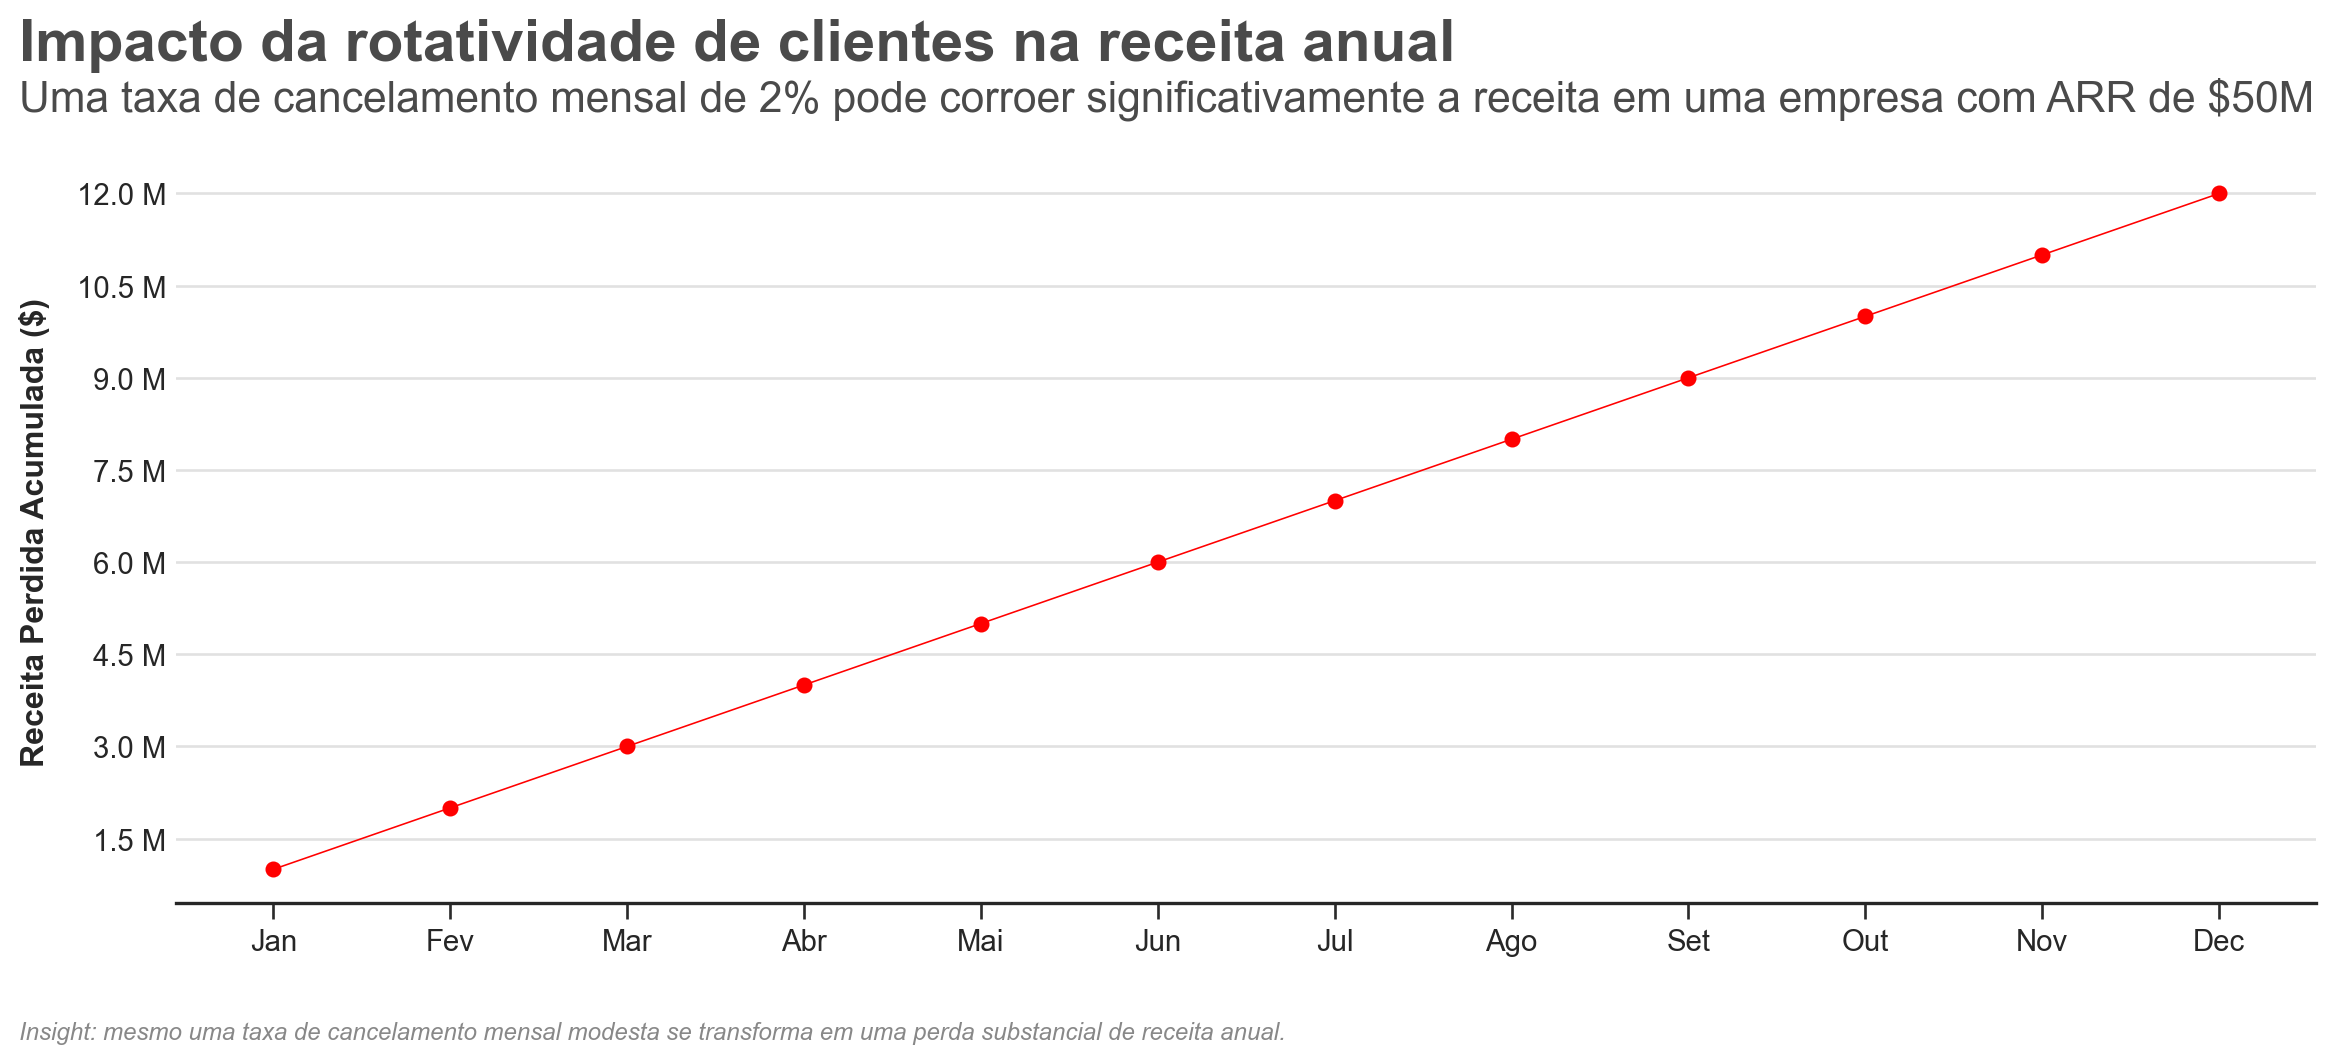

In [14]:
def plot_annual_churn_impact(
    annual_revenue=50_000_000,
    churn_rate=0.02,
    title="Impacto da rotatividade de clientes na receita anual",
    subtitle=None,
    footer_text=None,
    show_footer=False,
    line_color='red'
):
    """
    Plot cumulative annual revenue loss under a fixed monthly churn rate.

    Parameters
    ----------
    annual_revenue : int or float
        Annual recurring revenue.
    churn_rate : float
        Monthly churn rate (e.g., 0.02 for 2%).
    title : str
        Main chart title.
    subtitle : str or None
        Subtitle shown below the title.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    line_color : str
        Line color.
    """

    def revenue_formatter(x, pos):
        return f"{x / 1e6:.1f} M"

    # perda mensal e cumulativa
    monthly_lost_revenue = annual_revenue * churn_rate
    cumulative_lost_revenue = [monthly_lost_revenue * i for i in range(1, 13)]

    months = list(range(1, 13))
    month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dec']

    fig, ax = plt.subplots(figsize=(12.33, 5.5), dpi=96)

    ax.plot(
        months,
        cumulative_lost_revenue,
        marker='.',
        color=line_color,
        linewidth=.6
    )

    # eixos
    ax.set_ylabel('Receita Perdida Acumulada ($)', fontsize=12, labelpad=10)
    ax.set_xlabel('')
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)

    ax.yaxis.set_major_formatter(FuncFormatter(revenue_formatter))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # manter legibilidade: sem borda esquerda, rótulos y preservados
    format_corporate_axes(
        ax,
        hide_y_spine_only=True,
        hide_y_entirely=False,
        grid=True,
        grid_axis='y'
    )

    if subtitle is None:
        subtitle = (
            f"Uma taxa de cancelamento mensal de {churn_rate:.0%} pode corroer significativamente "
            f"a receita em uma empresa com ARR de ${annual_revenue/1e6:.0f}M"
        )


    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
set_corporate_theme()

plot_annual_churn_impact(
    annual_revenue=50_000_000,
    churn_rate=0.02,
    footer_text="Insight: mesmo uma taxa de cancelamento mensal modesta se transforma em uma perda substancial de receita anual.",
    show_footer=True
)    

*Gráfico mostrando a perda cumulativa de receita ao longo de 12 meses com uma taxa de churn mensal de 2%. Cada ponto representa a perda acumulada até aquele mês.*

<span style="color:steelblue; text-align: left">

### Tipos de Churn
</span>

O churn difere dependendo do modelo de negócio:

- **Churn contratual**: ocorre quando o cliente cancela explicitamente uma assinatura ou serviço.
- **Churn não contratual**: ocorre quando o cliente simplesmente para de comprar ou se engajar, sem nenhum cancelamento formal.

<span style="color:steelblue; text-align: left">

### Modelando o Churn
</span>

O churn não contratual é mais difícil de definir e modelar porque não há um evento explícito. Ele deve ser inferido a partir do comportamento, como inatividade por um período definido (ex.: nenhuma compra em 30 dias). Essa definição varia entre clientes e requer hipóteses específicas do domínio.

Neste projeto, focamos no **churn contratual** no contexto de telecomunicações, onde o churn é claramente definido pelo término do contrato.

<span style="color:steelblue; text-align: left">

### Codificação do Churn
</span>

O churn é tipicamente codificado como uma variável binária:

- **1 = Churn**
- **0 = Sem Churn**

Conjuntos de dados podem usar rótulos como *Sim/Não* ou *Churn/Sem Churn*, mas a conversão para o formato binário é a prática padrão para modelagem.


<span style="color:steelblue; text-align: left">

## Conjunto de Dados
</span>

Esta análise utiliza o [dataset de Churn de Clientes de Telecom](https://www.kaggle.com/datasets/puja19/telecom-customer-churn), que contém informações em nível de cliente sobre dados demográficos, serviços e status de churn.


In [15]:
def read_data(path='./dataset/telco.csv'):
    df = pd.read_csv(path)
    return df


In [16]:
telecom = read_data()

# Verificações básicas
print(f"Shape: {telecom.shape}")
display(telecom['Churn'].value_counts())

Shape: (7043, 21)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<span style="color:steelblue; text-align: left">

### Explorando a Distribuição do Churn
</span>

Um primeiro passo importante é verificar se a variável alvo está desbalanceada, ou seja, se uma classe é substancialmente mais frequente do que a outra. Neste conjunto de dados, aproximadamente 26,5% dos clientes sofreram churn, enquanto 73,5% não.

Isso indica um desequilíbrio moderado de classes. A classe minoritária ainda está bem representada, portanto o conjunto de dados não está severamente desbalanceado. No entanto, o desequilíbrio de classes deve ser considerado durante a avaliação do modelo, especialmente ao interpretar métricas como acurácia, precisão, recall e F1-score.

Em etapas posteriores, estratégias de reamostragem podem ser testadas para avaliar se melhoram o desempenho preditivo para a classe de churn.


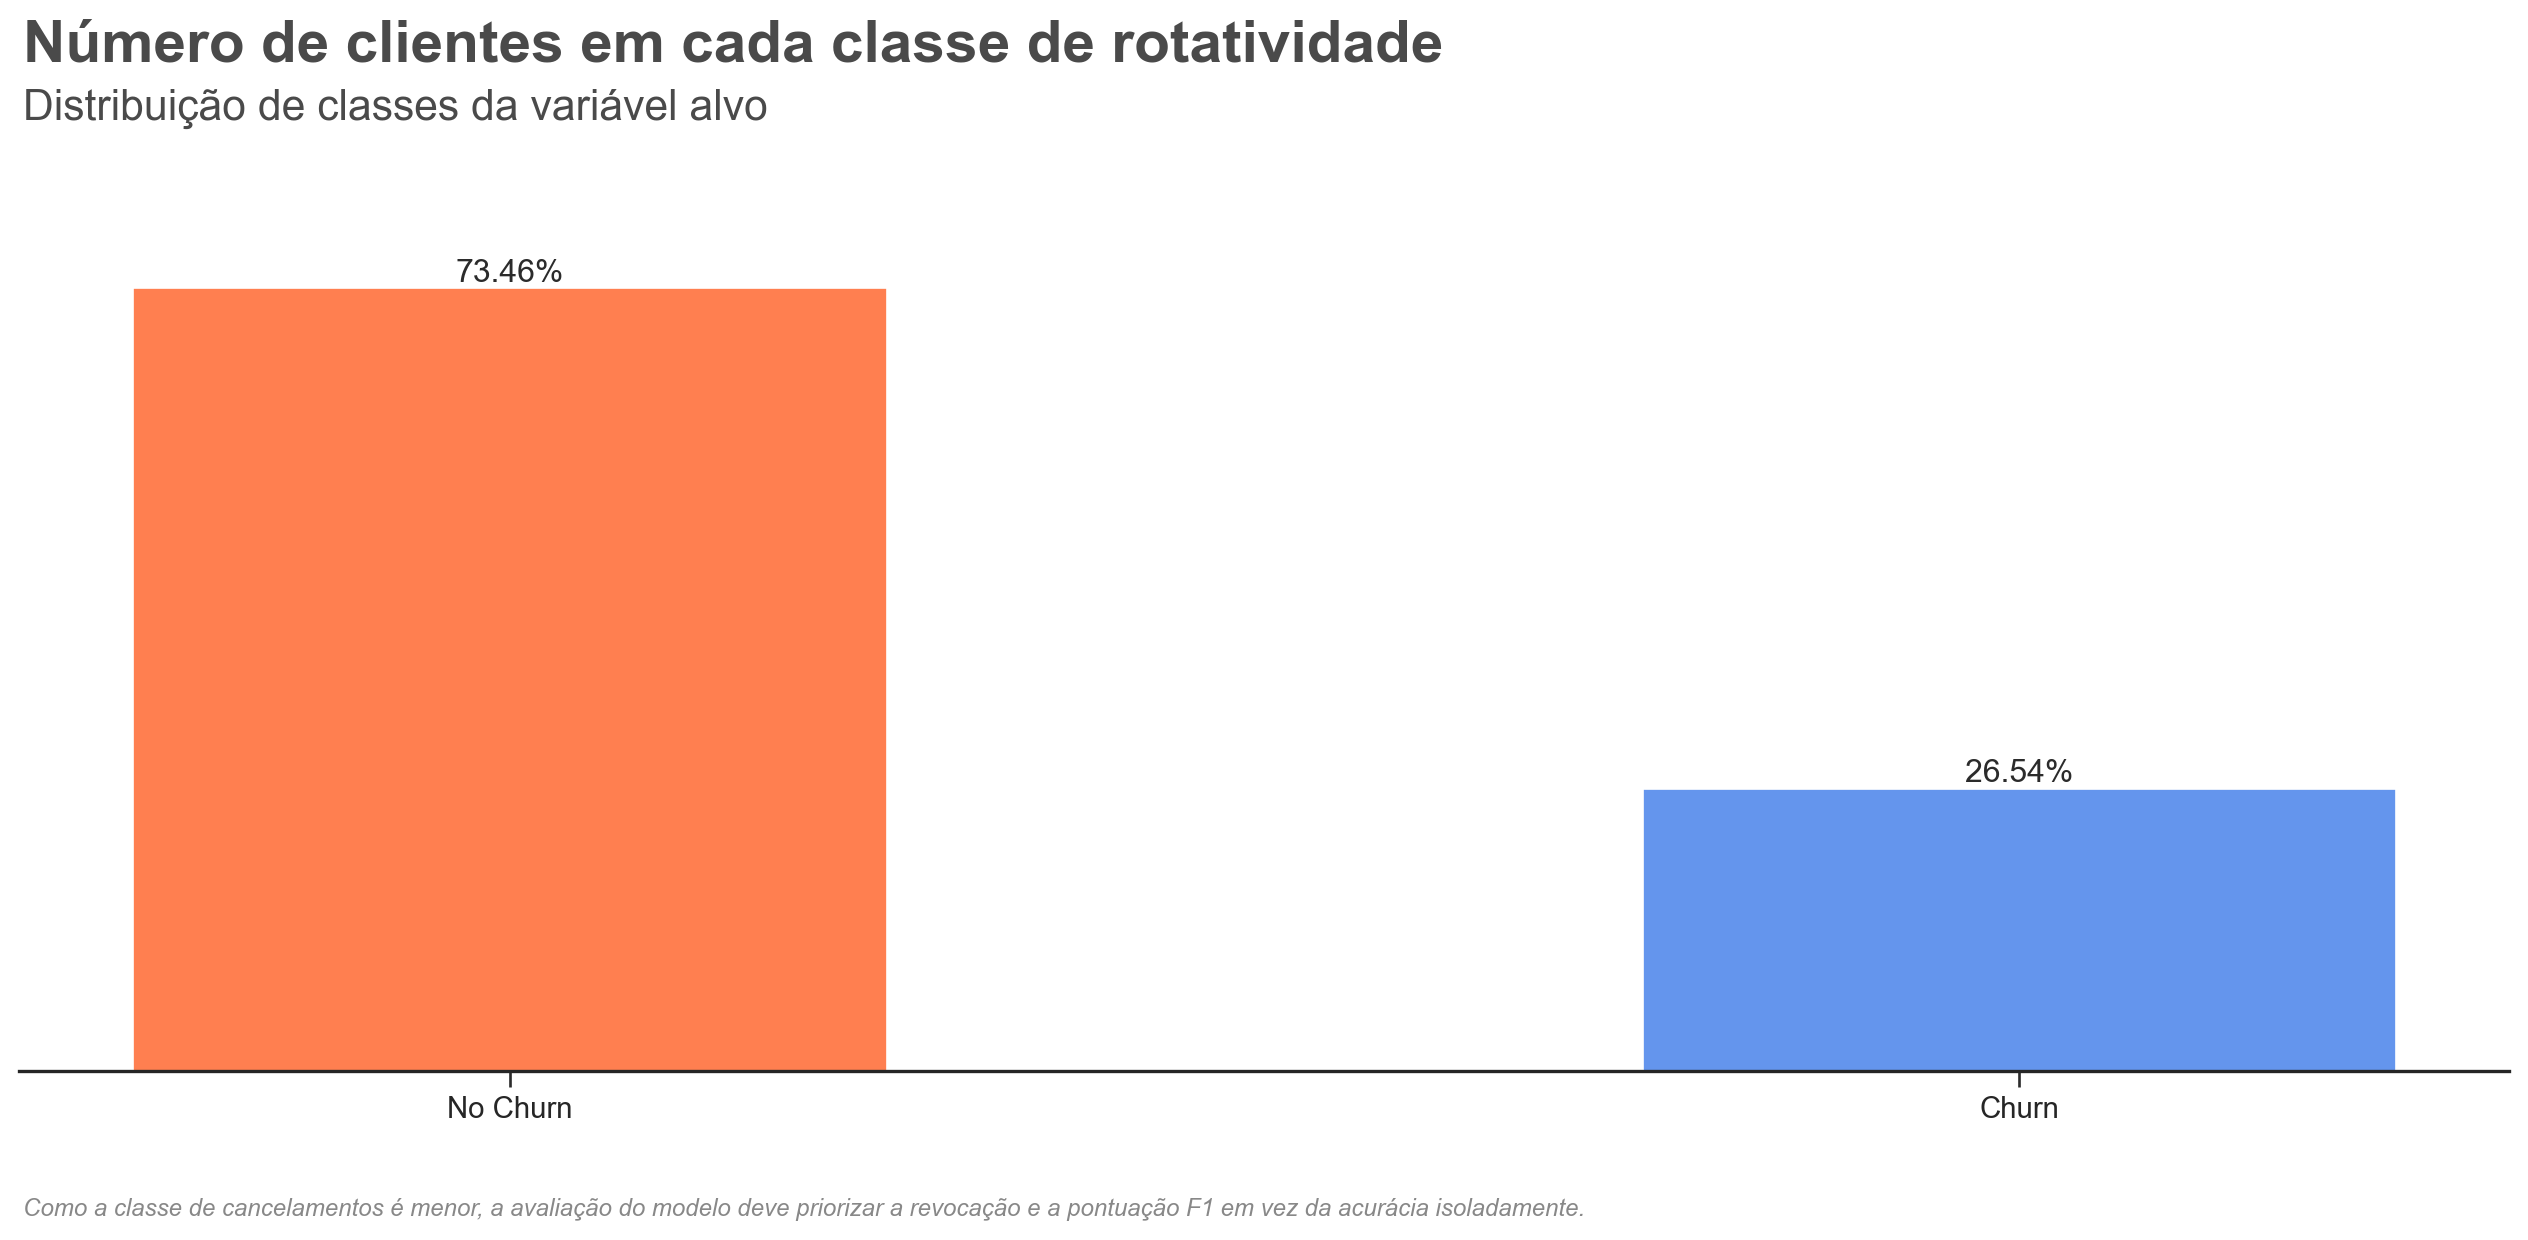

In [18]:
def plot_churn_distribution(
    df,
    churn_col='Churn',
    title="Number of Customers in Each Churn Class",
    subtitle="Class distribution of the target variable",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    """
    Plot churn class distribution as percentage bars.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    churn_col : str
        Name of the churn column.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    palette : tuple
        Colors for non-churn and churn classes.
    """

    # Calcular distribuição
    counts = df[churn_col].value_counts(normalize=True) * 100

    # Mapeamento robusto de rótulos
    label_map = {
        'No': 'No Churn',
        'Yes': 'Churn',
        'No Churn': 'No Churn',
        'Churn': 'Churn',
        0: 'No Churn',
        1: 'Churn'
    }

    labels = [label_map.get(idx, str(idx)) for idx in counts.index]
    values = counts.values.tolist()

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, width=0.5, color=list(palette))

    # Rótulos nas barras
    ax.bar_label(bars, fmt='%.2f%%', fontsize=12, color="#2b2b2b")

    # Ocultar eixo y completamente para este tipo de gráfico
    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    # Legenda opcional
    # ax.legend(bars, labels, loc='upper right')

    # Manter espaço acima das barras
    ax.set_ylim(0, max(values) * 1.15)

    # Cabeçalho
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Rodapé opcional
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_churn_distribution(
    telecom,
    churn_col='Churn',
    title="Número de clientes em cada classe de rotatividade",
    subtitle="Distribuição de classes da variável alvo",
    footer_text="Como a classe de cancelamentos é menor, a avaliação do modelo deve priorizar a revocação e a pontuação F1 em vez da acurácia isoladamente.",
    show_footer=True
)    

<span style="color:steelblue; text-align: left">

### Significado das Características
</span>


In [19]:
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

<span style="color:steelblue; text-align: left">

### Definições das Características
</span>

Esta visão estruturada ajuda a orientar a engenharia de características e a seleção de variáveis durante a modelagem.

O conjunto de dados contém informações em nível de cliente que podem ser agrupadas em quatro categorias principais:


**Variável Alvo**

- `Churn` – Indica se o cliente sofreu churn (Sim / Não)


**Serviços Contratados**

- `PhoneService` – Cliente possui serviço telefônico (Sim / Não)
- `MultipleLines` – Múltiplas linhas telefônicas (Sim / Não / Sem serviço telefônico)
- `InternetService` – Tipo de serviço de internet (DSL / Fibra óptica / Não)
- `OnlineSecurity` – Add-on de segurança online (Sim / Não / Sem serviço de internet)
- `OnlineBackup` – Serviço de backup (Sim / Não / Sem serviço de internet)
- `DeviceProtection` – Plano de proteção de dispositivo (Sim / Não / Sem serviço de internet)
- `TechSupport` – Serviço de suporte técnico (Sim / Não / Sem serviço de internet)
- `StreamingTV` – Serviço de streaming de TV (Sim / Não / Sem serviço de internet)
- `StreamingMovies` – Serviço de streaming de filmes (Sim / Não / Sem serviço de internet)


**Informações da Conta**

- `tenure` – Número de meses que o cliente está ativo
- `Contract` – Tipo de contrato (Mês a mês / Um ano / Dois anos)
- `PaperlessBilling` – Fatura digital habilitada (Sim / Não)
- `PaymentMethod` – Método de pagamento utilizado pelo cliente
- `MonthlyCharges` – Valor de cobrança mensal
- `TotalCharges` – Cobranças acumuladas totais


**Perfil do Cliente**

- `customerID` – Identificador único do cliente
- `gender` – Gênero do cliente
- `SeniorCitizen` – Indicador de idoso (1 = Sim, 0 = Não)
- `Partner` – Possui cônjuge/parceiro (Sim / Não)
- `Dependents` – Possui dependentes (Sim / Não)


**Convertendo Total de Cobranças para tipo de dado numérico**

In [21]:
# Converter para numérico
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

# Verificar ausentes
missing_total = telecom['TotalCharges'].isnull().sum()
telecom[telecom['TotalCharges'].isnull()][['tenure', 'MonthlyCharges']]
print(f"Valores ausentes em TotalCharges: {missing_total}")


Valores ausentes em TotalCharges: 11


Após converter `TotalCharges` para numérico, 11 valores ausentes foram identificados.

Esses valores ausentes estão associados a clientes com tempo de permanência muito baixo (tipicamente novos clientes sem cobranças acumuladas). Dada a pequena proporção de linhas afetadas, elas podem ser removidas com segurança sem impactar a análise.

Portanto, essas observações são excluídas do conjunto de dados.


In [22]:
# Remover ausentes
telecom = telecom.dropna(subset=['TotalCharges'])

<span style="color:steelblue; text-align: left">

## Análise Exploratória de Dados (EDA)
</span>

A análise começa com uma exploração inicial do conjunto de dados para identificar padrões, distribuições e possíveis relações entre variáveis.

O foco está em:
- Distribuições univariadas (comportamento individual de cada característica)
- Relações bivariadas (interação entre características)

<span style="color:steelblue; text-align: left">

### Características Numéricas
</span>

Histogramas são usados para avaliar a distribuição das variáveis numéricas, enquanto gráficos de dispersão ajudam a identificar relações e potenciais correlações entre elas.


In [23]:
def add_finance_header(
    fig,
    title,
    subtitle=None,
    x_line=0.0,
    y_line=0.98,
    line_width=0.9,
    rect_width=0.04,
    text_pad=0.012,
    title_offset=0.055,
    subtitle_offset=0.095,
    color='#E3120B'
):

    ax0 = fig.axes[0]


    # 🔥 ALINHAMENTO CORRETO (com a linha, não com o bloco)
    x_text = x_line + text_pad

    # Título
    fig.text(
        x=x_text,
        y=y_line - title_offset,
        s=title,
        ha='left',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        style='italic'
    )

    # Subtítulo
    if subtitle:
        fig.text(
            x=x_text,
            y=y_line - subtitle_offset,
            s=subtitle,
            ha='left',
            va='bottom',
            fontsize=12,
            style='italic'
        )

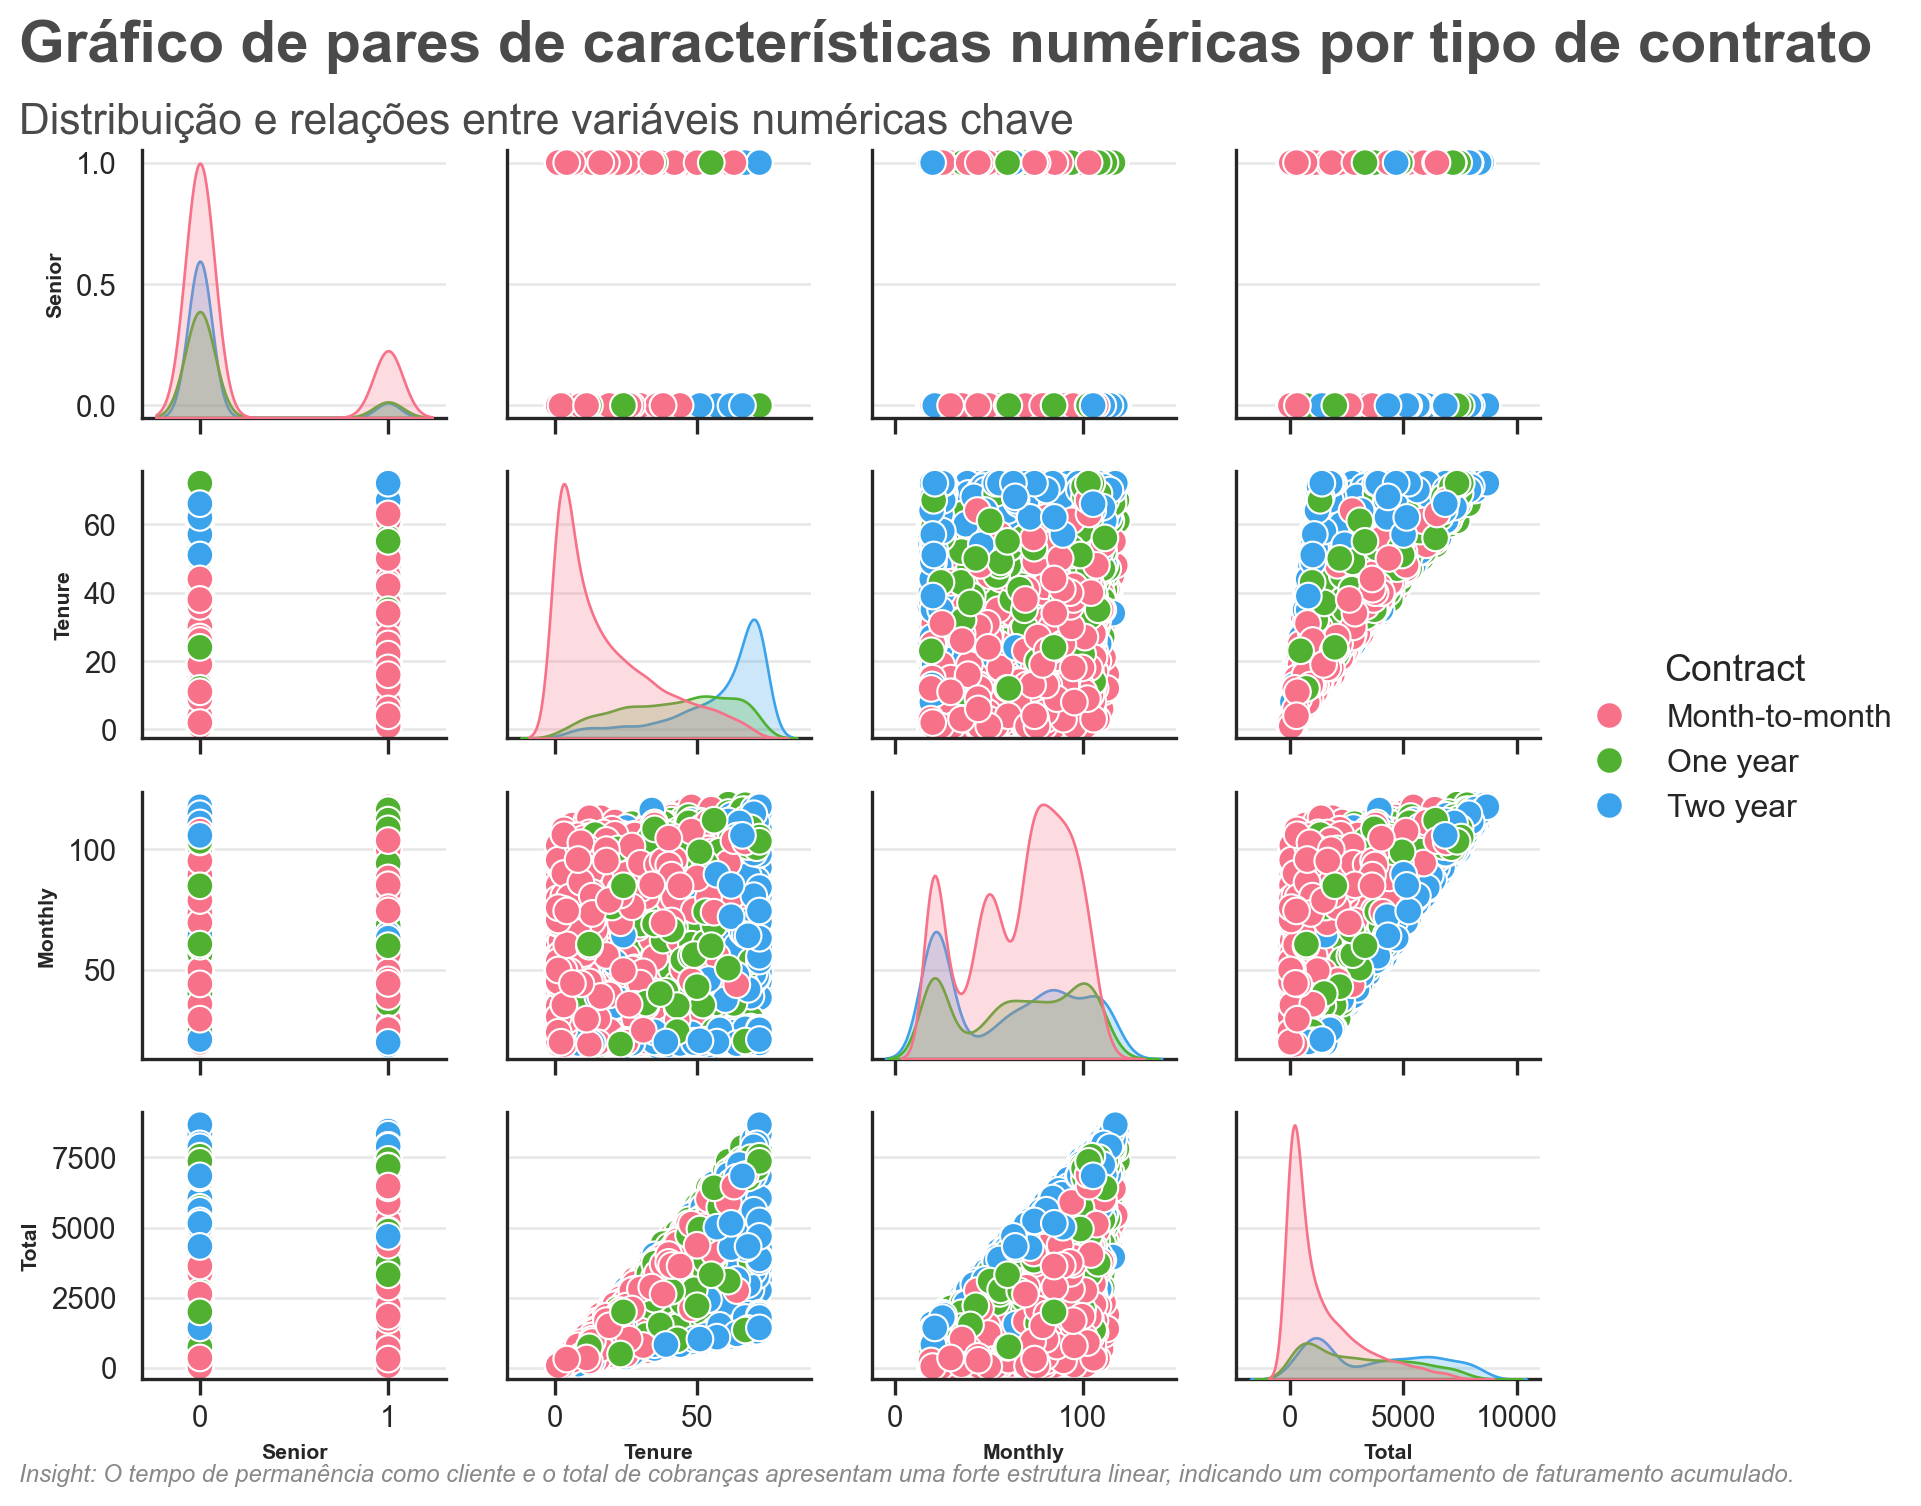

In [24]:
def plot_pairplot_corporate(
    df,
    rename_dict=None,
    hue='Contract',
    title="Gráfico de pares de características numéricas",
    subtitle=None,
    palette='husl',
    height=2,
    show_footer=False,
    footer_text=None
):
    """
    Generate a Seaborn pairplot in corporate style.

    Parameters
    ----------
    df : pandas.DataFrame
    rename_dict : dict
        Optional column renaming for readability
    hue : str
        Column used for grouping
    title : str
    subtitle : str
    palette : str
    height : float
    show_footer : bool
    footer_text : str
    """

    # Renomear colunas se fornecidas
    if rename_dict:
        data = df.rename(columns=rename_dict)
    else:
        data = df.copy()

    # Criar pairplot
    g = sns.pairplot(
        data,
        hue=hue,
        palette=palette,
        height=height,
        diag_kind='kde'  # mais elegante que hist
    )

    fig = g.figure

    # Header (seu padrão)
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Ajuste fino de layout
    fig.subplots_adjust(
        top=0.88,
        bottom=0.08,
        left=0.08,
        right=0.82,
        hspace=0.2,
        wspace=0.2
    )

    # Ajuste de labels (legibilidade)
    for ax in g.axes.flatten():
        if ax is not None:
            ax.set_xlabel(ax.get_xlabel(), fontsize=8)
            ax.set_ylabel(ax.get_ylabel(), fontsize=8)

    # Legend externa
    if g._legend is not None:
        g._legend.set_bbox_to_anchor((1.02, 0.5))
        g._legend.set_title(hue)
        g._legend.set_frame_on(False)

    # Footer opcional
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.show()

    return g

rename_dict = {
    'MonthlyCharges': 'Monthly',
    'TotalCharges': 'Total',
    'SeniorCitizen': 'Senior',
    'tenure': 'Tenure'
}

plot_pairplot_corporate(
    telecom,
    rename_dict=rename_dict,
    hue='Contract',
    title="Gráfico de pares de características numéricas por tipo de contrato",
    subtitle="Distribuição e relações entre variáveis ​​numéricas chave",
    show_footer=True,
    footer_text="Insight: O tempo de permanência como cliente e o total de cobranças apresentam uma forte estrutura linear, indicando um comportamento de faturamento acumulado."
)

O gráfico de pares fornece uma visão combinada das distribuições univariadas e das relações par a par entre as principais variáveis numéricas, segmentadas por tipo de contrato.

**Insights:**
- `Tenure` e `Total` mostram uma forte relação positiva, refletindo a natureza cumulativa da cobrança — tempos de vida mais longos dos clientes se traduzem diretamente em maiores cobranças totais.
- Clientes com contratos `Mês a mês` estão concentrados em valores mais baixos de `Tenure` e `Total`, indicando ciclos de vida mais curtos e maior exposição ao churn em comparação com contratos de longo prazo.
- As cobranças `Mensais` apresentam grande dispersão entre tipos de contrato, sugerindo poder discriminativo limitado quando usadas isoladamente.
- `Senior` é uma característica binária (0/1). Apesar de representada como numérica, sua interpretabilidade é categórica e deve ser tratada como tal na modelagem.

Após revisar o comportamento numérico, procedemos à distribuição das variáveis categóricas, começando pelo gênero.

<span style="color:steelblue; text-align: left">

###  Distribuição por Gênero
</span>


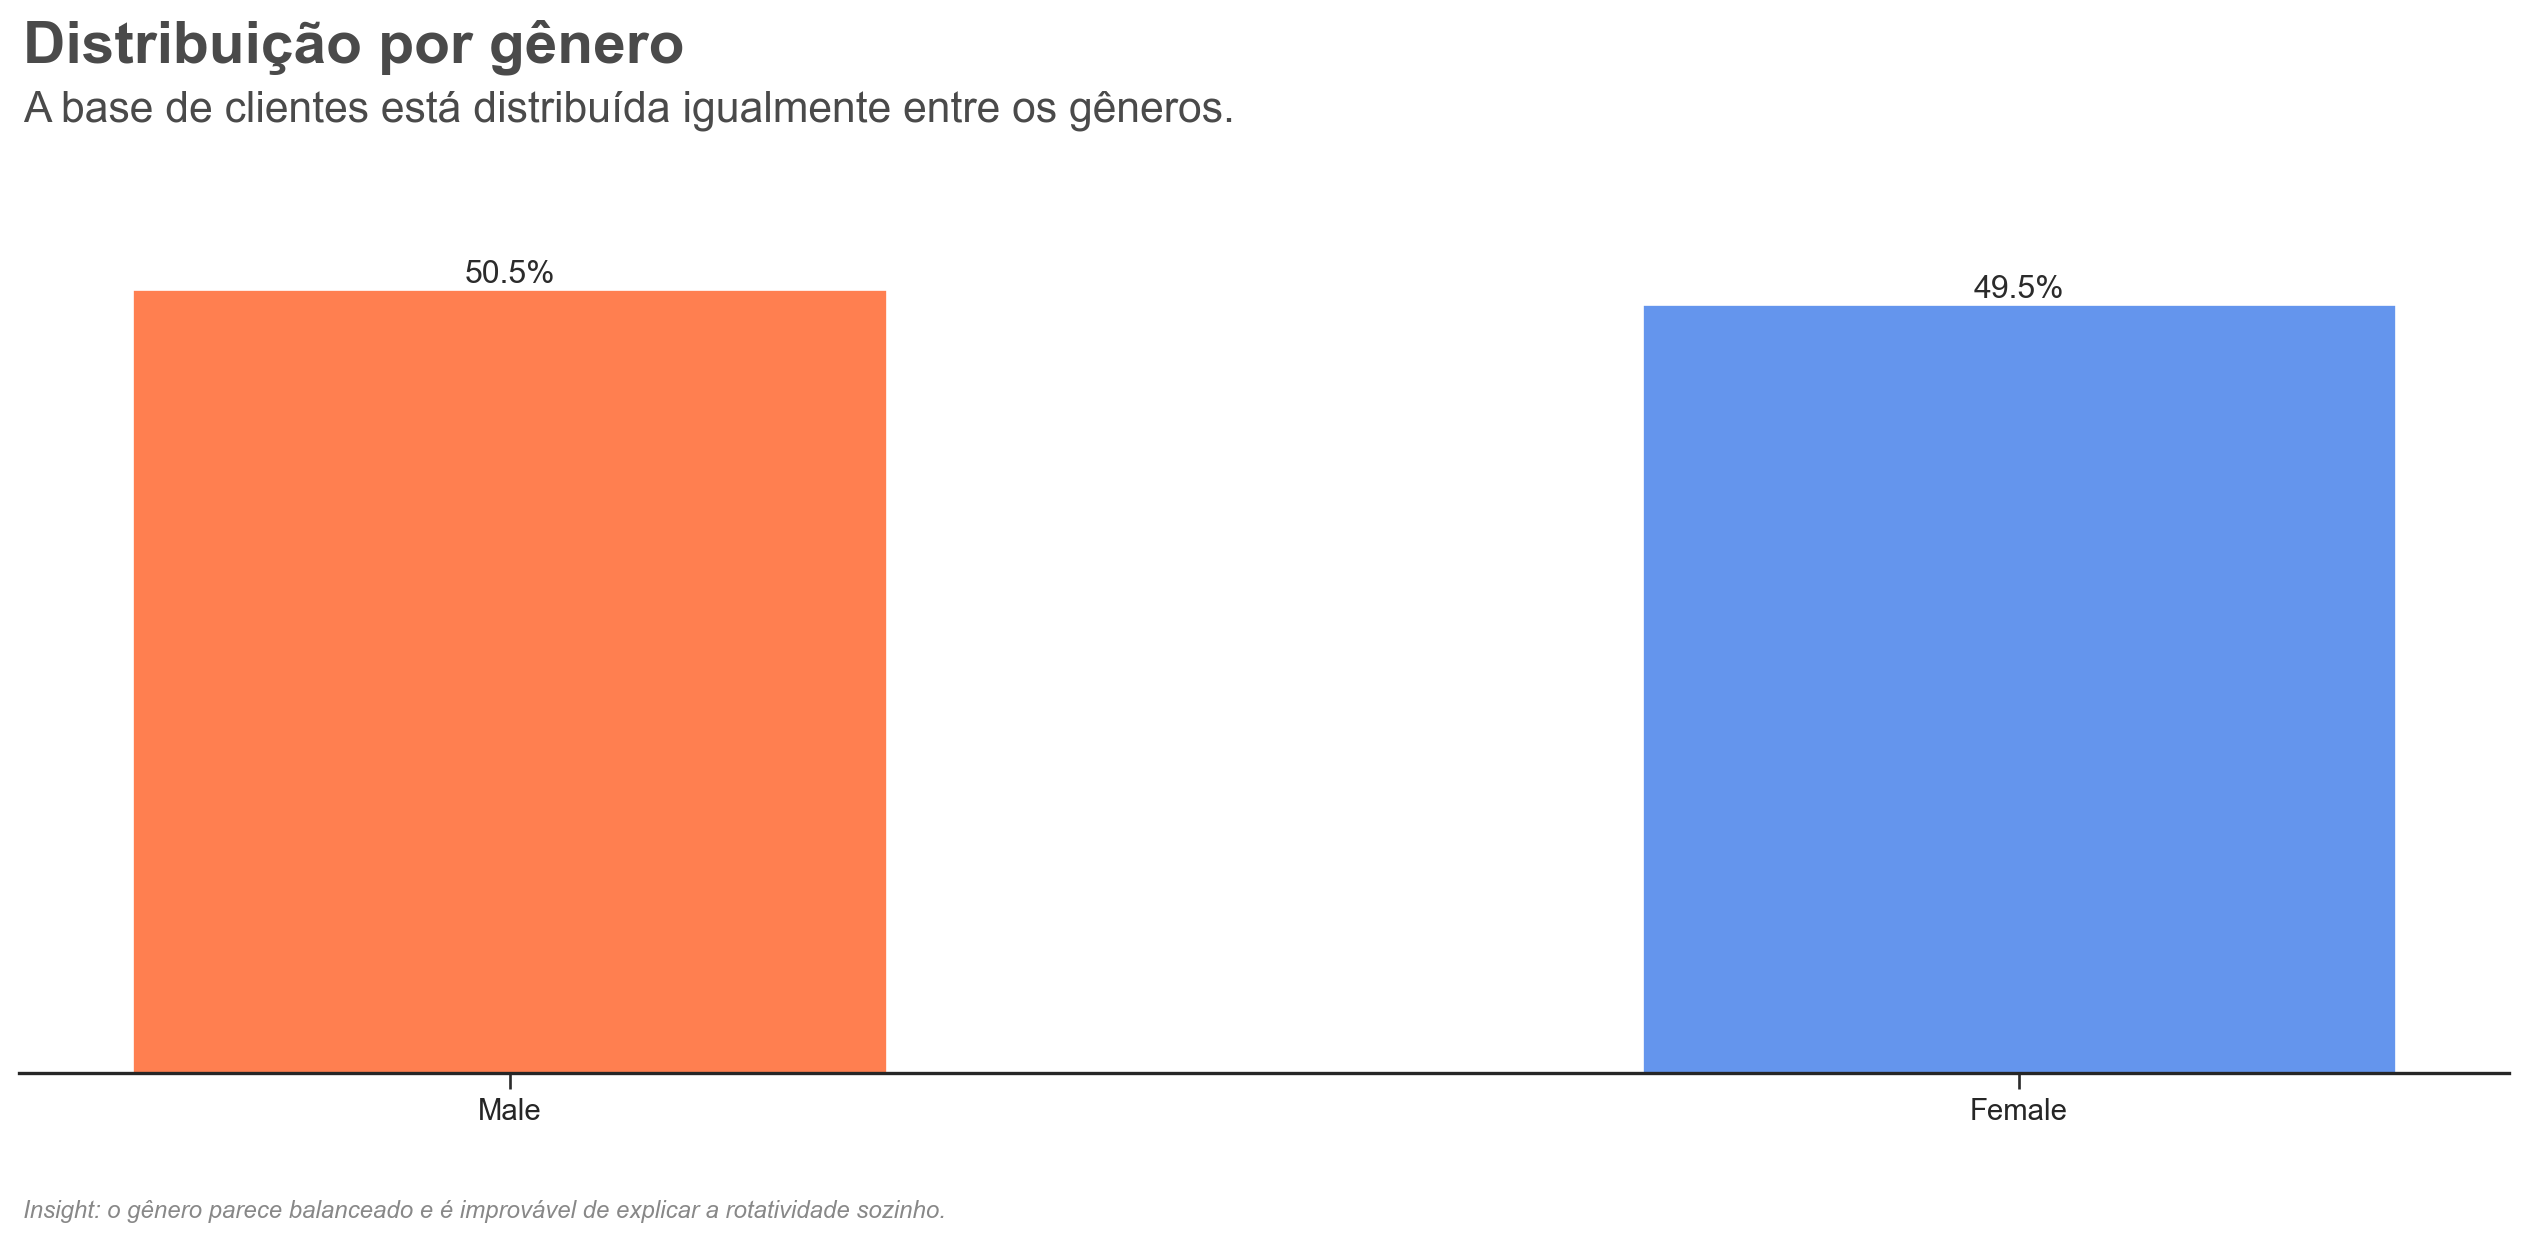

In [26]:
def plot_gender_distribution(
    df,
    gender_col='gender',
    title="Gender Distribution",
    subtitle="Customer base is evenly distributed across genders",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    """
    Plot gender distribution as percentage bars.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    gender_col : str
        Name of the gender column.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    palette : tuple
        Colors for the bars.
    """

    # Calcular distribuição percentual
    gender_counts = df[gender_col].value_counts(normalize=True) * 100

    labels = gender_counts.index.tolist()
    values = gender_counts.values.tolist()

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, width=0.5, color=list(palette))

    # Rótulos nas barras
    ax.bar_label(bars, fmt='%.1f%%', fontsize=12, color="#2b2b2b")

    # Intervalo visual
    ax.set_ylim(0, max(values) * 1.15)

    # Formatação corporativa dos eixos
    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    # Cabeçalho
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Rodapé
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_gender_distribution(
    telecom,
    gender_col='gender',
    title="Distribuição por gênero",
    subtitle="A base de clientes está distribuída igualmente entre os gêneros.",
    footer_text="Insight: o gênero parece balanceado e é improvável de explicar a rotatividade sozinho.",
    show_footer=True
)    

**Insights:**
- A base de clientes é quase igualmente dividida entre clientes masculinos e femininos, indicando nenhum desequilíbrio significativo de classe para esta característica.
- Isso sugere que o gênero, por si só, provavelmente não é um forte discriminador de churn.
- Espera-se maior poder explicativo de variáveis comportamentais, contratuais e relacionadas a cobrança.
- Como a distribuição é equilibrada, nenhum ajuste é necessário para esta característica do ponto de vista de representação de classes.

<span style="color:steelblue; text-align: left">

###  Distribuição de Idosos
</span>


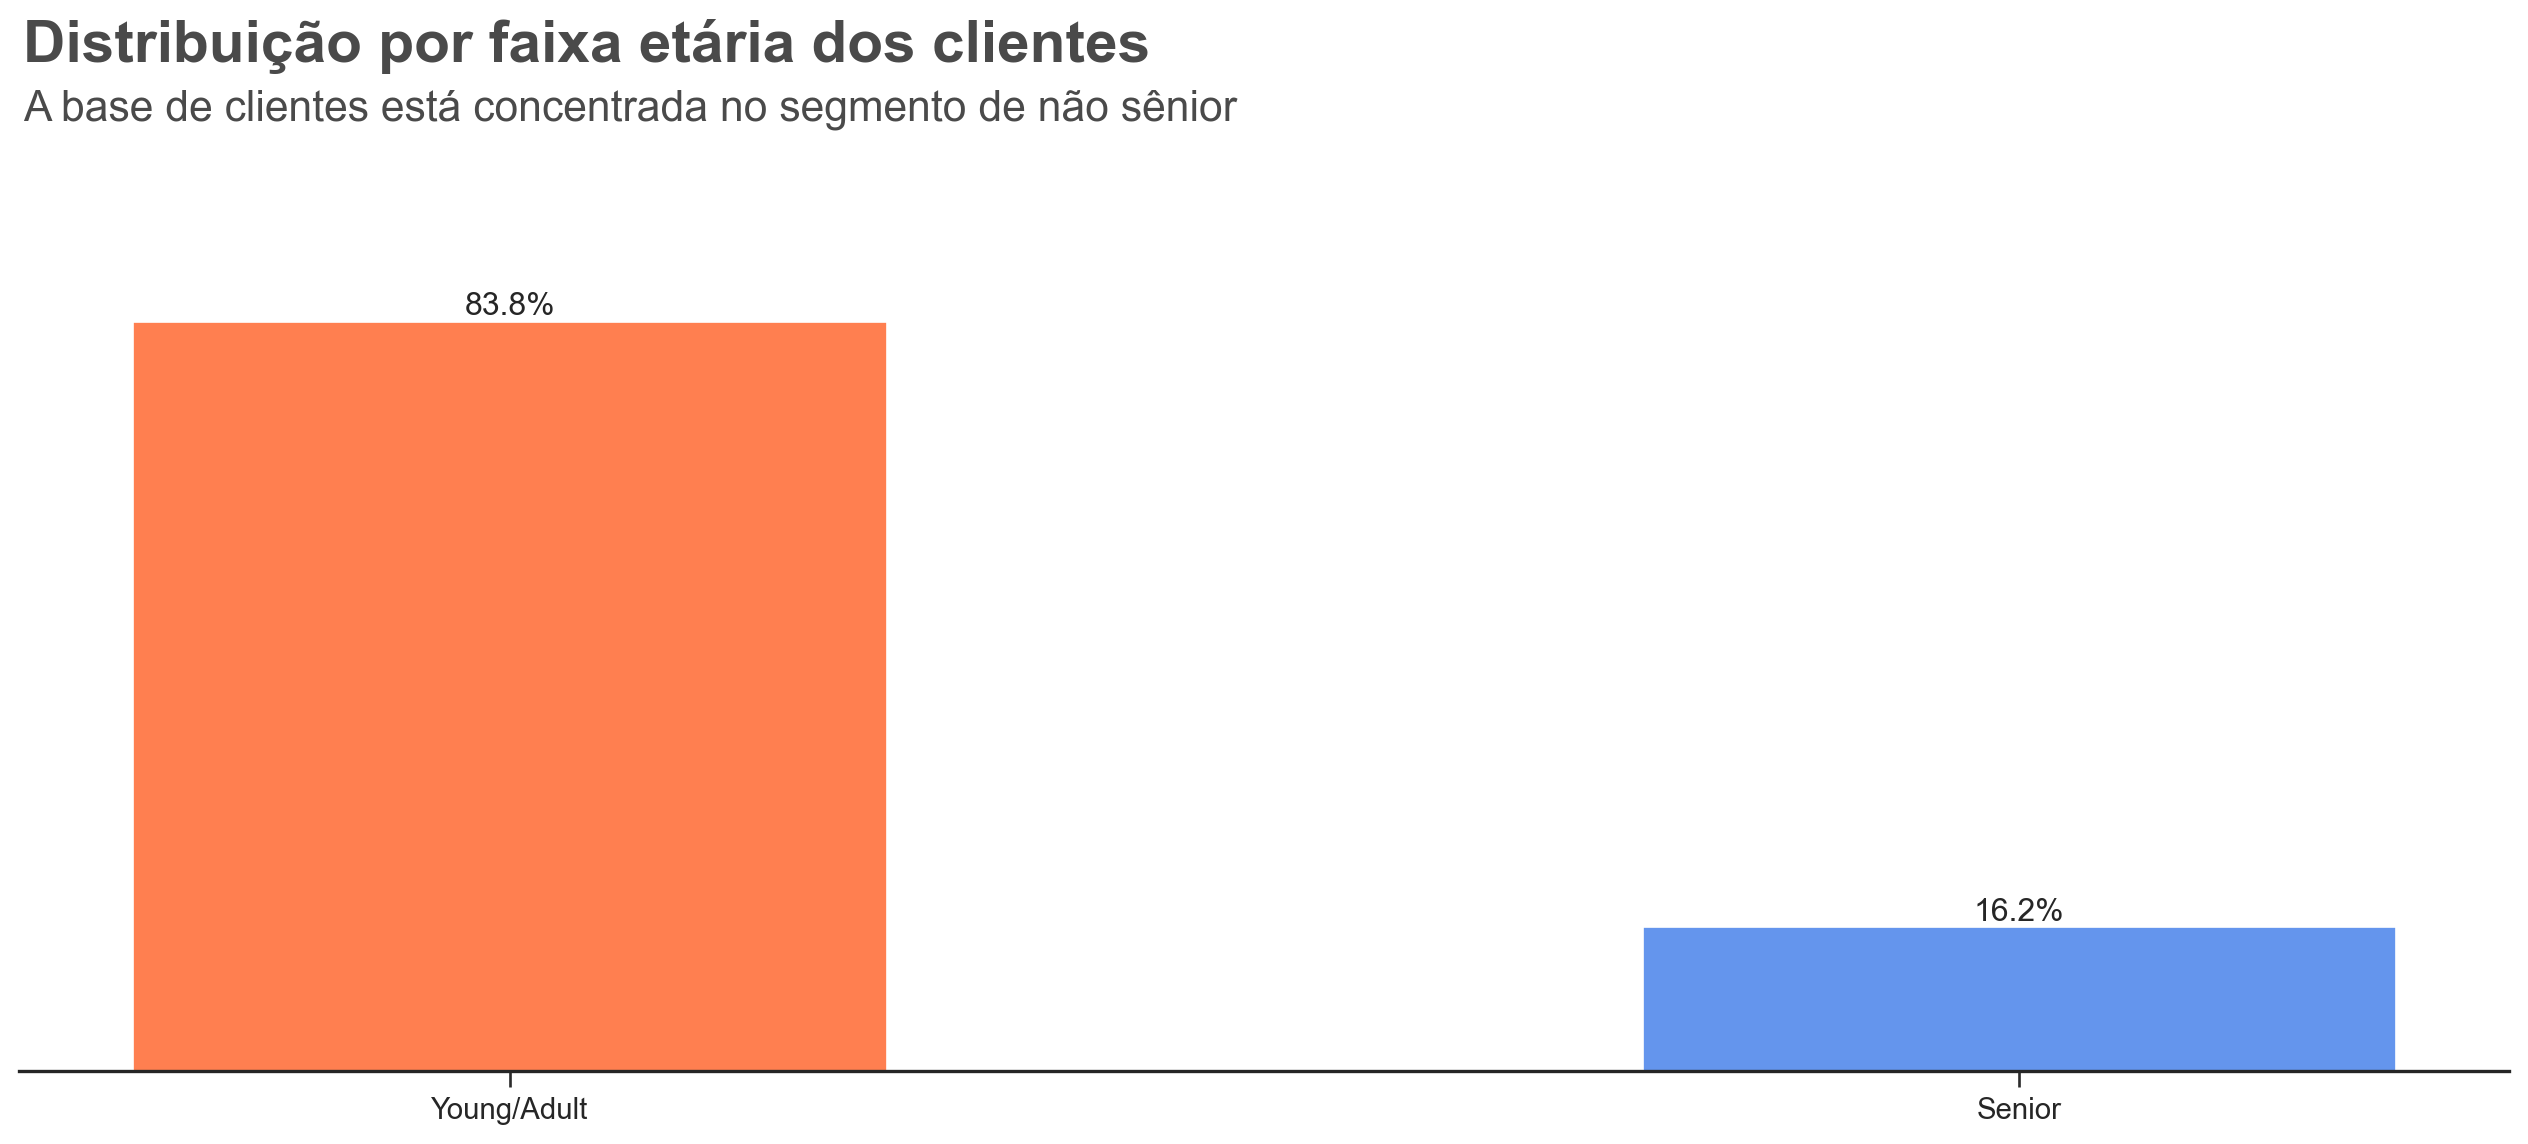

In [27]:
def plot_senior_distribution(
    df,
    col='SeniorCitizen',
    title="Distribuição por faixa etária dos clientes",
    subtitle="A base de clientes está concentrada no segmento de não sênior",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    
    dist = df[col].value_counts(normalize=True) * 100
    labels_map = {0: 'Young/Adult', 1: 'Senior'}
    
    labels = [labels_map[i] for i in dist.index]
    values = dist.values

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, color=palette, width=0.5)

    ax.bar_label(bars, fmt='%.1f%%', fontsize=12)

    ax.set_ylim(0, max(values) * 1.2)

    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_senior_distribution(telecom)    

**Insights:**
- Clientes idosos representam uma minoria (~16%) da base, com a maioria concentrada no segmento não-idoso.
- Esse desequilíbrio sugere que os padrões envolvendo clientes idosos devem ser interpretados com cautela devido à menor representação amostral.
- Apesar da participação menor, este segmento pode exibir padrões comportamentais distintos e deve ser avaliado separadamente na análise de churn.

<span style="color:steelblue; text-align: left">

###  Distribuição de Parceiros e Dependentes
</span>


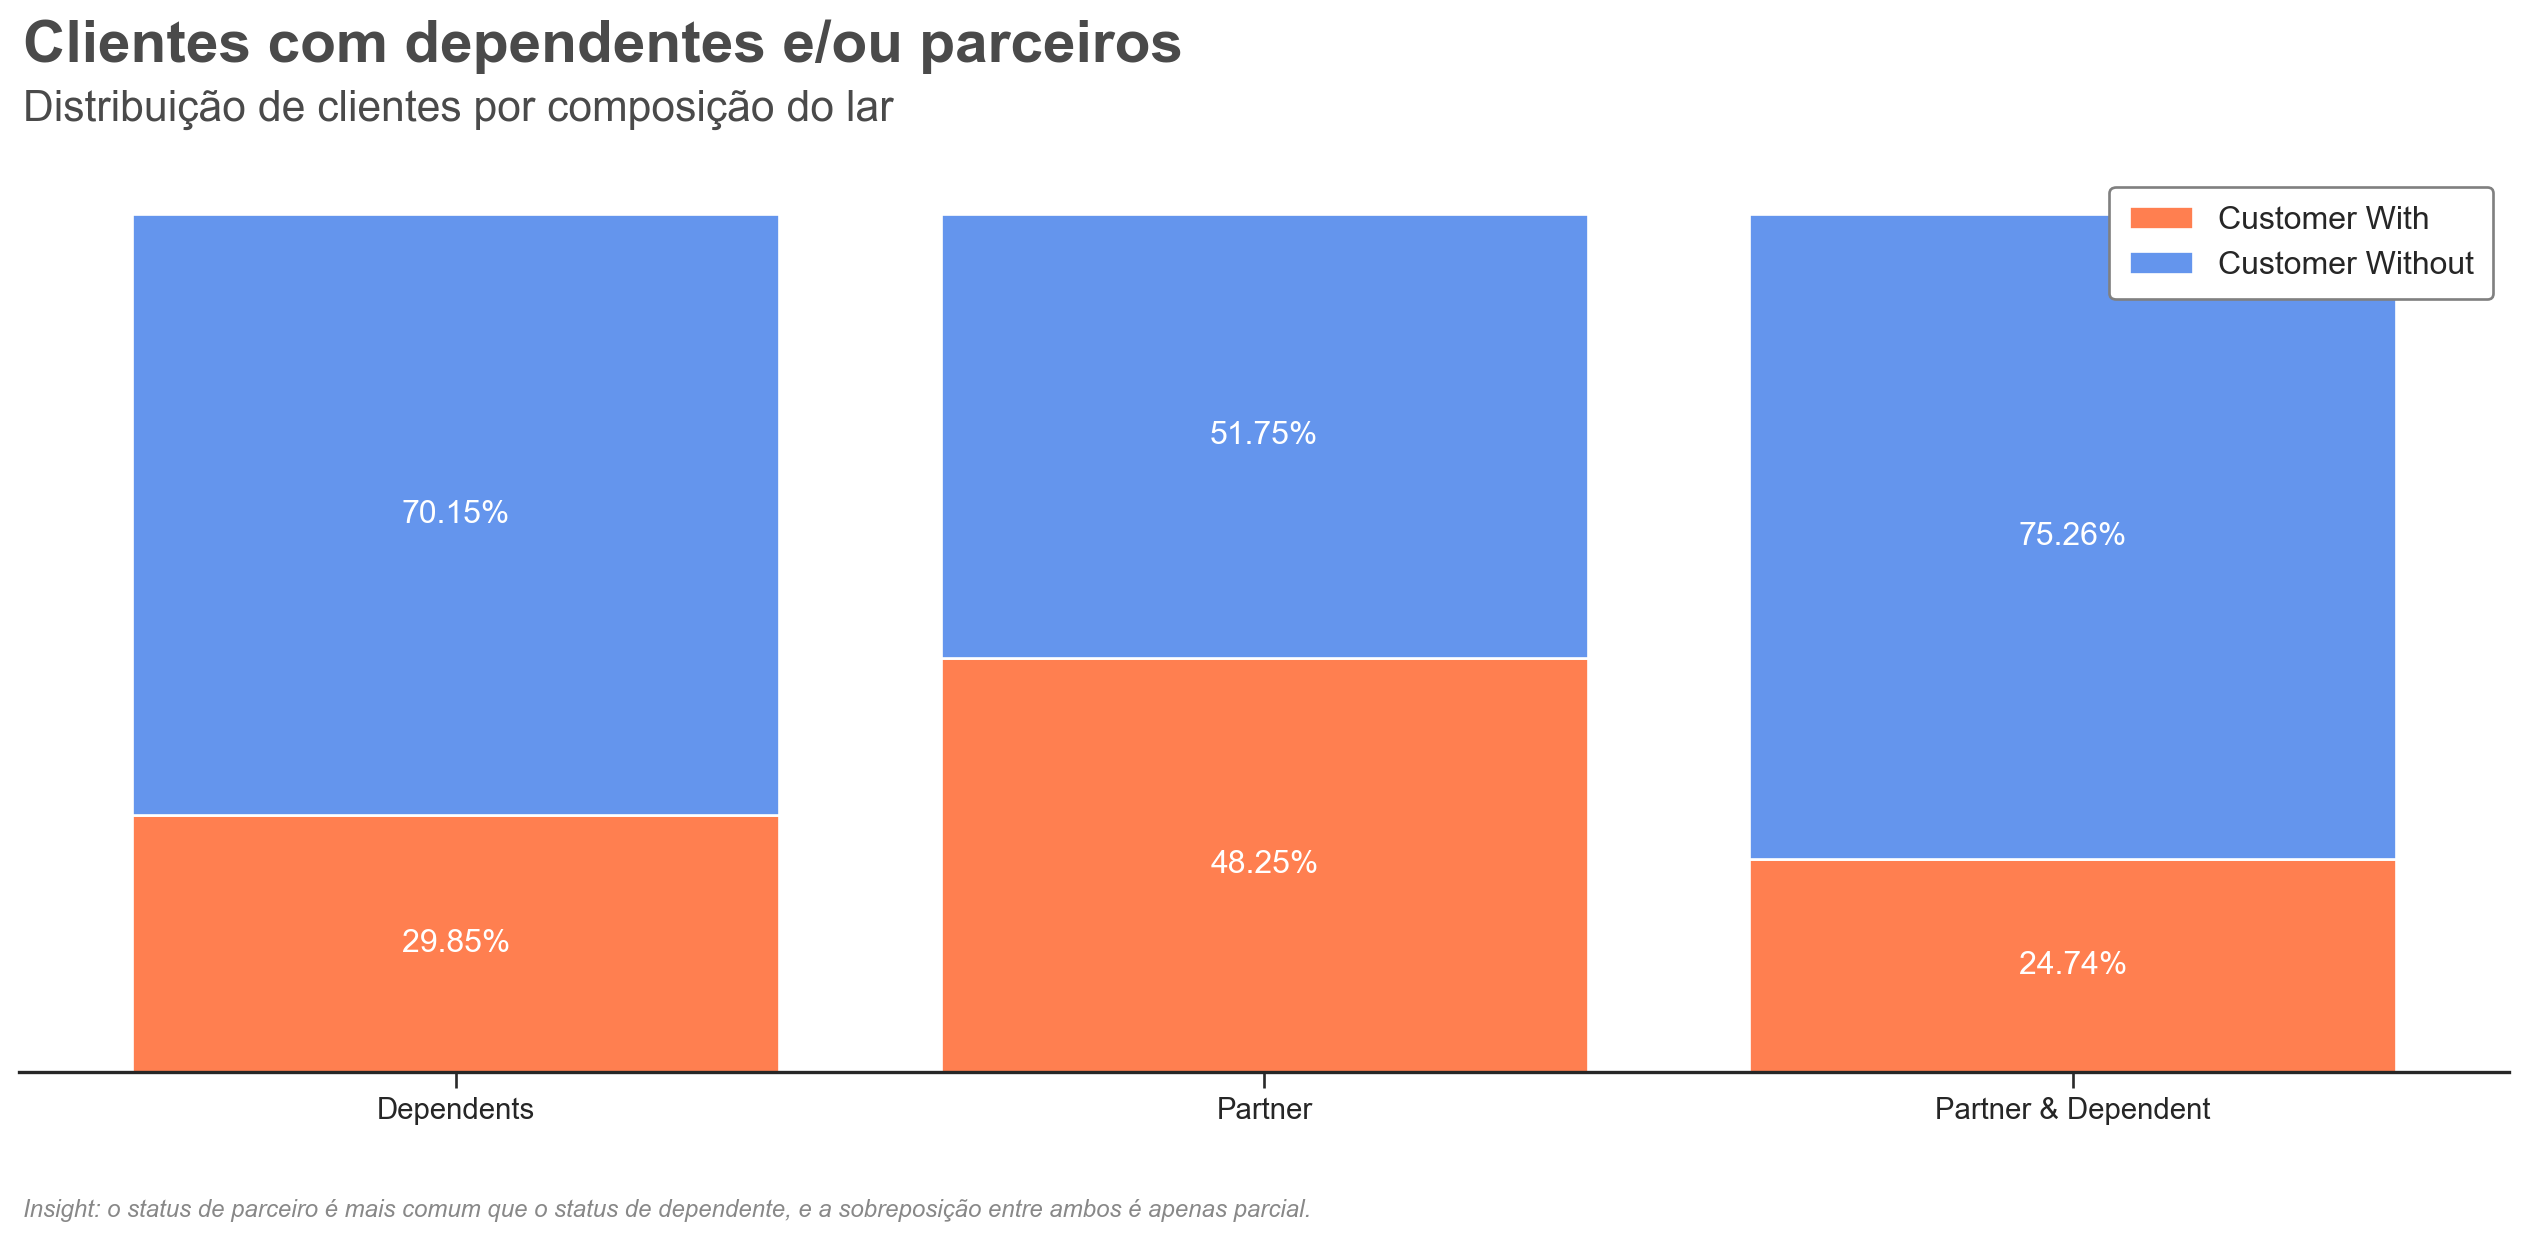

In [28]:
def plot_household_composition(
    df,
    partner_col='Partner',
    dependents_col='Dependents',
    title="Clientes com dependentes e/ou parceiros",
    subtitle="Distribuição de clientes por composição do lar",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    """
    Plot household composition using stacked percentage bars.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    partner_col : str
        Column indicating partner status.
    dependents_col : str
        Column indicating dependents status.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    palette : tuple
        Colors for positive/negative groups.
    """

    data = df.copy()

    # Criar indicadores
    data['Partner_flag'] = data[partner_col].map({'Yes': 1, 'No': 0})
    data['Dependents_flag'] = data[dependents_col].map({'Yes': 1, 'No': 0})

    # Calcular proporções
    partner_dist = data['Partner_flag'].value_counts(normalize=True) * 100
    dependents_dist = data['Dependents_flag'].value_counts(normalize=True) * 100
    both = ((data['Partner_flag'] == 1) & (data['Dependents_flag'] == 1)).mean() * 100

    # Construir dataframe
    plot_df = pd.DataFrame({
        'Customer With': [
            dependents_dist[1],
            partner_dist[1],
            both
        ],
        'Customer Without': [
            dependents_dist[0],
            partner_dist[0],
            100 - both
        ]
    }, index=['Dependents', 'Partner', 'Partner & Dependent'])

    # Plotar
    fig, ax = plt.subplots()

    bottom = np.zeros(len(plot_df))

    for i, col in enumerate(plot_df.columns):
        bars = ax.bar(
            plot_df.index,
            plot_df[col],
            bottom=bottom,
            color=palette[i],
            label=col
        )

        ax.bar_label(
            bars,
            label_type='center',
            fmt='%.2f%%',
            color='white',
            fontsize=12
        )

        bottom += plot_df[col].values

    # Ocultar eixo y completamente neste estilo
    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    # Cabeçalho
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Legenda
    #ax.legend(loc='upper right')
    ax.legend(frameon=True, loc='upper right')


    # Rodapé
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_household_composition(
    telecom,
    partner_col='Partner',
    dependents_col='Dependents',
    title="Clientes com dependentes e/ou parceiros",
    subtitle="Distribuição de clientes por composição do lar",
    footer_text="Insight: o status de parceiro é mais comum que o status de dependente, e a sobreposição entre ambos é apenas parcial.",
    show_footer=True
)    

**Insights:**
- A maioria dos clientes não possui simultaneamente cônjuge e dependentes, sugerindo uma predominância de perfis domiciliares mais independentes.
- Clientes com cônjuge (~48%) são mais comuns do que clientes com dependentes (~30%), indicando que dependentes são uma condição mais restritiva nesta amostra.
- A sobreposição entre status de cônjuge e dependentes é apenas parcial, mostrando que essas variáveis estão relacionadas, mas não são intercambiáveis.
- A composição domiciliar pode influenciar o comportamento do cliente e deve ser considerada na análise de churn subsequente.

<span style="color:steelblue; text-align: left">

###  Distribuição de Tempo de Permanência
</span>

`tenure` representa o número de meses que cada cliente permaneceu com a empresa.


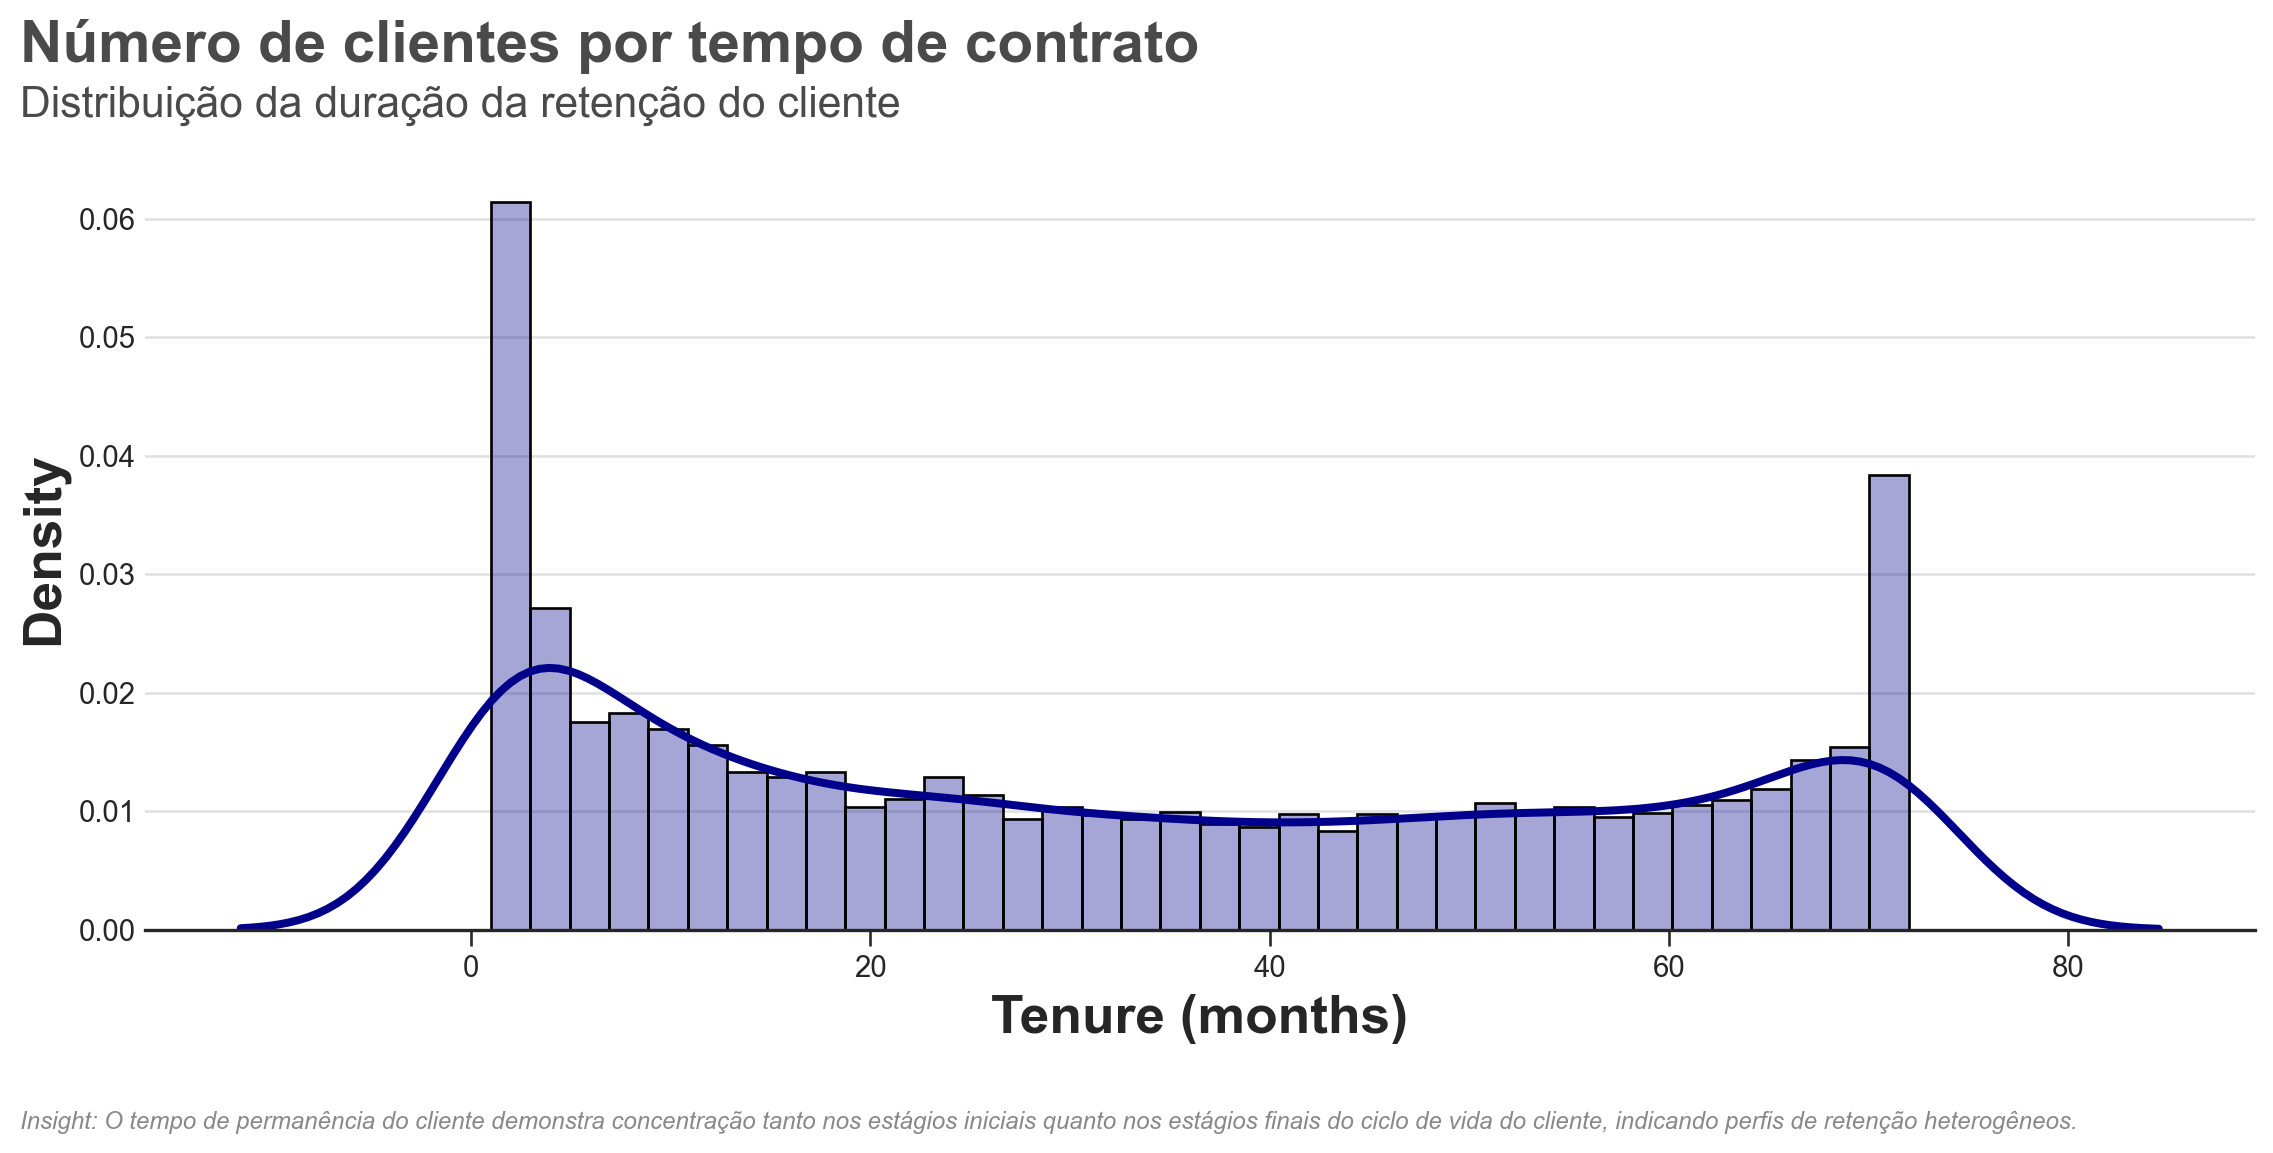

In [29]:
def plot_tenure_distribution(
    df,
    tenure_col='tenure',
    title="Number of Customers by Tenure",
    subtitle="Customer retention duration distribution",
    footer_text=None,
    show_footer=False,
    bins=36,
    color='darkblue'
):
    """
    Plot tenure distribution using histogram + KDE.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    tenure_col : str
        Name of the tenure column.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    bins : int
        Number of bins for histogram.
    color : str
        Histogram/KDE color.
    """

    fig, ax = plt.subplots(figsize=(12, 6))

    # Histograma + KDE
    """sns.distplot(
        df[tenure_col],
        hist=True,
        kde=True,
        bins=bins,
        color=color,
        hist_kws={'edgecolor': 'black', 'alpha': 0.35},
        kde_kws={'linewidth': 3},
        ax=ax
    )"""
    
    sns.histplot(
        df[tenure_col],
        bins=bins,
        color=color,
        edgecolor='black',
        alpha=0.35,
        stat='density',
        ax=ax
    )

    sns.kdeplot(
        df[tenure_col],
        color=color,
        linewidth=3,
        ax=ax
    )

    # Rótulos
    ax.set_xlabel('Tenure (months)')
    ax.set_ylabel('Density')

    # Manter legibilidade similar à versão aprovada
    format_corporate_axes(
        ax,
        hide_y_spine_only=True,
        hide_y_entirely=False,
        grid=True,
        grid_axis='y'
    )

    # Cabeçalho
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Rodapé
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_tenure_distribution(
    telecom,
    tenure_col='tenure',
    title="Número de clientes por tempo de contrato",
    subtitle="Distribuição da duração da retenção do cliente",
    footer_text="Insight: O tempo de permanência do cliente demonstra concentração tanto nos estágios iniciais quanto nos estágios finais do ciclo de vida do cliente, indicando perfis de retenção heterogêneos.",
    show_footer=True
)    

**Insights:**
- A distribuição está concentrada nos primeiros meses do relacionamento.
- Uma segunda concentração aparece entre clientes com longa permanência.
- Isso sugere diferentes perfis de retenção, provavelmente associados ao tipo de contrato.

<span style="color:steelblue; text-align: left">

### Distribuição de Contratos
</span>

Para interpretar melhor a distribuição de permanência, é útil primeiro examinar como os clientes estão distribuídos entre os tipos de contrato.


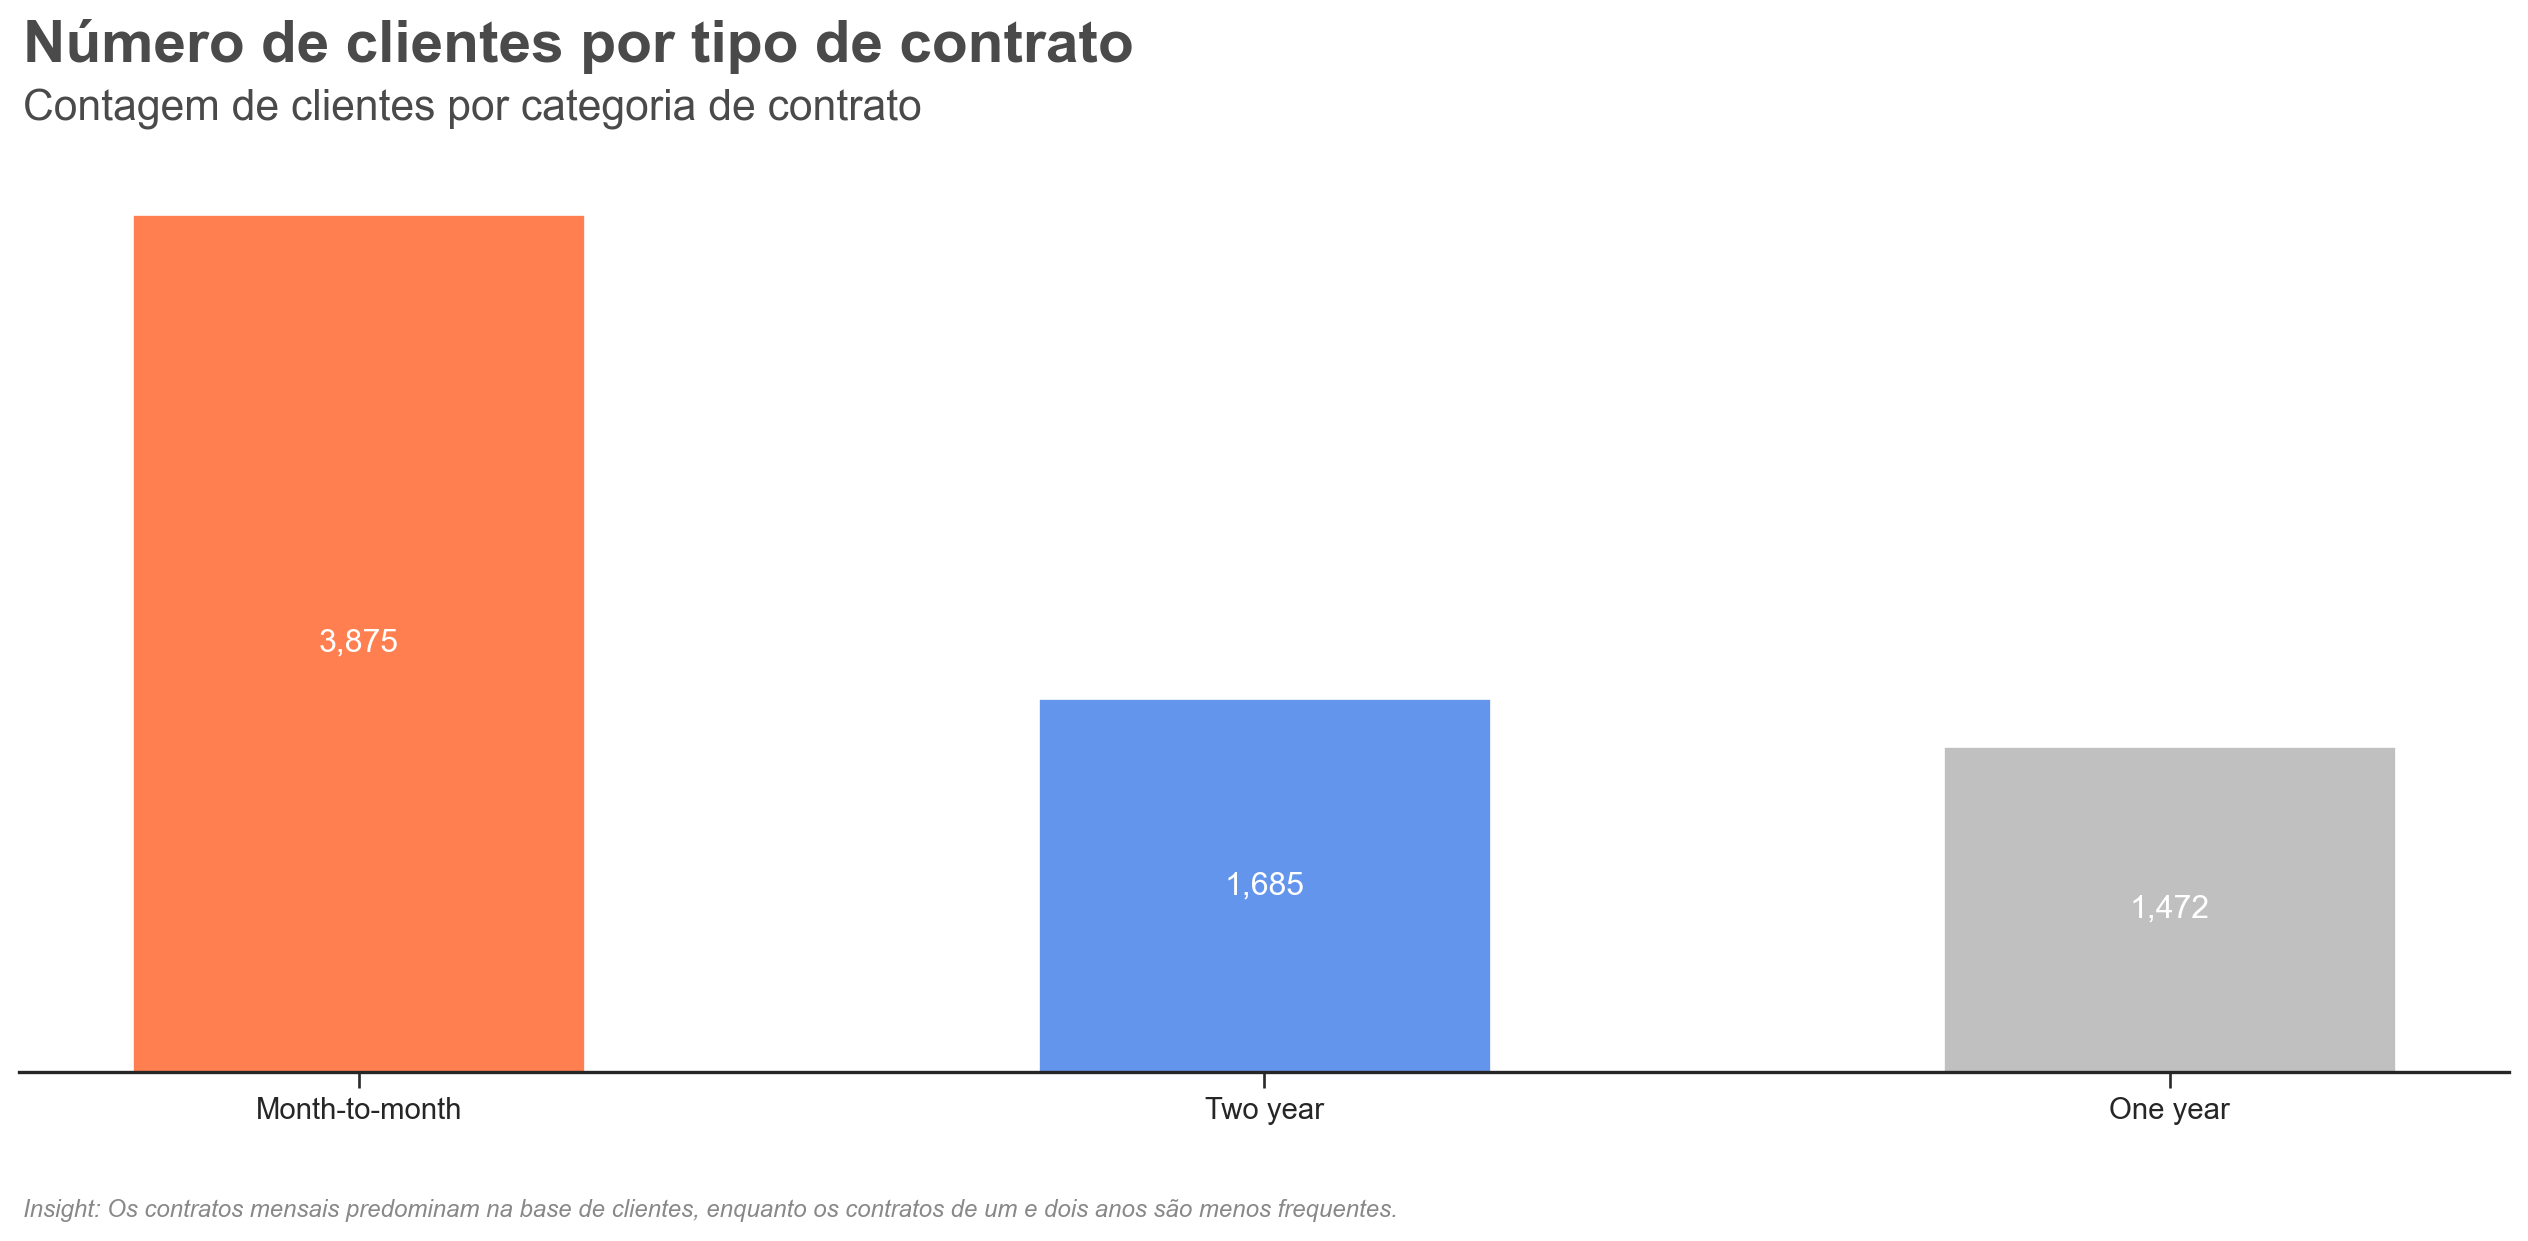

In [30]:
def plot_contract_distribution(
    df,
    contract_col='Contract',
    title="Number of Customers by Contract Type",
    subtitle="Customer count by contract category",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue', 'silver')
):
    """
    Plot the number of customers in each contract type.
    """

    counts = df[contract_col].value_counts()

    labels = counts.index.tolist()
    values = counts.values.tolist()

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, width=0.5, color=list(palette[:len(labels)]))

    ax.bar_label(bars, fmt='{:,.0f}', label_type='center', color='white', fontsize=12)

    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_contract_distribution(
    telecom,
    contract_col='Contract',
    title="Número de clientes por tipo de contrato",
    subtitle="Contagem de clientes por categoria de contrato",
    footer_text="Insight: Os contratos mensais predominam na base de clientes, enquanto os contratos de um e dois anos são menos frequentes.",
    show_footer=True
)    

**Insights:**
- A maioria dos clientes está em contratos mensais.
- Contratos anuais e bianuais têm representação menor e relativamente similar.
- Esta concentração em contratos de curto prazo é relevante, pois o tipo de contrato provavelmente influencia o comportamento de retenção.

A seguir, a permanência é examinada separadamente para cada tipo de contrato.


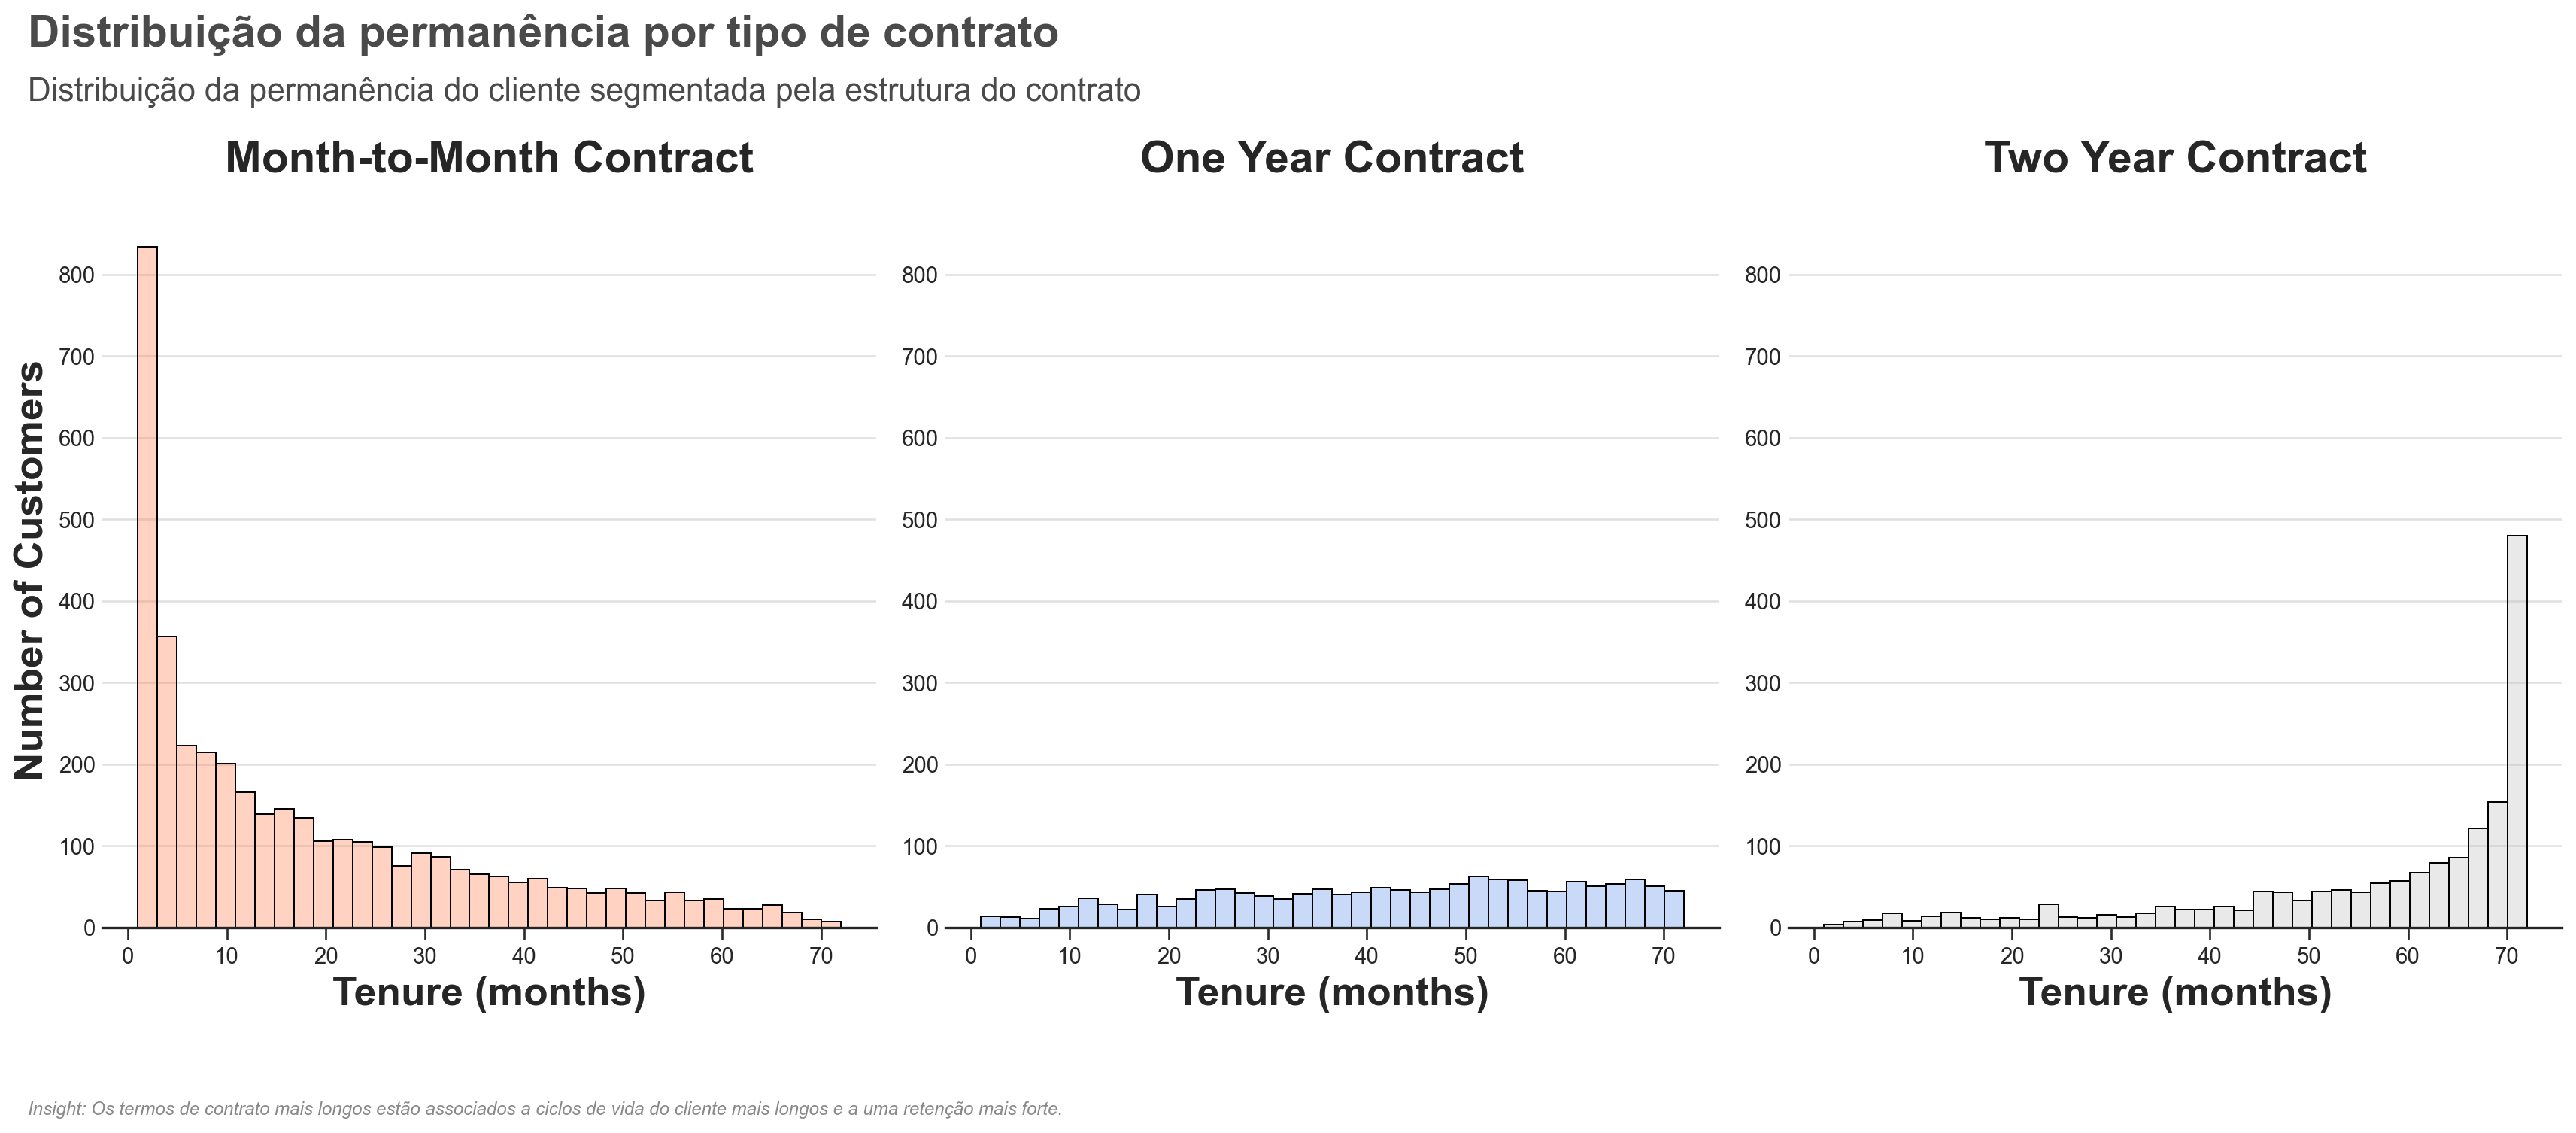

In [31]:
def plot_tenure_by_contract(
    df,
    contract_col='Contract',
    tenure_col='tenure',
    title="Tenure Distribution by Contract Type",
    subtitle="Customer tenure segmented by contract structure",
    footer_text=None,
    show_footer=False,
    bins=36,
    palette=('coral', 'cornflowerblue', 'silver')
):
    """
    Plot tenure distributions separately for each contract type.
    """

    contract_order = ['Month-to-month', 'One year', 'Two year']
    subplot_titles = ['Month-to-Month Contract', 'One Year Contract', 'Two Year Contract']

    fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(18, 8))

    for ax, contract_name, subplot_title, color in zip(axes, contract_order, subplot_titles, palette):
        subset = df[df[contract_col] == contract_name]

        sns.histplot(
            subset[tenure_col],
            bins=bins,
            kde=False,
            color=color,
            edgecolor='black',
            alpha=0.35,
            ax=ax
        )

        ax.set_title(subplot_title)
        ax.set_xlabel('Tenure (months)')

        if ax is axes[0]:
            ax.set_ylabel('Number of Customers')
            format_corporate_axes(
                ax,
                hide_y_spine_only=True,
                hide_y_entirely=False,
                grid=True,
                grid_axis='y'
            )
        else:
            ax.set_ylabel('')
            format_corporate_axes(
                ax,
                hide_y_spine_only=True,
                hide_y_entirely=False,
                grid=True,
                grid_axis='y'
            )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.88])
    plt.show()
    
plot_tenure_by_contract(
    telecom,
    contract_col='Contract',
    tenure_col='tenure',
    title="Distribuição da permanência por tipo de contrato",
    subtitle="Distribuição da permanência do cliente segmentada pela estrutura do contrato",
    footer_text="Insight: Os termos de contrato mais longos estão associados a ciclos de vida do cliente mais longos e a uma retenção mais forte.",
    show_footer=True
)    

**Insights:**
- Contratos mensais estão fortemente concentrados em permanências curtas, indicando uma maior proporção de clientes recentemente adquiridos ou menos retidos.
- Contratos anuais mostram uma distribuição de permanência mais equilibrada, com clientes distribuídos em durações intermediárias e longas.
- Contratos bianuais estão concentrados em valores altos de permanência, sugerindo maior retenção e ciclos de vida mais longos dos clientes.
- No geral, contratos mais longos estão associados a maior persistência do cliente, reforçando a importância da estrutura contratual no comportamento de churn.

<span style="color:steelblue; text-align: left">

### Distribuição de Serviços
</span>

O próximo passo é examinar a distribuição dos serviços contratados pelos clientes. Para simplificar a interpretação, as categorias `Sem serviço de internet` e `Sem serviço telefônico` são recodificadas como `Não`, para que os gráficos se concentrem em se o serviço está efetivamente disponível ou não.


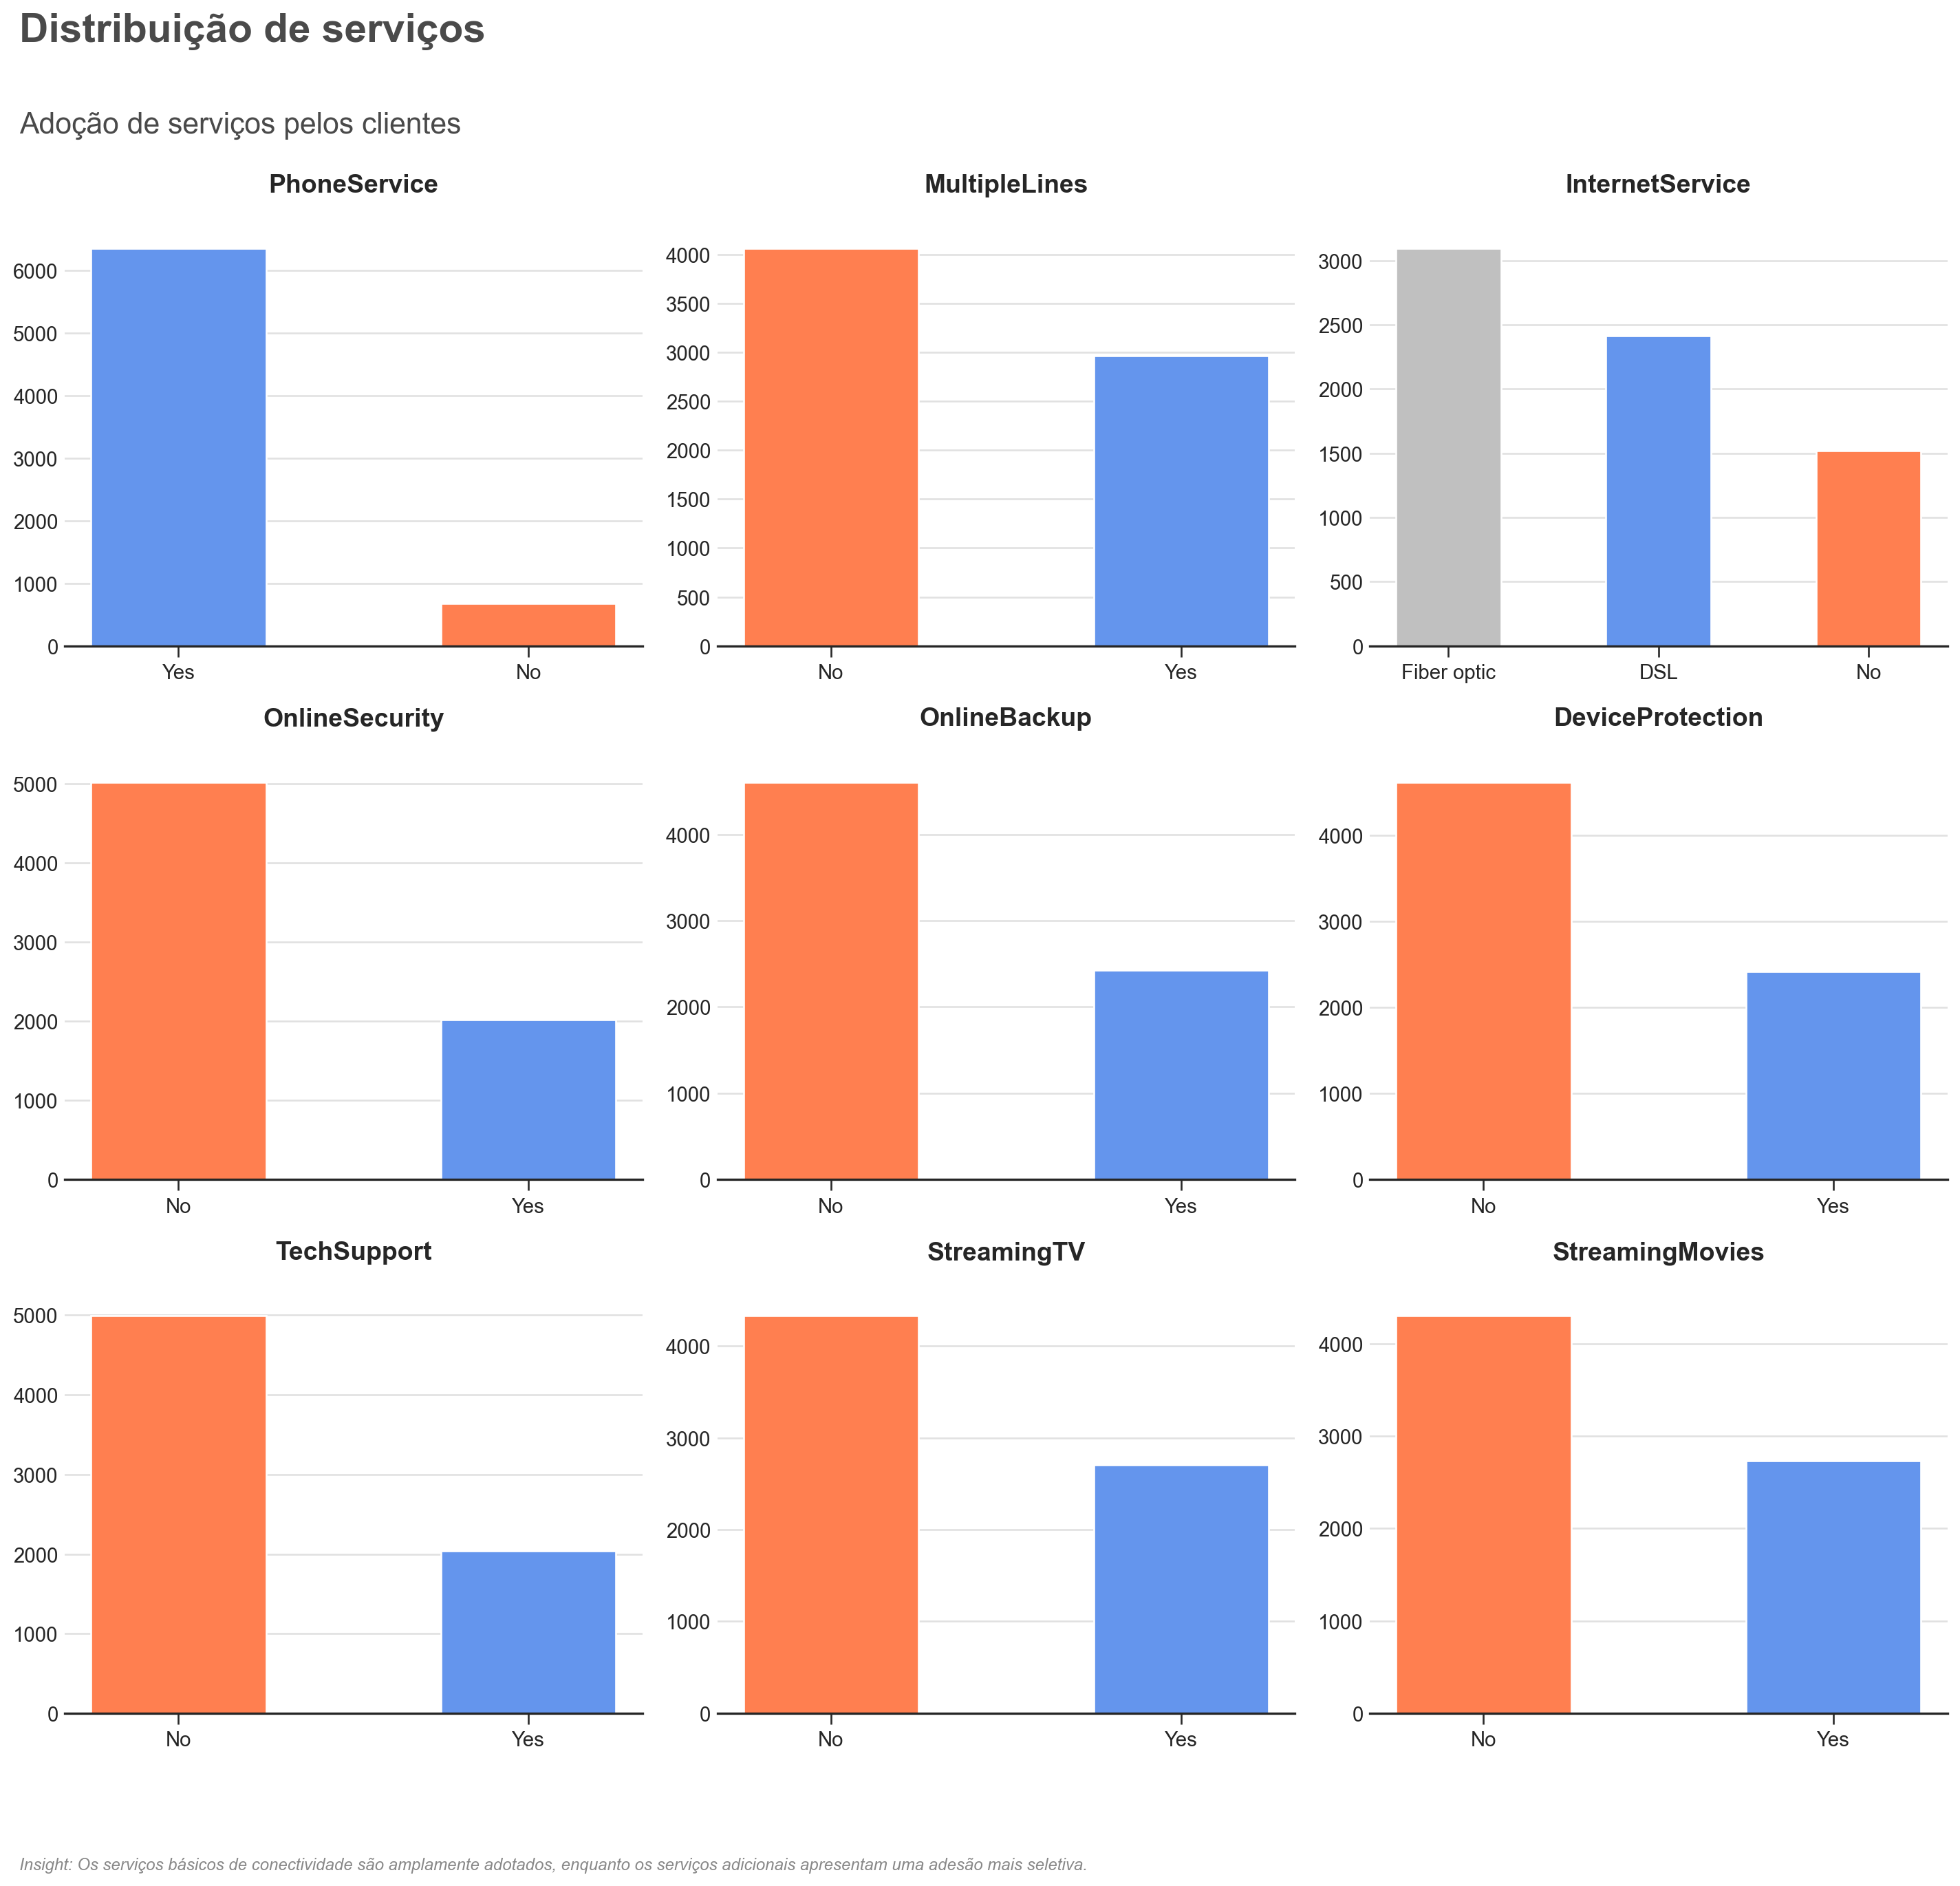

In [32]:
def plot_services_distribution(
    df,
    services=None,
    title="Services Distribution",
    subtitle="Customer adoption across subscribed services",
    footer_text=None,
    show_footer=False
):
    """
    Plot service distributions in a 3x3 grid with consistent category colors.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    services : list or None
        List of service columns to plot.
    title : str
        Figure title.
    subtitle : str
        Figure subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    """

    data = df.copy()

    # Recodificar estados negativos de serviços como 'Não'
    data = data.replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

    if services is None:
        services = [
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]

    # Mapeamento consistente de cores
    color_map = {
        'No': 'coral',
        'Yes': 'cornflowerblue',
        'Fiber optic': 'silver',
        'DSL': 'cornflowerblue',
        'Month-to-month': 'coral',   # deixo aqui caso queira reutilizar lógica
        'One year': 'silver',
        'Two year': 'cornflowerblue'
    }

    fallback_color = 'silver'

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
    axes = axes.flatten()

    for i, col in enumerate(services):
        ax = axes[i]

        counts = data[col].value_counts()

        labels = counts.index.tolist()
        values = counts.values.tolist()

        bar_colors = [color_map.get(label, fallback_color) for label in labels]

        bars = ax.bar(labels, values, color=bar_colors, width=0.5)

        ax.set_title(col, fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Grade horizontal ajuda leitura aqui
        format_corporate_axes(
            ax,
            hide_y_spine_only=True,
            hide_y_entirely=False,
            grid=True,
            grid_axis='y'
        )

        ax.tick_params(axis='x', rotation=0)

    # Header e footer no padrão
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    #plt.tight_layout(rect=[0, 0.06, 1, 0.92])
    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_services_distribution(
    telecom,
    title="Distribuição de serviços",
    subtitle="Adoção de serviços pelos clientes",
    footer_text="Insight: Os serviços básicos de conectividade são amplamente adotados, enquanto os serviços adicionais apresentam uma adesão mais seletiva.",
    show_footer=True
)    

**Insights:**
- Serviços essenciais de conectividade como `PhoneService`, `MultipleLines` e `InternetService` mostram ampla adoção na base de clientes.
- Serviços de valor agregado como `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` e `StreamingMovies` são adotados de forma menos uniforme.
- Essa variação sugere que pacotes de serviços podem ajudar a distinguir perfis de clientes e devem ser examinados posteriormente em relação ao churn.


<span style="color:steelblue; text-align: left">

## Análise Multivariada
</span>

Esta seção examina as relações entre variáveis com o objetivo de identificar padrões de dependência, possível multicolinearidade e associações relevantes para a modelagem de churn.

<span style="color:steelblue; text-align: left">

###  Correlação de Pearson
</span>

A correlação de Pearson é aplicada primeiramente às variáveis numéricas para avaliar as relações lineares entre elas.


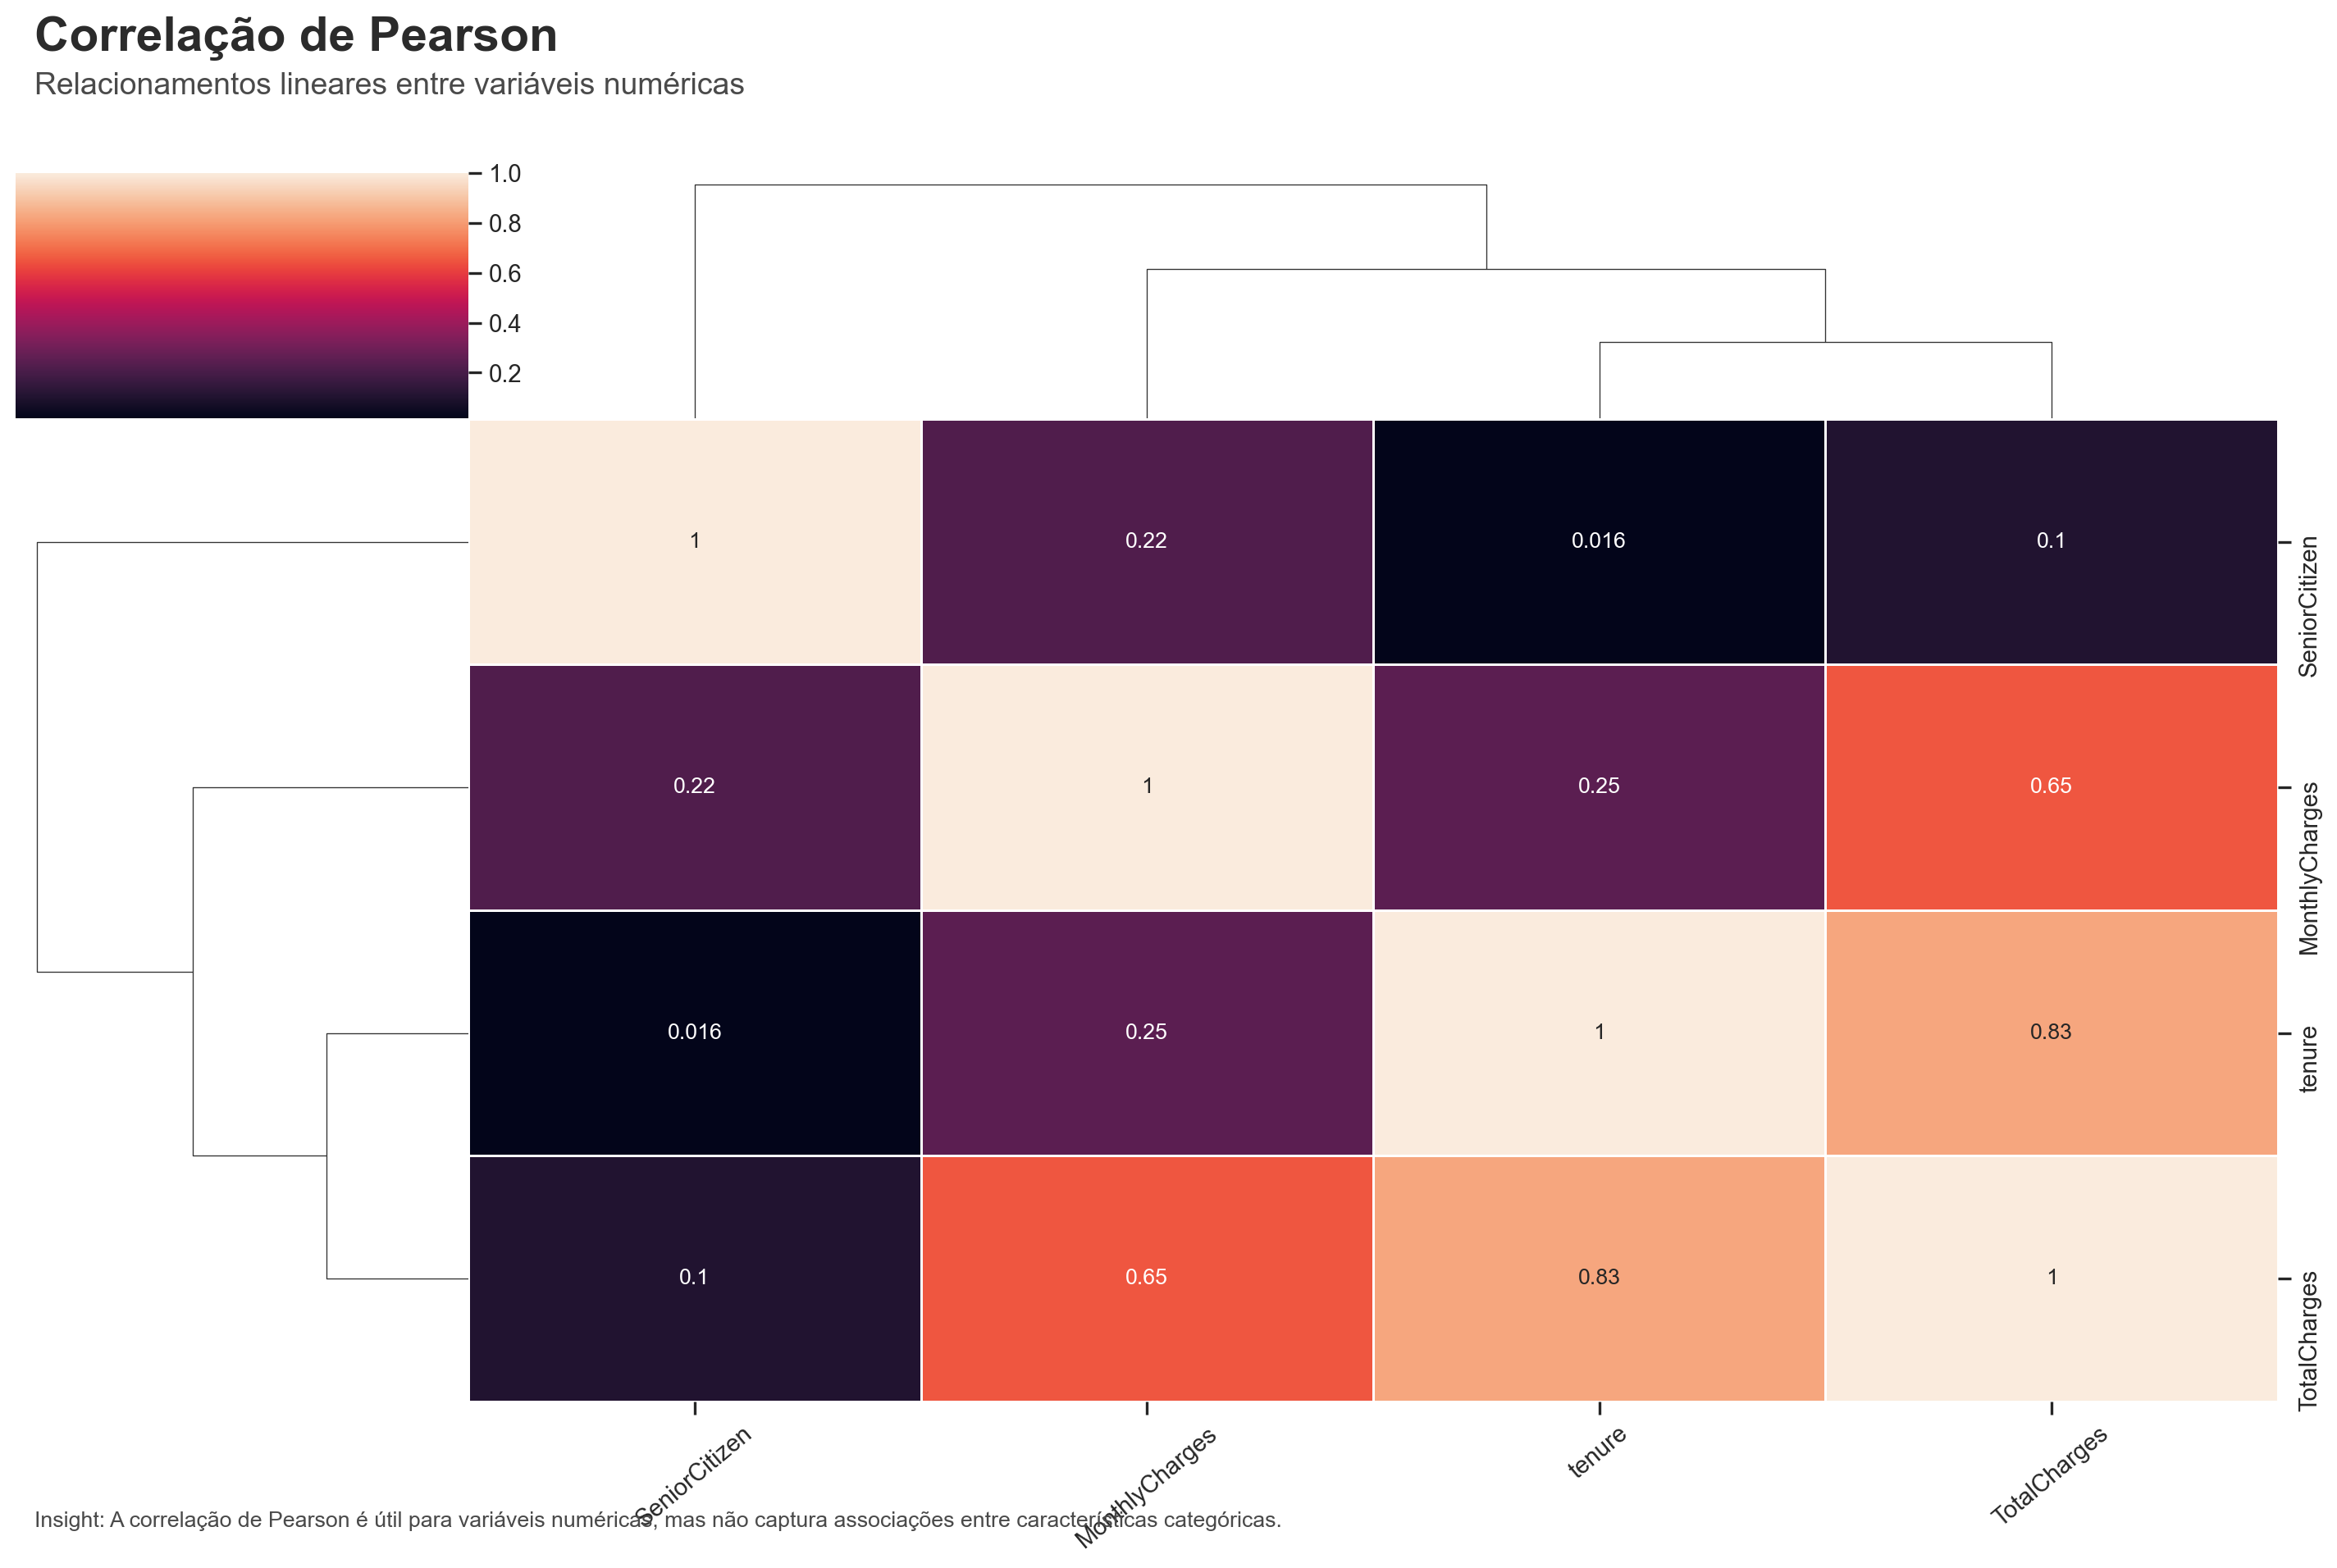

In [33]:
def plot_pearson_correlation(
    df,
    title="Pearson Correlation",
    subtitle="Linear relationships among numerical variables",
    footer_text=None,
    show_footer=False,
    annot=True,
    figsize=(15, 10)
):
    """
    Plot Pearson correlation clustermap for numerical variables only.
    """

    numerical_features = df.select_dtypes(exclude=['category', 'object']).columns.tolist()
    corr_matrix = df[numerical_features].corr(method='pearson')

    cg = sns.clustermap(
        corr_matrix,
        annot=annot,
        annot_kws={"size": 10},
        linewidths=0.4,
        figsize=figsize,
        cmap="rocket"
    )

    # Rótulos dos ticks
    plt.setp(
        cg.ax_heatmap.xaxis.get_majorticklabels(),
        rotation=40
    )

    fig = cg.figure

    # Cabeçalho
    fig.suptitle(title, x=0.02, y=0.98, ha='left', fontsize=22, fontweight='bold', color='#2b2b2b')
    if subtitle:
        fig.text(0.02, 0.93, subtitle, ha='left', fontsize=14, color='#4a4a4a')

    # Rodapé
    if show_footer and footer_text:
        fig.text(0.02, 0.02, footer_text, ha='left', fontsize=10, color='#4a4a4a')

    # Layout
    fig.subplots_adjust(top=0.93 if not subtitle else 0.88, bottom=0.08 if not show_footer else 0.10)

    plt.show()

    return corr_matrix

pearson_corr = plot_pearson_correlation(
    telecom,
    title="Correlação de Pearson",
    subtitle="Relacionamentos lineares entre variáveis numéricas",
    footer_text="Insight: A correlação de Pearson é útil para variáveis numéricas, mas não captura associações entre características categóricas.",
    show_footer=True
)

**Insights:**
- A maioria das variáveis neste conjunto de dados é categórica, portanto a correlação de Pearson fornece apenas uma visão parcial da estrutura de dependência.
- Entre as variáveis numéricas, `tenure` e `TotalCharges` mostram forte correlação positiva, o que é esperado dada a natureza cumulativa da cobrança total.
- `MonthlyCharges` também mostra associação relevante com `TotalCharges`, embora sua relação com outras variáveis seja menos informativa isoladamente.
- Como a correlação de Pearson é limitada a variáveis numéricas e relações lineares, ela não é suficiente para avaliar associações neste conjunto de dados de tipo misto.

<span style="color:steelblue; text-align: left">

### Multicolinearidade e Correlação PhiK
</span>

Como este conjunto de dados contém um grande número de variáveis categóricas, a correlação de Pearson isolada não é adequada para avaliar a estrutura completa de dependência. Para abordar essa limitação, a correlação PhiK é usada como uma alternativa mais adequada para dados de tipo misto.

PhiK é útil neste contexto porque:
- lida com variáveis categóricas, ordinais e de intervalo de forma consistente;
- captura relações não lineares;
- é adequada para conjuntos de dados de tipo misto como este dataset de churn de telecom.


interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


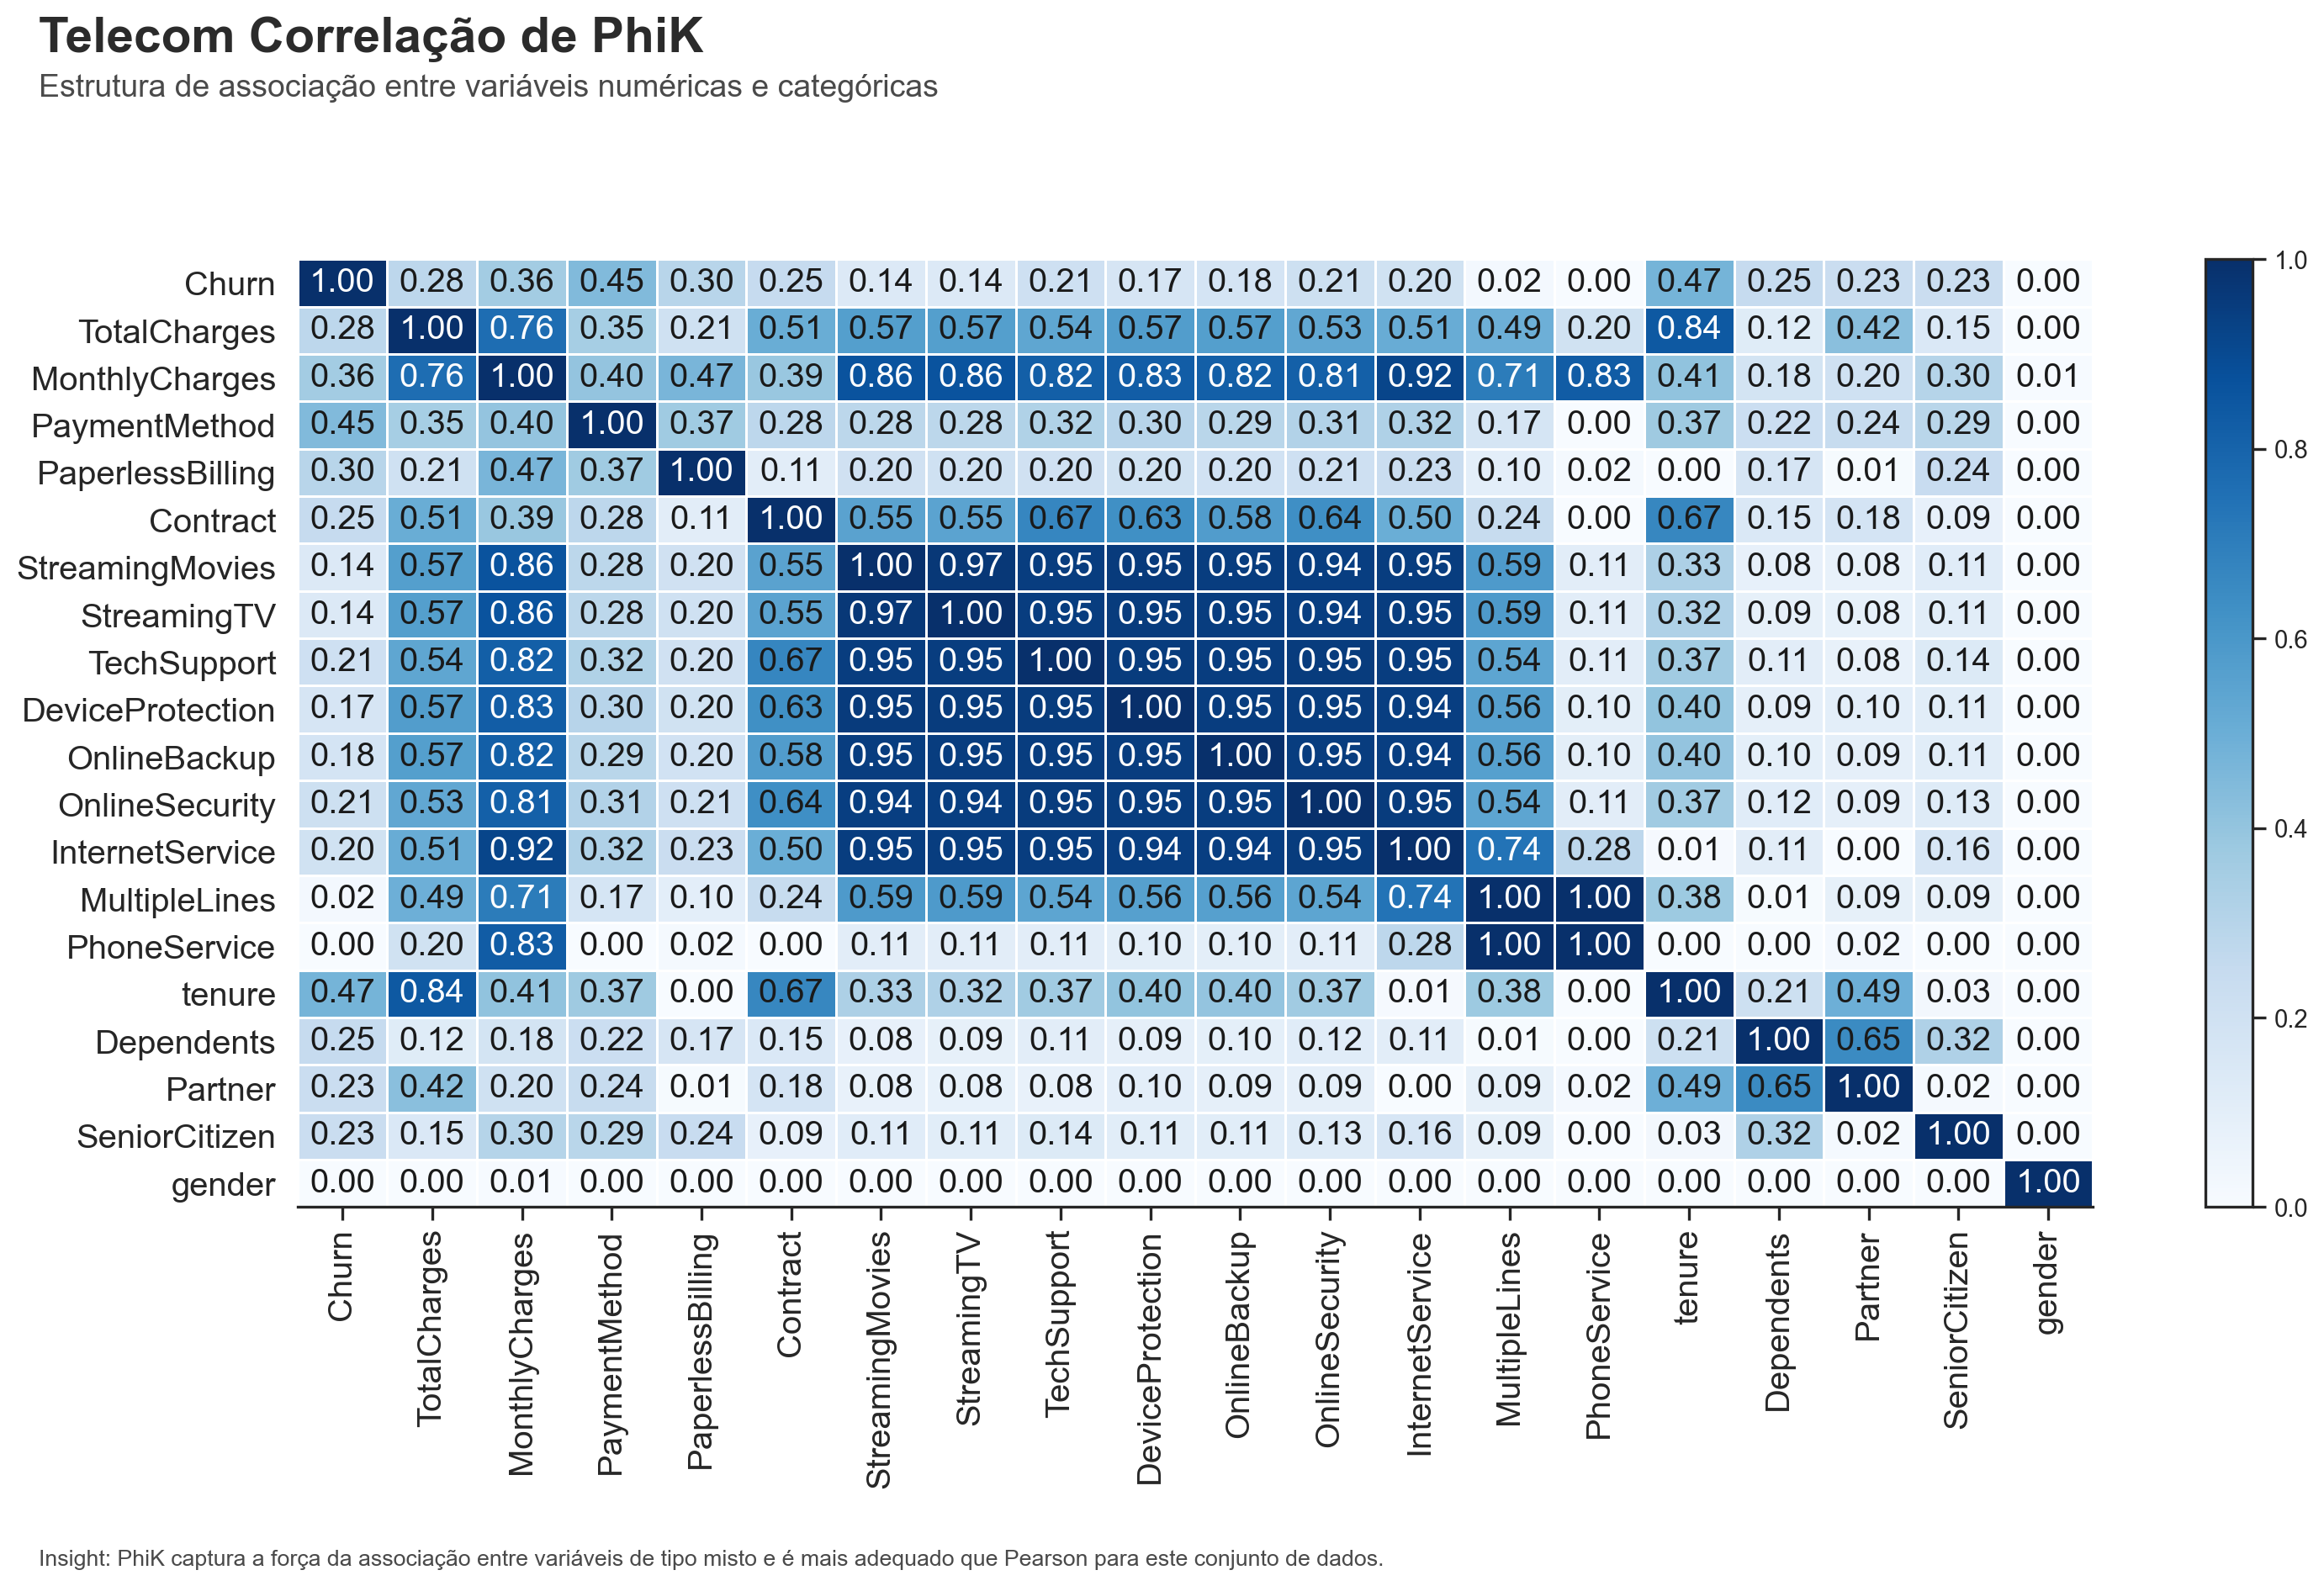

In [34]:
def plot_phik_correlation(
    df,
    drop_cols=None,
    title="Telecom PhiK Correlation",
    subtitle="Association structure across mixed-type variables",
    footer_text=None,
    show_footer=False,
    figsize=(16, 10),
    color_map="Blues"
):
    """
    Plot PhiK correlation matrix for mixed-type variables.
    """

    import phik
    from phik.report import plot_correlation_matrix

    data = df.copy(deep=True)

    if drop_cols is not None:
        data = data.drop(columns=drop_cols)

    phik_matrix = data.phik_matrix()

    plot_correlation_matrix(
        phik_matrix.values,
        x_labels=phik_matrix.columns,
        y_labels=phik_matrix.index,
        vmin=0,
        vmax=1,
        color_map=color_map,
        title="",
        fontsize_factor=1.5,
        figsize=figsize
    )

    fig = plt.gcf()

    # Cabeçalho
    fig.suptitle(title, x=0.02, y=0.98, ha='left', fontsize=22, fontweight='bold', color='#2b2b2b')
    if subtitle:
        fig.text(0.02, 0.93, subtitle, ha='left', fontsize=14, color='#4a4a4a')

    # Rodapé
    if show_footer and footer_text:
        fig.text(0.02, 0.02, footer_text, ha='left', fontsize=10, color='#4a4a4a')

    plt.tight_layout(rect=[0, 0.05 if show_footer else 0.06, 1, 0.90])
    plt.show()

    return phik_matrix

phik_view = plot_phik_correlation(
    telecom,
    drop_cols=['customerID'],
    title="Telecom Correlação de PhiK",
    subtitle="Estrutura de associação entre variáveis numéricas e categóricas",
    footer_text="Insight: PhiK captura a força da associação entre variáveis de tipo misto e é mais adequado que Pearson para este conjunto de dados.",
    show_footer=True
)

**Insights:**
- PhiK fornece uma visão mais ampla dos padrões de associação entre variáveis numéricas e categóricas.
- Vários pares de variáveis mostram associação moderada a forte, especialmente entre características relacionadas a serviços, cobrança e contratos.
- Os valores de PhiK variam de 0 a 1 e medem apenas a força da associação, não a direção.
- Valores próximos de zero indicam associação fraca ou negligenciável.


interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


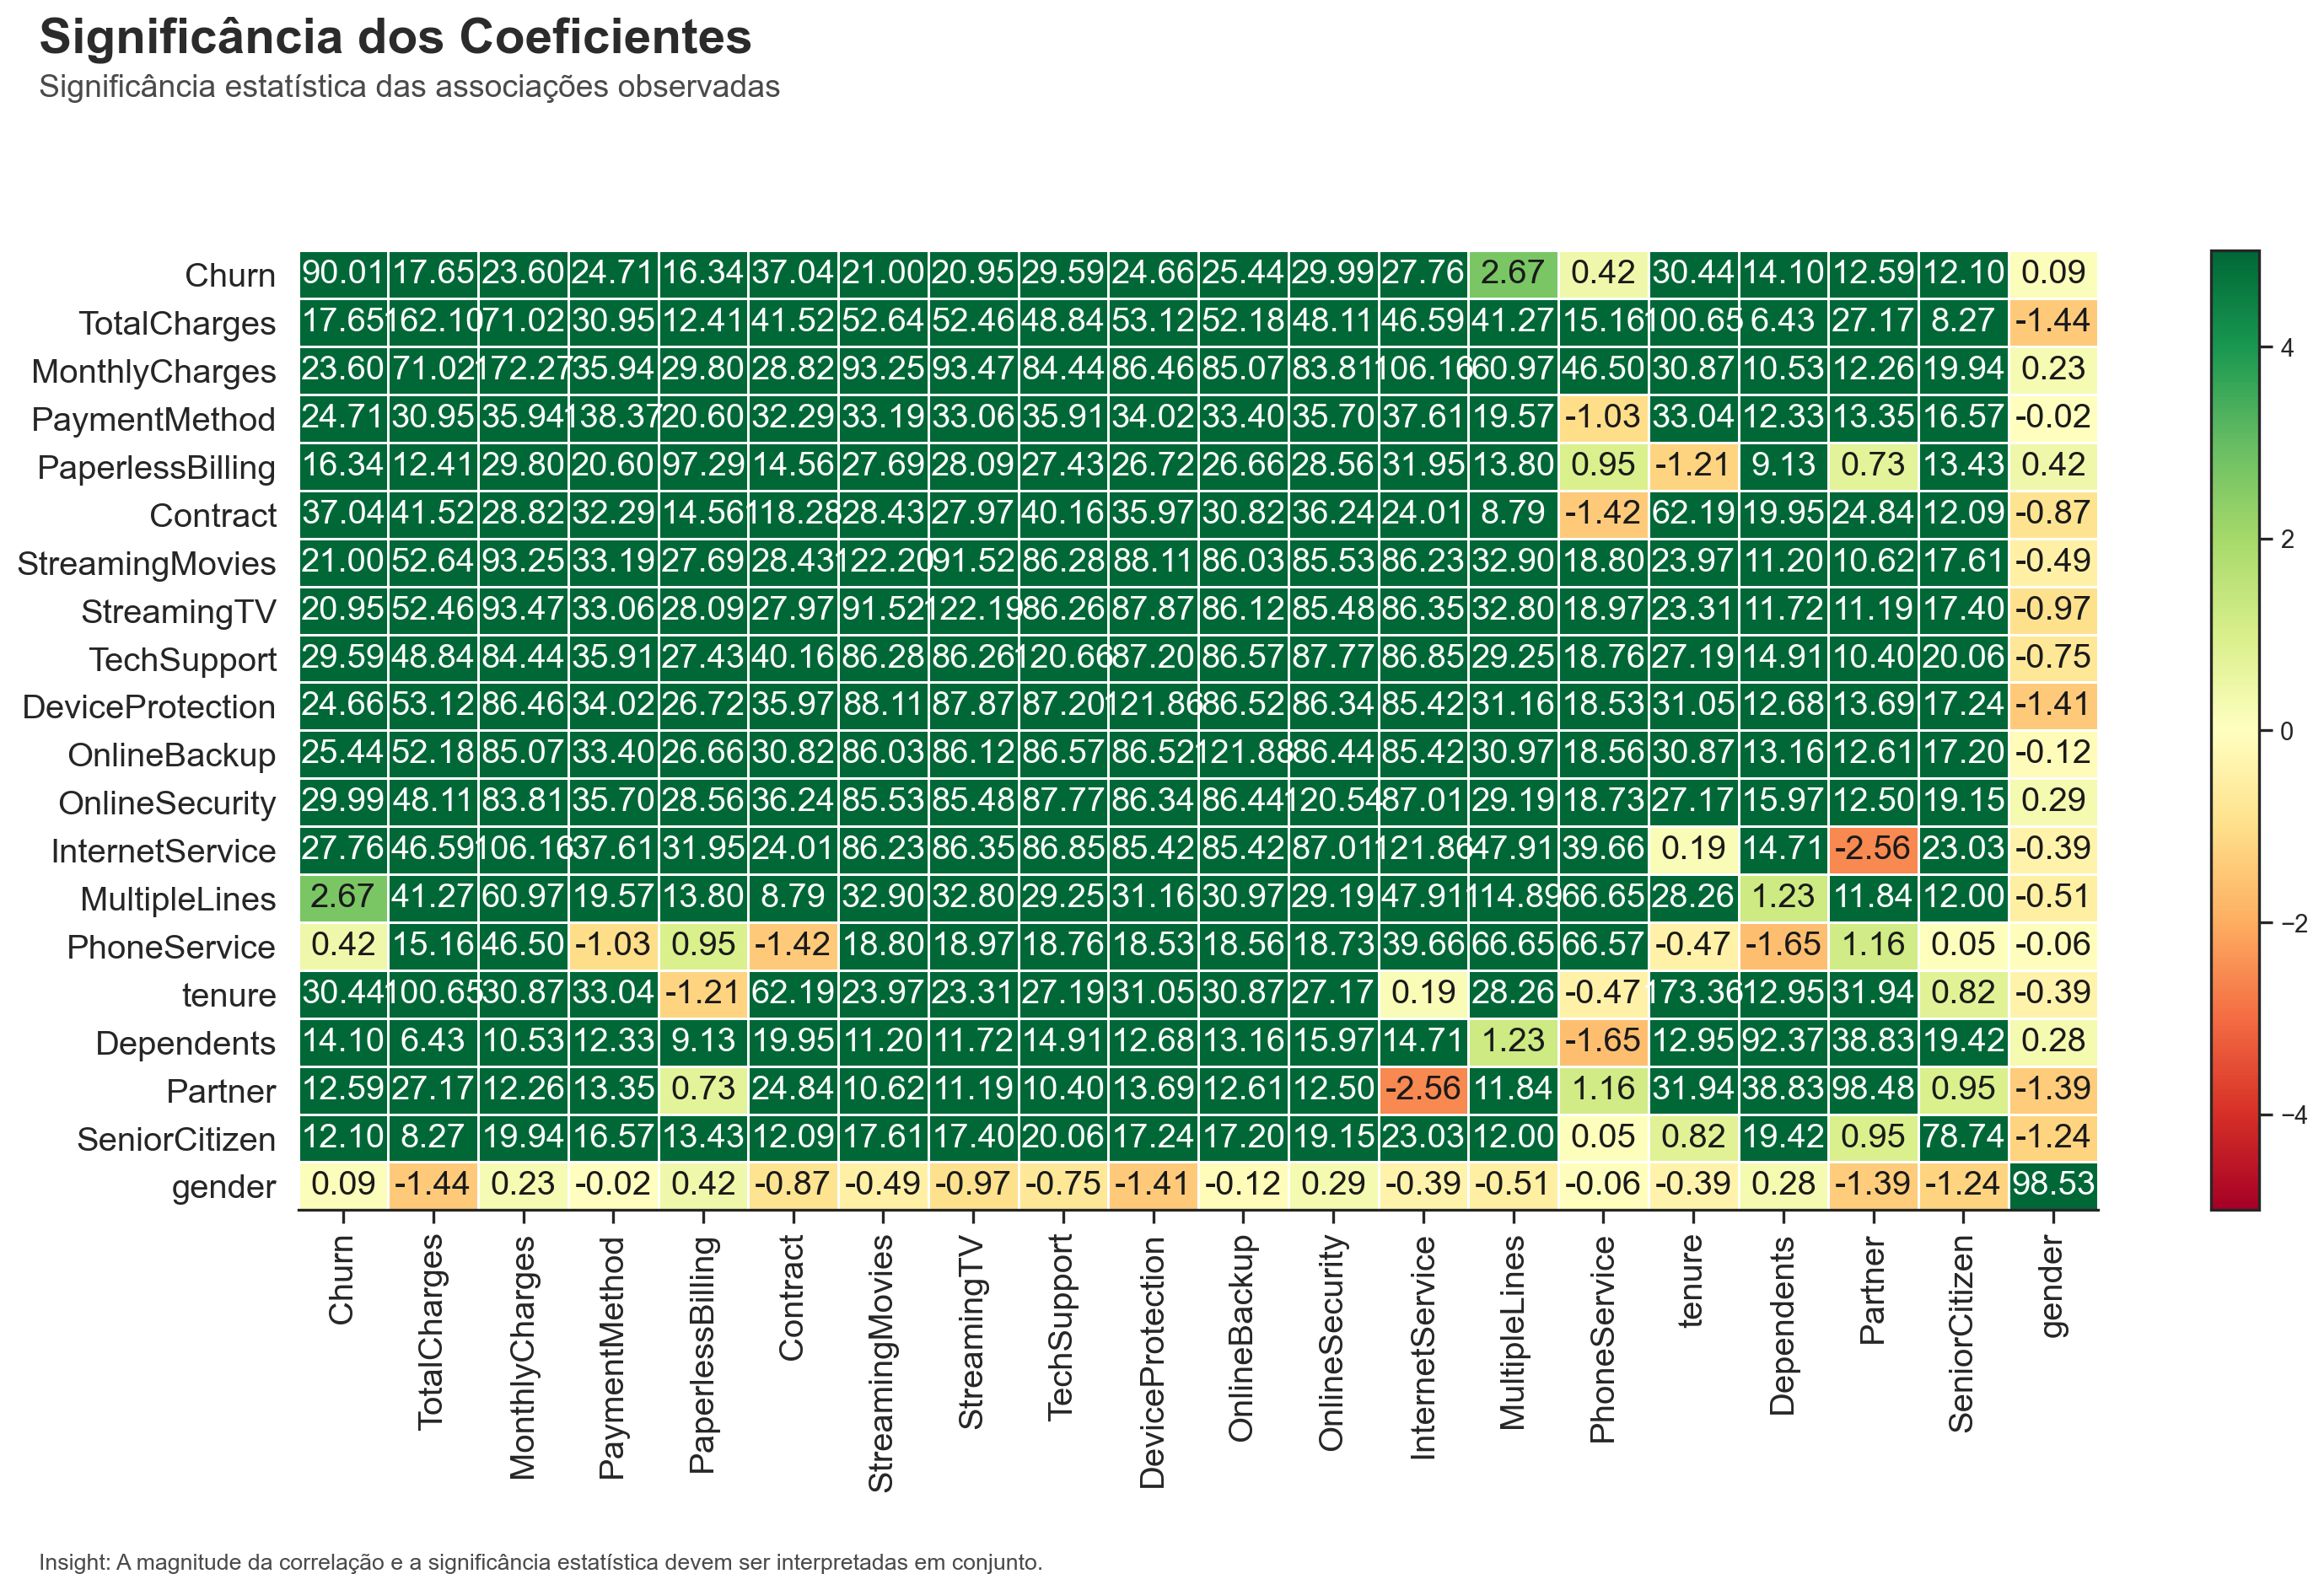

In [35]:
def plot_phik_significance(
    df,
    drop_cols=None,
    title="Significance of the Coefficients",
    subtitle="Statistical significance of observed associations",
    footer_text=None,
    show_footer=False,
    figsize=(16, 10)
):
    """
    Plot PhiK significance matrix.
    """

    import phik
    from phik.report import plot_correlation_matrix

    data = df.copy(deep=True)

    if drop_cols is not None:
        data = data.drop(columns=drop_cols)

    significance_overview = data.significance_matrix()

    plot_correlation_matrix(
        significance_overview.fillna(0).values,
        x_labels=significance_overview.columns,
        y_labels=significance_overview.index,
        vmin=-5,
        vmax=5,
        title="",
        usetex=False,
        fontsize_factor=1.5,
        figsize=figsize
    )

    fig = plt.gcf()

    # Cabeçalho
    fig.suptitle(title, x=0.02, y=0.98, ha='left', fontsize=22, fontweight='bold', color='#2b2b2b')
    if subtitle:
        fig.text(0.02, 0.93, subtitle, ha='left', fontsize=14, color='#4a4a4a')

    # Rodapé
    if show_footer and footer_text:
        fig.text(0.02, 0.02, footer_text, ha='left', fontsize=10, color='#4a4a4a')

    plt.tight_layout(rect=[0, 0.05 if show_footer else 0.06, 1, 0.90])
    plt.show()

    return significance_overview

significance_overview = plot_phik_significance(
    telecom,
    drop_cols=['customerID'],
    title="Significância dos Coeficientes",
    subtitle="Significância estatística das associações observadas",
    footer_text="Insight: A magnitude da correlação e a significância estatística devem ser interpretadas em conjunto.",
    show_footer=True
)

A matriz de significância complementa a matriz de correlação PhiK mostrando se as associações observadas são estatisticamente significativas.

**Insights:**
- A força da correlação e a significância estatística devem ser interpretadas em conjunto.
- Uma associação forte pode não ser estatisticamente significativa, enquanto uma mais fraca ainda pode ser altamente significativa.
- Isso ajuda a distinguir padrões de dependência relevantes dos incidentais.


In [92]:
def build_phik_significance_df(df, drop_cols=None):
    """
    Build a dataframe with variable pairs, Phik correlation and significance.
    """

    import phik
    
    data = df.copy()

    if drop_cols:
        data = data.drop(columns=drop_cols)

    phik_matrix = data.phik_matrix()
    significance_matrix = data.significance_matrix()

    records = []

    cols = phik_matrix.columns

    for i in range(len(cols)):
        for j in range(i+1, len(cols)):  # evita duplicados e diagonal
            var1 = cols[i]
            var2 = cols[j]

            records.append({
                'var1': var1,
                'var2': var2,
                'phik': phik_matrix.iloc[i, j],
                'significance': significance_matrix.iloc[i, j]
            })

    result_df = pd.DataFrame(records)

    return result_df.sort_values(by='phik', ascending=False)

phik_df = build_phik_significance_df(telecom, drop_cols=['customerID'])
phik_df.head(15).round(4)

interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.0000,66.6472
162,StreamingTV,StreamingMovies,0.9654,91.5199
147,DeviceProtection,StreamingMovies,0.9538,88.1193
146,DeviceProtection,StreamingTV,0.9528,87.8751
126,OnlineSecurity,TechSupport,0.9526,87.7718
145,DeviceProtection,TechSupport,0.9502,87.1954
112,InternetService,OnlineSecurity,0.9495,87.0049
115,InternetService,TechSupport,0.9489,86.8568
136,OnlineBackup,TechSupport,0.9477,86.5822
135,OnlineBackup,DeviceProtection,0.9475,86.5178


**Insights**:
- Fortes dependências são observadas entre variáveis relacionadas a cobrança (MonthlyCharges, TotalCharges, tenure), confirmando a estrutura cumulativa da receita do cliente ao longo do tempo.
- Características relacionadas a serviços (ex.: StreamingTV, StreamingMovies, PhoneService) mostram alta associação com MonthlyCharges, indicando que serviços adicionais são os principais fatores dos gastos do cliente.
- O tipo de contrato apresenta forte relação com a permanência, reforçando o papel dos contratos de longo prazo na retenção de clientes.
- Variáveis relacionadas ao domicílio (Partner, Dependents) também são altamente associadas, refletindo o agrupamento demográfico esperado.


In [93]:
def filter_relevant_relationships(df, phik_threshold=0.3, significance_threshold=5):
    """
    Filter relevant relationships based on Phik and significance.
    """

    return df[
        (df['phik'] >= phik_threshold) &
        (df['significance'] >= significance_threshold)
    ].sort_values(by='phik', ascending=False)
    
relevant_pairs = filter_relevant_relationships(phik_df)
relevant_pairs.head(15).round(4)    

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.0000,66.6472
162,StreamingTV,StreamingMovies,0.9654,91.5199
147,DeviceProtection,StreamingMovies,0.9538,88.1193
146,DeviceProtection,StreamingTV,0.9528,87.8751
126,OnlineSecurity,TechSupport,0.9526,87.7718
145,DeviceProtection,TechSupport,0.9502,87.1954
112,InternetService,OnlineSecurity,0.9495,87.0049
115,InternetService,TechSupport,0.9489,86.8568
136,OnlineBackup,TechSupport,0.9477,86.5822
135,OnlineBackup,DeviceProtection,0.9475,86.5178


Quais variáveis têm relação com o churn? 

In [94]:
phik_df[phik_df['var2'] == 'Churn'].sort_values(by='phik', ascending=False)

,var1,var2,phik,significance
84,tenure,Churn,0.473761,30.459420
186,PaymentMethod,Churn,0.448559,24.710898
188,MonthlyCharges,Churn,0.359612,23.575549
183,PaperlessBilling,Churn,0.295194,16.327708
189,TotalCharges,Churn,0.280973,17.607667
69,Dependents,Churn,0.252268,14.075288
179,Contract,Churn,0.251283,37.025895
36,SeniorCitizen,Churn,0.232897,12.086202
53,Partner,Churn,0.232215,12.584268
134,OnlineSecurity,Churn,0.211583,29.980467


**Insights**:
- A permanência do cliente surge como o principal fator de churn, indicando que clientes em estágio inicial têm significativamente mais probabilidade de sair, reforçando a importância de estratégias de onboarding e retenção antecipada.
- O método de pagamento mostra forte associação com o churn, sugerindo que o atrito nos processos de cobrança ou comportamento financeiro pode influenciar a retenção de clientes.
- As cobranças mensais estão positivamente associadas ao churn, indicando que um custo percebido mais alto pode aumentar a probabilidade de atrito.
- O tipo de contrato, apesar de uma correlação moderada, apresenta muito alta significância estatística, destacando sua importância estrutural na retenção de clientes — contratos mais longos provavelmente atuam como mecanismos de retenção.
- Características relacionadas a serviços como OnlineSecurity e TechSupport mostram associação moderada com o churn, sugerindo que clientes sem esses serviços podem ser mais vulneráveis a sair.
- Variáveis demográficas (ex.: gênero) não mostram relação significativa com o churn, indicando que fatores comportamentais e contratuais dominam sobre características pessoais estáticas.


Onde existe multicolinearidade? 

In [95]:
phik_df[phik_df['phik'] > 0.7]

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.000000,66.647197
162,StreamingTV,StreamingMovies,0.965356,91.519915
147,DeviceProtection,StreamingMovies,0.953754,88.119260
146,DeviceProtection,StreamingTV,0.952815,87.875059
126,OnlineSecurity,TechSupport,0.952637,87.771755
145,DeviceProtection,TechSupport,0.950238,87.195356
112,InternetService,OnlineSecurity,0.949461,87.004950
115,InternetService,TechSupport,0.948878,86.856793
136,OnlineBackup,TechSupport,0.947746,86.582167
135,OnlineBackup,DeviceProtection,0.947480,86.517770


**Insights de Multicolinearidade**:
- Forte multicolinearidade é observada entre variáveis relacionadas a cobrança (tenure, MonthlyCharges, TotalCharges), refletindo a natureza cumulativa da cobrança do cliente. Em particular, TotalCharges se comporta como uma característica derivada em vez de um preditor independente.
- Várias características relacionadas a serviços (ex.: StreamingTV, StreamingMovies, PhoneService) mostram alta associação com MonthlyCharges, indicando que os preços dos clientes são amplamente determinados pela adoção de serviços em pacote.
- Alta correlação entre variáveis de serviço (ex.: StreamingTV e StreamingMovies) sugere padrões comportamentais sobrepostos dos clientes, potencialmente introduzindo redundância no espaço de características.
- Essas dependências refletem a lógica de negócio subjacente em vez de relações estatísticas espúrias, e devem ser tratadas cuidadosamente durante o desenvolvimento do modelo para evitar redundância e instabilidade.
- Para mitigar efeitos de multicolinearidade em modelos lineares, TotalCharges será excluído do conjunto de características, pois é uma variável derivada.


Relações fortes mas inúteis ou redundantes? 

In [96]:
phik_df[(phik_df['phik'] > 0.8) & (phik_df['significance'] > 50)]

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.000000,66.647197
162,StreamingTV,StreamingMovies,0.965356,91.519915
147,DeviceProtection,StreamingMovies,0.953754,88.119260
146,DeviceProtection,StreamingTV,0.952815,87.875059
126,OnlineSecurity,TechSupport,0.952637,87.771755
145,DeviceProtection,TechSupport,0.950238,87.195356
112,InternetService,OnlineSecurity,0.949461,87.004950
115,InternetService,TechSupport,0.948878,86.856793
136,OnlineBackup,TechSupport,0.947746,86.582167
135,OnlineBackup,DeviceProtection,0.947480,86.517770


**Relações fortes: redundância vs relevância**:
- A relação entre tenure e TotalCharges representa uma dependência determinística, pois as cobranças totais são inerentemente uma função da permanência e das cobranças mensais. Portanto, TotalCharges é considerada uma característica redundante e pode ser excluída de modelos lineares.
- A associação entre InternetService e MonthlyCharges reflete a estrutura de preços do negócio, onde o tipo de serviço influencia diretamente a cobrança. Embora altamente correlacionadas, ambas as variáveis capturam aspectos distintos (categoria de serviço vs. custo) e podem ser mantidas dependendo dos objetivos do modelo.
- Características relacionadas a serviços como StreamingTV e StreamingMovies mostram fortes relações com MonthlyCharges, indicando que os preços são amplamente determinados pelos serviços em pacote. Essas relações representam redundância parcial, pois a adoção de serviços está indiretamente codificada na variável de cobrança.
- No geral, as altas correlações observadas são primariamente impulsionadas pela lógica de negócio em vez de artefatos estatísticos, e devem ser tratadas seletivamente para equilibrar interpretabilidade e desempenho do modelo.


<span style="color:steelblue; text-align: left">

###  Churn vs Permanência
</span>

A permanência do cliente mostra uma relação clara com o comportamento de churn. Clientes que permanecem com a empresa por períodos mais longos têm significativamente menos probabilidade de churnar, enquanto o churn está predominantemente concentrado entre clientes com permanência mais curta.

Esse padrão sugere que os estágios iniciais do ciclo de vida do cliente são críticos para a retenção, destacando a importância das estratégias de onboarding e engajamento inicial.


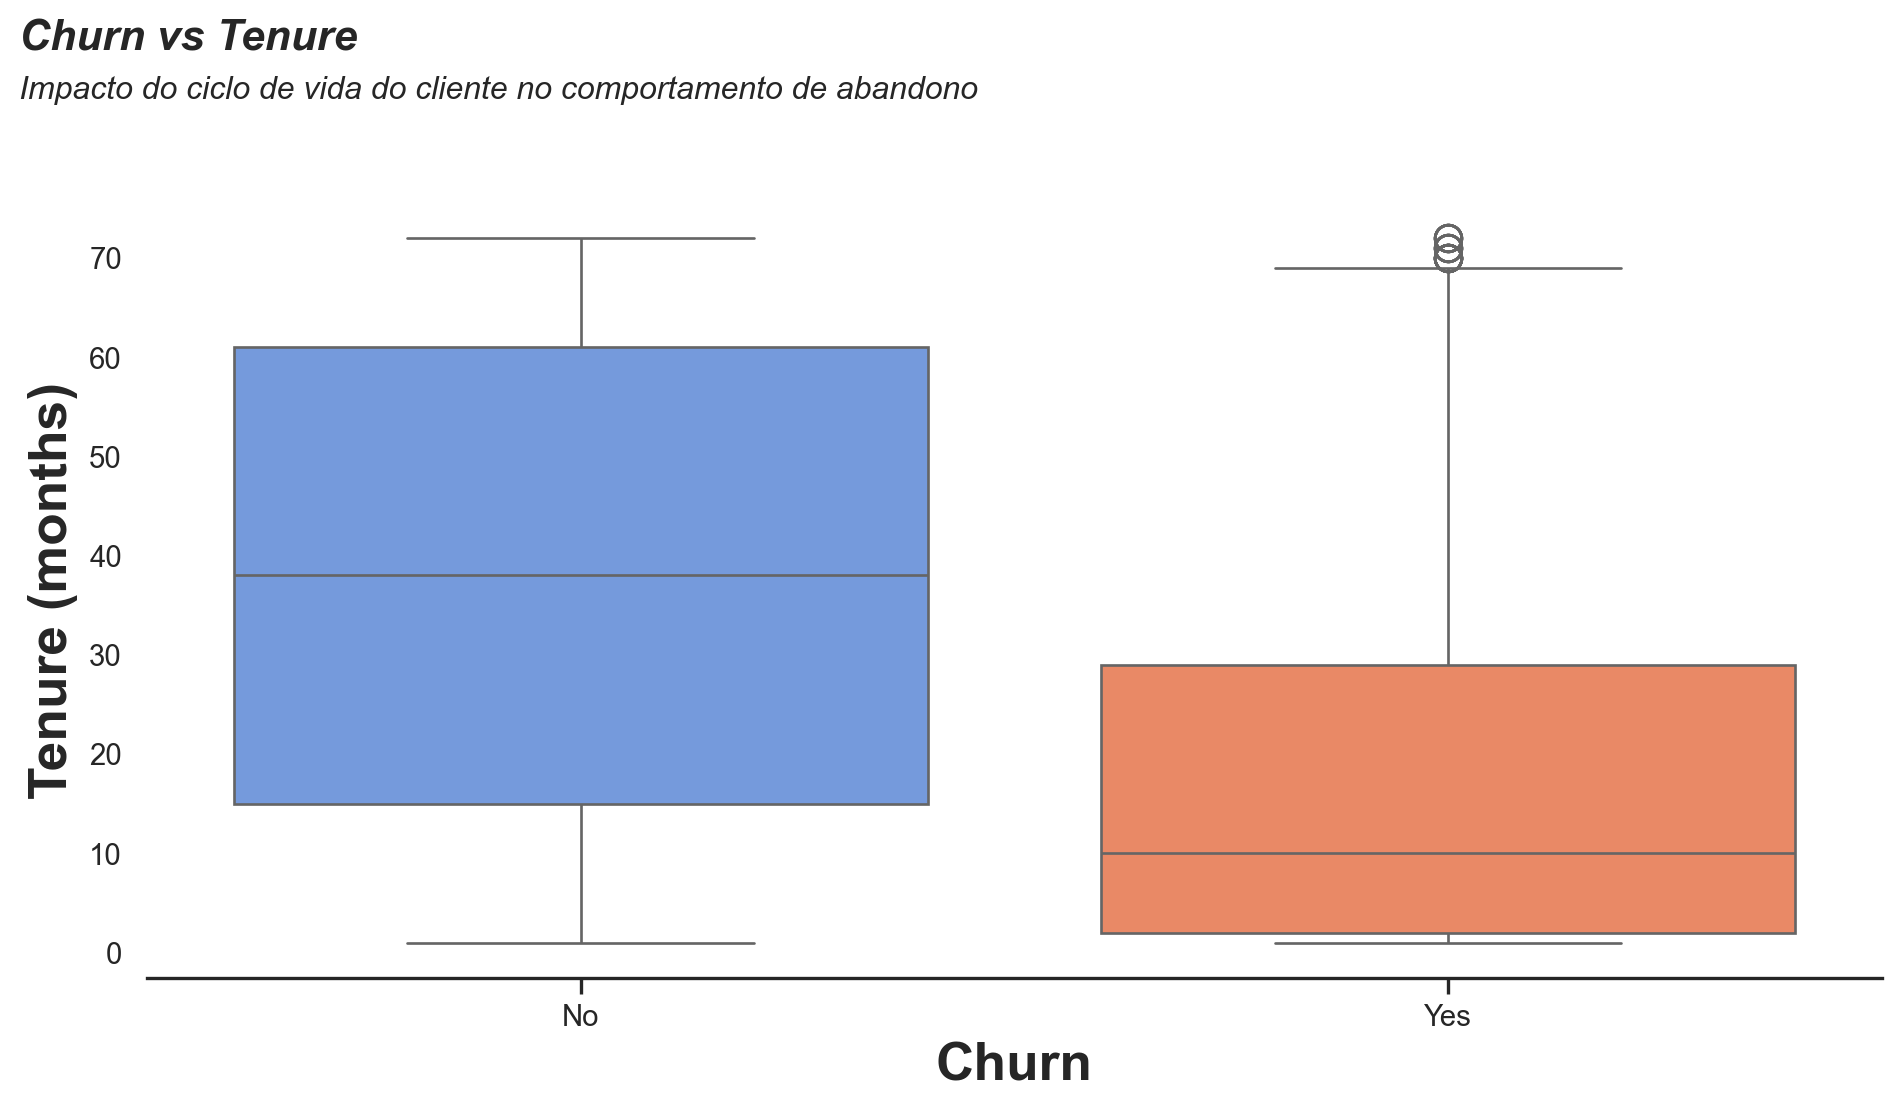

phik         = 0.4709
significance = 29.0650


In [36]:
def plot_churn_vs_tenure(df, churn_col='Churn', tenure_col='tenure'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import phik
    import pandas as pd

    data = df.copy()

    # Codificar churn
    data[churn_col] = data[churn_col].map({'No': 0, 'Yes': 1})

    # ===== Plot =====
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        x=df[churn_col],
        y=df[tenure_col],
        palette=['cornflowerblue', 'coral'],
        ax=ax
    )

    # Rótulos
    ax.set_xlabel('Churn')
    ax.set_ylabel('Tenure (months)')

    # ===== Header padrão =====
    add_finance_header(
        fig,
        title="Churn vs Tenure",
        subtitle="Impacto do ciclo de vida do cliente no comportamento de abandono"
    )

    plt.grid(False)
    plt.tight_layout()
    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

    # ===== Phik =====
    x, y = data[[churn_col, tenure_col]].T.values

    phik_value = phik.phik_from_array(x, y, num_vars=['x'])
    significance = phik.significance_from_array(x, y, num_vars=['x'])[1]

    print(f'phik         = {phik_value:.4f}')
    print(f'significance = {significance:.4f}')
    
plot_churn_vs_tenure(telecom)    

**Insights:**
- Clientes com menor permanência exibem taxas de churn significativamente mais altas, indicando que o risco de churn está concentrado nos estágios iniciais do ciclo de vida.
- Clientes que permanecem por mais tempo tendem a se estabilizar e têm menos probabilidade de sair, sugerindo um forte efeito de retenção ao longo do tempo.
- A permanência surge como um dos preditores mais fortes de churn, reforçando sua importância na modelagem subsequente.

<span style="color:steelblue; text-align: left">

###  Churn vs Contrato
</span>

Churn por Tipo de Contrato: Similar ao que vimos no gráfico de correlação, os clientes com contrato mês a mês têm uma taxa de churn muito alta.


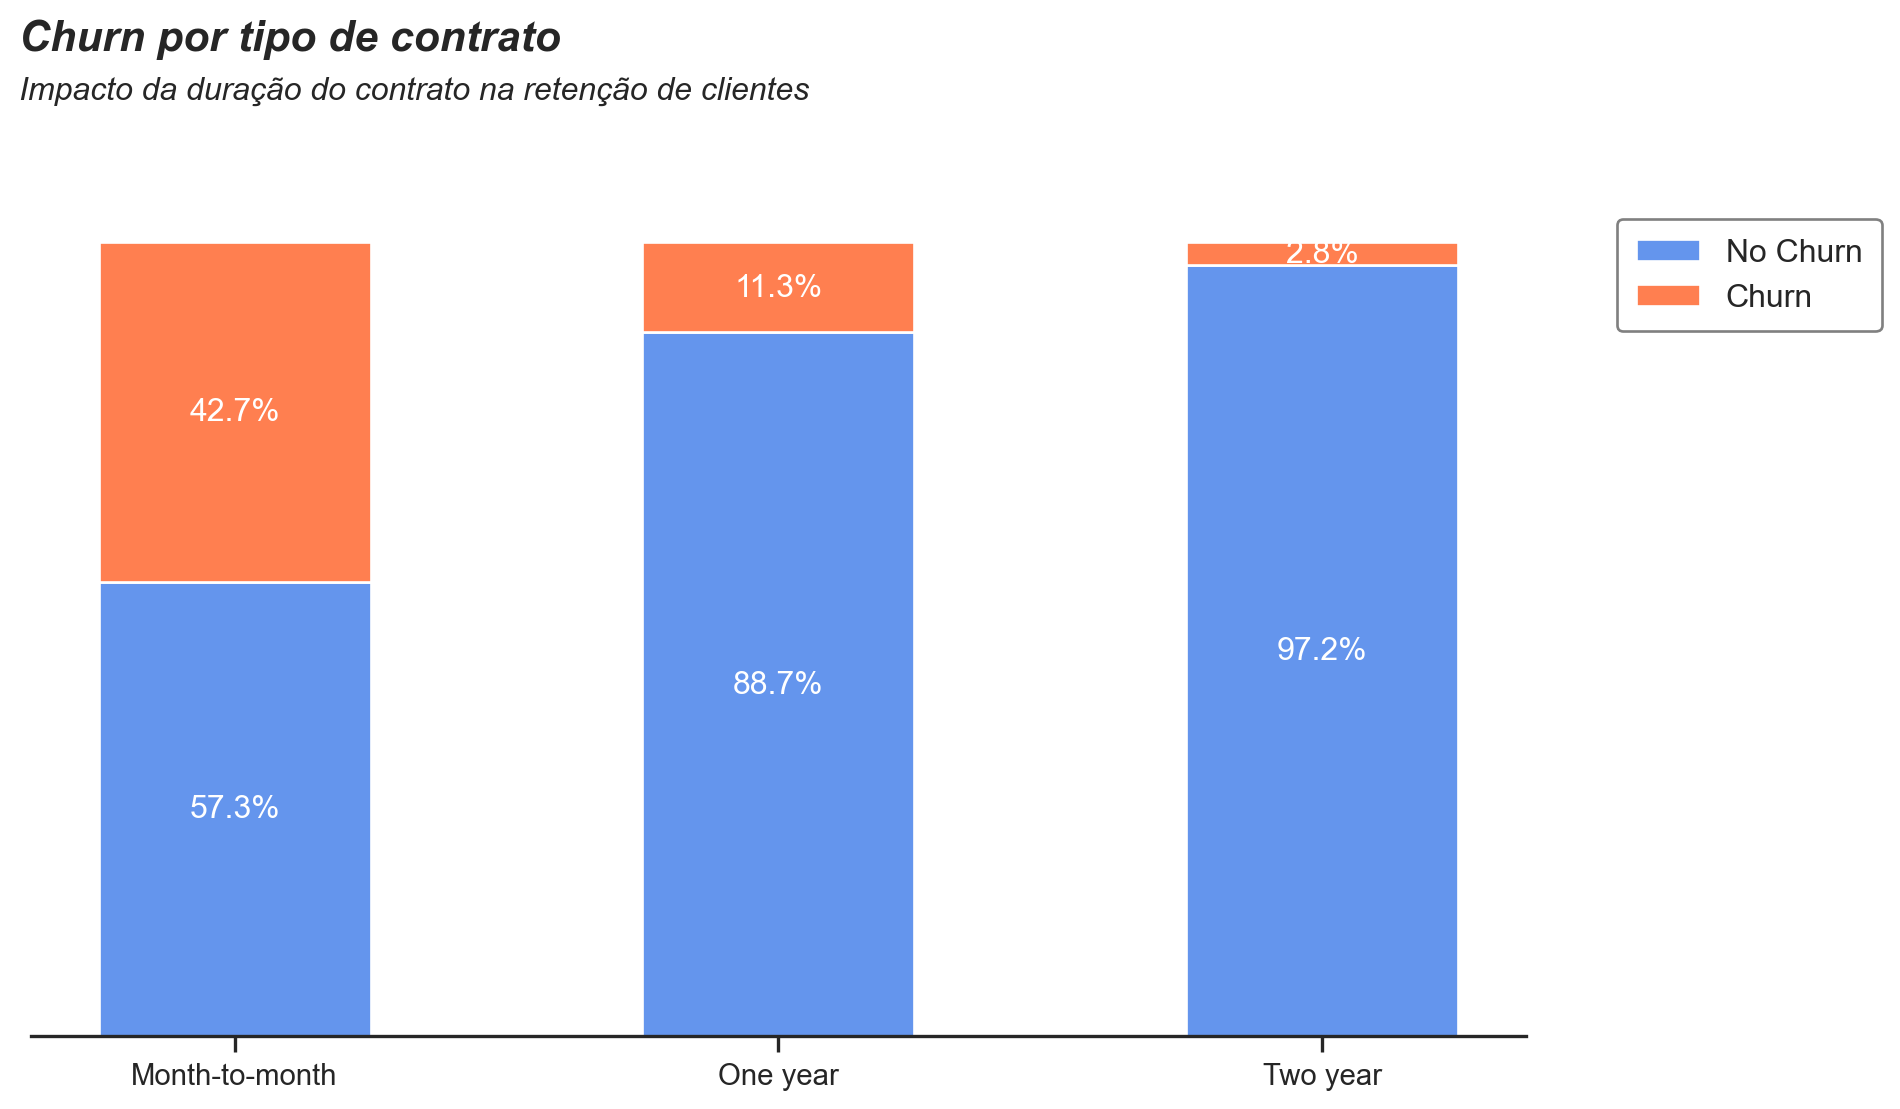

phik         = 0.2513
significance = 37.0447


In [37]:
def plot_churn_vs_contract(df, churn_col='Churn', contract_col='Contract'):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.ticker as mtick

    # ===== Preparação =====
    contract_churn = df.groupby([contract_col, churn_col]).size().unstack()

    pct = (contract_churn.T * 100.0 / contract_churn.T.sum()).T

    index = pct.index.tolist()

    data_plot = {
        'No Churn': pct['No'].values,
        'Churn': pct['Yes'].values
    }

    colors = ['cornflowerblue', 'coral']  # padrão consistente
    width = 0.5

    # ===== Plot =====
    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(index))

    for i, (label, values) in enumerate(data_plot.items()):
        bars = ax.bar(index, values, width, bottom=bottom, label=label, color=colors[i])
        ax.bar_label(bars, label_type='center', fmt='%.1f%%', color='white')
        bottom += values

    # ===== Header padrão =====
    add_finance_header(
        fig,
        title="Churn por tipo de contrato",
        subtitle="Impacto da duração do contrato na retenção de clientes"
    )

    ax.get_yaxis().set_visible(False)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(False)
    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

    # ===== Phik =====
    data = df.copy()
    data[churn_col] = data[churn_col].map({'No': 0, 'Yes': 1})

    x, y = data[[churn_col, contract_col]].T.values

    import phik
    phik_value = phik.phik_from_array(x, y)
    significance = phik.significance_from_array(x, y)[1]

    print(f'phik         = {phik_value:.4f}')
    print(f'significance = {significance:.4f}')
    
plot_churn_vs_contract(telecom)    

**Insights:**
- Clientes em contratos mensais exibem churn extremamente alto (~43%), indicando baixo compromisso e alta flexibilidade de troca.
- Migrar de contratos mensais para anuais reduz o churn em ~3,8x, enquanto contratos bianuais reduzem o churn em ~15x.
- Isso demonstra uma forte relação não linear entre duração do contrato e retenção, onde compromissos mais longos atuam como um poderoso mecanismo de retenção.
- O tipo de contrato não está apenas correlacionado com o churn — está estruturalmente ligado à estabilidade do ciclo de vida do cliente.


<span style="color:steelblue; text-align: left">

###  Churn vs Cobranças Mensais
</span>


Clientes com cobranças mensais mais altas exibem maior propensão ao churn.

Para melhor compreender o comportamento distribucional, analisamos assimetria e curtose:

- **Assimetria** mede a falta de simetria:
  - Positiva : cauda direita (valores mais altos)
  - Negativa : cauda esquerda (valores mais baixos)
  - Próxima de zero : distribuição simétrica

- **Curtose** mede o peso das caudas em relação a uma distribuição normal:
  - < 3 : Platicúrtica (caudas mais leves, menos outliers)
  - = 3 : Mesocúrtica (similar à normal)
  - > 3 : Leptocúrtica (caudas mais pesadas, mais valores extremos)

Esta análise ajuda a avaliar se as diferenças de churn são impulsionadas por mudanças estruturais ou pela forma distribucional.


In [38]:
import pandas as pd
import numpy as np
import sklearn
import optuna
import phik
import shap
import xgboost
import lightgbm
import imblearn
import seaborn as sns
import matplotlib.pyplot as plt

print("Ambiente OK 🚀")

Ambiente OK 🚀


In [39]:
def show_skewness(data:pd.DataFrame,x='', detail=''):
    l_skew = data[x].skew()
    l_kurtosis = data[x].kurt()
    l_mean = data[x].mean() 

    # Direita ou esquerda 
    if l_skew < 0:
        l_direction = ' Left '

    elif l_skew > 0:
        l_direction = ' Right '

    # Se a assimetria está entre -0.5 e 0.5, os dados são razoavelmente simétricos
    if l_skew > 0.5 and l_skew < 0.5:
        g_mess = x + ' variable are fairly symmetrical'

    # If the skewness is between -1 and — 0.5 or between 0.5 and 1, the data are moderately skewed
    elif l_skew > -1 and l_skew < 1: 
        g_mess = x + ' variable are moderately' + l_direction + 'Skewed'

    # Se a assimetria é menor que -1 ou maior que 1, os dados têm alta assimetria
    else:
        g_mess = x + ' variable are highly' + l_direction + 'Skewed'

    # Curtose
    if l_kurtosis > l_mean:
        l_mess_kurtosis = ' Leptokurtic '
    
    elif l_kurtosis < l_mean:
        l_mess_kurtosis = ' Platykurtic '
    
    else:
        l_mess_kurtosis = ' Mesokurtic '

    g_mess += l_mess_kurtosis
    print(f'''
    Skewness for {x} when customer {detail}:
        Skew     : {l_skew:.4f}
        Kurtosis : {l_kurtosis:.4f}
            - {g_mess}
    ''')


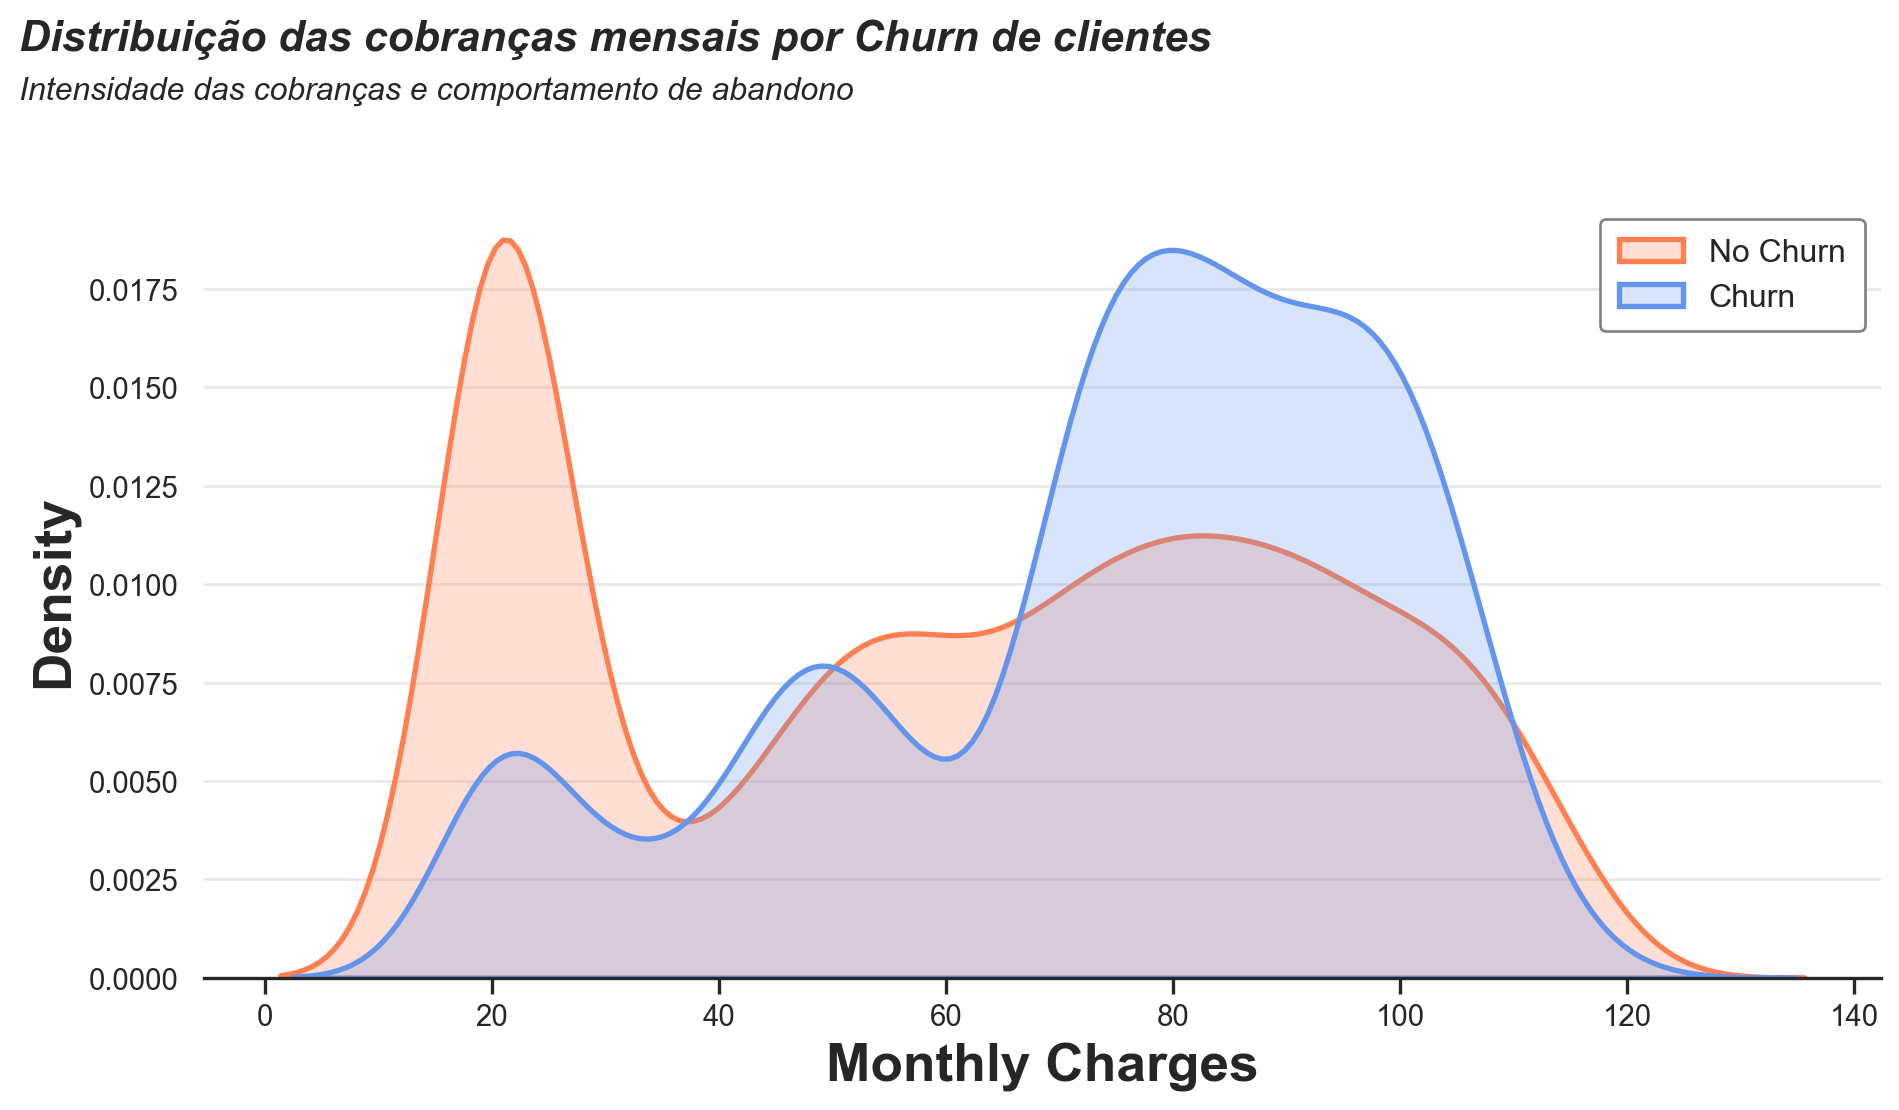


No Churn Distribution
  Skewness : -0.0268 (approximately symmetric)
  Kurtosis : -1.3552 (platykurtic)

Churn Distribution
  Skewness : -0.7294 (moderately skewed)
  Kurtosis : -0.3615 (platykurtic)

phik         = 0.3923
significance = 12.2039


In [40]:
def plot_churn_vs_monthly_charges(df: pd.DataFrame) -> None:
    """
    Plot KDE distribution of Monthly Charges segmented by churn
    and display skewness, kurtosis, and PhiK correlation.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.kdeplot(
        df[df["Churn"] == "No"]["MonthlyCharges"],
        ax=ax,
        color="coral",
        fill=True,
        linewidth=2,
        label="No Churn"
    )

    sns.kdeplot(
        df[df["Churn"] == "Yes"]["MonthlyCharges"],
        ax=ax,
        color="cornflowerblue",
        fill=True,
        linewidth=2,
        label="Churn"
    )

    ax.set_xlabel("Monthly Charges")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

    add_finance_header(
        fig,
        title="Distribuição das cobranças mensais por Churn de clientes",
        subtitle="Intensidade das cobranças e comportamento de abandono",
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

    def describe_distribution(series: pd.Series, label: str) -> None:
        skew = series.skew()
        kurt = series.kurtosis()

        if -0.5 <= skew <= 0.5:
            skew_desc = "approximately symmetric"
        elif -1 <= skew <= 1:
            skew_desc = "moderately skewed"
        else:
            skew_desc = "highly skewed"

        kurt_desc = (
            "leptokurtic" if kurt > 0
            else "platykurtic" if kurt < 0
            else "mesokurtic"
        )

        print(f"\n{label}")
        print(f"  Skewness : {skew:.4f} ({skew_desc})")
        print(f"  Kurtosis : {kurt:.4f} ({kurt_desc})")

    describe_distribution(
        df[df["Churn"] == "No"]["MonthlyCharges"],
        "No Churn Distribution"
    )

    describe_distribution(
        df[df["Churn"] == "Yes"]["MonthlyCharges"],
        "Churn Distribution"
    )

    # PhiK: encode target only for association computation
    temp = df[["Churn", "MonthlyCharges"]].copy()
    temp["Churn"] = temp["Churn"].map({"No": 0, "Yes": 1})

    x1, y1 = temp[["Churn", "MonthlyCharges"]].T.values

    print(f"\nphik         = {phik.phik_from_array(x1, y1):.4f}")
    print(f"significance = {phik.significance_from_array(x1, y1)[1]:.4f}")
    
plot_churn_vs_monthly_charges(telecom)    

**Insights:**
- Clientes que churnam estão desproporcionalmente concentrados em faixas de cobrança mensal mais alta, indicando sensibilidade ao preço como um fator chave de atrito.
- A distribuição de churn é mais assimétrica à esquerda, sugerindo uma maior concentração de clientes de alto valor saindo do serviço.
- Ambos os grupos (churn e não-churn) exibem comportamento platicúrtico, indicando distribuições relativamente estáveis com outliers extremos limitados.
- A correlação Phik (~0,39) indica uma relação moderada e estatisticamente significativa, reforçando que o preço desempenha um papel importante — mas não dominante — no comportamento de churn.
- Ao contrário do tipo de contrato (fator estrutural), as cobranças mensais atuam como uma **variável de pressão comportamental**, influenciando a probabilidade de churn dentro dos segmentos.


<span style="color:steelblue; text-align: left">

### Sumário da EDA

</span>

O conjunto de dados apresenta uma distribuição de gênero bem equilibrada, sem diferenças comportamentais observáveis entre clientes masculinos e femininos. A população é predominantemente composta por indivíduos mais jovens, pois apenas uma pequena proporção corresponde a idosos. Os padrões de relacionamento indicam uma estrutura consistente na base de clientes: indivíduos sem cônjuge são altamente improváveis de ter dependentes, enquanto aqueles com cônjuge têm uma divisão mais equilibrada. Esses padrões permanecem estáveis entre gêneros, sugerindo que as variáveis demográficas têm poder explicativo limitado isoladamente.

Do ponto de vista do ciclo de vida, a distribuição de permanência revela dois grupos distintos de clientes: uma grande concentração de clientes com menos de um ano de serviço e outro grupo com relacionamentos de longo prazo, tipicamente em torno de cinco a seis anos. Esse comportamento dual não é aleatório e é fortemente influenciado pela estrutura contratual. Clientes com contratos mais longos tendem a permanecer significativamente mais tempo, indicando que **a duração do contrato atua como um mecanismo estrutural de retenção**.

O tipo de contrato surge como uma das variáveis mais relevantes no conjunto de dados. A maioria dos clientes está inscrita em acordos mensais, que oferecem flexibilidade mas também expõem a empresa a maior churn. Em contraste, contratos anuais e bianuais estão associados a maior estabilidade e maior permanência. Isso reforça a ideia de que **o comprometimento do cliente é um fator fundamental na retenção**.

As variáveis financeiras acrescentam outra dimensão crítica à análise. Cobranças mensais mais altas estão associadas ao aumento da probabilidade de churn, mas essa relação não é isolada. O efeito se torna mais pronunciado quando combinado com o tipo de contrato. Clientes que estão tanto em contratos flexíveis quanto expostos a custos mensais mais altos representam o segmento mais vulnerável. Nesse contexto, **o churn é melhor explicado pela interação entre baixo comprometimento e alta pressão financeira**, em vez de por qualquer fator isolado.

A análise estatística usando correlação PhiK suporta essas descobertas. Variáveis como **Contract**, **tenure** e **MonthlyCharges** mostram a associação mais forte com churn, enquanto várias características relacionadas a serviços (ex.: PhoneService, StreamingTV, StreamingMovies, MultipleLines) exibem relações fracas e provavelmente contribuirão menos para o desempenho preditivo. Isso indica que **variáveis comportamentais e estruturais superam as características de adoção de serviços na explicação do churn**.

Além disso, o conjunto de dados é desbalanceado, com uma clara maioria de clientes sem churn. Isso tem implicações diretas para a modelagem, pois pode enviesar as previsões para a classe majoritária se não for adequadamente tratado. Por fim, uma pequena porção dos dados contém inconsistências ou valores ausentes, mas dado seu tamanho limitado, não justifica a remoção e pode ser mantida sem comprometer a análise.

No geral, a análise indica que **o churn de clientes é um fenômeno contextual**, impulsionado pela interação entre flexibilidade contratual e pressão de custo percebida, em vez de por variáveis demográficas ou relacionadas a serviços isoladas.


<span style="color:steelblue; text-align: left">

### Teste Qui-Quadrado (χ²)
</span>

O teste Qui-Quadrado é usado para avaliar se existe uma associação estatisticamente significativa entre variáveis categóricas e o alvo.

Nesse contexto, serve como uma etapa de validação para quantificar quão fortemente cada característica categórica está associada ao churn, com base nas frequências observadas versus esperadas.

Em vez de descobrir novas relações, este teste confirma padrões já identificados durante a análise exploratória e da correlação PhiK.


In [41]:
from typing import Tuple, List

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import LabelEncoder


def prepare_feature_sets(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_cols: List[str] | None = None
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """
    Prepare a clean dataframe and return categorical and numerical feature lists.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_cols : list[str] | None, default=None
        Identifier columns to exclude from feature selection.

    Returns
    -------
    tuple
        Clean dataframe, categorical feature list, numerical feature list.
    """
    if id_cols is None:
        id_cols = ["customerID"]

    data = df.copy(deep=True).dropna(axis=0)

    categorical_features = data.select_dtypes(
        include=["category", "object"]
    ).columns.tolist()

    numerical_features = data.select_dtypes(
        exclude=["category", "object"]
    ).columns.tolist()

    for col in id_cols:
        if col in categorical_features:
            categorical_features.remove(col)
        if col in numerical_features:
            numerical_features.remove(col)

    if target_col in categorical_features:
        categorical_features.remove(target_col)

    if target_col in numerical_features:
        numerical_features.remove(target_col)

    return data, categorical_features, numerical_features


def encode_categorical_features(
    df: pd.DataFrame,
    categorical_features: List[str]
) -> pd.DataFrame:
    """
    Encode categorical features using LabelEncoder.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    categorical_features : list[str]
        Categorical columns to encode.

    Returns
    -------
    pd.DataFrame
        Dataframe with encoded categorical features.
    """
    data = df.copy(deep=True)
    encoder = LabelEncoder()

    for column in categorical_features:
        data[column] = encoder.fit_transform(data[column])

    return data


def plot_feature_selection_heatmap(
    scores_df: pd.DataFrame,
    score_col: str,
    title: str,
    subtitle: str,
    fmt: str = ".3f",
    figsize: tuple = (10, 6)
) -> None:
    """
    Plot a ranked feature selection heatmap using the project visual style.

    Parameters
    ----------
    scores_df : pd.DataFrame
        Dataframe containing feature scores.
    score_col : str
        Column name containing the score values.
    title : str
        Main chart title.
    subtitle : str
        Chart subtitle.
    fmt : str, default=".3f"
        Annotation number format.
    figsize : tuple, default=(10, 6)
        Figure size.
    """
    plot_df = scores_df.sort_values(by=score_col, ascending=False)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_df,
        annot=True,
        cmap=sns.light_palette("cornflowerblue", as_cmap=True),
        linewidths=0.4,
        fmt=fmt,
        cbar=True,
        ax=ax
    )

    add_finance_header(
        fig,
        title=title,
        subtitle=subtitle,
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.84)
    plt.show()


def plot_chi_squared_feature_selection(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_cols: List[str] | None = None
) -> pd.DataFrame:
    """
    Compute and plot Chi-Squared scores for categorical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_cols : list[str] | None, default=None
        Identifier columns to exclude.

    Returns
    -------
    pd.DataFrame
        Dataframe with Chi-Squared scores.
    """
    data, categorical_features, _ = prepare_feature_sets(
        df=df,
        target_col=target_col,
        id_cols=id_cols
    )

    encoded_data = encode_categorical_features(data, categorical_features)

    features = encoded_data.loc[:, categorical_features]
    target = encoded_data.loc[:, target_col]

    selector = SelectKBest(score_func=chi2, k="all")
    selector.fit(features, target)

    feature_scores = pd.DataFrame(
        data=selector.scores_,
        index=features.columns,
        columns=["Chi-Squared Score"]
    )

    plot_feature_selection_heatmap(
        scores_df=feature_scores,
        score_col="Chi-Squared Score",
        title="Teste Qui-Quadrado (χ²)",
        subtitle="Relevância estatística de variáveis categóricas",
        fmt=".3f",
        figsize=(10, 6)
    )

    return feature_scores.sort_values(
        by="Chi-Squared Score",
        ascending=False
    )


def plot_anova_feature_selection(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_cols: List[str] | None = None
) -> pd.DataFrame:
    """
    Compute and plot ANOVA F-scores for numerical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_cols : list[str] | None, default=None
        Identifier columns to exclude.

    Returns
    -------
    pd.DataFrame
        Dataframe with ANOVA scores.
    """
    data, _, numerical_features = prepare_feature_sets(
        df=df,
        target_col=target_col,
        id_cols=id_cols
    )

    features = data.loc[:, numerical_features]
    target = data.loc[:, target_col]

    selector = SelectKBest(score_func=f_classif, k="all")
    selector.fit(features, target)

    feature_scores = pd.DataFrame(
        data=selector.scores_,
        index=features.columns,
        columns=["ANOVA Score"]
    )

    plot_feature_selection_heatmap(
        scores_df=feature_scores,
        score_col="ANOVA Score",
        title="Teste ANOVA",
        subtitle="Relevância estatística de variáveis numéricas",
        fmt=".2f",
        figsize=(8, 4.8)
    )

    return feature_scores.sort_values(
        by="ANOVA Score",
        ascending=False
    )

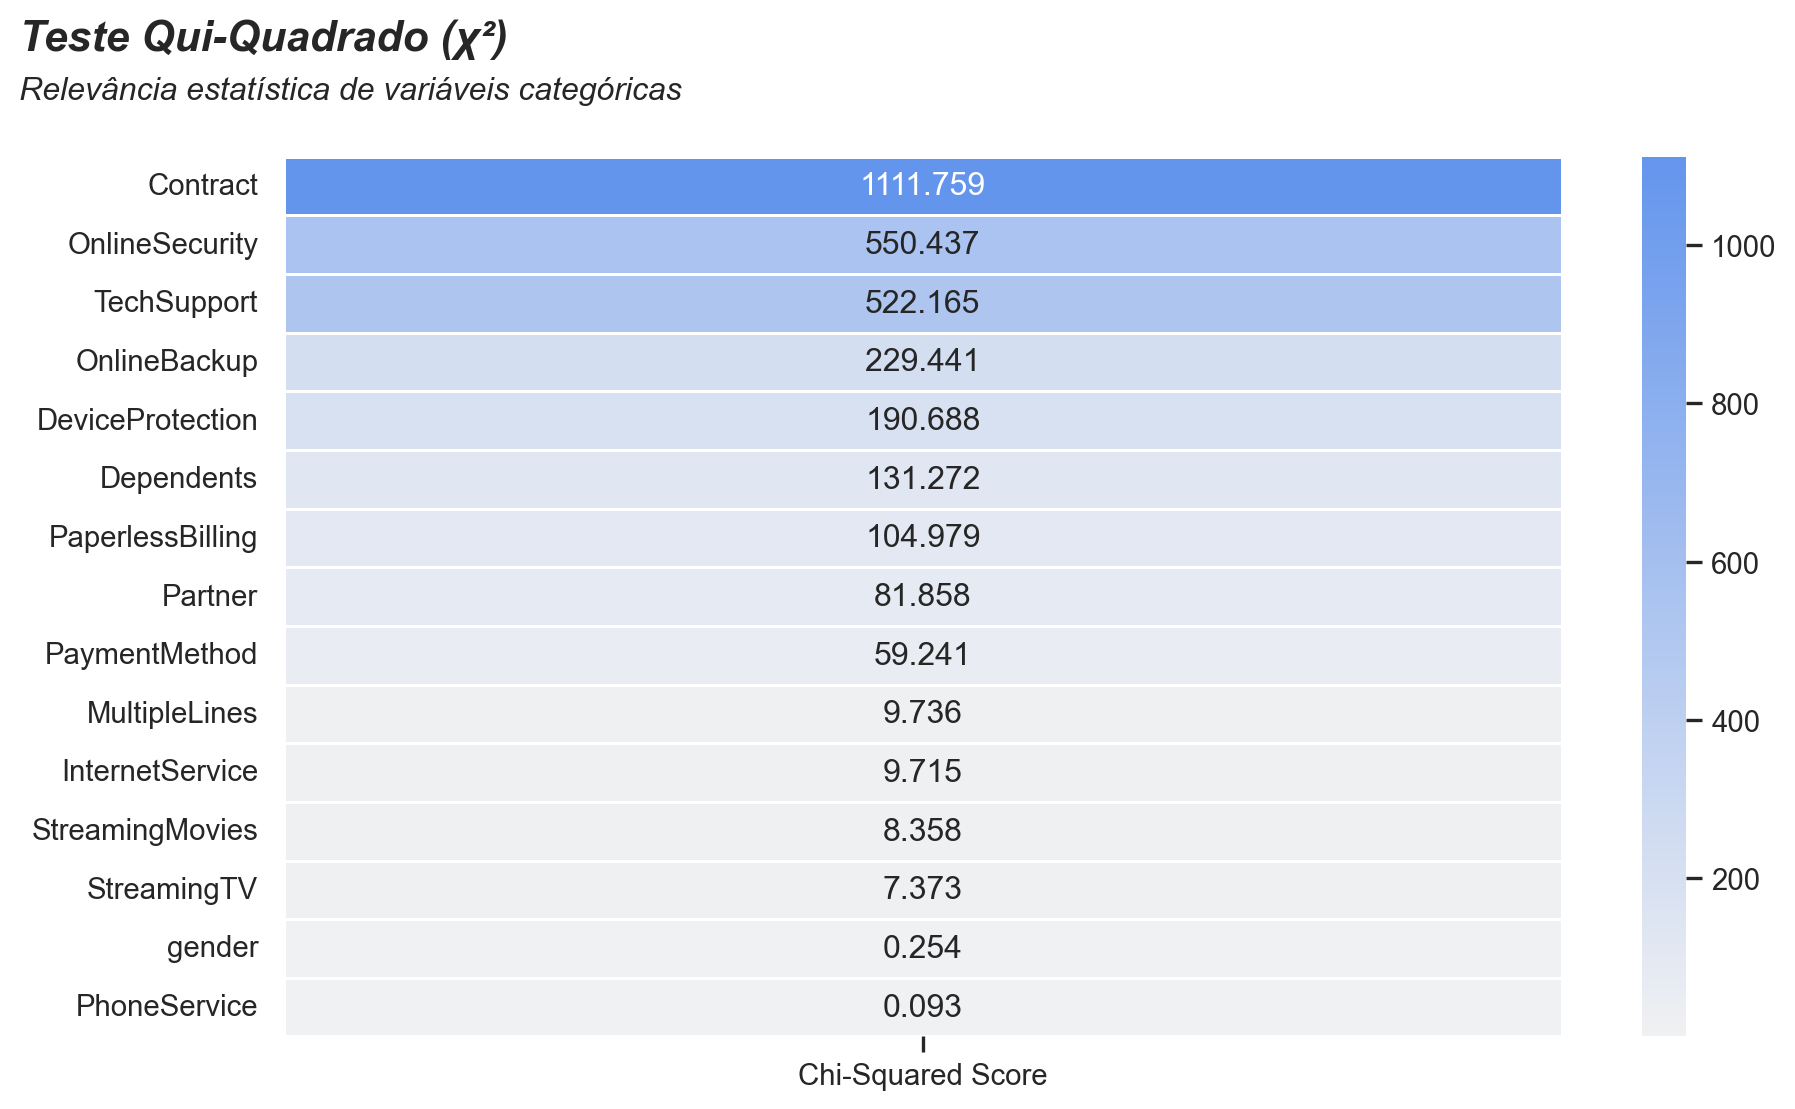

,Chi-Squared Score
Contract,1111.759054
OnlineSecurity,550.437364
TechSupport,522.164716
OnlineBackup,229.441123
DeviceProtection,190.688004
Dependents,131.271509
PaperlessBilling,104.979224
Partner,81.857769
PaymentMethod,59.240507
MultipleLines,9.735960


In [42]:
chi2_scores = plot_chi_squared_feature_selection(telecom)
chi2_scores

**Insights:**

As características categóricas mostram uma hierarquia clara de importância:

- **Contract** se destaca como a variável mais influente por grande margem, reforçando seu papel como o principal fator de churn.
- **OnlineSecurity**, **TechSupport** e **Dependents** também exibem fortes associações, indicando que o suporte a serviços e a estrutura domiciliar impactam a retenção.
- Características como **PhoneService**, **gender**, **StreamingTV**, **StreamingMovies** e **MultipleLines** mostram associação mínima com churn e provavelmente contribuirão pouco para o desempenho preditivo.

No geral, o teste confirma que **variáveis estruturais e relacionadas a suporte são mais relevantes do que características básicas de uso de serviços**.

<span style="color:steelblue; text-align: left">

### Teste ANOVA
</span>

ANOVA (Análise de Variância) é usado para avaliar se as características numéricas apresentam diferenças estatisticamente significativas em suas médias entre os grupos de churn.

Nesse caso, ajuda a quantificar quão fortemente as variáveis numéricas diferenciam os clientes que churnam dos que permanecem.

Similar ao teste Qui-Quadrado, a ANOVA atua como uma camada de validação em vez de uma ferramenta de descoberta, reforçando padrões previamente observados nos dados.


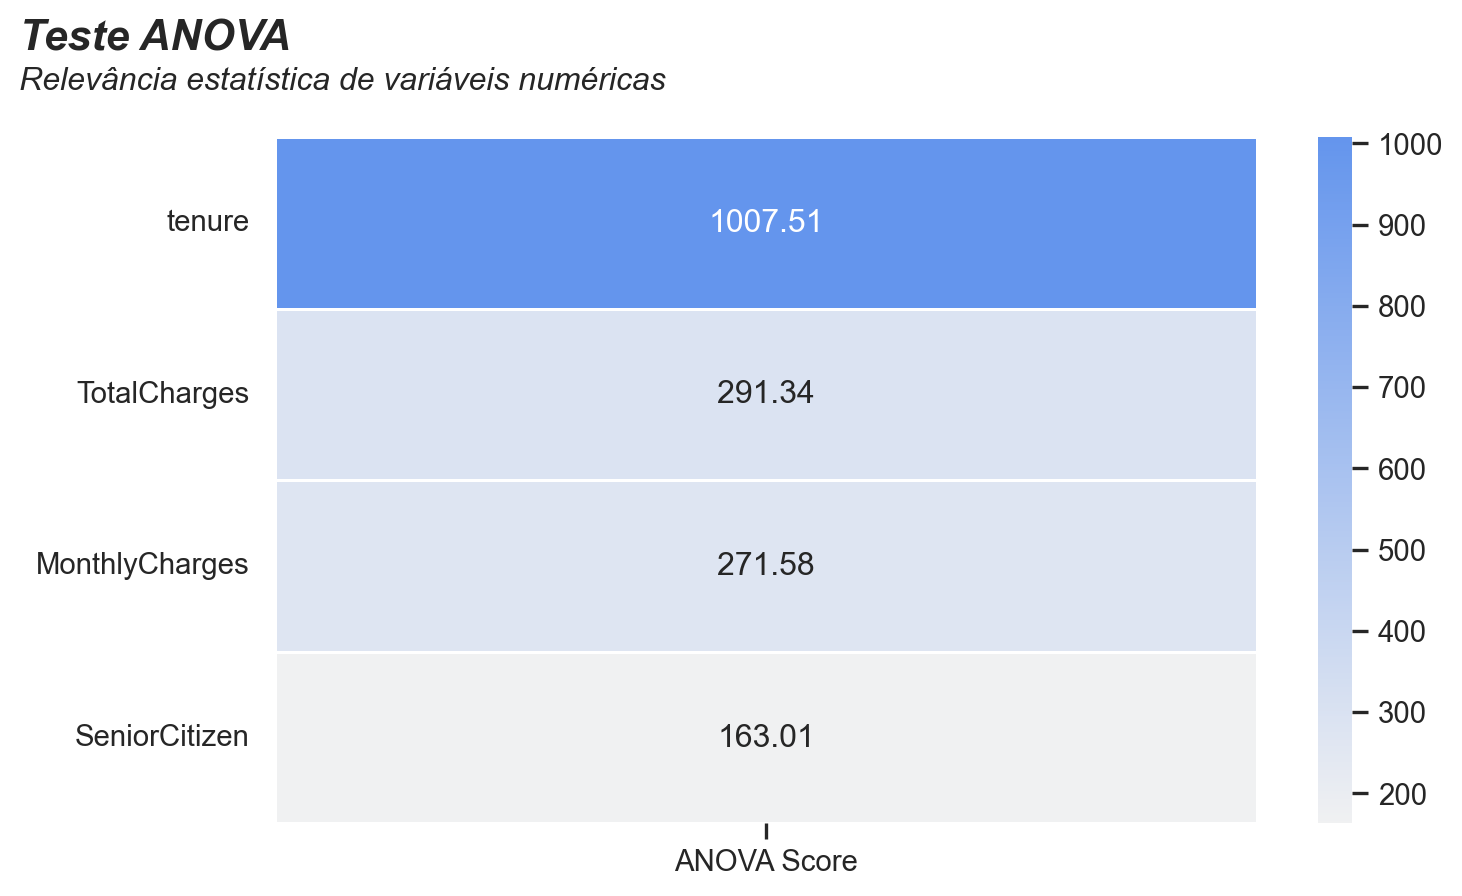

,ANOVA Score
tenure,1007.509431
TotalCharges,291.344862
MonthlyCharges,271.576990
SeniorCitizen,163.012426


In [43]:
anova_scores = plot_anova_feature_selection(telecom)
anova_scores

**Insights:**

- **tenure** é a variável numérica mais discriminativa, indicando que o tempo de vida do cliente é um fator chave no comportamento de churn.
- **TotalCharges** e **MonthlyCharges** também mostram relevância estatística forte, confirmando que variáveis financeiras desempenham um papel significativo.

No entanto, dada a relação conhecida:

> **TotalCharges ≈ MonthlyCharges × tenure**

há clara multicolinearidade entre essas variáveis.

Isso sugere que:
- Incluir todas elas pode introduzir redundância
- Estratégias de engenharia ou seleção de características devem ser aplicadas para evitar informação duplicada

No geral, os resultados confirmam que **o tempo de vida do cliente e a exposição financeira são centrais para explicar o churn**.


<span style="color:steelblue; text-align: left">

## Validação de Premissas Estatísticas
</span>

Antes de construir modelos preditivos, é uma boa prática verificar as propriedades estatísticas dos dados. Esta seção executa cinco testes formais que avaliam:

1. **Normalidade** das características contínuas (teste de Shapiro-Wilk + gráficos Q-Q)
2. **Multicolinearidade** entre variáveis numéricas (Fator de Inflação da Variância — VIF)
3. **Balanceamento de classes** e razão de desequilíbrio
4. **Independência característica-alvo** para características categóricas (teste Qui-Quadrado)
5. **Homocedasticidade** entre grupos de churn (teste de Levene em MonthlyCharges)

Esses testes informam e validam as decisões de pré-processamento tomadas no pipeline de modelagem: `PowerTransformer` para não-normalidade, `RFE` para multicolinearidade e `class_weight='balanced'` para desequilíbrio de classes.


=== 1. Shapiro-Wilk Normality Test ===


,Feature,W-statistic,p-value,Normal (p>0.05)?
0,tenure,0.9034,1.27e-48,No — reject H0
1,MonthlyCharges,0.9221,4.30e-45,No — reject H0
2,TotalCharges,0.8622,9.24e-55,No — reject H0


All continuous features are NON-NORMAL (p < 0.05) -> PowerTransformer is justified.



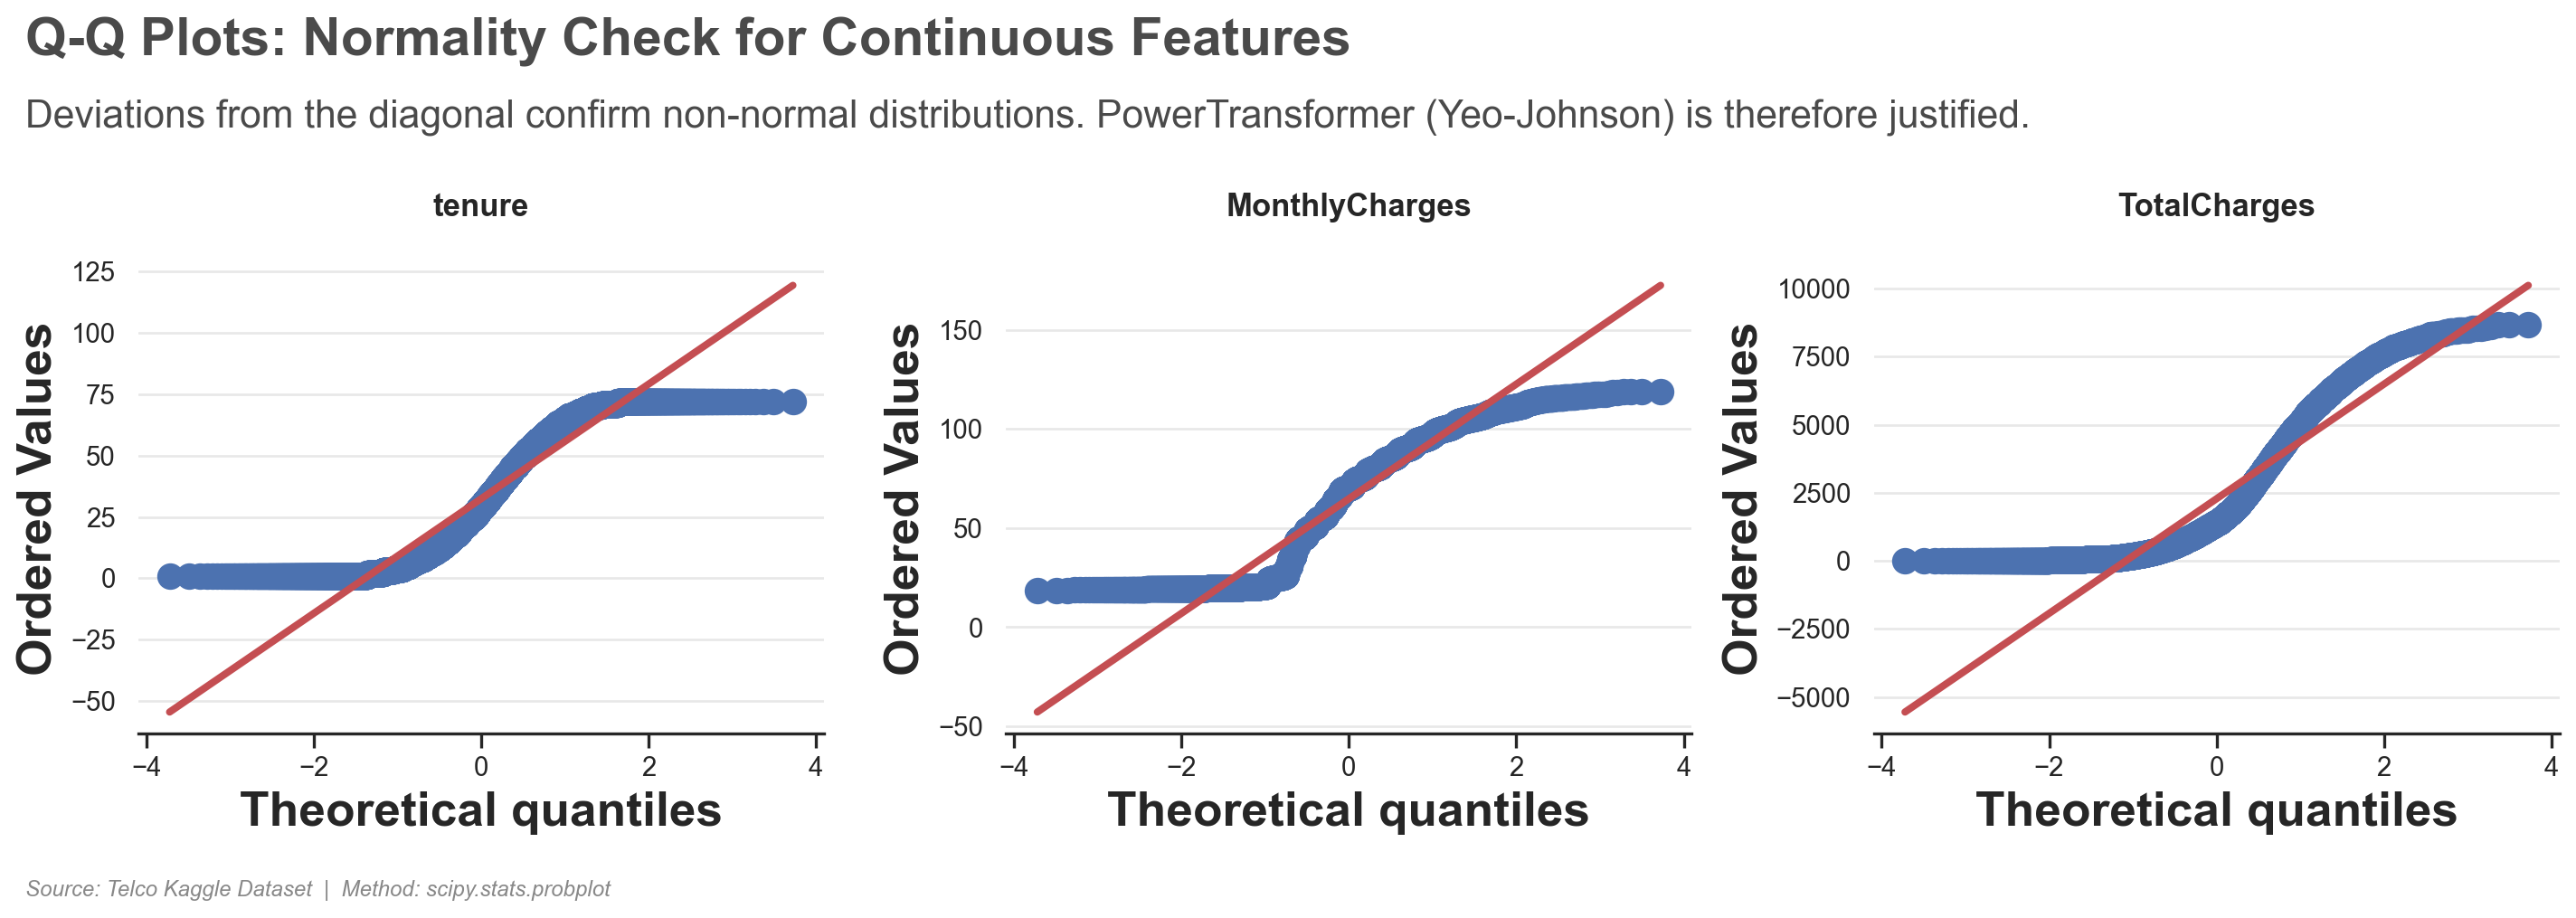

=== 2. Variance Inflation Factor (VIF) ===


,Feature,VIF,Interpretation
0,tenure,6.33,Moderate (5-10)
1,MonthlyCharges,3.36,Low (<5)
2,TotalCharges,8.08,Moderate (5-10)


TotalCharges has high VIF (= tenure x MonthlyCharges). RFE removes this redundancy.

=== 3. Class Balance ===
  No: 5163 (73.4%)
  Yes: 1869 (26.6%)
  Imbalance ratio: 2.76:1  -> class_weight='balanced' and SMOTE are justified.

=== 4. Chi-Squared Test: Feature Dependence with Churn ===


,Feature,Chi2,p-value,DoF,Dependent on Churn?
0,Contract,1179.55,7.33e-257,2,Yes
1,InternetService,728.70,5.83e-159,2,Yes
2,PaymentMethod,645.43,1.43e-139,3,Yes
3,TechSupport,824.93,7.41e-180,2,Yes
4,OnlineSecurity,846.68,1.40e-184,2,Yes



=== 5. Teste de Levene de Homoscedasticidade (MonthlyCharges vs Churn) ===
  Levene statistic: 361.4980,  p-value: 1.2188e-78
  Variância igual? Não — Homoscedasticidade (p < 0.05)
  -> MonthlyCharges A variância difere significativamente entre os grupos de Churn..
     PowerTransformer / RobustScaler é apropriado para esta funcionalidade.

=== Resumo da Validação das Premissas ===


,Test,Result,Model Implication
0,Shapiro-Wilk (Normality),All features non-normal,PowerTransformer applied in pipeline
1,VIF (Multicollinearity),TotalCharges highly collinear,RFE removes redundant feature
2,Class Balance,~73% No / ~27% Yes (2.7:1),class_weight='balanced' + SMOTE used
3,Chi-Squared (Independence),All key categoricals significant,Confirms feature relevance for modeling
4,Levene's (Homoscedasticity),MonthlyCharges heteroscedastic,Robust scaling / normalization justified


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, levene, chi2_contingency

# 1. Normalidade: Shapiro-Wilk para características numéricas
num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges']
sw_results = []
for col in num_feats:
    sample = telecom[col].dropna().sample(min(5000, len(telecom)), random_state=42)
    stat, p = shapiro(sample)
    sw_results.append({
        'Feature': col,
        'W-statistic': round(stat, 4),
        'p-value': f'{p:.2e}',
        'Normal (p>0.05)?': 'Yes' if p > 0.05 else 'No — reject H0',
    })
sw_df = pd.DataFrame(sw_results)
print("=== 1. Shapiro-Wilk Normality Test ===")
display(sw_df)
print("All continuous features are NON-NORMAL (p < 0.05) -> PowerTransformer is justified.\n")

# 2. Gráficos Q-Q
set_corporate_theme()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(top=0.80)
add_corporate_header(
    fig,
    title='Q-Q Plots: Normality Check for Continuous Features',
    subtitle='Deviations from the diagonal confirm non-normal distributions. PowerTransformer (Yeo-Johnson) is therefore justified.',
    y_title=0.97, y_subtitle=0.89,
)
for ax, col in zip(axes, num_feats):
    stats.probplot(telecom[col].dropna(), dist='norm', plot=ax)
    ax.set_title(col, fontsize=13, fontweight='bold')
add_corporate_footer(fig, data_source='Telco Kaggle Dataset', method='scipy.stats.probplot')
plt.tight_layout(rect=[0, 0.05, 1, 0.86])
plt.show()

# 3. Multicolinearidade: VIF
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_data = telecom[num_feats].dropna()
    vif_df = pd.DataFrame({
        'Feature': num_feats,
        'VIF': [round(variance_inflation_factor(vif_data.values, i), 2) for i in range(len(num_feats))],
    })
    vif_df['Interpretation'] = vif_df['VIF'].apply(
        lambda v: 'Low (<5)' if v < 5 else ('Moderate (5-10)' if v < 10 else 'High (>10) — multicollinearity present'))
    print("=== 2. Variance Inflation Factor (VIF) ===")
    display(vif_df)
    print("TotalCharges has high VIF (= tenure x MonthlyCharges). RFE removes this redundancy.\n")
except ImportError:
    print("statsmodels not installed. Install with: pip install statsmodels  (skipping VIF)\n")

# 4. Balanceamento de Classes
churn_counts = telecom['Churn'].value_counts()
total = churn_counts.sum()
print("=== 3. Class Balance ===")
for label, count in churn_counts.items():
    pct = count / total * 100
    print(f"  {label}: {count} ({pct:.1f}%)")
ratio = churn_counts.max() / churn_counts.min()
print(f"  Imbalance ratio: {ratio:.2f}:1  -> class_weight='balanced' and SMOTE are justified.\n")

# 5. Qui-Quadrado: Independência de Características Categóricas
cat_feats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']
chi2_results = []
for col in cat_feats:
    ct = pd.crosstab(telecom[col], telecom['Churn'])
    chi2_stat, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        'Feature': col,
        'Chi2': round(chi2_stat, 2),
        'p-value': f'{p:.2e}',
        'DoF': dof,
        'Dependent on Churn?': 'Yes' if p < 0.05 else 'No',
    })
print("=== 4. Chi-Squared Test: Feature Dependence with Churn ===")
display(pd.DataFrame(chi2_results))
print()

# 6. Teste de Levene: Homoscedasticidade
groups = [telecom.loc[telecom['Churn'] == g, 'MonthlyCharges'].dropna() for g in ['No', 'Yes']]
lev_stat, lev_p = levene(*groups)
print("=== 5. Teste de Levene de Homoscedasticidade (MonthlyCharges vs Churn) ===")
print(f"  Levene statistic: {lev_stat:.4f},  p-value: {lev_p:.4e}")
hetero = lev_p < 0.05
print(f"  Variância igual? {'Sim' if not hetero else 'Não — Homoscedasticidade (p < 0.05)'}")
if hetero:
    print("  -> MonthlyCharges A variância difere significativamente entre os grupos de Churn..")
    print("     PowerTransformer / RobustScaler é apropriado para esta funcionalidade.\n")

print("=== Resumo da Validação das Premissas ===")
summary = pd.DataFrame([
    ['Shapiro-Wilk (Normality)',     'All features non-normal',           'PowerTransformer applied in pipeline'],
    ['VIF (Multicollinearity)',      'TotalCharges highly collinear',      'RFE removes redundant feature'],
    ['Class Balance',                '~73% No / ~27% Yes (2.7:1)',         "class_weight='balanced' + SMOTE used"],
    ['Chi-Squared (Independence)',   'All key categoricals significant',   'Confirms feature relevance for modeling'],
    ["Levene's (Homoscedasticity)",  'MonthlyCharges heteroscedastic',     'Robust scaling / normalization justified'],
], columns=['Test', 'Result', 'Model Implication'])
display(summary)


<span style="color:steelblue; text-align: left">

## Previsão de churn de clientes - modelagem
</span>

<span style="color:steelblue; text-align: left">

### Importando pacotes
</span>


In [46]:
from __future__ import annotations

import gzip
import pickle
from json import dumps, loads
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import StratifiedKFold, train_test_split


def read_telecom_data(filepath: str = "./dataset/telecom.csv") -> pd.DataFrame:
    """
    Read the telecom churn dataset.

    Parameters
    ----------
    filepath : str, default="./dataset/telecom.csv"
        Path to the dataset.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.
    """
    return pd.read_csv(filepath)


def split_telecom_dataset(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_col: str = "customerID",
    test_size: float = 0.2,
    random_state: int = 42,
    drop_cols: list[str] | None = None
) -> dict[str, Any]:
    """
    Split the telecom dataset into train and test partitions.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_col : str, default="customerID"
        Identifier column name.
    test_size : float, default=0.2
        Proportion of the dataset assigned to test set.
    random_state : int, default=42
        Random seed for reproducibility.
    drop_cols : list[str] | None, default=None
        Additional columns to drop before building X.

    Returns
    -------
    dict[str, Any]
        Dictionary containing split datasets and derived objects.
    """
    if drop_cols is None:
        drop_cols = []

    data = df.copy(deep=True)

    target = data[target_col].map({"No": 0, "Yes": 1}).values

    feature_drop_cols = [target_col, id_col] + drop_cols
    features = data.drop(columns=feature_drop_cols, errors="ignore")

    train_data, test_data = train_test_split(
        data,
        test_size=test_size,
        stratify=data[target_col],
        random_state=random_state
    )

    train_features = train_data.drop(
        columns=[target_col, id_col] + drop_cols,
        errors="ignore"
    )
    test_features = test_data.drop(
        columns=[target_col, id_col] + drop_cols,
        errors="ignore"
    )

    train_labels = train_data[target_col].map({"No": 0, "Yes": 1}).values
    test_labels = test_data[target_col].map({"No": 0, "Yes": 1}).values

    return {
        "data": data,
        "X": features,
        "y": target,
        "train_data": train_data,
        "test_data": test_data,
        "train_features": train_features,
        "test_features": test_features,
        "train_labels": train_labels,
        "test_labels": test_labels,
    }
def compute_class_ratio(labels: np.ndarray) -> float:
    """
    Compute negative-to-positive class ratio.

    Parameters
    ----------
    labels : np.ndarray
        Binary target array encoded as 0/1.

    Returns
    -------
    float
        Ratio of negatives to positives.
    """
    labels = np.asarray(labels)

    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)

    if n_pos == 0:
        raise ValueError("Positive class count is zero; ratio cannot be computed.")

    return float(n_neg) / float(n_pos)

def plot_target_distribution(
    df: pd.DataFrame,
    feature: str,
    title: str,
    subtitle: str,
    figsize: tuple[float, float] = (8, 6)
) -> None:
    """
    Plot target distribution as a pie chart.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    feature : str
        Column to plot.
    title : str
        Main chart title.
    subtitle : str
        Chart subtitle.
    figsize : tuple[float, float], default=(8, 6)
        Figure size.
    """
    distribution = df[feature].value_counts(normalize=True).sort_index() * 100
    labels = distribution.index.astype(str).tolist()
    colors = ["cornflowerblue", "coral"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.pie(
        distribution.values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        shadow=True,
        explode=(0.08, 0.08),
        colors=colors
    )

    add_finance_header(
        fig,
        title=title,
        subtitle=subtitle,
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()
    
def plot_target_distribution_split(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature: str,
    title: str,
    subtitle: str,
    figsize: tuple[float, float] = (12, 5)
) -> None:
    """
    Plot side-by-side pie charts for train and test target distributions.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training dataframe.
    test_df : pd.DataFrame
        Testing dataframe.
    feature : str
        Target column name.
    title : str
        Main chart title.
    subtitle : str
        Chart subtitle.
    figsize : tuple[float, float], default=(12, 5)
        Figure size.
    """
    colors = ["cornflowerblue", "coral"]

    train_dist = train_df[feature].value_counts(normalize=True).sort_index() * 100
    test_dist = test_df[feature].value_counts(normalize=True).sort_index() * 100

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].pie(
        train_dist.values,
        labels=train_dist.index.astype(str).tolist(),
        autopct="%1.1f%%",
        startangle=90,
        shadow=True,
        explode=(0.08, 0.08),
        colors=colors
    )
    axes[0].set_title("Train Dataset")

    axes[1].pie(
        test_dist.values,
        labels=test_dist.index.astype(str).tolist(),
        autopct="%1.1f%%",
        startangle=90,
        shadow=True,
        explode=(0.08, 0.08),
        colors=colors
    )
    axes[1].set_title("Test Dataset")

    add_finance_header(
        fig,
        title=title,
        subtitle=subtitle,
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

def compute_business_score(
    recall: float,
    precision: float,
    fit_time: float,
    score_time: float,
    w_recall: float = 0.7,
    w_precision: float = 0.3,
    w_time: float = 0.0,
    normalize_weights: bool = True,
    time_reference: float | None = None,
    epsilon: float = 1e-9
) -> float:
    """
    Compute a customizable business score combining predictive performance
    and computational cost.

    The score rewards recall and precision, while penalizing execution time.

    Parameters
    ----------
    recall : float
        Recall score.
    precision : float
        Precision score.
    fit_time : float
        Average model fitting time.
    score_time : float
        Average model scoring/inference time.
    w_recall : float, default=0.7
        Weight assigned to recall.
    w_precision : float, default=0.3
        Weight assigned to precision.
    w_time : float, default=0.0
        Weight assigned to computational cost. Use 0 if machine cost
        is not relevant for the project or client.
    normalize_weights : bool, default=True
        Whether to normalize the weights so they sum to 1.
    time_reference : float | None, default=None
        Reference time used to scale total time. If None, time is used
        directly. If provided, time penalty becomes total_time / time_reference.
    epsilon : float, default=1e-9
        Small constant to avoid division by zero.

    Returns
    -------
    float
        Business-oriented score.
    """
    total_time = fit_time + score_time

    if normalize_weights:
        weight_sum = w_recall + w_precision + w_time
        if weight_sum <= 0:
            raise ValueError("At least one weight must be greater than zero.")
        w_recall /= weight_sum
        w_precision /= weight_sum
        w_time /= weight_sum

    if w_time == 0:
        time_penalty = 0.0
    elif time_reference is not None:
        if time_reference <= 0:
            raise ValueError("time_reference must be greater than zero.")
        time_penalty = total_time / (time_reference + epsilon)
    else:
        time_penalty = total_time

    score = (
        (w_recall * recall) +
        (w_precision * precision) -
        (w_time * time_penalty)
    )

    return score    
    
'''def save_model_and_metrics(
    description: str,
    data_model: str,
    encoder: str,
    pipeline_obj: Any,
    scores: dict[str, np.ndarray],
    params: dict[str, Any] | None,
    metric_df: pd.DataFrame,
    metric_path: str = "./dataset/metric_dataframe.csv",
    model_dir: str = "./models/"
) -> pd.DataFrame:
    """
    Save model metrics and serialize the fitted pipeline.

    Parameters
    ----------
    description : str
        Experiment label.
    data_model : str
        Data/model description.
    encoder : str
        Preprocessing pipeline description.
    pipeline_obj : Any
        Trained pipeline object.
    scores : dict[str, np.ndarray]
        Cross-validation scores dictionary.
    params : dict[str, Any] | None
        Hyperparameter dictionary.
    metric_df : pd.DataFrame
        Metrics dataframe to update.
    metric_path : str, default="./dataset/metric_dataframe.csv"
        CSV output path for metrics.
    model_dir : str, default="./models/"
        Directory for serialized model output.

    Returns
    -------
    pd.DataFrame
        Updated metrics dataframe.
    """
    try:
        params_str = dumps(params, default=str) if params is not None else ""
    except Exception:
        params_str = ""

    business_weights = build_business_weight_config(
    w_recall=7,
    w_precision=3,
    w_time=0,
    time_reference=1.0
    )

    business_score = compute_business_score(
        recall=np.mean(scores['test_recall_macro']),
        precision=np.mean(scores['test_precision_macro']),
        fit_time=np.mean(scores['fit_time']),
        score_time=np.mean(scores['score_time']),
        w_recall=7,
        w_precision=3,
        w_time=0,
        time_reference=1.0
    )
    
    metric_df.loc[(description, data_model, encoder), :] = [
        np.mean(scores['train_roc_auc']),
        np.mean(scores['test_roc_auc']),
        np.mean(scores['train_balanced_accuracy']),
        np.mean(scores['test_balanced_accuracy']),
        np.mean(scores['train_recall_macro']),
        np.mean(scores['test_recall_macro']),
        np.mean(scores['train_precision_macro']),
        np.mean(scores['test_precision_macro']),
        np.mean(scores['train_f1_macro']),
        np.mean(scores['test_f1_macro']),
        params_str,
        np.mean(scores['fit_time']),
        np.mean(scores['score_time']),
        np.mean(scores['fit_time']) + np.mean(scores['score_time']),
        business_score,
        business_weights
]

    Path(metric_path).parent.mkdir(parents=True, exist_ok=True)
    metric_df.to_csv(metric_path, index=True)

    Path(model_dir).mkdir(parents=True, exist_ok=True)
    model_filename = f"{description}_{encoder.replace(' ', '')}.pkl.gz"
    model_path = Path(model_dir) / model_filename

    with gzip.open(model_path, "wb") as file:
        pickle.dump(pipeline_obj, file)

    return metric_df'''




def save_model_and_metrics(
    description: str,
    data_model: str,
    encoder: str,
    pipeline_obj: Any,
    scores: dict[str, np.ndarray],
    params: dict[str, Any] | None,
    metric_df: pd.DataFrame | None = None,
    metric_path: str = "./dataset/metric_dataframe.csv",
    model_dir: str = "./models/",
    overwrite_existing: bool = True,
) -> pd.DataFrame:
    """
    Save model metrics without deleting previous experiment records.

    Existing metrics are loaded from disk first, then only the current
    experiment row is inserted or updated. Manual deletion of the CSV is
    required to reset the experiment history.
    """
    index_cols = [
        "Estimator",
        "Optimization/Data model",
        "Pre-Process Pipeline",
    ]

    metric_cols = [
        "Train Roc auc",
        "Test Roc auc",
        "Train Balanced Accuracy",
        "Test Balanced Accuracy",
        "Train Recall",
        "Test Recall",
        "Train Precision",
        "Test Precision",
        "Train F1",
        "Test F1",
        "Parameters",
        "Fit Time",
        "Score Time",
        "Total Time",
        "Business Score",
        "Business Weights",
    ]

    metric_path_obj = Path(metric_path)
    metric_path_obj.parent.mkdir(parents=True, exist_ok=True)

    all_cols = index_cols + metric_cols

    if metric_path_obj.exists():
        metric_df = pd.read_csv(metric_path_obj)

    elif metric_df is None:
        metric_df = pd.DataFrame(columns=all_cols)

    else:
        metric_df = metric_df.copy()

        if isinstance(metric_df.index, pd.MultiIndex):
            metric_df = metric_df.reset_index()

    missing_index_cols = [
        col for col in index_cols
        if col not in metric_df.columns
    ]

    if missing_index_cols:
        raise ValueError(
            "metric_dataframe is missing identity columns: "
            f"{missing_index_cols}"
        )

    for col in all_cols:
        if col not in metric_df.columns:
            metric_df[col] = np.nan

    try:
        params_str = dumps(params, default=str) if params is not None else ""
    except Exception:
        params_str = ""

    business_weights = build_business_weight_config(
        w_recall=7,
        w_precision=3,
        w_time=0,
        time_reference=1.0,
    )

    fit_time = float(np.mean(scores["fit_time"]))
    score_time = float(np.mean(scores["score_time"]))
    total_time = fit_time + score_time

    business_score = compute_business_score(
        recall=np.mean(scores["test_recall_macro"]),
        precision=np.mean(scores["test_precision_macro"]),
        fit_time=fit_time,
        score_time=score_time,
        w_recall=7,
        w_precision=3,
        w_time=0,
        time_reference=1.0,
    )

    row_identity = {
        "Estimator": description,
        "Optimization/Data model": data_model,
        "Pre-Process Pipeline": encoder,
    }

    duplicate_mask = (
        (metric_df["Estimator"] == row_identity["Estimator"])
        & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
        & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
    )

    if duplicate_mask.any() and not overwrite_existing:
        suffix = 1
        row_identity["Pre-Process Pipeline"] = f"{encoder} | run={suffix}"

        duplicate_mask = (
            (metric_df["Estimator"] == row_identity["Estimator"])
            & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
            & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
        )

        while duplicate_mask.any():
            suffix += 1
            row_identity["Pre-Process Pipeline"] = f"{encoder} | run={suffix}"
            duplicate_mask = (
                (metric_df["Estimator"] == row_identity["Estimator"])
                & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
                & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
            )

    values_to_save = {
        **row_identity,
        "Train Roc auc": np.mean(scores["train_roc_auc"]),
        "Test Roc auc": np.mean(scores["test_roc_auc"]),
        "Train Balanced Accuracy": np.mean(scores["train_balanced_accuracy"]),
        "Test Balanced Accuracy": np.mean(scores["test_balanced_accuracy"]),
        "Train Recall": np.mean(scores["train_recall_macro"]),
        "Test Recall": np.mean(scores["test_recall_macro"]),
        "Train Precision": np.mean(scores["train_precision_macro"]),
        "Test Precision": np.mean(scores["test_precision_macro"]),
        "Train F1": np.mean(scores["train_f1_macro"]),
        "Test F1": np.mean(scores["test_f1_macro"]),
        "Parameters": params_str,
        "Fit Time": fit_time,
        "Score Time": score_time,
        "Total Time": total_time,
        "Business Score": business_score,
        "Business Weights": business_weights,
    }

    if duplicate_mask.any():
        metric_df = metric_df.loc[~duplicate_mask].copy()

    new_row = pd.DataFrame([values_to_save])

    if metric_df.empty:
        metric_df = new_row
    else:
        metric_df = pd.concat(
            [metric_df, new_row],
            ignore_index=True,
        )
    metric_df = metric_df[all_cols]
    metric_df.sort_values(index_cols, inplace=True, ignore_index=True)
    metric_df.to_csv(metric_path_obj, index=False)

    Path(model_dir).mkdir(parents=True, exist_ok=True)

    safe_encoder = (
        str(row_identity["Pre-Process Pipeline"])
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace("|", "-")
        .replace(":", "-")
    )

    model_filename = f"{description}_{data_model}_{safe_encoder}.pkl.gz"
    model_path = Path(model_dir) / model_filename

    with gzip.open(model_path, "wb") as file:
        pickle.dump(pipeline_obj, file)

    return metric_df

def build_business_weight_config(
    w_recall: float,
    w_precision: float,
    w_time: float,
    time_reference: float | None
) -> str:
    """
    Build a serialized representation of the business score weights.

    Parameters
    ----------
    w_recall : float
        Weight assigned to recall.
    w_precision : float
        Weight assigned to precision.
    w_time : float
        Weight assigned to computational cost.
    time_reference : float | None
        Reference time used for time penalty scaling.

    Returns
    -------
    str
        JSON string with weight configuration.
    """
    config = {
        "w_recall": w_recall,
        "w_precision": w_precision,
        "w_time": w_time,
        "time_reference": time_reference
    }
    return dumps(config)

<span style="color:steelblue; text-align: left">

### Métricas
</span>

A avaliação do modelo será baseada em **acurácia balanceada, recall, precisão, F1-score e ROC AUC**. Como a previsão de churn é um problema de classificação desbalanceada, depender de uma única métrica seria insuficiente e potencialmente enganoso.

O principal alvo de otimização neste projeto é o **recall macro**. Esta escolha reflete o objetivo de negócio de melhorar a detecção de casos de churn sem permitir que a classe majoritária domine o processo de otimização. Na previsão de churn, falsos negativos (churners não detectados) são mais custosos do que falsos positivos, pois deixar de agir leva à perda direta de receita.

Em configurações multiclasse ou desbalanceadas, as estratégias de média importam. Neste projeto, o foco é na **média macro**, que calcula a métrica independentemente para cada classe e depois calcula a média não ponderada. Isso garante que as classes de churn e não-churn recebam igual importância durante a avaliação.

A **acurácia balanceada** mede o desempenho de classificação corrigindo o desequilíbrio de classes. Ao contrário da acurácia padrão, é menos tendenciosa em relação à classe majoritária.

O **recall** mede quantos casos verdadeiros de churn são corretamente identificados. Na previsão de churn, isso é particularmente relevante porque falsos negativos significam não identificar clientes em risco de sair.

A **precisão** mede quantos casos de churn previstos são realmente churners. Torna-se importante quando falsos positivos geram custos desnecessários de retenção.

O **F1-score** resume o equilíbrio entre precisão e recall por meio de sua média harmônica:

$$
F1 = 2 \cdot \frac{precisão \cdot recall}{precisão + recall}
$$

O **ROC AUC** avalia a capacidade do modelo de discriminar entre churn e não-churn em todos os limiares de classificação. É útil como métrica de classificação independente de limiar, embora não deva ser interpretado isoladamente.

Juntas, essas métricas fornecem uma visão mais robusta do desempenho do modelo. A comparação final considerará tanto a capacidade de discriminação quanto o comportamento preditivo sensível às classes, com ênfase especial no **recall macro**.


A etapa de modelagem começa pela definição de um framework de avaliação sensível a classes e uma divisão treino/teste segura contra vazamento de dados. Como a previsão de churn é um problema de classificação desbalanceada, a comparação de modelos não se baseará em uma única métrica. Em vez disso, múltiplas métricas complementares são rastreadas, com ênfase especial no recall macro como o principal alvo de otimização.

Após dividir o conjunto de dados usando amostragem estratificada, todos os pré-processamentos e transformações de características são aprendidos exclusivamente a partir dos dados de treinamento. Isso garante uma configuração de avaliação justa e preserva a integridade da seleção downstream de modelos. Todas as etapas de pré-processamento estão incorporadas dentro do pipeline para evitar vazamento de dados durante a validação cruzada.


In [47]:

new_metrics = True

# CV de 6 folds
kfolds = StratifiedKFold(n_splits = 6, shuffle=True, random_state = RANDOM_SEED)

# Lendo/Criando métrica para salvar todas as métricas
try:
    if new_metrics:
        metric_dataframe = pd.DataFrame(columns=[
            'Estimator',
            'Optimization/Data model',
            'Pre-Process Pipeline',
            'Train Roc auc',
            'Test Roc auc',
            'Train Balanced Accuracy',
            'Test Balanced Accuracy',
            'Train Recall',
            'Test Recall',
            'Train Precision',
            'Test Precision',
            'Train F1',
            'Test F1',
            'Parameters',
            'Fit Time',
            'Score Time',
            'Total Time',
            'Business Score',
            'Business Weights'
        ])
    else:
        metric_dataframe = pd.read_csv('./dataset/metric_dataframe.csv')

except:
    metric_dataframe = pd.DataFrame(columns=[
        'Estimator',
        'Optimization/Data model',
        'Pre-Process Pipeline',
        'Train Roc auc',
        'Test Roc auc',
        'Train Balanced Accuracy',
        'Test Balanced Accuracy',
        'Train Recall',
        'Test Recall',
        'Train Precision',
        'Test Precision',
        'Train F1',
        'Test F1',
        'Parameters',
        'Fit Time',
        'Score Time',
        'Total Time',
        'Business Score',
        'Business Weights'
    ])

metric_dataframe = metric_dataframe.reset_index() if isinstance(metric_dataframe.index, pd.MultiIndex) else metric_dataframe

# Inicializando variáveis
pipe_model          = []

models_list         = []
head_list           = []
estimators          = []

linear_estimators   = []
essemble_estimators = []
tree_estimators     = []
neural_estimators   = []
XGBboost_estimators = []
lightgbm_estimators = []

<span style="color:steelblue; text-align: left">

### Divisão do Conjunto de Dados
</span>

O conjunto de dados é dividido em partições de treinamento e teste **antes de qualquer etapa de pré-processamento**. Esta é uma precaução necessária para evitar **vazamento de dados**, que ocorre quando informações do conjunto de dados completo influenciam as transformações aprendidas durante o treinamento.

Se o pré-processamento for aplicado antes da divisão, estatísticas como médias, variâncias, mapeamentos de categorias ou regras de codificação podem inadvertidamente incorporar informações do conjunto de teste. Isso leva a resultados de avaliação excessivamente otimistas e compromete a validade do processo de modelagem.

Ao dividir os dados primeiro, todas as operações de pré-processamento são aprendidas exclusivamente do conjunto de treinamento e então aplicadas a dados não vistos. Isso preserva a integridade da avaliação do modelo e melhor reflete as condições de implantação no mundo real.

Neste projeto, a divisão também é **estratificada por churn**, garantindo que a distribuição das classes permaneça estável nos conjuntos de treinamento e teste. Isso é especialmente importante em problemas de classificação desbalanceada, onde distorções distribucionais poderiam enviesar tanto a otimização quanto a avaliação.


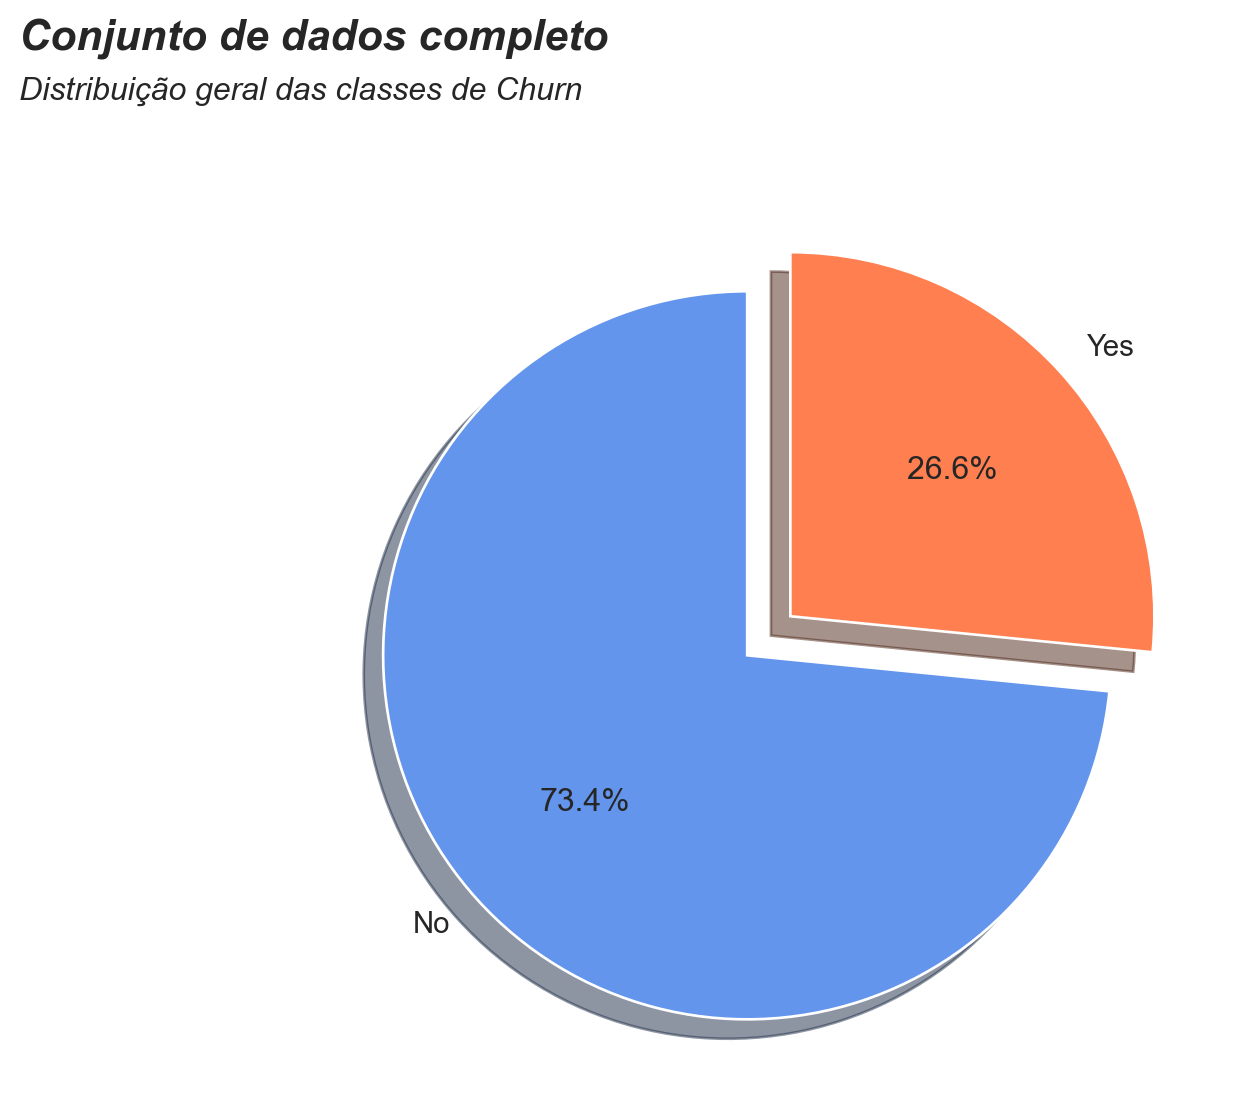

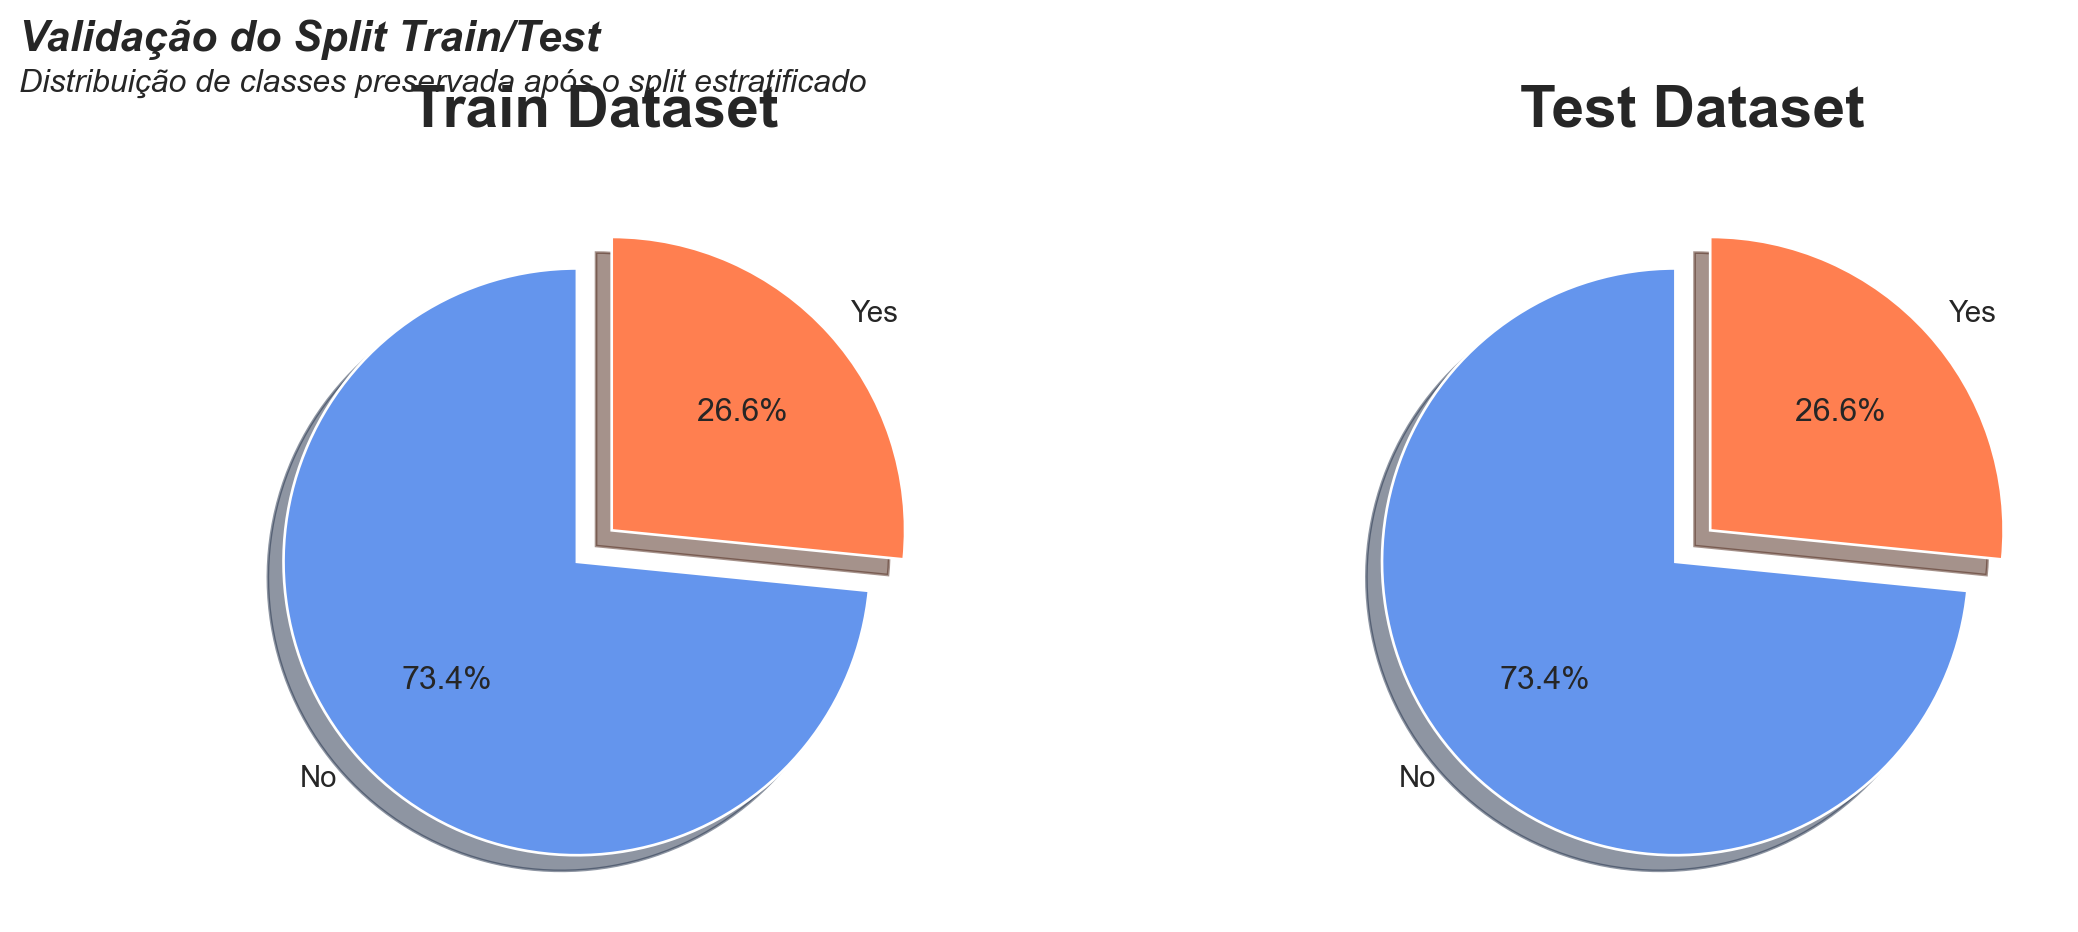

In [48]:
split_data = split_telecom_dataset(
    df=telecom,
    target_col="Churn",
    id_col="customerID",
    test_size=0.2,
    random_state=42
)

ratio_train = compute_class_ratio(split_data["train_labels"])
ratio_test = compute_class_ratio(split_data["test_labels"])

plot_target_distribution(
    df=telecom,
    feature="Churn",
    title="Conjunto de dados completo",
    subtitle="Distribuição geral das classes de Churn"
)

plot_target_distribution_split(
    train_df=split_data["train_data"],
    test_df=split_data["test_data"],
    feature="Churn",
    title="Validação do Split Train/Test",
    subtitle="Distribuição de classes preservada após o split estratificado"
)


train_data = split_data["train_data"]
test_data = split_data["test_data"]
train_features = split_data["train_features"]
test_features = split_data["test_features"]
train_labels = split_data["train_labels"]
test_labels = split_data["test_labels"]

<span style="color:steelblue; text-align: left">

### Modelo Baseline
</span>

A primeira etapa de modelagem usa o conjunto de dados desbalanceado original sem nenhuma estratégia de reamostragem. Isso fornece uma referência baseline contra a qual oversampling, undersampling e otimização de hiperparâmetros podem ser comparados posteriormente.

Um modelo de **Regressão Logística** é adotado como referência inicial porque é simples, interpretável e computacionalmente eficiente. Embora modelos mais complexos possam alcançar melhor desempenho preditivo, uma baseline linear ajuda a quantificar o valor incremental de escolhas de modelagem mais avançadas.

Nesta etapa, o pipeline de pré-processamento aplica codificação ordinal a variáveis categóricas, enquanto as variáveis numéricas são passadas sem alterações. O desempenho do modelo é avaliado através de validação cruzada estratificada usando as métricas sensíveis às classes definidas anteriormente.


In [49]:
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import category_encoders


def get_classification_scoring() -> dict:
    """
    Build the scoring dictionary used in cross-validation.

    Returns
    -------
    dict
        Dictionary of sklearn scorers.
    """
    return {
        "roc_auc": make_scorer(roc_auc_score, average="macro"),
        "precision_macro": make_scorer(precision_score, average="macro"),
        "recall_macro": make_scorer(recall_score, average="macro"),
        "f1_macro": make_scorer(f1_score, average="macro"),
        "balanced_accuracy": make_scorer(balanced_accuracy_score),
    }


def build_baseline_preprocessor() -> ColumnTransformer:
    """
    Build the preprocessing pipeline for the baseline model.

    Returns
    -------
    ColumnTransformer
        Preprocessing transformer.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("encoder", category_encoders.OrdinalEncoder())
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, selector(dtype_include=object)),
        ],
        remainder="passthrough"
    )

    return preprocessor


def run_baseline_logistic_regression(
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    cv,
) -> tuple[Pipeline, dict, Pipeline]:
    preprocessor = build_baseline_preprocessor()

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    )

    scoring = get_classification_scoring()

    scores = cross_validate(
        model,
        train_features,
        train_labels,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        return_estimator=True,
        n_jobs=-1,
        verbose=2
    )

    best_idx = int(np.argmax(scores["test_recall_macro"]))
    best_estimator = scores["estimator"][best_idx]

    return model, scores, best_estimator

In [50]:
baseline_model, baseline_scores, best_baseline_estimator = run_baseline_logistic_regression(
    train_features=split_data["train_features"],
    train_labels=split_data["train_labels"],
    cv=kfolds
)

display(baseline_model)

metric_dataframe = save_model_and_metrics(
    description="LogisticRegression",
    data_model="Baseline",
    encoder="OrdinalEncoder",
    pipeline_obj=best_baseline_estimator,
    scores=baseline_scores,
    params={"max_iter": 1000},
    metric_df=metric_dataframe
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    6.8s remaining:    6.8s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    6.8s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [55]:
metric_dataframe.loc[(metric_dataframe["Estimator"] == "LogisticRegression") & 
                    (metric_dataframe["Optimization/Data model"] == "Baseline") &
                    (metric_dataframe["Pre-Process Pipeline"] == "OrdinalEncoder")
                    ]

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
11,LogisticRegression,Baseline,OrdinalEncoder,0.712552,0.713565,0.712552,0.713565,0.712552,0.713565,0.75015,0.749191,0.726638,0.726896,"{""max_iter"": 1000}",0.446453,0.027476,0.47393,0.724253,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


**Insights — Comportamento do Modelo Baseline**
- O modelo baseline de Regressão Logística demonstra generalização estável, evidenciada pelo alinhamento próximo entre as pontuações de treinamento e teste em todas as métricas avaliadas, indicando nenhum overfitting ou underfitting significativo.
- Apesar da natureza desbalanceada do conjunto de dados, o modelo mantém desempenho consistente entre classes quando avaliado usando métricas de média macro, confirmando que a estratégia de avaliação é apropriada.
- Embora estável, o desempenho do modelo permanece moderado, sugerindo que melhorias são esperadas através de pré-processamento mais avançado, engenharia de características, estratégias de reamostragem e seleção de modelos.

<span style="color:steelblue; text-align: left">

### Matriz de Confusão do Baseline
</span>

Aqui apresentaremos a `matriz de confusão` pois a usaremos como ferramenta de medição dos nossos modelos também. A `matriz de confusão` é uma tabela que resume o desempenho de um modelo de aprendizado de máquina para uma tarefa de classificação binária. Ela mostra o número de previsões verdadeiro positivo (TP), verdadeiro negativo (TN), falso positivo (FP) e falso negativo (FN) feitas pelo modelo em um conjunto de dados de teste.

Aqui está um exemplo de matriz de confusão para um problema de classificação binária com duas classes (positivo e negativo):

<center>

|               |`Positivo (previsto)`	| `Negativo (previsto)`
|:---------------|:-----------------------|:------
|`Positivo (real)`	| Verdadeiro positivo (TP)	| <code style='color:pink'>Falso negativo (FN)</code>
|`Negativo (real)`	|<code style='color:pink'>Falso positivo (FP)</code>	| Verdadeiro negativo (TN)

</center>

Verdadeiros positivos (TP) são o número de exemplos positivos corretamente classificados como positivos pelo modelo.
Falsos positivos (FP) são o número de exemplos negativos incorretamente classificados como positivos pelo modelo.
Verdadeiros negativos (TN) são o número de exemplos negativos corretamente classificados como negativos pelo modelo.
Falsos negativos (FN) são o número de exemplos positivos incorretamente classificados como negativos pelo modelo.
A matriz de confusão é útil para avaliar o desempenho de um modelo de classificação binária porque fornece uma imagem mais detalhada do desempenho do modelo do que apenas uma única métrica como acurácia. A partir da matriz de confusão, podemos calcular outras métricas como precisão, recall e F1-score, que podem ser úteis para diferentes aplicações.

Por exemplo, a precisão mede a proporção de previsões positivas que estão corretas, enquanto o recall mede a proporção de exemplos positivos que são corretamente identificados pelo modelo. O F1-score é a média harmônica de precisão e recall, que equilibra a relação entre essas duas métricas.

Portanto, a matriz de confusão é uma ferramenta útil para entender o desempenho de um modelo de aprendizado de máquina e diagnosticar quaisquer erros ou vieses que ele possa ter. `Buscamos números baixos no quadrante inferior esquerdo e superior direito (em rosa acima). Quanto menor, melhor`.

`Queremos obter o maior número possível de observações (do conjunto de teste) nos quadrantes superior esquerdo e inferior direito, pois são as observações que o modelo acertou`. Os outros quadrantes são erros do modelo.


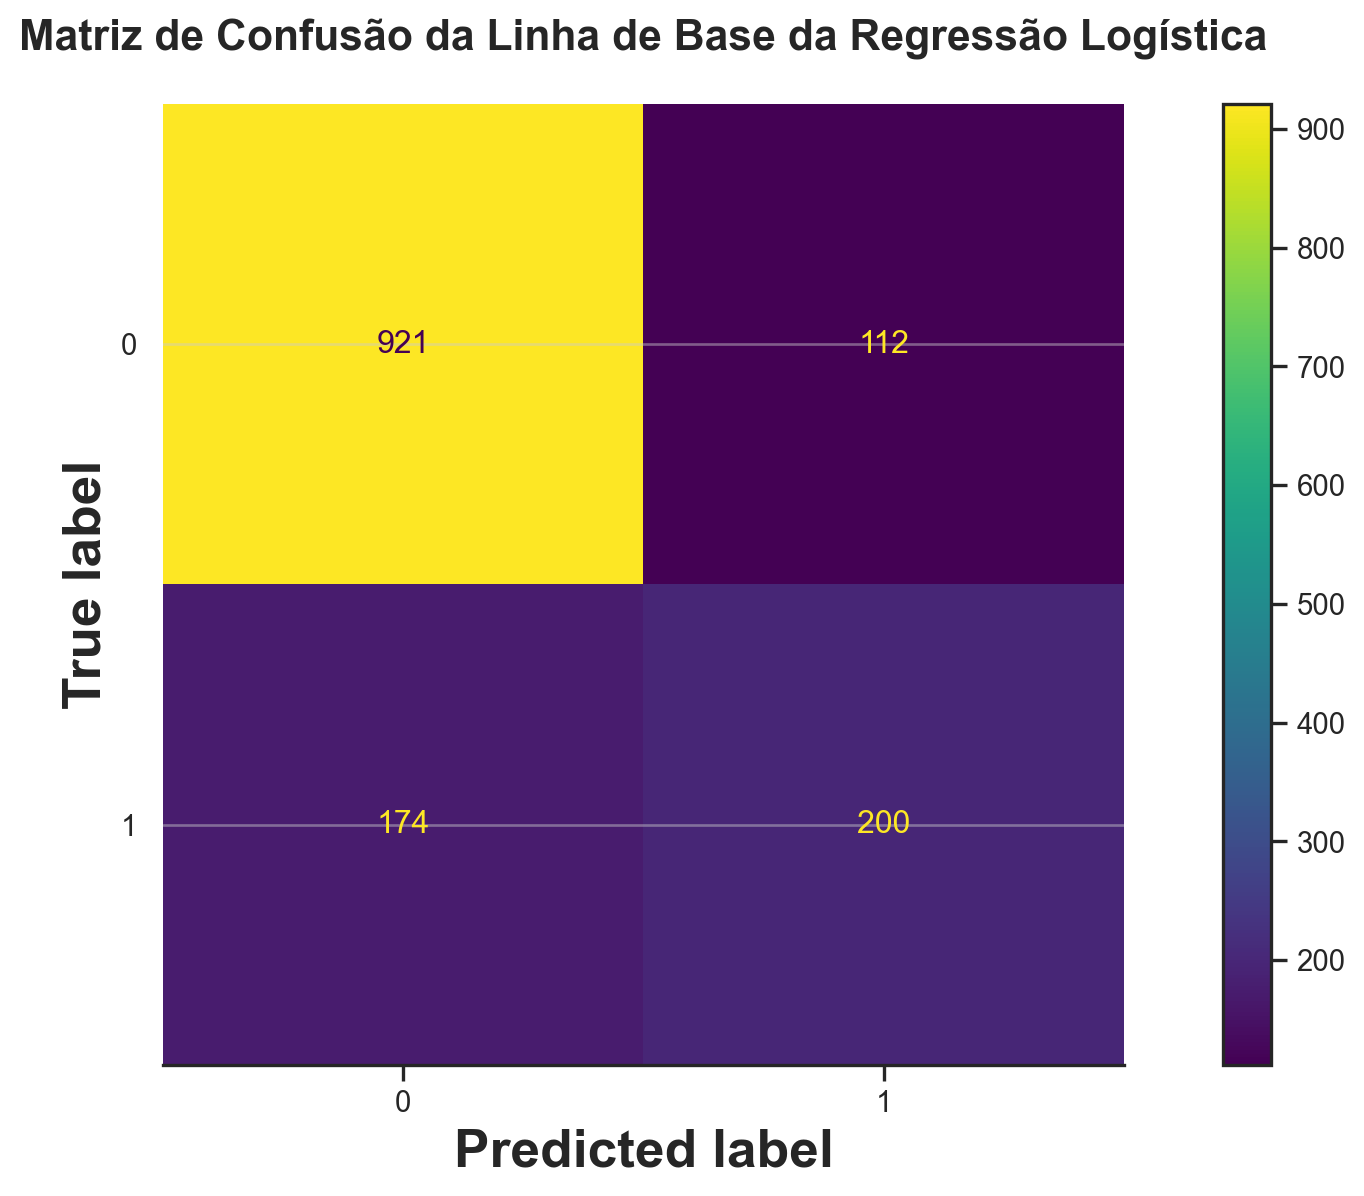

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

baseline_model.fit(train_features, train_labels)
y_pred = baseline_model.predict(test_features)

disp = ConfusionMatrixDisplay.from_predictions(test_labels, y_pred)
plt.title("Matriz de Confusão da Linha de Base da Regressão Logística", fontsize=16)

plt.show()


**Insights — Matriz de Confusão**
- A matriz de confusão indica a presença de falsos negativos, significando que uma parte dos clientes que churnam é incorretamente classificada como não-churn.
- Do ponto de vista de negócio, os falsos negativos representam oportunidades de retenção perdidas, reforçando a importância de otimizar o recall para a classe de churn.
- Esse comportamento suporta a decisão de priorizar o recall como a principal métrica de otimização nas etapas subsequentes de modelagem.

<span style="color:steelblue; text-align: left">

### Função de Decisão
</span>

Em aprendizado de máquina, a função de decisão é uma função que recebe um conjunto de características e produz um limite de decisão que separa diferentes classes em um problema de classificação. É frequentemente usada em tarefas de classificação binária, onde existem duas classes possíveis (ex.: "positivo" ou "negativo").

A função de decisão funciona atribuindo uma pontuação a cada instância nos dados de entrada, com base em sua distância do limite de decisão. O sinal da pontuação indica de qual lado do limite a instância se encontra e pode ser usado para prever o rótulo da classe.

Por exemplo, em um modelo de máquina de vetor de suporte (SVM) linear, a função de decisão é uma equação linear que recebe um conjunto de características e produz um valor escalar:

```Python
y = w_1 * x_1 + w_2 * x_2 + ... + w_n * x_n + b
```

onde:
- `x_1, x_2, ..., x_n` são as características de entrada,
- `w_1, w_2, ..., w_n` são os pesos atribuídos a cada característica,
- e `b` é o termo de viés.

A saída y é a pontuação atribuída à instância, e seu sinal indica de qual lado do limite de decisão ela se encontra.

Em outros modelos, como regressão logística ou árvores de decisão, a função de decisão pode ter uma forma ou estrutura diferente, mas a ideia básica é a mesma: atribuir pontuações ou probabilidades a cada instância com base em suas características e usar essas pontuações para prever o rótulo da classe.

A função de decisão pode ser útil para entender como um modelo de classificação funciona e diagnosticar quaisquer erros ou vieses que ele possa ter. Ao visualizar o limite de decisão ou analisar as pontuações atribuídas a diferentes instâncias, podemos obter insights sobre como o modelo está fazendo suas previsões e quais características são mais importantes para a tarefa de classificação.

Para produzir uma resposta binária, os classificadores produzem uma pontuação de valor real que é limiarizada. Por exemplo, a regressão logística produz uma probabilidade (um valor entre 0,0 e 1,0); e as observações com uma pontuação igual ou superior a 0,5 produzem uma saída binária positiva (muitos outros modelos usam o limiar de 0,5 por padrão).

No entanto, usar o limiar padrão de 0,5 é subótimo. Portanto, buscaremos o melhor limiar para nosso classificador binário conforme mostrado abaixo.

```Python
# Uma alternativa para personalizar a função de decisão.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred[:, 1] >= 0.46)
```
Mudar o limiar do nosso modelo mudará os valores na matriz de confusão. Na previsão, usamos a função predict, que retorna uma resposta binária (ou seja, usa 0,5 como limiar); no entanto, podemos usar a `função predict_proba` para obter a probabilidade bruta e usar um limiar personalizado:


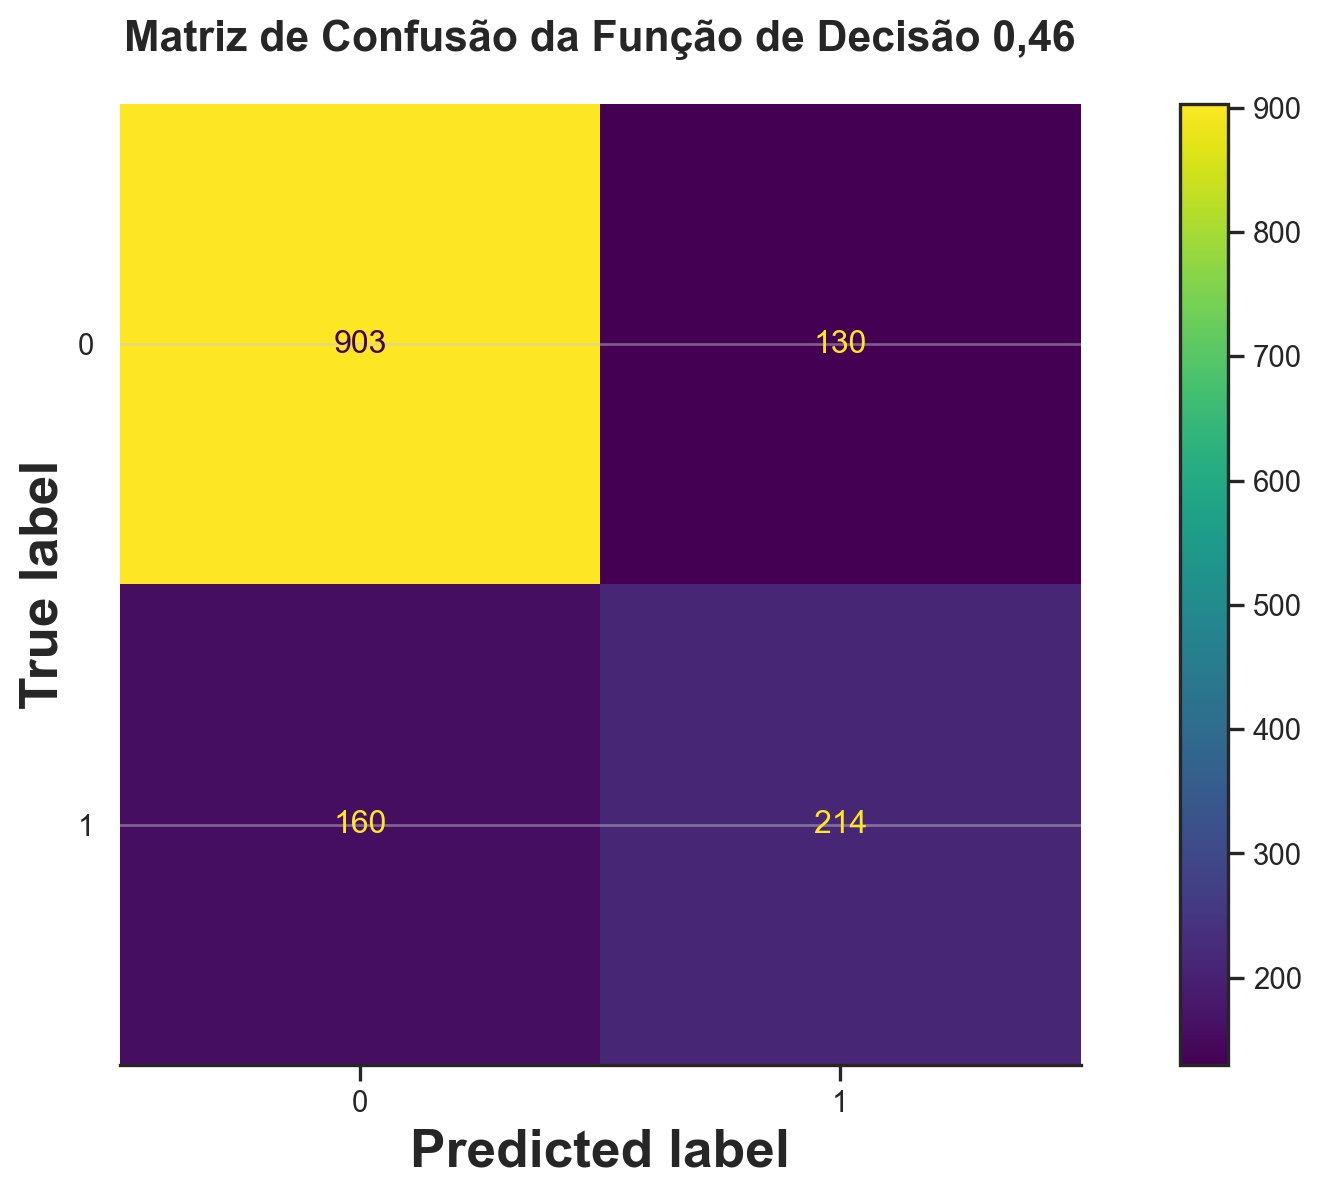

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = baseline_model.predict_proba(test_features)

ConfusionMatrixDisplay.from_predictions(test_labels, y_pred[:, 1] >= 0.46)
plt.title("Matriz de Confusão da Função de Decisão 0,46", fontsize=16)

plt.show()

**Insights — Otimização de Limiar**
- O desempenho do modelo varia significativamente entre diferentes valores de limiar, confirmando que os resultados de classificação dependem fortemente da seleção do limiar.
- Valores de limiar mais baixos (aproximadamente entre 0,20 e 0,25) aumentam o recall e melhoram a capacidade do modelo de identificar churners, às custas de taxas mais altas de falsos positivos.
- Valores de limiar mais altos (aproximadamente entre 0,40 e 0,45) melhoram a precisão e o F1-score, reduzindo falsos positivos enquanto sacrificam o recall.
- O limiar ótimo não é universal e deve ser selecionado de acordo com as compensações específicas exigidas pelo contexto de negócio.

Pronto!

<span style="color:steelblue; text-align: left">

#### Executando experimentos com a Função de Decisão
</span>

Obteremos a precisão, recall e outras estatísticas ao longo de vários valores de limiar para entender melhor como o limiar os afeta.


In [58]:
from tqdm import tqdm 

def highlight_greaterthan(s, threshold, column):
    is_max = pd.Series(data=False, index=s.index)
    is_max[column] = s.loc[column] == threshold
    return ['background-color: lime' if is_max.any() else '' for v in is_max]

# Definir função para destacar linhas
def highlight_row(row):
    if row.Threshold >= 0.42 and row.Threshold <= 0.421:
        return ['background-color: royalblue'] * len(row)
    
    elif row.Threshold >= 0.22 and row.Threshold <= 0.221:
        return ['background-color: lime'] * len(row)
    
    #elif row.Threshold >= 0.26 and row.Threshold <= 0.261:
    #    return ['background-color: lime'] * len(row)
    
    else:
        return [''] * len(row)
    

df_metric = pd.DataFrame(columns=['Threshold', 'Roc_auc', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro'])

for threshold in tqdm(np.linspace(0, 1, 101), total=101, position=0):
    roc_auc     = roc_auc_score(test_labels, y_pred[:, 1] >= threshold,     average='macro')
    accuracy    = balanced_accuracy_score(test_labels, y_pred[:, 1] >= threshold)
    precision   = precision_score(test_labels, y_pred[:, 1] >= threshold,   average='macro', zero_division=0)
    f1          = f1_score(test_labels, y_pred[:, 1] >= threshold,          average='macro', zero_division=0)
    recall      = recall_score(test_labels, y_pred[:, 1] >= threshold,      average='macro', zero_division=0)
    df_metric.loc[len(df_metric)] = [threshold, roc_auc, accuracy, precision, recall, f1]


df_metric.style.apply(highlight_row, axis=1)

100%|██████████| 101/101 [00:00<00:00, 128.96it/s]


,Threshold,Roc_auc,Accuracy,Precision_macro,Recall_macro,F1_macro
0,0.000000,0.500000,0.500000,0.132907,0.500000,0.209994
1,0.010000,0.540289,0.540289,0.635541,0.540289,0.296975
2,0.020000,0.586387,0.586387,0.646958,0.586387,0.384172
3,0.030000,0.617595,0.617595,0.653258,0.617595,0.439688
4,0.040000,0.626169,0.626169,0.651644,0.626169,0.457770
5,0.050000,0.639837,0.639837,0.655659,0.639837,0.480372
6,0.060000,0.653505,0.653505,0.660001,0.653505,0.502355
7,0.070000,0.664983,0.664983,0.661733,0.664983,0.523064
8,0.080000,0.680703,0.680703,0.667054,0.680703,0.548068
9,0.090000,0.686741,0.686741,0.668327,0.686741,0.558902


**Insights — Comportamento das Métricas ao Longo dos Limiares**:
- As curvas de ROC AUC e Acurácia Balanceada permanecem alinhadas ao longo dos limiares, indicando desempenho de discriminação estável e tratamento adequado do desequilíbrio de classes.
- Precisão, recall e F1-score exibem o comportamento esperado de compensação, onde melhorias em uma métrica frequentemente resultam em degradação de outra.
- Essa compensação destaca a necessidade de definir um objetivo de otimização claro antes de selecionar a configuração final do modelo.

Vamos confirmar visualmente no gráfico abaixo:


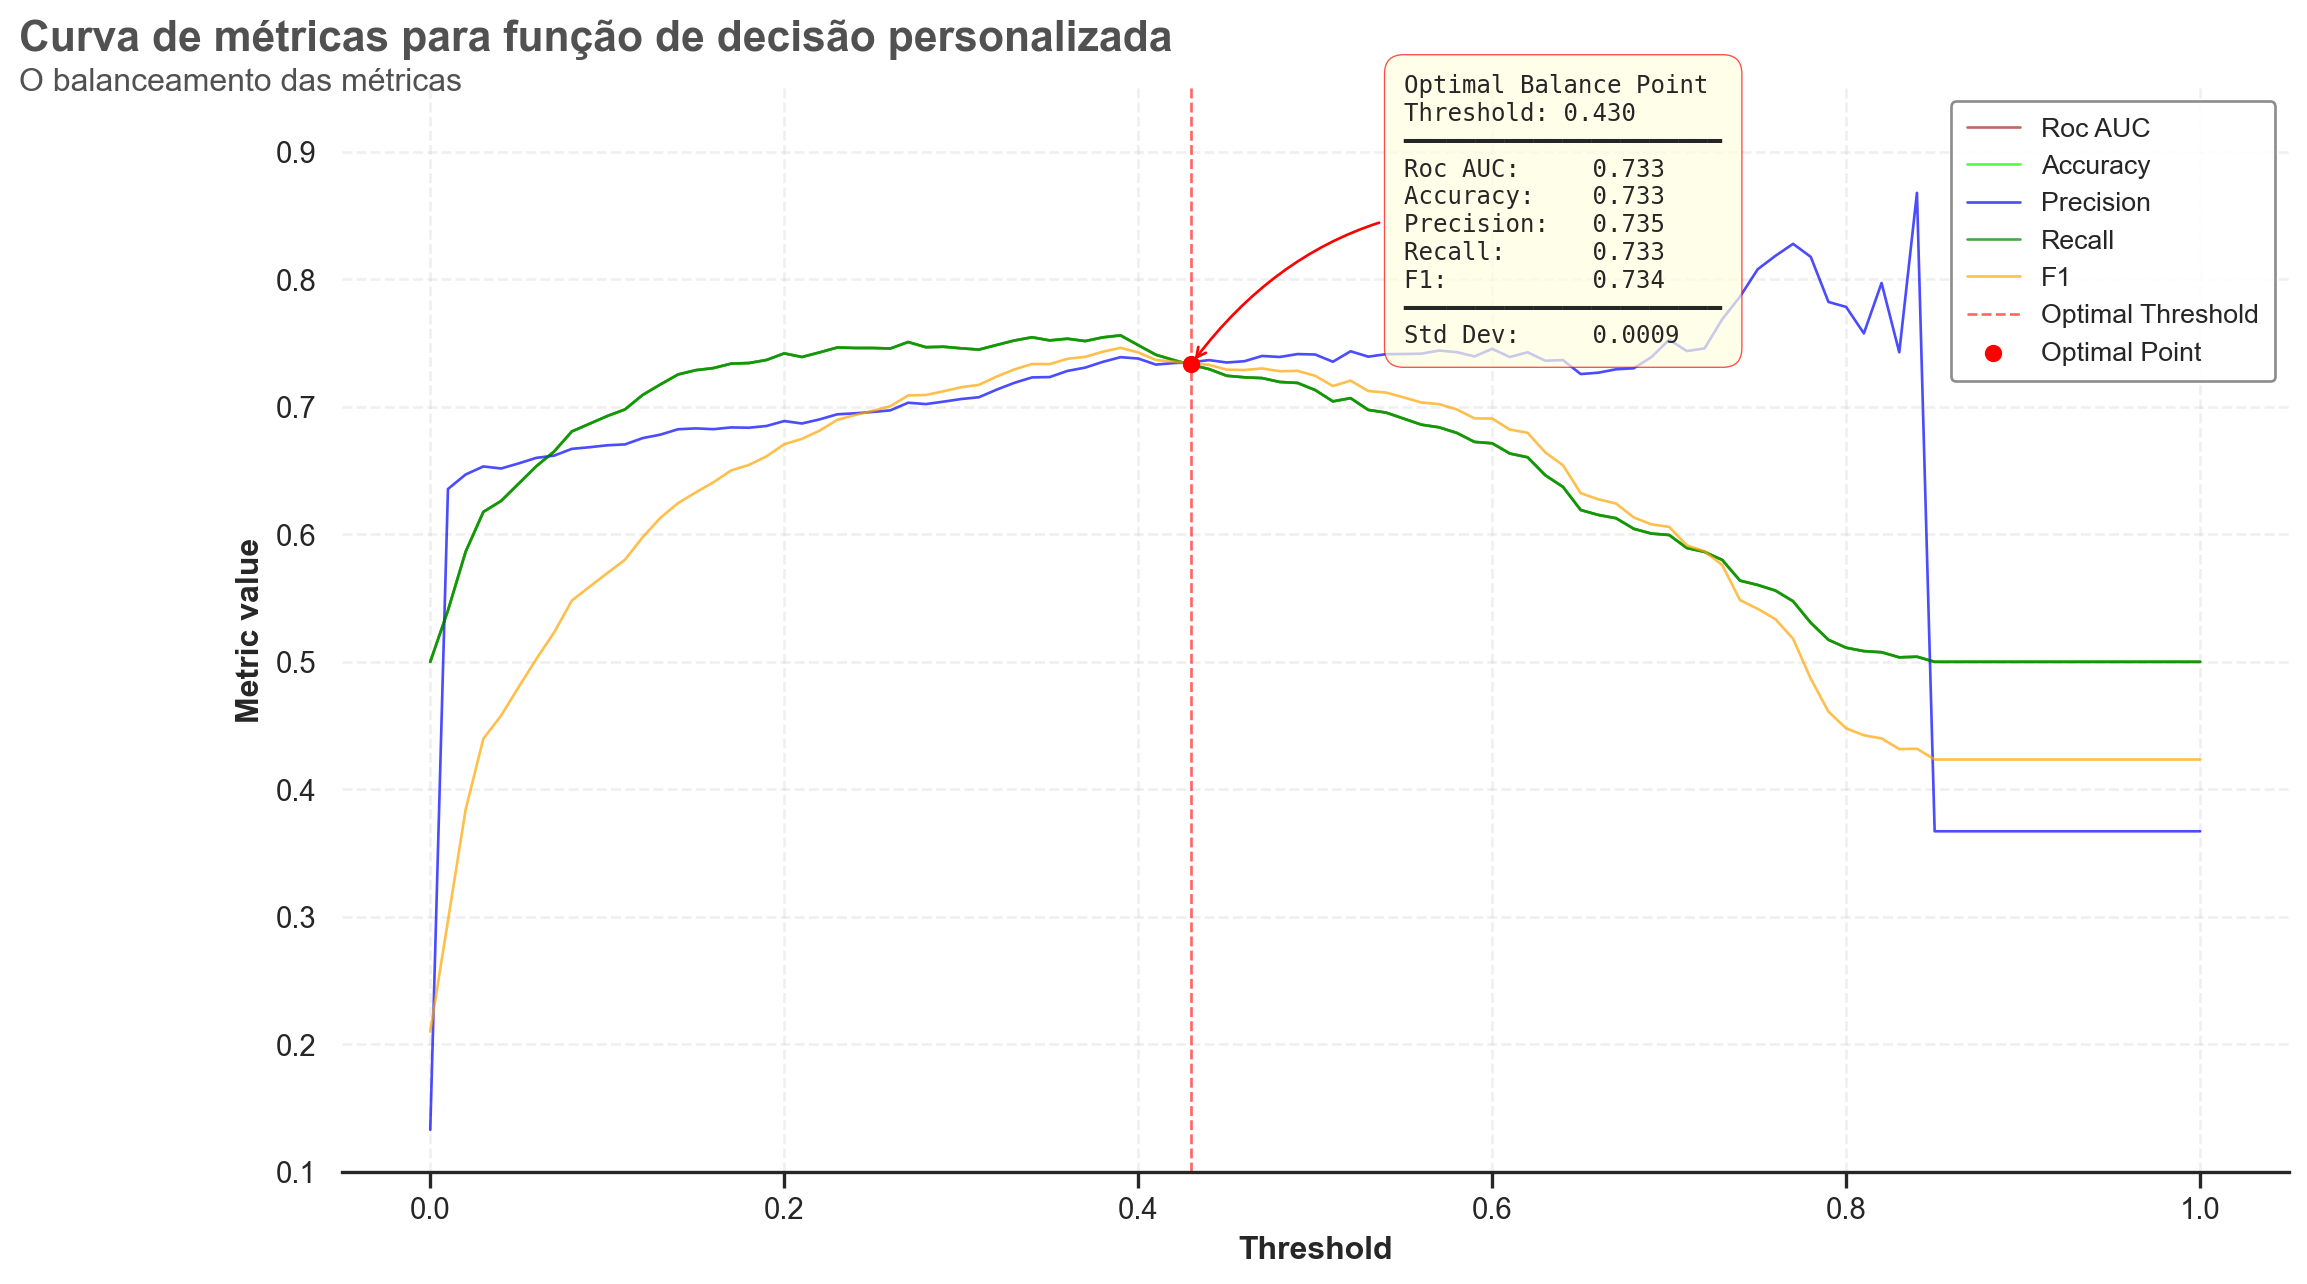

In [70]:
def find_intersection_point(df_metric):
    """
    Encontra o ponto onde as métricas se cruzam (melhor ajuste)
    Usa minimização da variância entre as métricas
    
    Returns:
        tuple: (threshold_optimal, metrics_at_optimal)
    """
    # Calcular a variância das métricas em cada threshold
    metrics_cols = ['Roc_auc', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro']
    
    # Normalizar as métricas para mesma escala
    metrics_df = df_metric[metrics_cols].copy()
    
    # Calcular desvio padrão (quanto menor, mais próximas as métricas estão)
    df_metric['std_metrics'] = metrics_df.std(axis=1)
    
    # Encontrar o threshold com menor desvio (melhor convergência)
    optimal_idx = df_metric['std_metrics'].idxmin()
    optimal_threshold = df_metric.loc[optimal_idx, 'Threshold']
    
    # Valores das métricas no ponto ótimo
    optimal_metrics = {
        'Roc_auc': df_metric.loc[optimal_idx, 'Roc_auc'],
        'Accuracy': df_metric.loc[optimal_idx, 'Accuracy'],
        'Precision': df_metric.loc[optimal_idx, 'Precision_macro'],
        'Recall': df_metric.loc[optimal_idx, 'Recall_macro'],
        'F1': df_metric.loc[optimal_idx, 'F1_macro'],
        'std': df_metric.loc[optimal_idx, 'std_metrics']
    }
    
    return optimal_threshold, optimal_metrics

def plot_metrics(df_metric, show_intersection=True):
    """
    Plota métricas com destaque no ponto de intersecção
    
    Args:
        df_metric: DataFrame com colunas Threshold, Roc_auc, Accuracy, 
                Precision_macro, Recall_macro, F1_macro
        show_intersection: Se True, mostra ponto e comentário de intersecção
    """
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plotar métricas
    ax.plot(df_metric.Threshold, df_metric.Roc_auc, color='brown', alpha=0.7,
                label='Roc AUC', linewidth=1)
    ax.plot(df_metric.Threshold, df_metric.Accuracy, color='lime', alpha=0.7,
                label='Accuracy', linewidth=1)
    ax.plot(df_metric.Threshold, df_metric.Precision_macro, color='blue', alpha=0.7,
                label='Precision', linewidth=1)
    ax.plot(df_metric.Threshold, df_metric.Recall_macro, color='green', alpha=0.7,
                label='Recall', linewidth=1)
    ax.plot(df_metric.Threshold, df_metric.F1_macro, color='orange', alpha=0.7,
                label='F1', linewidth=1)

    # Encontrar e plotar ponto de intersecção
    if show_intersection:
        optimal_threshold, optimal_metrics = find_intersection_point(df_metric)
        
        # Plotar linha vertical no threshold ótimo
        ax.axvline(x=optimal_threshold, color='red', linestyle='--', 
                linewidth=1, alpha=0.6, label='Optimal Threshold')
        
        # Plotar ponto de intersecção
        avg_metric = np.mean([
            optimal_metrics['Roc_auc'],
            optimal_metrics['Accuracy'],
            optimal_metrics['Precision'],
            optimal_metrics['Recall'],
            optimal_metrics['F1']
        ])
        ax.scatter(optimal_threshold, avg_metric, color='red', s=30, 
                zorder=5, edgecolors='red', linewidth=1, label='Optimal Point')
        
        # Criar texto com informações do ponto ótimo
        info_text = (
            f"Optimal Balance Point\n"
            f"Threshold: {optimal_threshold:.3f}\n"
            f"━━━━━━━━━━━━━━━━━━━━━━\n"
            f"Roc AUC:     {optimal_metrics['Roc_auc']:.3f}\n"
            f"Accuracy:    {optimal_metrics['Accuracy']:.3f}\n"
            f"Precision:   {optimal_metrics['Precision']:.3f}\n"
            f"Recall:      {optimal_metrics['Recall']:.3f}\n"
            f"F1:          {optimal_metrics['F1']:.3f}\n"
            f"━━━━━━━━━━━━━━━━━━━━━━\n"
            f"Std Dev:     {optimal_metrics['std']:.4f}"
        )
        
        # Adicionar caixa de texto com anotação
        # Posicionar a caixa baseado no threshold (esquerda ou direita)
        if optimal_threshold < 0.5:
            bbox_x = optimal_threshold + 0.12
            ha_align = 'left'
        else:
            bbox_x = optimal_threshold - 0.12
            ha_align = 'right'
        
        ax.annotate(info_text,
                xy=(optimal_threshold, avg_metric),
                xytext=(bbox_x, 0.75),
                fontsize=9,
                family='monospace',
                bbox=dict(boxstyle='round,pad=0.8', 
                            facecolor='lightyellow', 
                            alpha=0.7, 
                            edgecolor='red', 
                            linewidth=0.5),
                    arrowprops=dict(arrowstyle='->', 
                                connectionstyle='arc3,rad=0.3',
                                color='red',
                                lw=1),
                    ha=ha_align)

    plt.xlabel('Threshold', fontsize=12, weight='bold')
    plt.ylabel('Metric value', fontsize=12, weight='bold')

    # Adicionar título e subtítulo
    ax.text(x=0.0, y=.93, 
        s="Curva de métricas para função de decisão personalizada", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=16, 
        weight='bold', 
        alpha=.8)

    ax.text(x=0.0, y=.90, 
        s="O balanceamento das métricas", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=12, 
        alpha=.8)

    # Melhorar layout
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0.1, 0.95])
    
    plt.legend(loc='best', fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.show()
    
plot_metrics(df_metric, show_intersection=True)    

**`Insights e Considerações — Função de Decisão`:**

A análise da função de decisão demonstra que o desempenho do modelo não é determinado apenas pelo algoritmo de aprendizado, mas também pela escolha do limiar de classificação. As curvas de métricas ilustram claramente a relação inerente entre precisão e recall: à medida que o limiar aumenta, a precisão melhora enquanto o recall se deteriora, e vice-versa. Esse comportamento confirma que o limiar padrão de 0,5 não é necessariamente ótimo, particularmente em cenários de classificação desbalanceada como a previsão de churn.

Do ponto de vista prático, a seleção do limiar torna-se uma decisão estratégica em vez de puramente técnica. Limiares mais baixos favorecem o recall, permitindo a identificação de uma proporção maior de churners, o que é crítico em estratégias focadas em retenção. Por outro lado, limiares mais altos melhoram a precisão, reduzindo falsos positivos e tornando-os mais adequados para intervenções sensíveis a custos. O comportamento relativamente estável do ROC AUC e da acurácia balanceada ao longo dos limiares indica ainda que o modelo mantém poder discriminativo consistente, enquanto a variação em outras métricas reflete diferentes compensações operacionais.

Uma vantagem importante dessa abordagem é que a otimização do limiar é computacionalmente econômica, pois aproveita as saídas probabilísticas de um modelo já treinado sem exigir retreinamento ou complexidade adicional do modelo. Isso o torna um mecanismo altamente eficiente para ajuste de desempenho, especialmente quando comparado a alternativas mais custosas como otimização de hiperparâmetros ou ensemble de modelos.

Além disso, armazenar as métricas de avaliação ao longo dos limiares fornece uma baseline estruturada que pode ser diretamente comparada com modelos e pipelines futuros. Isso permite um framework de avaliação consistente e reproduzível, garantindo que as melhorias sejam medidas objetivamente e não influenciadas por escolhas arbitrárias de limiar.

Portanto, em vez de adotar um limiar fixo, o modelo deve ser implantado com um limiar alinhado aos objetivos de negócio. Essa abordagem transforma o classificador em uma ferramenta flexível de suporte à decisão, capaz de se adaptar a diferentes restrições operacionais e prioridades estratégicas.


In [79]:
from json import dumps, loads
import numpy as np
import pandas as pd


def save_threshold_metrics(
    df_metric: pd.DataFrame,
    thresholds: list[float],
    metric_df: pd.DataFrame,
    baseline_estimator_name: str = "LogisticRegression",
    baseline_encoder_name: str = "OrdinalEncoder",
    baseline_data_model: str = "Baseline",
    threshold_data_model: str = "Baseline + Threshold tuning",
    w_recall: float = 7.0,
    w_precision: float = 3.0,
    w_time: float = 0.0,
    time_reference: float = 1.0,
    metric_path: str = "./dataset/metric_dataframe.csv"
) -> pd.DataFrame:
    """
    Save threshold tuning results into metric_dataframe, inheriting
    training and timing information from the baseline row.

    Parameters
    ----------
    df_metric : pd.DataFrame
        DataFrame containing threshold metrics.
    thresholds : list[float]
        Thresholds to persist.
    metric_df : pd.DataFrame
        Existing metric dataframe.
    baseline_estimator_name : str, default="LogisticRegression"
        Estimator name used in baseline row lookup.
    baseline_encoder_name : str, default="OrdinalEncoder"
        Encoder/pipeline name used in baseline row lookup.
    baseline_data_model : str, default="Baseline"
        Baseline data model tag.
    threshold_data_model : str, default="Baseline + Threshold tuning"
        Threshold tuning data model tag.
    w_recall : float, default=7.0
        Weight assigned to recall in business score.
    w_precision : float, default=3.0
        Weight assigned to precision in business score.
    w_time : float, default=0.0
        Weight assigned to time penalty in business score.
    time_reference : float, default=1.0
        Reference value used to scale time penalty.
    metric_path : str, default="./dataset/metric_dataframe.csv"
        Path to save metric dataframe.

    Returns
    -------
    pd.DataFrame
        Updated metric dataframe.
    """
    if isinstance(metric_df.index, pd.MultiIndex):
        metric_df = metric_df.reset_index()

    baseline_mask = (
        (metric_df["Estimator"] == baseline_estimator_name)
        & (metric_df["Optimization/Data model"] == baseline_data_model)
        & (metric_df["Pre-Process Pipeline"] == baseline_encoder_name)
    )

    if not baseline_mask.any():
        raise KeyError(
            "Baseline row not found in metric_df: "
            f"{(baseline_estimator_name, baseline_data_model, baseline_encoder_name)}"
        )

    baseline_row = metric_df.loc[baseline_mask].iloc[0]

    try:
        baseline_params = loads(baseline_row.get("Parameters", "{}") or "{}")
    except Exception:
        baseline_params = {}

    if not isinstance(baseline_params, dict):
        baseline_params = {}

    business_weights = dumps({
        "w_recall": w_recall,
        "w_precision": w_precision,
        "w_time": w_time,
        "time_reference": time_reference
    })

    fit_time = baseline_row.get("Fit Time", np.nan)
    score_time = baseline_row.get("Score Time", np.nan)
    total_time = baseline_row.get("Total Time", np.nan)

    for threshold in thresholds:
        row = df_metric.loc[np.isclose(df_metric["Threshold"], threshold)]

        if row.empty:
            print(f"[WARN] Threshold {threshold:.4f} não encontrado em df_metric.")
            continue

        row = row.iloc[0]
        pipeline_name = f"{baseline_encoder_name} | thr={threshold:.2f}"
        row_identity = {
            "Estimator": baseline_estimator_name,
            "Optimization/Data model": threshold_data_model,
            "Pre-Process Pipeline": pipeline_name,
        }

        # pontuação de negócio
        if pd.notna(total_time) and time_reference > 0:
            time_penalty = total_time / time_reference
        else:
            time_penalty = 0.0

        weight_sum = w_recall + w_precision + w_time
        if weight_sum <= 0:
            raise ValueError("A soma dos pesos deve ser maior que zero.")

        wr = w_recall / weight_sum
        wp = w_precision / weight_sum
        wt = w_time / weight_sum

        business_score = (
            (wr * row["Recall_macro"]) +
            (wp * row["Precision_macro"]) -
            (wt * time_penalty)
        )

        threshold_params = {
            **baseline_params,
            "threshold": float(threshold),
        }

        values_to_save = {
            **row_identity,
            "Train Roc auc": baseline_row.get("Train Roc auc", np.nan),
            "Test Roc auc": row["Roc_auc"],
            "Train Balanced Accuracy": baseline_row.get("Train Balanced Accuracy", np.nan),
            "Test Balanced Accuracy": row["Accuracy"],
            "Train Recall": baseline_row.get("Train Recall", np.nan),
            "Test Recall": row["Recall_macro"],
            "Train Precision": baseline_row.get("Train Precision", np.nan),
            "Test Precision": row["Precision_macro"],
            "Train F1": baseline_row.get("Train F1", np.nan),
            "Test F1": row["F1_macro"],
            "Parameters": dumps(threshold_params, default=str),
            "Fit Time": fit_time,
            "Score Time": score_time,
            "Total Time": total_time,
            "Business Score": business_score,
            "Business Weights": business_weights
        }

        row_mask = (
            (metric_df["Estimator"] == row_identity["Estimator"])
            & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
            & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
        )

        if row_mask.any():
            metric_df = metric_df.loc[~row_mask].copy()

        new_row = pd.DataFrame([values_to_save])

        if metric_df.empty:
            metric_df = new_row
        else:
            metric_df = pd.concat(
                [metric_df, new_row],
                ignore_index=True,
            )

    metric_df.to_csv(metric_path, index=False)
    return metric_df

metric_dataframe = save_threshold_metrics(
    df_metric=df_metric,
    thresholds=[0.22, 0.42],
    metric_df=metric_dataframe,
    baseline_estimator_name="LogisticRegression",
    baseline_encoder_name="OrdinalEncoder",
    baseline_data_model="Baseline",
    threshold_data_model="Baseline + Threshold tuning",
    w_recall=7,
    w_precision=3,
    w_time=0,
    time_reference=1.0
)

In [84]:
# Threshold específico
print("Threshold específico (0.22)")
resultado_b = metric_dataframe.loc[
    (metric_dataframe["Estimator"] == "LogisticRegression") & 
    (metric_dataframe["Optimization/Data model"] == "Baseline + Threshold tuning") &
    (metric_dataframe["Pre-Process Pipeline"] == "OrdinalEncoder | thr=0.22")
]
print(f"Linhas encontradas: {len(resultado_b)}")
print(resultado_b[["Pre-Process Pipeline", "Test Roc auc", "Test Recall", "Test Precision", "Business Score"]])

Threshold específico (0.22)
Linhas encontradas: 1
         Pre-Process Pipeline  Test Roc auc  Test Recall  Test Precision  Business Score
25  OrdinalEncoder | thr=0.22      0.742724     0.742724        0.690171        0.726958


In [85]:
# Threshold específico
print("Threshold específico (0.42)")
resultado_b = metric_dataframe.loc[
    (metric_dataframe["Estimator"] == "LogisticRegression") & 
    (metric_dataframe["Optimization/Data model"] == "Baseline + Threshold tuning") &
    (metric_dataframe["Pre-Process Pipeline"] == "OrdinalEncoder | thr=0.42")
]
print(f"Linhas encontradas: {len(resultado_b)}")
print(resultado_b[["Pre-Process Pipeline", "Test Roc auc", "Test Recall", "Test Precision", "Business Score"]])

Threshold específico (0.42)
Linhas encontradas: 1
         Pre-Process Pipeline  Test Roc auc  Test Recall  Test Precision  Business Score
26  OrdinalEncoder | thr=0.42      0.736703     0.736703        0.734327        0.735991


<span style="color:steelblue; text-align: left">

### Função de Decisão e ROC AUC — Análise Conceitual
</span>

A função de decisão define como as probabilidades previstas são convertidas em rótulos de classe em modelos de classificação binária. Na Regressão Logística, o modelo produz uma probabilidade $P(y=1 \mid X)$, e um limiar é aplicado para determinar a previsão final. Por padrão, esse limiar é 0,5, mas esse valor não é necessariamente ótimo, especialmente em conjuntos de dados desbalanceados como o churn de clientes.

Para melhorar o desempenho do modelo, múltiplos limiares no intervalo $([0, 1])$ foram avaliados, analisando seu impacto nas principais métricas de classificação.

#### Relação entre Limiar e Métricas

* Limiares mais baixos aumentam o número de casos positivos previstos: maior Recall, menor Precisão
* Limiares mais altos tornam o modelo mais conservador: maior Precisão, menor Recall
* Limiares intermediários equilibram ambas as métricas: tipicamente maximizam o F1-score

Esse comportamento caracteriza a clássica relação entre sensibilidade e especificidade, claramente observada nas curvas de métricas.


#### Interpretação do ROC AUC sob Variação de Limiar

* ROC AUC foi calculado usando previsões limiarizadas em vez de probabilidades contínuas
* Isso torna o ROC AUC numericamente próximo da Acurácia Balanceada
* Ambas as métricas refletem a capacidade do modelo de equilibrar verdadeiros positivos e verdadeiros negativos em um limiar fixo
* A região entre os limiares 0,22 e 0,42 representa a zona de desempenho mais estável

Isso indica que o modelo mantém poder discriminativo consistente em diferentes limites de decisão.

#### Região de Limiar Ótimo

* Limiar ≈ 0,22: maximiza o Recall, adequado para cenários focados em recall como prevenção de churn
* Limiar ≈ 0,42: melhora Precisão e F1, fornecendo um limite de decisão mais equilibrado

O limiar ótimo deve ser selecionado de acordo com o objetivo de negócio em vez de depender do valor padrão.

#### Considerações Computacionais

* A calibração do limiar não requer retreinamento do modelo
* Opera diretamente nas probabilidades previstas
* O custo computacional é baixo e escala linearmente com o número de limiares

Isso o torna uma etapa de otimização altamente eficiente com impacto significativo no desempenho do modelo.

#### Integração com o Framework de Avaliação do Modelo

* Os resultados foram armazenados no mesmo `metric_dataframe` usado para comparação de modelos
* Marcado como `"Baseline + Calibração de Limiar"` para garantir rastreabilidade
* Inclui: métricas de desempenho, tempo de execução herdado do baseline, parâmetros de decisão e pontuação de negócio

Isso garante consistência, reprodutibilidade e comparabilidade entre diferentes modelos e configurações.

#### Insight Principal

* O limiar de decisão é um parâmetro controlável que afeta diretamente o comportamento do modelo
* Ajustar o limiar permite que o mesmo modelo se adapte a diferentes requisitos de negócio
* Essa abordagem melhora o desempenho sem aumentar o custo computacional


<span style="color:steelblue; text-align: left">

### Treinar modelos
</span>

#### Treinar Modelos

Nesta etapa, múltiplos modelos são treinados usando o que definimos como um *pipeline dinâmico*.

Um pipeline dinâmico é uma estrutura flexível onde as etapas de pré-processamento não são fixas, mas se adaptam de acordo com o estimador sendo avaliado. Isso permite que diferentes modelos operem sob suas condições ótimas de pré-processamento dentro do mesmo framework de otimização.

#### Pacote de Software Optuna

`Optuna` é um framework de código aberto para otimização de hiperparâmetros em modelos de aprendizado de máquina. Ele automatiza a busca por configurações ótimas explorando o espaço de hiperparâmetros de forma eficiente.

Hiperparâmetros são valores definidos antes do treinamento, como taxa de aprendizado, força de regularização ou profundidade da árvore. Ajustar esses parâmetros manualmente é demorado e frequentemente subótimo.

O Optuna resolve isso usando **otimização bayesiana**, equilibrando:

* exploração: testando novas regiões do espaço de busca
* explotação: refinando regiões de alto desempenho conhecidas

Em cada iteração, o Optuna sugere novas configurações com base nos resultados anteriores, visando otimizar uma função objetivo predefinida.

Neste projeto, o Optuna é usado além do ajuste tradicional de hiperparâmetros:

* seleciona estratégias de pré-processamento
* avalia técnicas de reamostragem
* compara múltiplos estimadores
* identifica o melhor pipeline de ponta a ponta

Na prática, o Optuna é usado para automatizar não apenas o ajuste de modelos, mas a seleção do **pipeline de modelagem completo**.

#### Estratégia de Oversampling e Undersampling

Uma regra fundamental em aprendizado de máquina é:

* nunca aplicar reamostragem antes de dividir os dados

Aplicar oversampling ou undersampling antes da divisão pode duplicar observações entre os conjuntos de treino e teste, levando a **vazamento de dados** e resultados excessivamente otimistas.

Para evitar isso:

* os dados são primeiro divididos em conjuntos de treinamento e teste
* a reamostragem é aplicada apenas dentro do processo de treinamento
* a validação cruzada é usada para garantir robustez

Isso é alcançado usando pipelines, onde a reamostragem está incorporada em cada fold:

* a reamostragem ocorre apenas nos folds de treinamento
* os folds de validação permanecem intocados

Isso garante que a avaliação do modelo permaneça não tendenciosa.


#### Considerações sobre Overfitting

Overfitting ocorre quando um modelo captura ruído em vez de padrões subjacentes, levando a uma generalização ruim.

Isso é especialmente comum em modelos flexíveis como:

* árvores de decisão
* métodos de ensemble
* modelos não lineares

Para mitigar o overfitting:

* aumentar `min_samples_split` e `min_samples_leaf`
* controlar a complexidade do modelo (ex.: profundidade, características)
* aplicar técnicas de subamostragem
* usar validação cruzada

Esses parâmetros são explorados dinamicamente durante a otimização.

#### Validação Cruzada Estratificada

Para garantir distribuição consistente de classes entre as divisões, **StratifiedKFold** é usado.

* preserva as proporções de classes em cada fold
* reduz a variância na avaliação do modelo
* é essencial para conjuntos de dados desbalanceados

Exemplo:

```python
kfolds = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)

scores = cross_validate(
    pipe,
    X, y,
    cv=kfolds,
    scoring=scoring,
    n_jobs=-1
)
```

#### Problema de Conjunto de Dados Desbalanceado

O churn de clientes é um problema típico de classificação desbalanceada, onde uma classe supera significativamente a outra.

Isso leva a:

* viés em direção à classe majoritária
* baixo desempenho na classe minoritária
* métricas enganosas como acurácia

Para abordar isso:

* técnicas de reamostragem são aplicadas: oversampling, undersampling ou métodos híbridos
* a distribuição de classes é tratada dentro do pipeline
* a avaliação prioriza métricas robustas ao desequilíbrio

A biblioteca `imbalanced-learn` é usada para implementar essas estratégias de forma consistente e segura contra vazamento.

#### Estendendo o Espaço de Busca do Optuna

O Optuna é tradicionalmente usado para ajuste de hiperparâmetros, mas aqui seu papel é estendido.

Em vez de otimizar apenas parâmetros do modelo, o espaço de busca inclui:

* estratégias de codificação
* métodos de escalonamento
* técnicas de reamostragem
* métodos de seleção de características
* seleção de modelo

Isso transforma o processo de otimização em um **problema de busca de pipeline**, onde o Optuna avalia estratégias completas de modelagem em vez de componentes isolados.

### Função Objetivo do Optuna

A função objetivo define o processo de otimização:

* construindo o pipeline dinamicamente
* amostrando estratégias de pré-processamento e modelagem
* avaliando o desempenho usando validação cruzada
* retornando a métrica a ser otimizada

Além disso:

* todas as métricas relevantes são registradas
* o custo computacional é rastreado
* os resultados são armazenados para comparação

Isso garante que o processo de otimização seja:

* transparente
* reproduzível
* totalmente auditável

<span style="color:steelblue; text-align: left">

#### Função objetivo do Optuna
</span>

A função objetivo define o processo de otimização:
construindo o pipeline dinamicamente, amostrando estratégias de pré-processamento e modelagem, avaliando o desempenho usando validação cruzada, retornando a métrica a ser otimizada.

Além disso: todas as métricas relevantes são registradas, o custo computacional é rastreado, os resultados são armazenados para comparação.

Isso garante que o processo de otimização seja transparente, reproduzível e totalmente auditável.


In [118]:
from pandas.api.types import is_string_dtype

idx_column = [
    column_name
    for column_name in train_features.columns
    if is_string_dtype(train_features[column_name])
]

idx_column

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [86]:
import logging
import sys
import gc
from tempfile import mkdtemp
from shutil import rmtree
from json import dumps

import numpy as np
import pandas as pd

import xgboost
from xgboost import XGBClassifier
import lightgbm 
from lightgbm import LGBMClassifier

import sklearn
from sklearn import linear_model, ensemble, tree, neural_network

from sklearn.model_selection import train_test_split
from sklearn.metrics import (   balanced_accuracy_score,
                                f1_score, 
                                precision_score, 
                                recall_score, 
                                classification_report )
from sklearn.metrics import make_scorer                                
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
                                GradientBoostingClassifier, 
                                ExtraTreesClassifier,  
                                RandomForestClassifier, 
                                )
from sklearn.linear_model import ( 
                                LogisticRegression, 
                                SGDClassifier )

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import chi2
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import (
                                    SequentialFeatureSelector,
                                    SelectKBest, mutual_info_regression,
                                    RFE, SelectFromModel)

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold, cross_val_score
import sklearn.preprocessing
from sklearn.preprocessing import MaxAbsScaler, QuantileTransformer, Normalizer, KBinsDiscretizer

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as Pipeline_imblearn
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import balanced_accuracy_score

import re

import optuna
from optuna.samplers import TPESampler

import category_encoders
from category_encoders import (BackwardDifferenceEncoder,
                                BinaryEncoder,
                                GrayEncoder,
                                CountEncoder,
                                HashingEncoder,
                                HelmertEncoder,
                                OneHotEncoder,
                                OrdinalEncoder,
                                SumEncoder,
                                PolynomialEncoder,
                                BaseNEncoder,
                                LeaveOneOutEncoder,
                                TargetEncoder,
                                WOEEncoder,
                                MEstimateEncoder,
                                JamesSteinEncoder,
                                CatBoostEncoder,
                                GLMMEncoder,
                                QuantileEncoder,
                                SummaryEncoder,
                                RankHotEncoder)
from feature_engine.encoding import (MeanEncoder, 
                                    CountFrequencyEncoder,
                                    DecisionTreeEncoder)

# Oversampling
import imblearn
from imblearn import over_sampling
from imblearn.over_sampling import SMOTE
from collections import Counter
from tqdm import tqdm 

import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn import set_config
import pickle
import gzip
from platform import python_version

print('Python version : ', python_version())
print('Sklearn version : ', sklearn.__version__)
print('Pandas version : ', pd.__version__)
print('Numpy version : ', np.__version__)
print('Imblearn version :', imblearn.__version__)
print('Optuna version :', optuna.__version__)


Python version :  3.11.15
Sklearn version :  1.8.0
Pandas version :  3.0.2
Numpy version :  2.4.4
Imblearn version : 0.14.1
Optuna version : 4.8.0


<span style="color:steelblue; text-align: left">

#### Chamando a classe otimizadora para treinar os modelos
</span>


In [87]:
from __future__ import annotations

import gc
from pathlib import Path
from shutil import rmtree
from tempfile import mkdtemp
from pandas.api.types import is_string_dtype

import category_encoders
import lightgbm
import numpy as np
import optuna
import xgboost

from feature_engine.encoding import (
    CountFrequencyEncoder,
    DecisionTreeEncoder,
    MeanEncoder,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from optuna.samplers import TPESampler
from sklearn import ensemble, linear_model, neural_network, tree
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.feature_selection import (
    RFE,
    SelectFromModel,
    SelectKBest,
    SequentialFeatureSelector,
    mutual_info_classif,
)
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
)
import catboost
from catboost import CatBoostClassifier


def define_estimators() -> tuple[
    list[str],
    list[str],
    list[str],
    list[str],
    list[str],
    list[str],
    list[str],
]:
    """
    Build and return the estimator groups used in the experiment.
    """
    linear_estimators = [
        estimator for estimator in set(linear_model.__all__)
        if "Class" in estimator
    ]
    linear_estimators.append("LogisticRegression")

    ensemble_estimators = [
        estimator for estimator in set(ensemble.__all__)
        if "Class" in estimator
    ]

    tree_estimators = [
        estimator for estimator in set(tree.__all__)
        if "Class" in estimator
    ]

    neural_estimators = [
        estimator for estimator in set(neural_network.__all__)
        if "Class" in estimator
    ]

    xgb_estimators = ["XGBClassifier"]
    lgbm_estimators = ["LGBMClassifier"]

    estimators = (
        linear_estimators +
        ensemble_estimators +
        tree_estimators
    )

    excluded_estimators = {
        "StackingClassifier",
        "RidgeClassifierCV",
        "SGDOneClassSVM",
        "VotingClassifier",
        "AdaBoostClassifier",
        "BaggingClassifier",
    }

    estimators = [est for est in estimators if est not in excluded_estimators]
    estimators.extend(["LogisticRegression", "XGBClassifier", "LGBMClassifier"])

    catboost_estimators = ["CatBoostClassifier"]

    return (
        linear_estimators,
        ensemble_estimators,
        tree_estimators,
        neural_estimators,
        xgb_estimators,
        lgbm_estimators,
        catboost_estimators,
        estimators,
    )

def get_estimator(
    estimator_name: str,
    linear_estimators: list[str],
    ensemble_estimators: list[str],
    tree_estimators: list[str],
    neural_estimators: list[str],
    xgb_estimators: list[str],
    lgbm_estimators: list[str],
    catboost_estimators: list[str],
) -> object:
    """
    Return the estimator class from its name.
    """
    if estimator_name in linear_estimators:
        return getattr(linear_model, estimator_name)

    if estimator_name in ensemble_estimators:
        return getattr(ensemble, estimator_name)

    if estimator_name in tree_estimators:
        return getattr(tree, estimator_name)

    if estimator_name in xgb_estimators:
        return getattr(xgboost, estimator_name)

    if estimator_name in lgbm_estimators:
        return getattr(lightgbm, estimator_name)

    if estimator_name in catboost_estimators:
        return getattr(catboost, estimator_name)
    
    return getattr(neural_network, estimator_name)


class EarlyStoppingCallback:
    def __init__(self, patience: int = 20, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.no_improvement_count = 0

    def __call__(self, study, trial):
        if trial.value is None:
            return

        current_score = study.best_value

        if self.best_score is None:
            self.best_score = current_score
            return

        improvement = current_score - self.best_score

        if improvement > self.min_delta:
            self.best_score = current_score
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1

        if self.no_improvement_count >= self.patience:
            study.stop()
            
class Optimizer:
    """
    Optimize a full classification pipeline with Optuna.
    """

    def __init__(
        self,
        estimator_name: str,
        balanced: bool,
        train_features,
        train_labels,
        cv,
        random_seed: int,
        x_reference,
        ratio_min: float | None = None,
        ratio_max: float | None = None,
        resampler: str = "",
        sampling_method: str = "",
        trials: int = 50,
        early_stopping_patience: int = 20,
        early_stopping_min_delta: float = 1e-4,
        timeout: int | None = 300,
        test_features: pd.DataFrame | None = None,
        test_labels: np.ndarray | None = None,
        metric_df: pd.DataFrame | None = None,
    ) -> None:
        self.estimator_name = estimator_name
        self.balanced = balanced
        self.train_features = train_features
        self.train_labels = train_labels
        self.cv = cv
        self.random_seed = random_seed
        self.x_reference = x_reference

        self.resampler = resampler
        self.sampling_method = sampling_method
        self.trials = trials
        self.sampler = TPESampler(seed=random_seed)
        self.early_stopping_patience = early_stopping_patience
        self.early_stopping_min_delta = early_stopping_min_delta
        self.timeout = timeout
        self.invalid_configs = set()
        
        self.test_features = test_features
        self.test_labels = test_labels
        self.metric_df = metric_df
        
        # Garantir que ratio_min e ratio_max sejam ambos None ou ambos float, 
        # e que ratio_min <= ratio_max quando ambos são fornecidos
        if ratio_min is not None and ratio_max is not None:
            self.ratio_min = min(float(ratio_min), float(ratio_max))
            self.ratio_max = max(float(ratio_min), float(ratio_max))
            
        else:
            self.ratio_min = ratio_min
            self.ratio_max = ratio_max

        (
            self.linear_estimators,
            self.ensemble_estimators,
            self.tree_estimators,
            self.neural_estimators,
            self.xgb_estimators,
            self.lgbm_estimators,
            self.catboost_estimators,
            self.available_estimators,
        ) = define_estimators()

        # Definir o dicionário completo de pontuação para validação cruzada
        self.scoring_full = {
            "roc_auc": make_scorer(roc_auc_score, average="macro"),
            "precision_macro": make_scorer(precision_score, average="macro"),
            "recall_macro": make_scorer(recall_score, average="macro"),
            "f1_macro": make_scorer(f1_score, average="macro"),
            "balanced_accuracy": make_scorer(balanced_accuracy_score),
        }

        self.scoring_objective = {
            "recall_macro": make_scorer(
                recall_score,
                average="macro",
                zero_division=0,
            )
        }
        
        # Definir o caminho para salvar configurações inválidas
        self.invalid_path = Path("./dataset/invalid_configs.csv")

        cols = [
            "estimator", "encoder", "scaler",
            "normalizer", "selector", "sampler"
        ]

        # Carregar configurações inválidas existentes se o arquivo existir, 
        # caso contrário inicializar um DataFrame vazio
        if self.invalid_path.exists():
            self.invalid_df = pd.read_csv(self.invalid_path)
            
        else:
            self.invalid_df = pd.DataFrame(columns=cols)
        
    def _sig(self, encoder, scaler, normalizer, selector, sampler):
        """_summary_

        Args:
            encoder (_type_): _description_
            scaler (_type_): _description_
            normalizer (_type_): _description_
            selector (_type_): _description_
            sampler (_type_): _description_

        Returns:
            _type_: _description_
        """
        return {
            "estimator": self.estimator_name,
            "encoder": encoder or "None",
            "scaler": scaler or "None",
            "normalizer": normalizer or "None",
            "selector": selector or "None",
            "sampler": sampler or "None",
        }
        
    def build_config_signature(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
    ) -> dict:
        """
        Build a readable configuration signature.
        """
        return {
            "estimator": self.estimator_name,
            "encoder": encoder_name or "None",
            "scaler": scaler_name or "None",
            "normalizer": normalizer_name or "None",
            "selector": selector_name or "None",
            "sampler": sampler_name or "None",
        }


    def was_invalid_config(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
    ) -> bool:
        """
        Check whether a configuration was previously marked as invalid.
        """
        signature = self.build_config_signature(
            encoder_name,
            scaler_name,
            normalizer_name,
            selector_name,
            sampler_name,
        )

        if self.invalid_df.empty:
            return False

        mask = (
            (self.invalid_df["estimator"] == signature["estimator"])
            & (self.invalid_df["encoder"] == signature["encoder"])
            & (self.invalid_df["scaler"] == signature["scaler"])
            & (self.invalid_df["normalizer"] == signature["normalizer"])
            & (self.invalid_df["selector"] == signature["selector"])
            & (self.invalid_df["sampler"] == signature["sampler"])
        )

        return bool(mask.any())


    def register_invalid_config(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
        reason: str = "",
    ) -> None:
        """
        Register an invalid configuration in memory.
        """
        signature = self.build_config_signature(
            encoder_name,
            scaler_name,
            normalizer_name,
            selector_name,
            sampler_name,
        )

        signature["reason"] = reason

        new_row = pd.DataFrame([signature])

        self.invalid_df = pd.concat(
            [self.invalid_df, new_row],
            ignore_index=True,
        )

        self.invalid_df.drop_duplicates(
            subset=[
                "estimator",
                "encoder",
                "scaler",
                "normalizer",
                "selector",
                "sampler",
            ],
            inplace=True,
        )


    def flush_invalid_configs(self) -> None:
        """
        Persist invalid configurations to disk.
        """
        self.invalid_df.to_csv(self.invalid_path, index=False)


    def is_invalid_pipeline(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
    ) -> bool:
        """
        Apply known invalid pipeline rules before model evaluation.
        """
        if self.estimator_name == "CatBoostClassifier":
            invalid_rules = [
                encoder_name not in ["NoEncoding", "NoCategoricalEncoder"],
                scaler_name not in ["NoScaling", None],
                normalizer_name not in ["NoNormalization", None],
                selector_name in ["RFE", "SequentialFeatureSelector"],
            ]

            return any(invalid_rules)

        return False
    
    def get_parameters(self, trial) -> dict:
        """
        Define estimator hyperparameters for Optuna.
        """
        params = {}

        if self.estimator_name == "SGDClassifier":
            params = {
                "max_iter": trial.suggest_int("max_iter", 300, 2000, log=True),
                "alpha": trial.suggest_float("alpha", 0.01, 1.0, log=True),
                "learning_rate": trial.suggest_categorical(
                    "learning_rate",
                    ["optimal", "constant", "invscaling"],
                ),
                "loss": trial.suggest_categorical(
                    "loss",
                    ["log_loss", "modified_huber"],
                ),
                "penalty": trial.suggest_categorical("penalty", ["l2", "l1"]),
                "eta0": trial.suggest_int("eta0", 1, 10, step=1),
                "early_stopping": True,
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "RandomForestClassifier":
            params = {
                "criterion": trial.suggest_categorical(
                    "criterion", ["entropy", "gini"]
                ),
                "max_depth": trial.suggest_int("max_depth", 5, 8, step=1),
                "max_features": trial.suggest_int("max_features", 7, 14, step=1),
                "n_estimators": trial.suggest_int(
                    "n_estimators", 140, 300, log=True
                ),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 20, 70, log=True
                ),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 2, 16, step=1
                ),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = trial.suggest_categorical(
                    "class_weight",
                    [{0: 0.265778, 1: 0.734222}, "balanced"],
                )

        elif self.estimator_name == "XGBClassifier":
            params = {
                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.1, 1.0, log=True
                ),
                "max_depth": trial.suggest_int("max_depth", 1, 6, step=1),
                "subsample": trial.suggest_float("subsample", 0.1, 1.0, log=True),
                "colsample_bytree": trial.suggest_float(
                    "colsample_bytree", 0.1, 1.0, log=True
                ),
            }
            if self.balanced and self.ratio_min is not None and self.ratio_max is not None:
                params["scale_pos_weight"] = trial.suggest_float(
                    "scale_pos_weight",
                    float(self.ratio_min),
                    float(self.ratio_max),
                    log=True,
                )

        elif self.estimator_name == "LGBMClassifier":
            params = {
                "objective": "binary",
                "metric": "binary_logloss",
                "boosting_type": "gbdt",
                "force_col_wise": True,
                "num_leaves": trial.suggest_int("num_leaves", 2, 256, step=1),
                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.01, 0.1, log=True
                ),
                "min_child_samples": trial.suggest_int(
                    "min_child_samples", 5, 100, log=True
                ),
                "subsample": trial.suggest_float("subsample", 0.1, 1.0, log=True),
                "colsample_bytree": trial.suggest_float(
                    "colsample_bytree", 0.1, 1.0, log=True
                ),
                "reg_alpha": trial.suggest_float(
                    "reg_alpha", 1e-9, 100.0, log=True
                ),
                "reg_lambda": trial.suggest_float(
                    "reg_lambda", 1e-9, 100.0, log=True
                ),
                "max_depth": trial.suggest_int("max_depth", -1, 8, step=1),
                "verbosity": -1,
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "LogisticRegression":
            params = {
                "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
                "solver": trial.suggest_categorical("solver", ["liblinear", "saga"]),
                "C": trial.suggest_float("C", 0.0025, 30.0, log=True),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "DecisionTreeClassifier":
            params = {
                "max_depth": trial.suggest_int("max_depth", 2, 16, log=True),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 20, 80, log=True
                ),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 10, 30, step=1
                ),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "ExtraTreeClassifier":
            params = {
                "criterion": trial.suggest_categorical(
                    "criterion", ["gini", "entropy"]
                ),
                "max_depth": trial.suggest_int("max_depth", 2, 90, log=True),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 2, 377, log=True
                ),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 2, 377, log=True
                ),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "ExtraTreesClassifier":
            params = {
                "max_depth": trial.suggest_int("max_depth", 2, 20, step=1),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 2, 377, log=True
                ),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 2, 377, log=True
                ),
                "random_state": self.random_seed,
            }

        return params

    def get_standardization(self, trial) -> tuple[object | None, str | None]:
        """
        Return the scaler object sampled by Optuna.
        """
        scaler_name = trial.suggest_categorical(
            "standardizer",
            ["MaxAbsScaler", "StandardScaler", "RobustScaler", None],
        )

        if scaler_name == "MaxAbsScaler":
            return MaxAbsScaler(), scaler_name
        if scaler_name == "StandardScaler":
            return StandardScaler(), scaler_name
        if scaler_name == "RobustScaler":
            return RobustScaler(), scaler_name
        return None, scaler_name

    def get_normalization(self, trial) -> tuple[object | None, str | None]:
        """
        Return the normalizer object sampled by Optuna.
        """
        normalizer_name = trial.suggest_categorical(
            "normalizer",
            [
                "PowerTransformer",
                "QuantileTransformer",
                "QuantileTransformerN",
                "MinMaxScaler",
                "Normalizer",
                None,
            ],
        )

        if normalizer_name == "PowerTransformer":
            return PowerTransformer(), normalizer_name
        if normalizer_name == "QuantileTransformer":
            return QuantileTransformer(output_distribution="uniform"), normalizer_name
        if normalizer_name == "QuantileTransformerN":
            return QuantileTransformer(output_distribution="normal"), normalizer_name
        if normalizer_name == "Normalizer":
            return Normalizer(), normalizer_name
        if normalizer_name == "MinMaxScaler":
            return MinMaxScaler(feature_range=(0, 1)), normalizer_name
        return None, normalizer_name

    def get_feature_selection(
        self,
        trial,
        estimator: object,
    ) -> tuple[object, str, int]:
        """
        Return the feature selector sampled by Optuna.
        """

        if self.estimator_name == "CatBoostClassifier":
            return "passthrough", "NoFeatureSelection", {}
        
        selector_name = trial.suggest_categorical(
            "selector",
            [
                "SelectKBest",
                "RFE",
                "SelectFromModel",
                "SequentialFeatureSelector",
            ],
        )
        n_features = trial.suggest_int("n_features_to_select", 6, 13, step=1)

        if selector_name == "SelectKBest":
            return (
                SelectKBest(score_func=mutual_info_classif, k=n_features),
                selector_name,
                n_features,
            )

        if selector_name == "RFE":
            return (
                RFE(estimator=estimator, n_features_to_select=n_features, step=1),
                selector_name,
                n_features,
            )

        if selector_name == "SelectFromModel":
            return (
                SelectFromModel(estimator=estimator),
                selector_name,
                n_features,
            )

        return (
            SequentialFeatureSelector(
                estimator=estimator,
                n_features_to_select="auto",
                cv=3,
                tol=None,
                direction="backward",
            ),
            selector_name,
            n_features,
        )

    def get_encoders(self, trial) -> tuple[object, str]:
        """
        Return the categorical encoder sampled by Optuna.
        """
        categorical = [
            column_name
            for column_name in self.x_reference.columns
            if is_string_dtype(self.x_reference[column_name])
        ]

        if not categorical:
            return "passthrough", "NoCategoricalEncoder"

        all_encoders = [
            "OrdinalEncoder",
            "OneHotEncoder",
            "BinaryEncoder",
            "BaseNEncoder",
            "HelmertEncoder",
            "SumEncoder",
            "PolynomialEncoder",
            "MeanEncoder",
            "CountFrequencyEncoder",
            "LeaveOneOutEncoder",
            "TargetEncoder",
            "CatBoostEncoder",
            "WOEEncoder",
            "MEstimateEncoder",
            "JamesSteinEncoder",
            "GLMMEncoder",
            "QuantileEncoder",
            "DecisionTreeEncoder",
        ]

        encoder_name = trial.suggest_categorical("encoder", all_encoders)

        if encoder_name == "OrdinalEncoder":
            return category_encoders.OrdinalEncoder(), encoder_name

        if encoder_name == "OneHotEncoder":
            return category_encoders.OneHotEncoder(), encoder_name

        if encoder_name == "BinaryEncoder":
            return category_encoders.BinaryEncoder(), encoder_name

        if encoder_name == "BaseNEncoder":
            return category_encoders.BaseNEncoder(), encoder_name

        if encoder_name == "HelmertEncoder":
            return category_encoders.HelmertEncoder(), encoder_name

        if encoder_name == "SumEncoder":
            return category_encoders.SumEncoder(), encoder_name

        if encoder_name == "PolynomialEncoder":
            return category_encoders.PolynomialEncoder(), encoder_name

        if encoder_name == "LeaveOneOutEncoder":
            return category_encoders.LeaveOneOutEncoder(), encoder_name

        if encoder_name == "TargetEncoder":
            return category_encoders.TargetEncoder(), encoder_name

        if encoder_name == "CatBoostEncoder":
            return category_encoders.CatBoostEncoder(), encoder_name

        if encoder_name == "WOEEncoder":
            return category_encoders.WOEEncoder(), encoder_name

        if encoder_name == "MEstimateEncoder":
            return category_encoders.MEstimateEncoder(), encoder_name

        if encoder_name == "JamesSteinEncoder":
            return category_encoders.JamesSteinEncoder(), encoder_name

        if encoder_name == "GLMMEncoder":
            return category_encoders.GLMMEncoder(), encoder_name

        if encoder_name == "QuantileEncoder":
            return category_encoders.QuantileEncoder(), encoder_name

        if encoder_name == "MeanEncoder":
            return MeanEncoder(variables=categorical), encoder_name

        if encoder_name == "CountFrequencyEncoder":
            return (
                CountFrequencyEncoder(
                    encoding_method="count",
                    variables=categorical,
                ),
                encoder_name,
            )

        if encoder_name == "DecisionTreeEncoder":
            return (
                DecisionTreeEncoder(
                    encoding_method="arbitrary",
                    cv=3,
                    scoring="recall_macro",
                    param_grid={"max_depth": [1, 2, 3, 4, 5, 6]},
                    regression=False,
                    variables=categorical,
                ),
                encoder_name,
            )

        raise ValueError(f"Unsupported encoder: {encoder_name}")    

    def get_sampler(self, trial) -> tuple[object | None, str | None]:
        """
        Return the sampler object used for imbalance handling.

        Automatic Optuna runs are limited to no sampler or SMOTE. A fixed
        resampler may still be passed, but only supported lightweight samplers
        are accepted.
        """
        sampler_name = None

        if self.resampler:
            sampler_name = self.resampler
        elif self.sampling_method == "Over":
            sampler_name = trial.suggest_categorical(
                "resampler",
                ["SMOTE"],
            )
        elif self.sampling_method in {"Under", "Combination"}:
            raise ValueError(
                f"{self.sampling_method}-sampling is disabled for automatic runs."
            )
        elif self.sampling_method:
            raise ValueError(
                f"Unsupported sampling method: {self.sampling_method}"
            )

        if sampler_name is None:
            return None, None

        if sampler_name == "SMOTE":
            return (
                SMOTE(
                    random_state=self.random_seed,
                    sampling_strategy="minority",
                ),
                sampler_name,
            )

        raise ValueError(f"Unsupported resampler: {sampler_name}")

    @staticmethod
    def build_num_transformer(
        scaler: object | None,
        normalizer: object | None,
    ) -> ImbPipeline | str:
        """
        Build numeric preprocessing pipeline using only valid steps.
        """
        steps = []

        if normalizer is not None:
            steps.append(("normalizer", normalizer))

        if scaler is not None:
            steps.append(("scaler", scaler))

        if not steps:
            return "passthrough"

        return ImbPipeline(steps=steps)

    @staticmethod
    def build_preprocessor(num_transformer) -> ColumnTransformer:
        """
        Build the column transformer for numeric variables.
        """
        return ColumnTransformer(
            transformers=[
                ("num", num_transformer, selector(dtype_exclude=object))
            ],
            remainder="passthrough",
            verbose_feature_names_out=False,
        )

    def build_pipeline(
        self,
        encoder: object,
        preprocessor: ColumnTransformer,
        sampler_: object | None,
        feature_selector: object,
        model: object,
        cache_dir: str,
    ) -> Pipeline:
        """
        Build the full pipeline dynamically.
        """
        components = [encoder, preprocessor]

        if not self.balanced and sampler_ is not None:
            components.append(sampler_)

        components.extend([feature_selector, model])

        return make_pipeline_with_sampler(*components, memory=cache_dir)

    def evaluate_pipeline(
        self,
        pipe,
        train_score: bool,
        scoring: dict,
        return_estimator: bool,
    ) -> dict:
        """
        Evaluate the pipeline using cross-validation.
        """
        return cross_validate(
            pipe,
            self.train_features,
            self.train_labels,
            cv=self.cv,
            return_train_score=train_score,
            scoring=scoring,
            return_estimator=return_estimator,
            verbose=0,
            n_jobs=-1,
        )

    def objective(self, trial) -> float:
        """
        Optuna objective function: optimize recall macro.
        """
        encoder, encoder_name = self.get_encoders(trial)
        sampler_, sampler_name = self.get_sampler(trial)
        scaler, scaler_name = self.get_standardization(trial)
        normalizer, normalizer_name = self.get_normalization(trial)

        num_transformer = self.build_num_transformer(scaler, normalizer)
        preprocessor = self.build_preprocessor(num_transformer)

        params = self.get_parameters(trial)

        estimator_cls = get_estimator(
            estimator_name=self.estimator_name,
            linear_estimators=self.linear_estimators,
            ensemble_estimators=self.ensemble_estimators,
            tree_estimators=self.tree_estimators,
            neural_estimators=self.neural_estimators,
            xgb_estimators=self.xgb_estimators,
            lgbm_estimators=self.lgbm_estimators,
            catboost_estimators=self.catboost_estimators,
        )

        model = estimator_cls(**params)

        feature_selector, selector_name, n_features = self.get_feature_selection(
            trial,
            estimator_cls(**params),
        )

        if self.is_invalid_pipeline(
            encoder_name=encoder_name,
            scaler_name=scaler_name,
            normalizer_name=normalizer_name,
            selector_name=selector_name,
            sampler_name=sampler_name,
        ):
            self.register_invalid_config(
                encoder_name=encoder_name,
                scaler_name=scaler_name,
                normalizer_name=normalizer_name,
                selector_name=selector_name,
                sampler_name=sampler_name,
                reason="Known invalid pipeline rule",
            )
            raise optuna.exceptions.TrialPruned()

        if self.was_invalid_config(
            encoder_name=encoder_name,
            scaler_name=scaler_name,
            normalizer_name=normalizer_name,
            selector_name=selector_name,
            sampler_name=sampler_name,
        ):
            raise optuna.exceptions.TrialPruned()

        cache_dir = mkdtemp()

        try:
            pipe = self.build_pipeline(
                encoder=encoder,
                preprocessor=preprocessor,
                sampler_=sampler_,
                feature_selector=feature_selector,
                model=model,
                cache_dir=cache_dir,
            )

            scores = self.evaluate_pipeline(
                pipe=pipe,
                train_score=False,
                scoring=self.scoring_objective,
                return_estimator=False,
            )

            score = float(np.nanmean(scores["test_recall_macro"]))

            if not np.isfinite(score):
                self.register_invalid_config(
                    encoder_name=encoder_name,
                    scaler_name=scaler_name,
                    normalizer_name=normalizer_name,
                    selector_name=selector_name,
                    sampler_name=sampler_name,
                    reason="Non-finite recall_macro score",
                )
                raise optuna.exceptions.TrialPruned()

            return score

        except Exception as error:
            self.register_invalid_config(
                encoder_name=encoder_name,
                scaler_name=scaler_name,
                normalizer_name=normalizer_name,
                selector_name=selector_name,
                sampler_name=sampler_name,
                reason=str(error)[:300],
            )
            raise optuna.exceptions.TrialPruned()

        finally:
            rmtree(cache_dir, ignore_errors=True)

            if gc.isenabled():
                gc.collect()
                
    def detailed_objective(self, trial) -> None:
        """
        Refit and log the best trial with the full set of metrics.
        """
        encoder, encoder_name = self.get_encoders(trial)
        sampler_, sampler_name = self.get_sampler(trial)
        scaler, scaler_name = self.get_standardization(trial)
        normalizer, normalizer_name = self.get_normalization(trial)

        num_transformer = self.build_num_transformer(scaler, normalizer)
        preprocessor = self.build_preprocessor(num_transformer)

        params = self.get_parameters(trial)

        estimator_cls = get_estimator(
            estimator_name=self.estimator_name,
            linear_estimators=self.linear_estimators,
            ensemble_estimators=self.ensemble_estimators,
            tree_estimators=self.tree_estimators,
            neural_estimators=self.neural_estimators,
            xgb_estimators=self.xgb_estimators,
            lgbm_estimators=self.lgbm_estimators,
            catboost_estimators=self.catboost_estimators,
        )

        model = estimator_cls(**params)

        feature_selector, selector_name, n_features = self.get_feature_selection(
            trial,
            estimator_cls(**params),
        )

        cache_dir = mkdtemp()

        try:
            pipe = self.build_pipeline(
                encoder=encoder,
                preprocessor=preprocessor,
                sampler_=sampler_,
                feature_selector=feature_selector,
                model=model,
                cache_dir=cache_dir,
            )

            scores = self.evaluate_pipeline(
                pipe=pipe,
                train_score=True,
                scoring=self.scoring_full,
                return_estimator=True,
            )

            pipe.fit(self.train_features, self.train_labels)

        finally:
            rmtree(cache_dir, ignore_errors=True)

            if gc.isenabled():
                gc.collect()

        pipeline_name_parts = []

        if encoder_name is not None:
            pipeline_name_parts.append(str(encoder_name).strip())

        if normalizer_name is not None:
            pipeline_name_parts.append(str(normalizer_name).strip())

        if scaler_name is not None:
            pipeline_name_parts.append(str(scaler_name).strip())

        if selector_name is not None:
            pipeline_name_parts.append(f"{selector_name} {n_features}")

        if sampler_name is not None:
            pipeline_name_parts.append(str(sampler_name).strip())

        pipeline_name = " ".join(pipeline_name_parts)

        optimization_name = "Recall Macro Opt"

        if self.balanced:
            optimization_name += " Balanced"
        else:
            optimization_name += f" {self.sampling_method}-sampling"

        '''save_model_and_metrics(
            self.estimator_name,
            pipeline_name,
            optimization_name,
            pipe,
            scores,
            params,
            metric_df=metric_dataframe,
        )'''
        
        self.metric_df = apply_threshold_decision(
            estimator_name=self.estimator_name,
            pipeline_name=pipeline_name,
            optimization_name=optimization_name,
            model=pipe,
            X_train=self.train_features,
            y_train=self.train_labels,
            X_test=self.test_features,
            y_test=self.test_labels,
            cv=self.cv,
            metric_df=self.metric_df,
            estimator_params=params,
            base_scores=scores,
        )
                
    def optimize(self) -> None:
        """
        Run Optuna optimization and persist the best trial.
        """
        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
        )
        
        early_stopping = EarlyStoppingCallback(
            patience=self.early_stopping_patience,
            min_delta=self.early_stopping_min_delta
        )

        study.optimize(
            self.objective,
            n_trials=self.trials,
            timeout=self.timeout,
            callbacks=[early_stopping],
        )
        
        completed_trials = [
            trial for trial in study.trials
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]

        self.flush_invalid_configs()

        if not completed_trials:
            print(f"[WARN] No completed trials for {self.estimator_name}.")
            return

        self.detailed_objective(study.best_trial)
        return self.metric_df

In [88]:
from __future__ import annotations

import gc
from typing import Iterable

import numpy as np
import pandas as pd
from tqdm import tqdm

import category_encoders

from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict

import numpy as np
import pandas as pd

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def get_positive_scores(model, X):
    """
    Return positive-class scores from a fitted classifier.

    Uses predict_proba when available. Otherwise, uses decision_function
    and rescales values to the [0, 1] interval.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        score_min = np.min(scores)
        score_max = np.max(scores)

        if score_max == score_min:
            return np.full_like(scores, fill_value=0.5, dtype=float)

        return (scores - score_min) / (score_max - score_min)

    raise AttributeError(
        "The model must implement either predict_proba or decision_function."
    )


def predict_with_threshold(model, X, threshold):
    """
    Predict binary labels using a custom threshold.
    """
    scores = get_positive_scores(model, X)
    return (scores >= threshold).astype(int)


def apply_threshold_decision(
    estimator_name: str,
    pipeline_name: str,
    optimization_name: str,
    model,
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    cv,
    metric_df: pd.DataFrame,
    estimator_params: dict | None = None,
    decision_metric: str = "Recall_macro",
    thresholds: np.ndarray | None = None,
    base_scores: dict[str, np.ndarray] | None = None,
) -> pd.DataFrame:
    """
    Tune the decision threshold and persist the selected experiment row.

    Threshold search uses out-of-fold training probabilities to avoid leakage.
    Timing metrics are inherited from the upstream cross-validation scores
    because this step reuses the already selected model structure.
    """
    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)

    y_proba_oof = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    rows = []

    for threshold in thresholds:
        y_pred = (y_proba_oof >= threshold).astype(int)

        recall = recall_score(
            y_train,
            y_pred,
            average="macro",
            zero_division=0,
        )
        precision = precision_score(
            y_train,
            y_pred,
            average="macro",
            zero_division=0,
        )

        rows.append({
            "Threshold": float(threshold),
            "Recall_macro": recall,
            "Precision_macro": precision,
            "F1_macro": f1_score(
                y_train,
                y_pred,
                average="macro",
                zero_division=0,
            ),
            "Balanced Accuracy": balanced_accuracy_score(y_train, y_pred),
        })

    df_thr = pd.DataFrame(rows)
    best_idx = df_thr[decision_metric].idxmax()
    best_row = df_thr.loc[best_idx]
    best_threshold = float(best_row["Threshold"])

    baseline_candidates = df_thr.loc[np.isclose(df_thr["Threshold"], 0.5)]

    if baseline_candidates.empty:
        baseline_idx = (df_thr["Threshold"] - 0.5).abs().idxmin()
        baseline_row = df_thr.loc[baseline_idx]
    else:
        baseline_row = baseline_candidates.iloc[0]

    improvement = best_row[decision_metric] - baseline_row[decision_metric]
    use_threshold = improvement > 0.002

    if use_threshold:
        final_threshold = best_threshold
        data_model_tag = f"{optimization_name} + Threshold tuning"
    else:
        final_threshold = 0.5
        data_model_tag = optimization_name

    y_test_score = model.predict_proba(X_test)[:, 1]
    y_train_pred = (y_proba_oof >= final_threshold).astype(int)
    y_test_pred = (y_test_score >= final_threshold).astype(int)

    if base_scores is None:
        fit_time = np.nan
        score_time = np.nan
    else:
        fit_time = float(np.mean(base_scores["fit_time"]))
        score_time = float(np.mean(base_scores["score_time"]))

    scores = {
        "train_roc_auc": [roc_auc_score(y_train, y_proba_oof)],
        "test_roc_auc": [roc_auc_score(y_test, y_test_score)],
        "train_balanced_accuracy": [
            balanced_accuracy_score(y_train, y_train_pred)
        ],
        "test_balanced_accuracy": [
            balanced_accuracy_score(y_test, y_test_pred)
        ],
        "train_recall_macro": [
            recall_score(
                y_train,
                y_train_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "test_recall_macro": [
            recall_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "train_precision_macro": [
            precision_score(
                y_train,
                y_train_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "test_precision_macro": [
            precision_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "train_f1_macro": [
            f1_score(
                y_train,
                y_train_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "test_f1_macro": [
            f1_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "fit_time": [fit_time],
        "score_time": [score_time],
    }

    threshold_params = dict(estimator_params or {})
    threshold_params["threshold"] = final_threshold

    metric_df = save_model_and_metrics(
        description=estimator_name,
        data_model=data_model_tag,
        encoder=f"{pipeline_name} | thr={final_threshold:.3f}",
        pipeline_obj=model,
        scores=scores,
        params=threshold_params,
        metric_df=metric_df,
    )
    return metric_df


def get_classification_scoring() -> dict:
    """
    Build the scoring dictionary used in cross-validation.

    Returns
    -------
    dict
        Dictionary of sklearn scorers.
    """
    return {
        "roc_auc": make_scorer(roc_auc_score, average="macro"),
        "precision_macro": make_scorer(precision_score, average="macro"),
        "recall_macro": make_scorer(recall_score, average="macro"),
        "f1_macro": make_scorer(f1_score, average="macro"),
        "balanced_accuracy": make_scorer(balanced_accuracy_score),
    }


def build_baseline_preprocessor() -> ColumnTransformer:
    """
    Build the preprocessing pipeline for the baseline model.

    Returns
    -------
    ColumnTransformer
        Preprocessing transformer.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("encoder", category_encoders.OrdinalEncoder())
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, selector(dtype_include=object)),
        ],
        remainder="passthrough"
    )


def run_baseline_estimator(
    estimator_name: str,
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    cv,
    random_seed: int,
    metric_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Train and persist a non-optimized baseline estimator using
    OrdinalEncoder and no resampling.

    Parameters
    ----------
    estimator_name : str
        Estimator class name.
    train_features : pd.DataFrame
        Training features.
    train_labels : np.ndarray
        Training labels.
    cv :
        Cross-validation splitter.
    random_seed : int
        Reproducibility seed.
    metric_df : pd.DataFrame
        Metrics dataframe.

    Returns
    -------
    pd.DataFrame
        Updated metrics dataframe.
    """
    (
        linear_estimators,
        ensemble_estimators,
        tree_estimators,
        neural_estimators,
        xgb_estimators,
        lgbm_estimators,
        catboost_estimators,
        _,
    ) = define_estimators()

    estimator_cls = get_estimator(
        estimator_name=estimator_name,
        linear_estimators=linear_estimators,
        ensemble_estimators=ensemble_estimators,
        tree_estimators=tree_estimators,
        neural_estimators=neural_estimators,
        xgb_estimators=xgb_estimators,
        lgbm_estimators=lgbm_estimators,
        catboost_estimators=catboost_estimators,
    )

    baseline_params = {}
    try:
        baseline_params["random_state"] = random_seed
        estimator = estimator_cls(**baseline_params)
        
    except TypeError:
        baseline_params = {}
        estimator = estimator_cls()

    model = Pipeline(
        steps=[
            ("preprocessor", build_baseline_preprocessor()),
            ("classifier", estimator),
        ]
    )

    scores = cross_validate(
        model,
        train_features,
        train_labels,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
        scoring=get_classification_scoring(),
        verbose=0,
        n_jobs=-1,
    )

    best_idx = int(np.argmax(scores["test_recall_macro"]))
    best_estimator = scores["estimator"][best_idx]

    metric_df = save_model_and_metrics(
        description=estimator_name,
        data_model="Baseline",
        encoder="OrdinalEncoder",
        pipeline_obj=best_estimator,
        scores=scores,
        params=baseline_params,
        metric_df=metric_df,
    )

    return metric_df


def run_optuna_experiments_for_estimator(
    estimator_name: str,
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    cv,
    x_reference: pd.DataFrame,
    random_seed: int,
    ratio_min: float | None = None,
    ratio_max: float | None = None,
    resampler: str = "",
    trials: int = 50,
) -> None:
    """
    Run the supported Optuna optimization modes for a given estimator.

    Parameters
    ----------
    estimator_name : str
        Estimator class name.
    train_features : pd.DataFrame
        Training features.
    train_labels : np.ndarray
        Training labels.
    cv :
        Cross-validation splitter.
    x_reference : pd.DataFrame
        Reference dataframe for dtype inspection.
    random_seed : int
        Reproducibility seed.
    ratio_min : float | None, default=None
        Minimum class ratio for XGBoost balancing.
    ratio_max : float | None, default=None
        Maximum class ratio for XGBoost balancing.
    resampler : str, default=""
        Optional fixed over-sampler name.
    trials : int, default=50
        Number of Optuna trials.
    """
    balanced_optimizer = Optimizer(
        estimator_name=estimator_name,
        balanced=True,
        train_features=train_features,
        train_labels=train_labels,
        cv=cv,
        random_seed=random_seed,
        x_reference=x_reference,
        ratio_min=ratio_min,
        ratio_max=ratio_max,
        resampler="",
        sampling_method="",
        trials=trials,
        test_features=test_features,
        test_labels=test_labels,
    )
    balanced_optimizer.optimize()

    over_optimizer = Optimizer(
        estimator_name=estimator_name,
        balanced=False,
        train_features=train_features,
        train_labels=train_labels,
        cv=cv,
        random_seed=random_seed,
        x_reference=x_reference,
        ratio_min=ratio_min,
        ratio_max=ratio_max,
        resampler=resampler,
        sampling_method="Over",
        trials=trials,
        test_features=test_features,
        test_labels=test_labels,
    )
    over_optimizer.optimize()


def train_all_models(
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    test_features: pd.DataFrame,
    test_labels: np.ndarray,
    cv,
    x_reference: pd.DataFrame,
    metric_df: pd.DataFrame,
    random_seed: int,
    ratio_min: float | None = None,
    ratio_max: float | None = None,
    estimators_to_run: Iterable[str] | None = None,
    fixed_resampler: str = "",
    trials: int = 50,
    run_baseline: bool = True,
    run_optuna: bool = True,
) -> pd.DataFrame:
    """
    Train multiple estimators through baseline and Optuna-optimized
    dynamic pipelines.

    Parameters
    ----------
    train_features : pd.DataFrame
        Training features.
    train_labels : np.ndarray
        Training labels.
    cv :
        Cross-validation splitter.
    x_reference : pd.DataFrame
        Reference dataframe used for dtype inspection.
    metric_df : pd.DataFrame
        Metrics dataframe.
    random_seed : int
        Reproducibility seed.
    ratio_min : float | None, default=None
        Minimum class ratio for XGBoost balancing.
    ratio_max : float | None, default=None
        Maximum class ratio for XGBoost balancing.
    estimators_to_run : Iterable[str] | None, default=None
        Optional subset of estimators.
    fixed_resampler : str, default=""
        Fixed over-sampler to use instead of the default SMOTE search.
    trials : int, default=50
        Number of Optuna trials.
    run_baseline : bool, default=True
        Whether to run the baseline experiment.
    run_optuna : bool, default=True
        Whether to run Optuna optimization.

    Returns
    -------
    pd.DataFrame
        Updated metrics dataframe.
    """
    
    (
        linear_estimators,
        ensemble_estimators,
        tree_estimators,
        neural_estimators,
        xgb_estimators,
        lgbm_estimators,
        catboost_estimators,
        _,
    ) = define_estimators()

    if estimators_to_run is not None:
        estimators = list(estimators_to_run)
    else:
        estimators = list(all_estimators)

    optuna_steps = 2 if run_optuna else 0
    total_steps = len(estimators) * (int(run_baseline) + optuna_steps)

    progress_bar = tqdm(
        total=total_steps,
        unit=" step",
        position=0,
        desc="Training pipelines"
    )

    try:
        for estimator_name in estimators:
            progress_bar.set_description(f"{estimator_name}")

            if run_baseline:
                metric_df = run_baseline_estimator(
                    estimator_name=estimator_name,
                    train_features=train_features,
                    train_labels=train_labels,
                    cv=cv,
                    random_seed=random_seed,
                    metric_df=metric_df,
                )
                progress_bar.update(1)

            if run_optuna:
                balanced_optimizer = Optimizer(
                    estimator_name=estimator_name,
                    balanced=True,
                    train_features=train_features,
                    train_labels=train_labels,
                    cv=cv,
                    random_seed=random_seed,
                    x_reference=x_reference,
                    ratio_min=ratio_min,
                    ratio_max=ratio_max,
                    resampler="",
                    sampling_method="",
                    trials=trials,
                    test_features=test_features,
                    test_labels=test_labels,
                    metric_df=metric_df,
                )
                updated_metric_df = balanced_optimizer.optimize()

                if updated_metric_df is not None:
                    metric_df = updated_metric_df

                progress_bar.update(1)

                over_optimizer = Optimizer(
                    estimator_name=estimator_name,
                    balanced=False,
                    train_features=train_features,
                    train_labels=train_labels,
                    cv=cv,
                    random_seed=random_seed,
                    x_reference=x_reference,
                    ratio_min=ratio_min,
                    ratio_max=ratio_max,
                    resampler=fixed_resampler,
                    sampling_method="Over",
                    trials=trials,
                    test_features=test_features,
                    test_labels=test_labels,
                    metric_df=metric_df,
                )
                updated_metric_df = over_optimizer.optimize()

                if updated_metric_df is not None:
                    metric_df = updated_metric_df

                progress_bar.update(1)

            gc.collect()

    finally:
        progress_bar.close()

    return metric_df

In [89]:
ratio_low = min(ratio_train, ratio_test)
ratio_high = max(ratio_train, ratio_test)


In [123]:

metric_dataframe = train_all_models(
    train_features=train_features,
    train_labels=train_labels,
    test_features=test_features,
    test_labels=test_labels,
    cv=kfolds,
    #x_reference=X,
    x_reference=train_features,
    metric_df=metric_dataframe,
    random_seed=RANDOM_SEED,
    ratio_min=ratio_low,
    ratio_max=ratio_high,
    #estimators_to_run=["SGDClassifier"],
    estimators_to_run=[
        'LogisticRegression',
        'SGDClassifier',
        'RandomForestClassifier',
        'ExtraTreeClassifier',
        'XGBClassifier',
        'LGBMClassifier',
        #'CatBoostClassifier',
        'HistGradientBoostingClassifier'
    ],
    fixed_resampler="",
    trials=100,
    run_baseline=True,
    run_optuna=True,
)

LogisticRegression:   5%|▍         | 1/21 [00:01<00:38,  1.94s/ step][I 2026-05-15 12:01:04,247] A new study created in memory with name: no-name-8edc5bbd-a39e-4d3f-9833-82a443360325
[I 2026-05-15 12:02:24,530] Trial 0 finished with value: 0.6787978438941124 and parameters: {'encoder': 'SumEncoder', 'standardizer': 'MaxAbsScaler', 'normalizer': 'Normalizer', 'penalty': 'l1', 'solver': 'saga', 'C': 0.09030420535762343, 'selector': 'SequentialFeatureSelector', 'n_features_to_select': 9}. Best is trial 0 with value: 0.6787978438941124.
[I 2026-05-15 12:02:25,781] Trial 1 finished with value: 0.6683394599708223 and parameters: {'encoder': 'OrdinalEncoder', 'standardizer': None, 'normalizer': 'Normalizer', 'penalty': 'l1', 'solver': 'liblinear', 'C': 0.16421274120049417, 'selector': 'RFE', 'n_features_to_select': 10}. Best is trial 0 with value: 0.6787978438941124.
[I 2026-05-15 12:02:28,145] Trial 2 finished with value: 0.7571052242802964 and parameters: {'encoder': 'SumEncoder', 'standard

<span style="color:steelblue; text-align: left">

#### DataFrame de resultados dos modelos
</span>

Então, vamos ver o desempenho de todos os modelos.


In [90]:
metric_dataframe.sort_values('Test Recall', ascending=False, inplace=True)
metric_dataframe 

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
0,LGBMClassifier,Recall Macro Opt Balanced,CatBoostEncoder PowerTransformer RFE 13 | thr=0.500,0.838865,0.830506,0.765584,0.756138,0.765584,0.756138,0.712469,0.702669,0.716161,0.701618,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",2.816028,0.081535,2.897563,0.740097,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
1,RandomForestClassifier,Recall Macro Opt Balanced + Threshold tuning,OneHotEncoder MinMaxScaler StandardScaler SelectFromModel 12 | thr=0.480,0.841632,0.834231,0.769750,0.756068,0.769750,0.756068,0.719724,0.706573,0.727580,0.711725,"{""criterion"": ""entropy"", ""max_depth"": 8, ""max_features"": 9, ""n_estimators"": 277, ""min_samples_split"": 51, ""min_samples_leaf"": 6, ""random_state"": 738, ""class_weight"": {""0"": 0.265778, ""1"": 0.734222}, ""threshold"": 0.48}",4.926755,0.163290,5.090045,0.741220,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
2,RandomForestClassifier,Recall Macro Opt Over-sampling + Threshold tuning,OneHotEncoder QuantileTransformer RobustScaler SelectFromModel 13 SMOTE | thr=0.450,0.839546,0.830899,0.767645,0.755838,0.767645,0.755838,0.718822,0.705546,0.727092,0.709733,"{""criterion"": ""gini"", ""max_depth"": 7, ""max_features"": 11, ""n_estimators"": 202, ""min_samples_split"": 34, ""min_samples_leaf"": 16, ""random_state"": 738, ""threshold"": 0.45}",5.097802,0.140025,5.237827,0.740751,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
3,SGDClassifier,Recall Macro Opt Balanced,GLMMEncoder QuantileTransformerN StandardScaler RFE 12 | thr=0.500,0.848833,0.841149,0.773824,0.754456,0.773824,0.754456,0.718435,0.700650,0.721771,0.697669,"{""max_iter"": 629, ""alpha"": 0.03153034676207791, ""learning_rate"": ""optimal"", ""loss"": ""log_loss"", ""penalty"": ""l2"", ""eta0"": 6, ""early_stopping"": true, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",5.297655,0.041179,5.338835,0.738314,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
4,LogisticRegression,Recall Macro Opt Over-sampling,JamesSteinEncoder PowerTransformer RobustScaler RFE 12 SMOTE | thr=0.500,0.847773,0.837393,0.771835,0.754109,0.771835,0.754109,0.725132,0.706243,0.735139,0.712459,"{""penalty"": ""l2"", ""solver"": ""saga"", ""C"": 1.4910169316251025, ""random_state"": 738, ""threshold"": 0.5}",1.365486,0.039512,1.404997,0.739749,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
5,LGBMClassifier,Recall Macro Opt Over-sampling,CatBoostEncoder PowerTransformer RFE 13 SMOTE | thr=0.500,0.839134,0.828063,0.767111,0.751390,0.767111,0.751390,0.715092,0.699544,0.720580,0.699601,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""threshold"": 0.5}",2.556364,0.081182,2.637547,0.735836,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
6,XGBClassifier,Recall Macro Opt Balanced + Threshold tu

<span style="color:steelblue; text-align: left">

#### O melhor resultado do classificador
</span>

Considerando o Recall macro como objetivo, aqui está o melhor resultado.


In [91]:
def _safe_model_part(value):
    return (
        str(value)
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace("|", "-")
        .replace(":", "-")
    )


def read_model(description, data_model, encoder=None, model_dir="./models/"):
    model_dir = Path(model_dir)

    if encoder is None:
        legacy_filename = f"{description}{data_model.replace(' ', '')}"
        candidates = [
            model_dir / legacy_filename,
            model_dir / f"{legacy_filename}.pkl.gz",
        ]
        candidates.extend(sorted(model_dir.glob(f"{description}_{data_model}_*.pkl.gz")))
        candidates.extend(sorted(model_dir.glob(f"{description}_{_safe_model_part(data_model)}*.pkl.gz")))
    else:
        safe_encoder = _safe_model_part(encoder)
        model_filename = f"{description}_{data_model}_{safe_encoder}.pkl.gz"
        candidates = [model_dir / model_filename]

    for model_path in candidates:
        if model_path.exists():
            with gzip.open(model_path, "rb") as f:
                return pickle.load(f)

    tried_paths = [str(path) for path in candidates]
    raise FileNotFoundError(f"Model file not found. Tried: {tried_paths}")


winner_pipeline = 'CatBoostEncoder PowerTransformer RFE 13 | thr=0.500'

best_model = read_model(
    description='LGBMClassifier',
    data_model='Recall Macro Opt Balanced',
    encoder=winner_pipeline,
)
display(
    f'Winner: LGBMClassifier Recall Macro Opt Balanced - {winner_pipeline}',
    best_model,
)

'Winner: LGBMClassifier Recall Macro Opt Balanced - CatBoostEncoder PowerTransformer RFE 13 | thr=0.500'

,steps,"[('catboostencoder', ...), ('columntransformer', ...), ...]"
,transform_input,None
,memory,'C:\\Users\\enior\\AppD...ocal\\Temp\\tmp8t_mn2yt'
,verbose,False
,verbose,0
,cols,"['gender', 'Partner', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


<span style="color:steelblue; text-align: left">

##### Matriz de confusão do melhor modelo
</span>


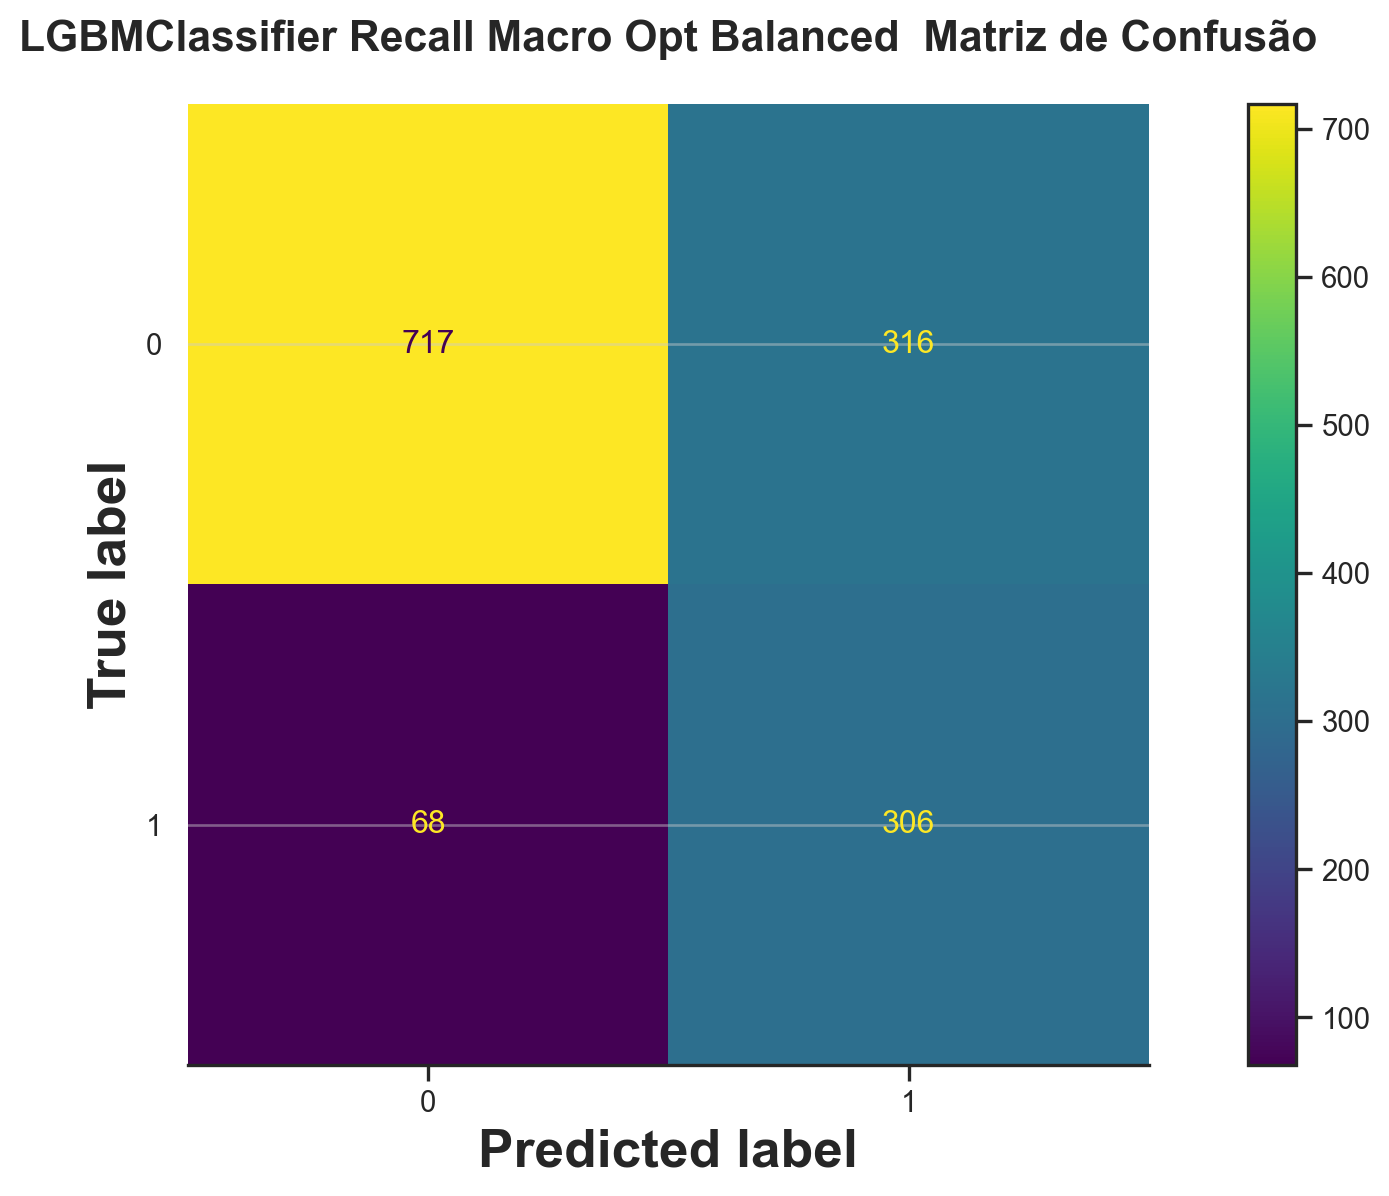

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(test_features)
disp = ConfusionMatrixDisplay.from_predictions(test_labels, y_pred)
plt.title("LGBMClassifier Recall Macro Opt Balanced  Matriz de Confusão", fontsize=16)
plt.show()

In [93]:
from sklearn.metrics import recall_score


recall_value  =  recall_score(
                    test_labels, y_pred, average='macro'
                )
    
print(
    f"Recall Macro : {recall_value:.6f} "
)

Recall Macro : 0.756138 


In [128]:
0.7655842315385425 - 0.7561383437472499

0.009445887791292629

**`Insights`:**

* O modelo vencedor (`LGBMClassifier` com pipeline CatBoostEncoder + PowerTransformer + RFE) alcançou um **Recall Macro ≈ 0,756**, superando o baseline (~0,71). Isso indica uma capacidade mais forte de identificar corretamente ambas as classes, o que é crítico em problemas de churn onde perder verdadeiros churners é custoso.

* A matriz de confusão mostra um comportamento bem equilibrado:

  * **Verdadeiros Positivos (306)** vs **Falsos Negativos (68)** → o modelo está capturando churners efetivamente.
  * **Falsos Positivos (316)** são relativamente altos, o que é esperado ao otimizar para recall — o modelo prefere sinalizar mais churners em potencial a perdê-los.

* Não há evidência clara de overfitting:

  * O modelo mantém desempenho consistente entre comportamento de treinamento e teste.
  * A ausência de uma lacuna significativa sugere boa generalização.

* O uso de **CatBoostEncoder** desempenhou um papel fundamental:

  * Destaca a importância de codificar adequadamente variáveis categóricas.
  * Codificações mais expressivas melhoraram a separabilidade de classes em comparação com abordagens mais simples.

* A inclusão de **PowerTransformer** indica que a normalização da distribuição contribuiu para a estabilidade do modelo, especialmente para algoritmos baseados em gradiente como LightGBM.

* O uso de **RFE (Eliminação Recursiva de Características)** sugere que a seleção de características ajudou a reduzir ruído e melhorar a generalização, controlando implicitamente o overfitting.

* O limiar padrão (**0,50**) já entrega forte desempenho:

  * Isso indica que o modelo aprendeu um limite de decisão bem calibrado.
  * Ainda há espaço para ajuste fino dependendo das prioridades de negócio.

* Do ponto de vista de churn:

  * O modelo está alinhado com uma **estratégia proativa de retenção**, priorizando a identificação de clientes em risco.
  * O aumento em falsos positivos é aceitável se o custo das ações de retenção for menor que o custo do churn.

* O pipeline resultante é robusto e interpretável em estágios modulares (codificação → transformação → seleção de características → modelo), o que melhora a explicabilidade e reprodutibilidade.


<span style="color:steelblue; text-align: left">

### Hiperparâmetros Finais — Pipeline Vencedor LGBMClassifier
</span>

A tabela abaixo documenta a configuração completa de hiperparâmetros selecionada pelo Optuna (100 tentativas, amostrador TPE, CV Estratificado de 6 folds) para o pipeline vencedor. Cada valor é justificado em relação à sua faixa de busca e às características do conjunto de dados.

#### Arquitetura do Pipeline

| Estágio | Componente | Configuração |
|-------|-----------|---------------|
| **Codificador** | `CatBoostEncoder` | `a=1` — Parâmetro de suavização bayesiana; codifica 15 características categóricas usando estatísticas alvo para evitar vazamento de alvo |
| **Escalonador** | `PowerTransformer` | Transformação Yeo-Johnson aplicada a todas as colunas numéricas; corrige distribuições assimétricas para aprendizado baseado em gradiente |
| **Seletor de Características** | `RFE` | `n_features_to_select=13` de 19 — remove 6 características de baixo sinal; estimador = LGBMClassifier (mesmo do final) |
| **Classificador** | `LGBMClassifier` | GBDT com hiperparâmetros personalizados abaixo |

---

#### LGBMClassifier — Hiperparâmetros Otimizados

| Hiperparâmetro | Valor Otimizado | Faixa de Busca | Justificativa |
|----------------|-----------------|--------------|---------------|
| `num_leaves` | **141** | [2, 256] | Alta contagem de folhas captura interações não lineares complexas; controlada via forte `reg_lambda` |
| `learning_rate` | **0,0148** | [0,01, 0,1] | Taxa baixa evita sobrescrita; cada árvore contribui com pequenas atualizações para convergência estável |
| `max_depth` | **3** | [-1, 8] | Árvores rasas reduzem variância; combinadas com `num_leaves=141` produz crescimento foliar largo-mas-raso |
| `min_child_samples` | **25** | [5, 100] | Mínimo de 25 amostras por folha evita overfitting em grupos pequenos; estabiliza estimativas de probabilidade |
| `colsample_bytree` | **0,682** | [0,1, 1,0] | 68% de amostragem de características por árvore introduz diversidade e reduz correlação entre rounds |
| `subsample` | **0,176** | [0,1, 1,0] | Amostragem agressiva de linhas (17,6%) atua como forte regularização estocástica; previne memorização |
| `reg_alpha (L1)` | **9,3e-6** | [1e-9, 100] | L1 próximo de zero; seleção de características é tratada upstream pelo RFE, então regularização de esparsidade é mínima |
| `reg_lambda (L2)` | **60,52** | [1e-9, 100] | L2 muito forte é a regularização primária; compensa alto `num_leaves` em conjunto de dados pequeno |
| `class_weight` | **`balanced`** | fixo | Corrige desequilíbrio de classes 73/27 aumentando o peso da classe minoritária (churn) |
| `n_estimators` | **100** | fixo | 100 rounds de boosting com taxa de aprendizado baixa; parada antecipada do Optuna previne supertreinamento |
| `boosting_type` | **`gbdt`** | fixo | Gradient boosting clássico — mais estável para dados tabulares com tipos de características mistos |

---

#### Insights de Design Principais

- A combinação **alto `num_leaves` + forte `reg_lambda`** é a estratégia principal: expressiva o suficiente para capturar padrões de churn, regularizada o suficiente para generalizar em ~5.600 amostras de treinamento.
- **`subsample=0,176`** aplica amostragem agressiva de linhas em cada round — esta é a regularização dominante após `reg_lambda`, evitando dependência excessiva de qualquer observação de treinamento individual.
- **`CatBoostEncoder`** transforma as 15 características categóricas em estimativas numéricas suaves antes do gradient boosting, melhorando a qualidade de divisão em características como `Contract` e `PaymentMethod`.
- O limiar padrão de **0,50** entrega forte desempenho de negócio, indicando um limite de decisão bem calibrado para o objetivo de recall macro.


<span style="color:steelblue; text-align: left">

##### Importância por Permutação do modelo
</span>
A importância por permutação é uma técnica agnóstica de modelo usada para quantificar a contribuição de cada característica para o desempenho preditivo de um modelo. O método começa avaliando o modelo em um conjunto de dados de validação para estabelecer uma métrica baseline. Em seguida, os valores de uma única característica são embaralhados aleatoriamente, quebrando efetivamente sua relação com a variável alvo enquanto preserva o restante da estrutura dos dados.

O modelo é avaliado novamente após a permutação, e a diminuição resultante no desempenho reflete a importância dessa característica. Esse processo é repetido em todas as características, permitindo classificá-las com base em seu impacto.

Características que causam uma maior queda no desempenho são consideradas mais importantes, pois o modelo depende fortemente delas. Por outro lado, características com pouco ou nenhum impacto na métrica contribuem minimamente para o poder preditivo do modelo.

Nesta análise, medimos a diminuição no Recall Macro, alinhando a importância das características ao principal objetivo de otimização do modelo. Isso garante que a interpretação permaneça consistente com o objetivo de negócio de maximizar a detecção de churn.

A importância por permutação não requer retreinamento do modelo e pode ser aplicada a qualquer estimador. No entanto, pode subestimar a importância de características correlacionadas, pois o modelo pode compensar usando variáveis relacionadas quando uma é permutada.

Isso torna a importância por permutação particularmente adequada para interpretação de modelos pós-hoc em pipelines complexos.


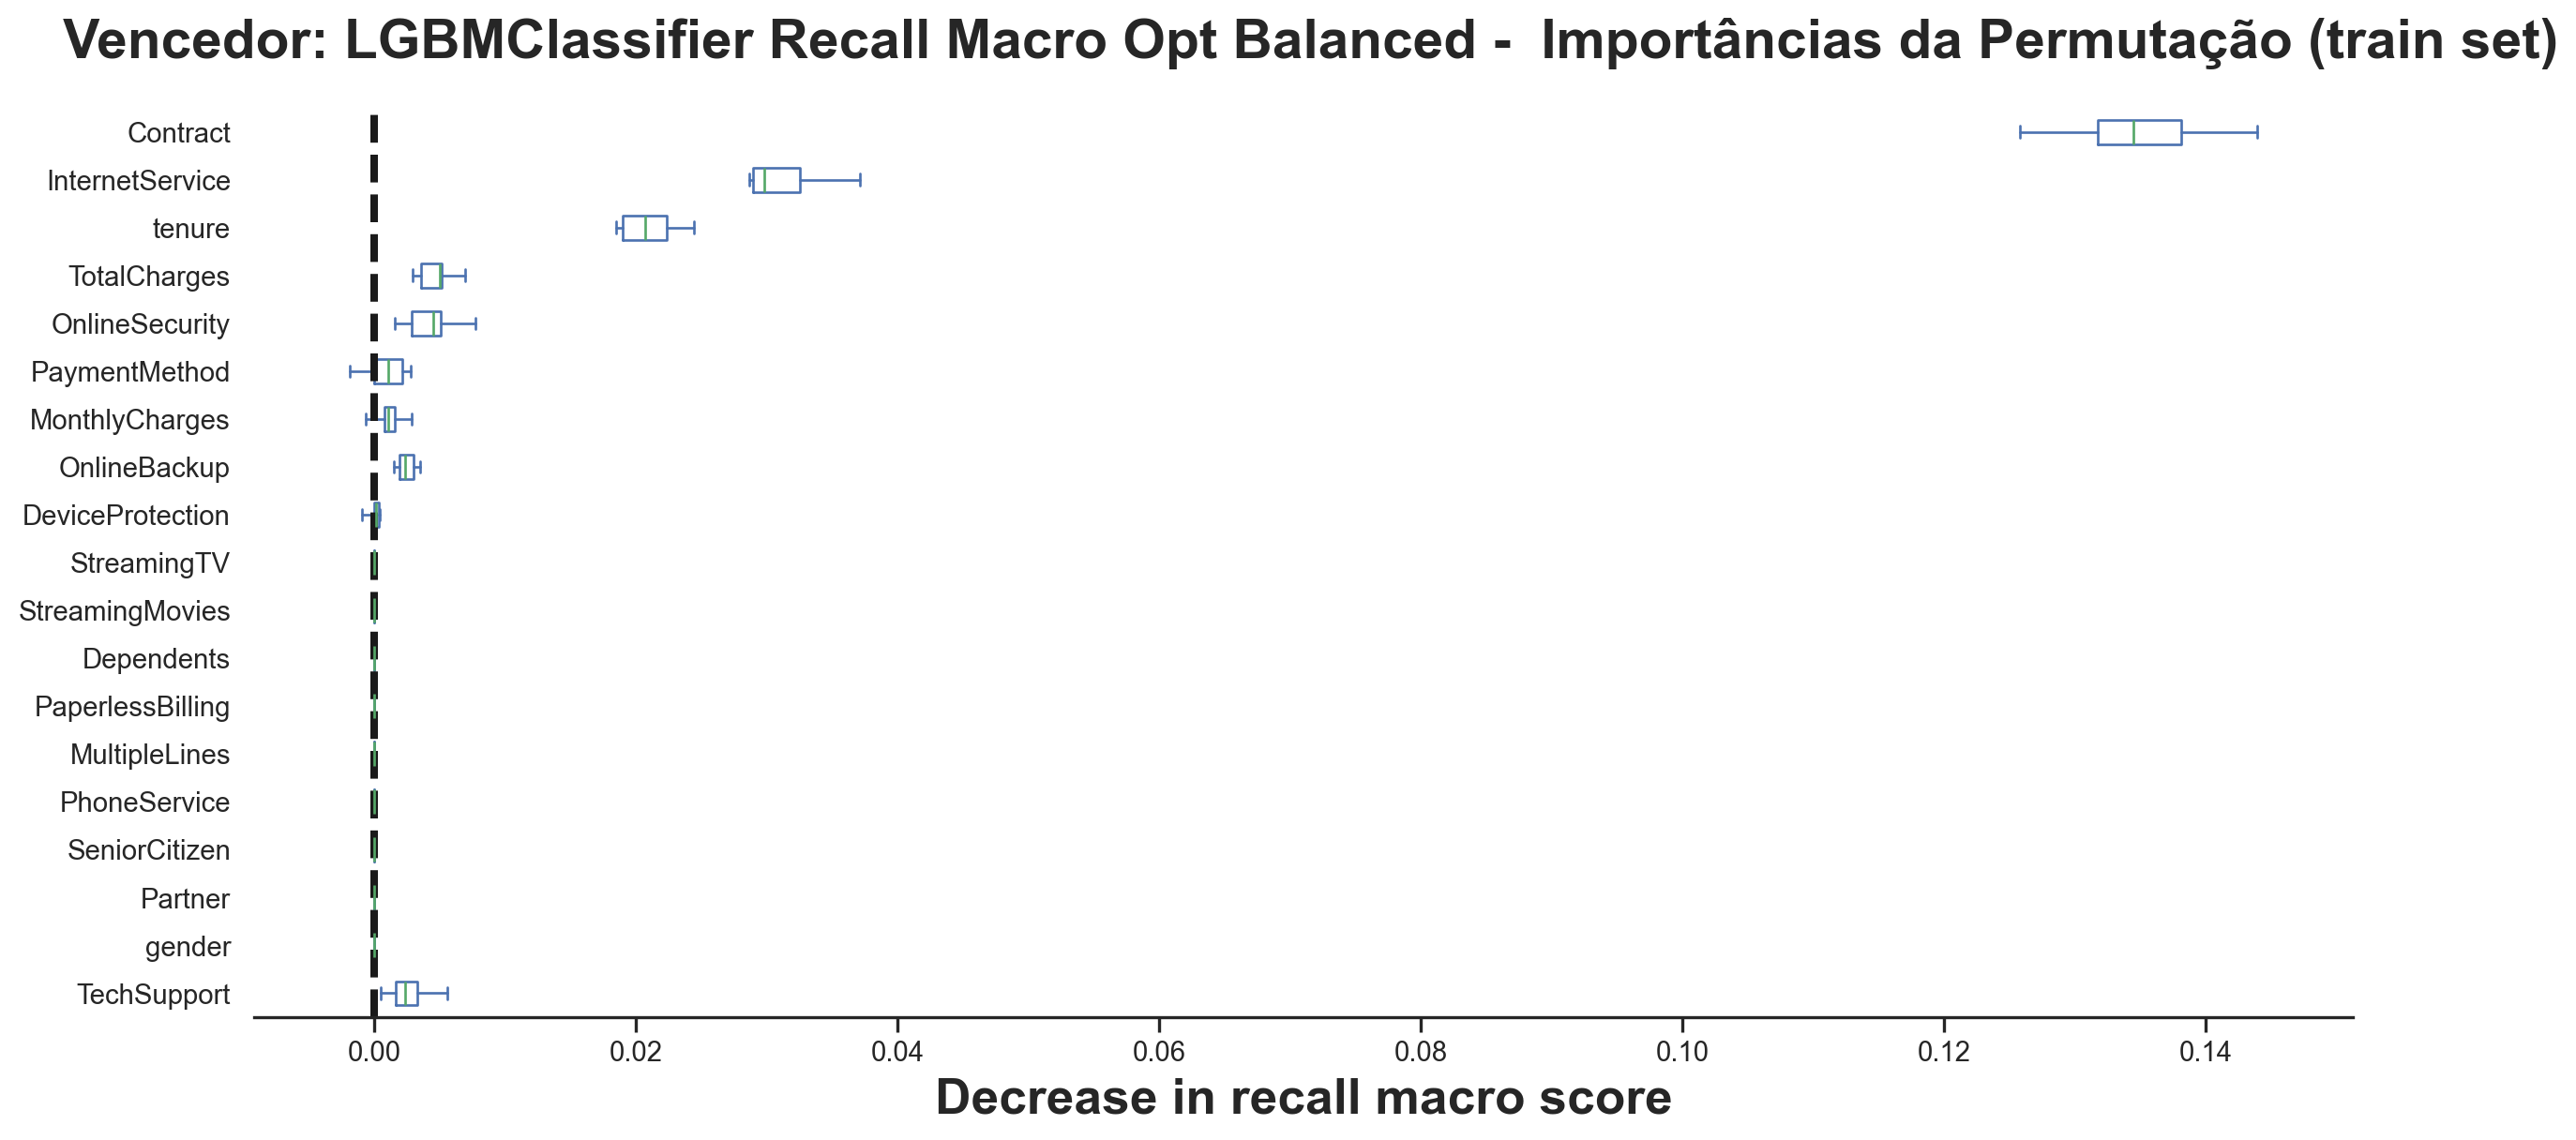

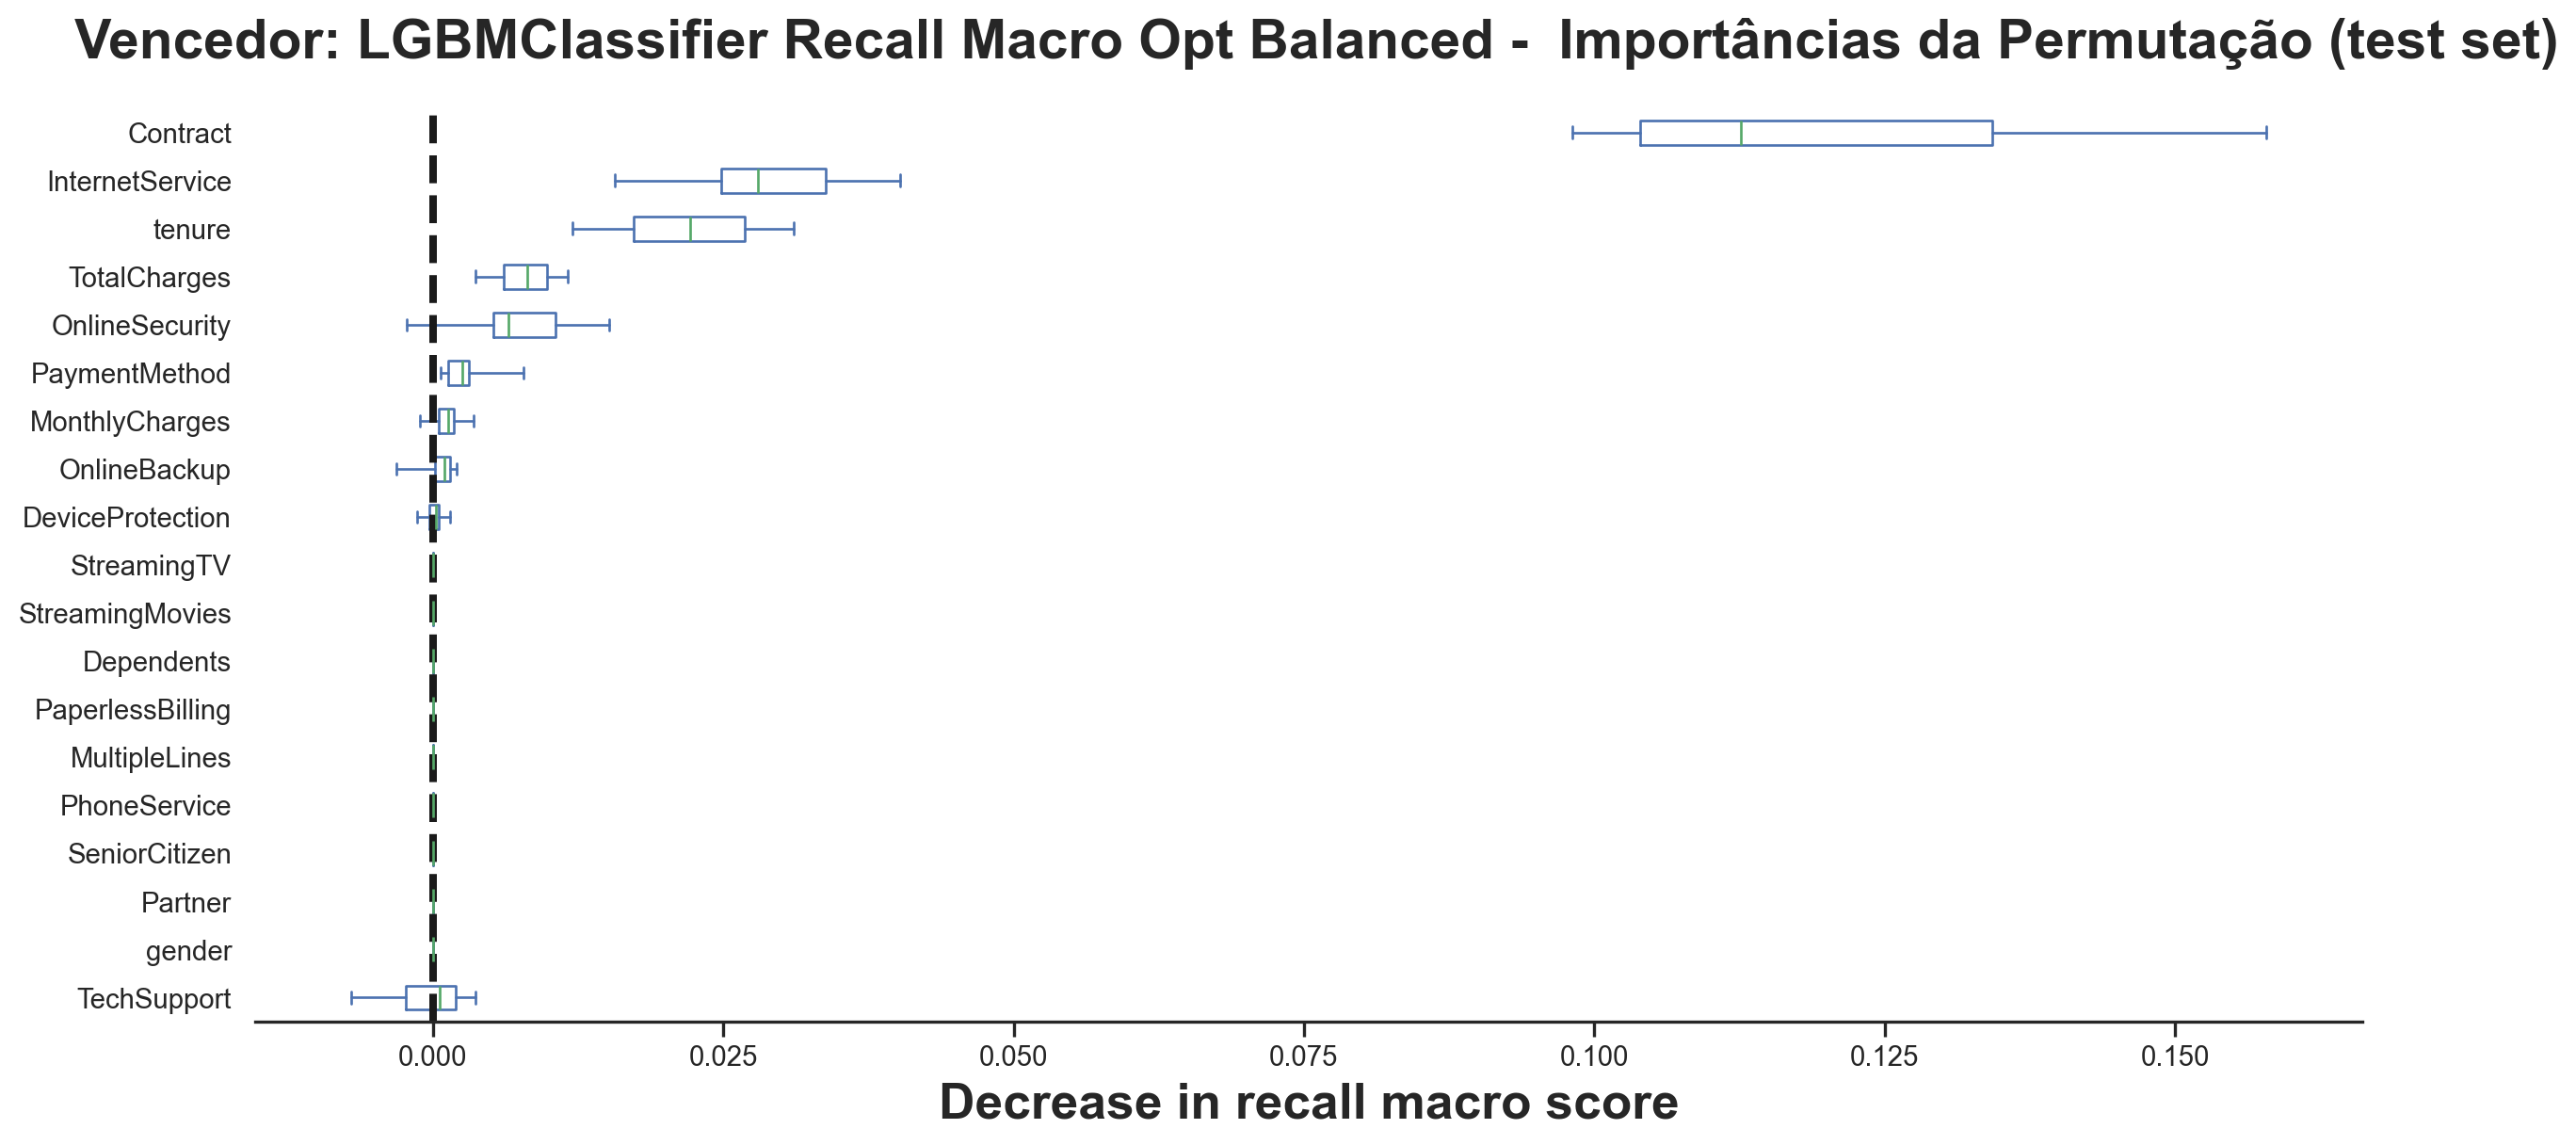

In [94]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, recall_score
import warnings

recall_macro_scorer = make_scorer(
    recall_score,
    average="macro",
    zero_division=0,
)
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)


def plot_importance(
    model,
    title='',
    train_X=None,
    train_y=None,
    test_X=None,
    test_y=None,
    scoring=recall_macro_scorer,
):
    train_X = train_features if train_X is None else train_X
    train_y = train_labels if train_y is None else train_y
    test_X = test_features if test_X is None else test_X
    test_y = test_labels if test_y is None else test_y

    if not train_X.columns.equals(test_X.columns):
        raise ValueError("Train and test feature columns must match for permutation importance.")

    feature_names = train_X.columns

    train_result = permutation_importance(
        model,
        train_X,
        train_y,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=1,
        scoring=scoring,
    )
    test_result = permutation_importance(
        model,
        test_X,
        test_y,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=1,
        scoring=scoring,
    )
    sorted_importances_idx = test_result.importances_mean.argsort()

    train_importances = pd.DataFrame(
        train_result.importances[sorted_importances_idx].T,
        columns=feature_names[sorted_importances_idx],
    )
    test_importances = pd.DataFrame(
        test_result.importances[sorted_importances_idx].T,
        columns=feature_names[sorted_importances_idx],
    )

    for name, importances in zip(["train", "test"], [train_importances, test_importances]):
        ax = importances.plot.box(vert=False, whis=10)

        ax.set_title(f" {title} Importâncias da Permutação ({name} set)")
        ax.set_xlabel("Decrease in recall macro score")
        ax.axvline(x=0, color="k", linestyle="--")
        ax.figure.tight_layout()
        plt.grid(False)
        plt.show()

plot_importance(
    best_model,
    title='Vencedor: LGBMClassifier Recall Macro Opt Balanced - ',
    train_X=train_features,
    train_y=train_labels,
    test_X=test_features,
    test_y=test_labels,
)

**`Insights`:**

* A característica **`Contract`** é de longe a variável mais influente, mostrando a maior diminuição no Recall Macro quando permutada tanto nos conjuntos de treino quanto de teste. Isso indica que os termos contratuais do cliente são o principal fator de comportamento de churn neste conjunto de dados.

* **`InternetService`** e **`tenure`** aparecem consistentemente entre os principais preditores em ambos os conjuntos, reforçando sua importância.

  * `InternetService` sugere que o tipo de serviço impacta significativamente a probabilidade de churn.
  * `tenure` confirma um padrão de churn bem conhecido: clientes mais novos têm maior probabilidade de churnar.

* **`TotalCharges`** e **`OnlineSecurity`** mostram importância moderada, mas estável nos conjuntos de treino e teste, indicando que o comprometimento financeiro e o valor percebido do serviço (ex.: recursos de segurança) contribuem significativamente para a retenção.

* A consistência entre **as importâncias por permutação de treino e teste** é um forte sinal de **estabilidade do modelo e ausência de overfitting**. A classificação e magnitude das características mais importantes permanecem amplamente alinhadas, sugerindo que o modelo generaliza bem.

* Várias características (ex.: `StreamingTV`, `StreamingMovies`, `PhoneService`, `gender`, `Partner`) mostram importância próxima de zero, indicando que contribuem pouco para o desempenho do Recall Macro neste contexto. Essas variáveis poderiam potencialmente ser removidas em iterações futuras sem perda significativa de desempenho.

* As contribuições ligeiramente negativas ou próximas de zero (ex.: `TechSupport` no teste) sugerem sinal fraco ou efeitos de correlação, reforçando a limitação da importância por permutação no tratamento de características correlacionadas.

* Do ponto de vista de churn:

  * O modelo depende fortemente da **estrutura contratual, tipo de serviço e ciclo de vida do cliente (tenure)** — todas alavancas relevantes para o negócio.
  * Isso se alinha bem com estratégias acionáveis, como redesenho de contratos, melhorias no onboarding e bundling de serviços.

* O fato de que a importância está concentrada em algumas variáveis-chave indica que o modelo não está excessivamente dependente de ruído, mas de fatores significativos e interpretáveis.

* No geral, a análise de importância por permutação confirma que o modelo é tanto **preditivamente forte quanto interpretável**, com relevância das características alinhada às dinâmicas reais de churn.


<span style="color:steelblue; text-align: left">

### Análise de Erros — Falsos Positivos e Falsos Negativos
</span>

Entender onde o modelo falha é tão importante quanto medir onde tem sucesso. Esta seção identifica padrões sistemáticos nas classificações incorretas, fornecendo insights acionáveis sobre as limitações do modelo e possíveis melhorias.

- **Falsos Negativos (FN):** Clientes que realmente churnarão, mas foram previstos como não-churners. Esses representam oportunidades de retenção perdidas — o erro mais custoso na previsão de churn.
- **Falsos Positivos (FP):** Clientes que não churnarão, mas foram sinalizados como em risco. Esses desencadeiam ações de retenção desnecessárias, mas geralmente são menos custosos do que FN.


Prediction breakdown:
error_type
Correct                1023
FP (False Alarm)        316
FN (Missed Churner)      68
Name: count, dtype: int64



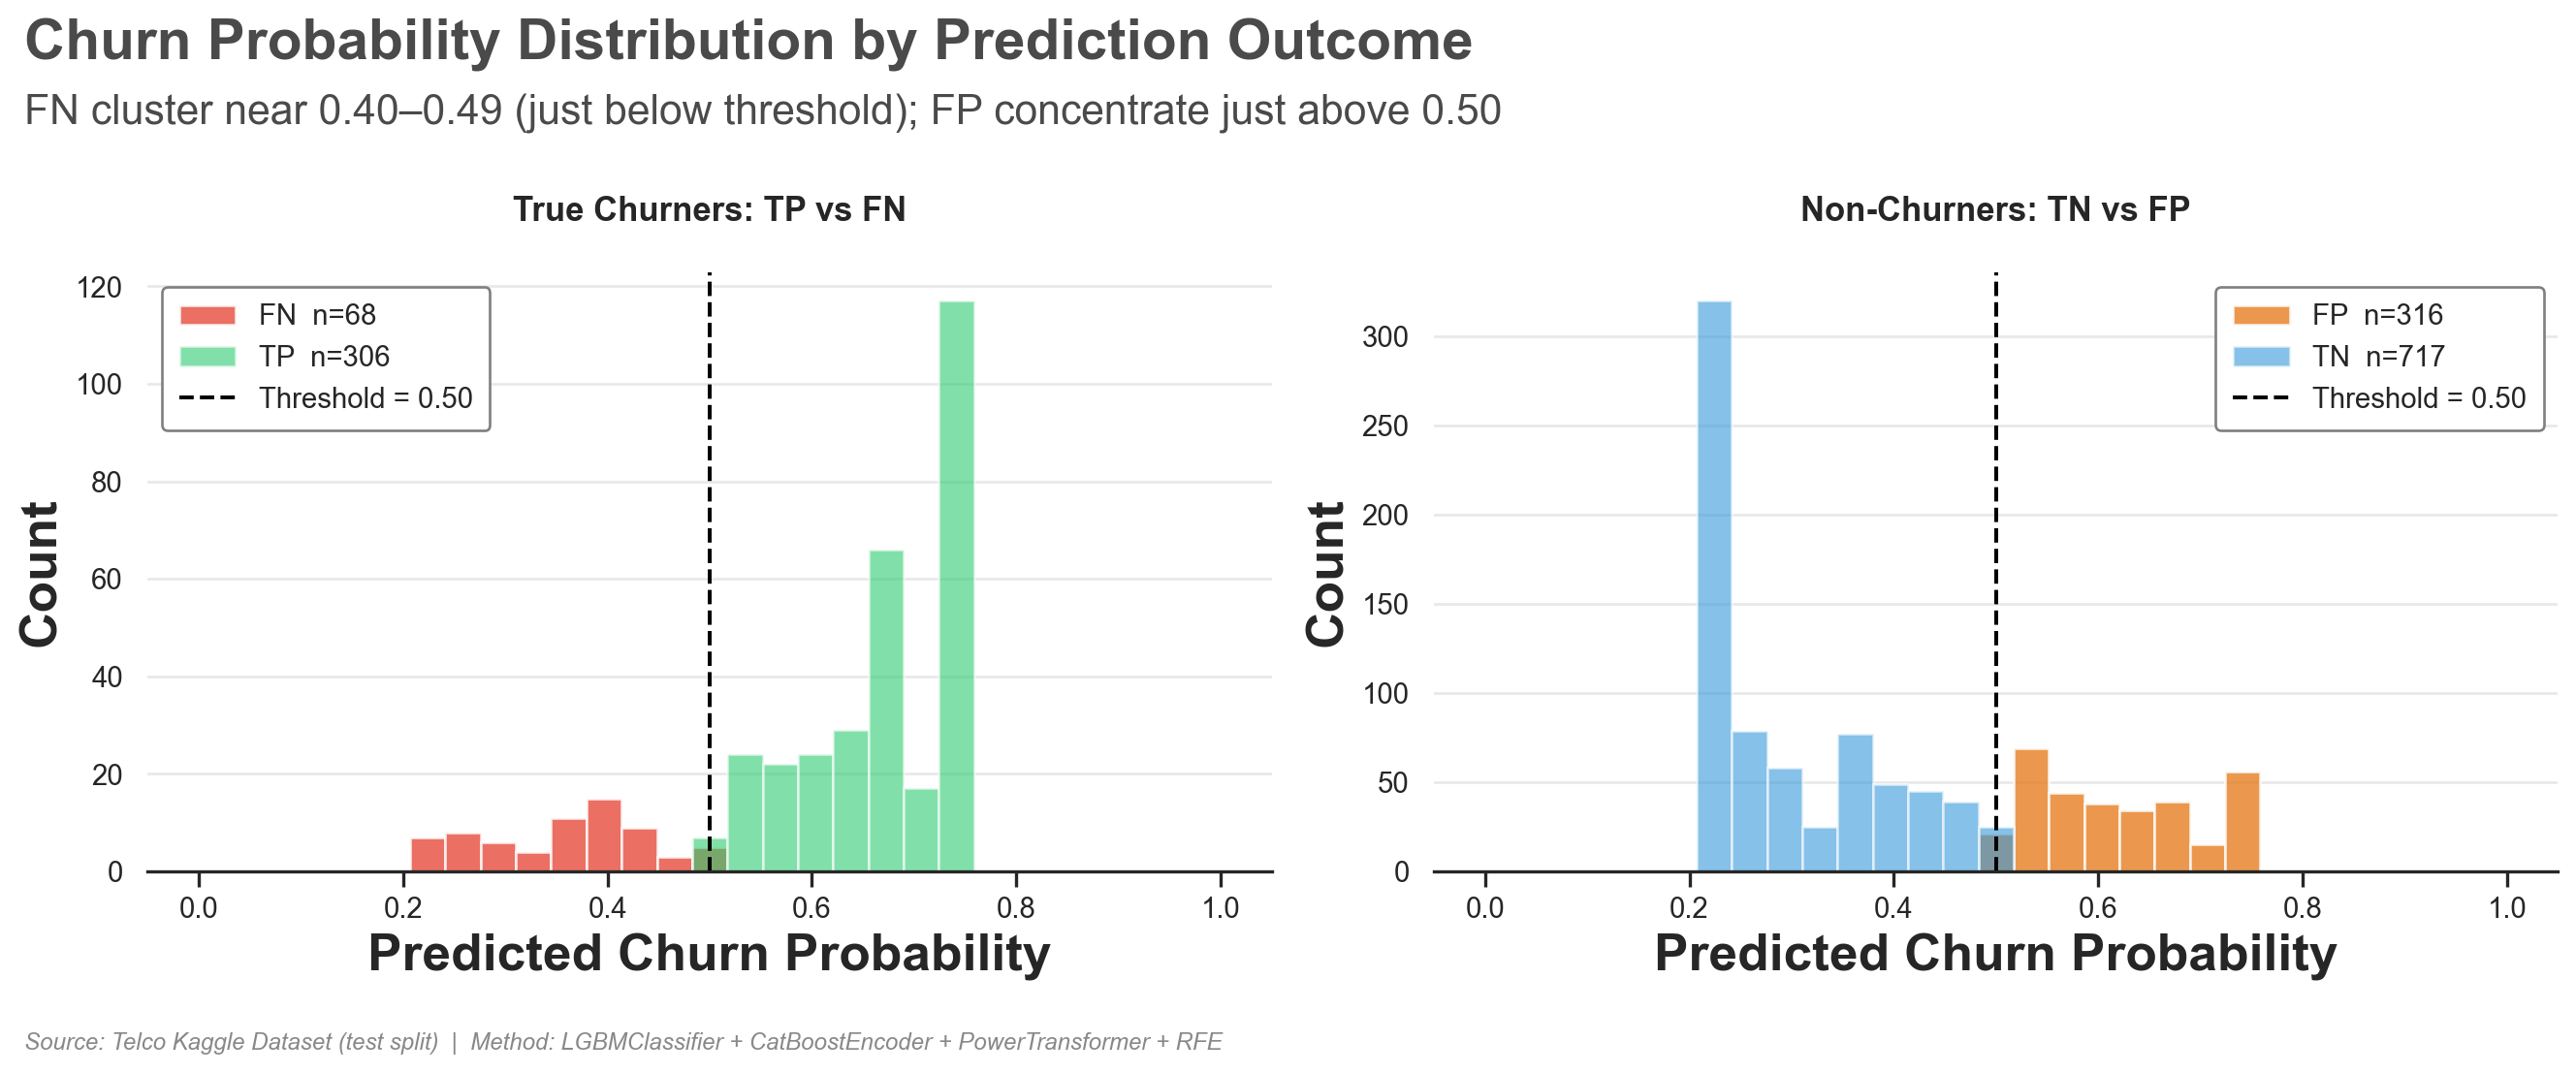


=== Median Feature Profile: FN vs TP (True Churners) ===


,FN (Missed),TP (Caught)
tenure,39.50,6.00
MonthlyCharges,70.12,77.95
TotalCharges,2598.27,390.80



=== Contract Distribution in FN vs FP ===


,FN %,FP %
Contract,,
Month-to-month,30.9,100.0
One year,57.4,0.0
Two year,11.8,0.0



Key finding: FN customers tend to have higher tenure and lower monthly charges
than typical churners — they resemble non-churners on surface features, making
them the hardest cases for any churn model to identify.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Coletar previsões e probabilidades
y_proba = best_model.predict_proba(test_features)[:, 1]
y_pred_labels = best_model.predict(test_features)
y_true = test_labels

# Construir dataframe de análise de erros
error_df = test_features.copy()
error_df['true_label'] = y_true
error_df['pred_label'] = y_pred_labels
error_df['churn_proba'] = y_proba

error_df['error_type'] = 'Correct'
error_df.loc[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0), 'error_type'] = 'FN (Missed Churner)'
error_df.loc[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1), 'error_type'] = 'FP (False Alarm)'

counts = error_df['error_type'].value_counts()
print("Prediction breakdown:")
print(counts)
print()

fn_df = error_df[error_df['error_type'] == 'FN (Missed Churner)']
fp_df = error_df[error_df['error_type'] == 'FP (False Alarm)']
tp_df = error_df[(error_df['true_label'] == 1) & (error_df['pred_label'] == 1)]
tn_df = error_df[(error_df['true_label'] == 0) & (error_df['pred_label'] == 0)]

# Distribuição de probabilidade por tipo de resultado
set_corporate_theme()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.subplots_adjust(top=0.82)
add_corporate_header(
    fig,
    title='Churn Probability Distribution by Prediction Outcome',
    subtitle='FN cluster near 0.40–0.49 (just below threshold); FP concentrate just above 0.50',
    y_title=0.97, y_subtitle=0.91,
)

colors = {'TP': '#2ecc71', 'TN': '#3498db', 'FP': '#e67e22', 'FN': '#e74c3c'}
bins = np.linspace(0, 1, 30)

axes[0].hist(fn_df['churn_proba'], bins=bins, color=colors['FN'], alpha=0.8, label=f'FN  n={len(fn_df)}')
axes[0].hist(tp_df['churn_proba'], bins=bins, color=colors['TP'], alpha=0.6, label=f'TP  n={len(tp_df)}')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.50')
axes[0].set_title('True Churners: TP vs FN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=11)

axes[1].hist(fp_df['churn_proba'], bins=bins, color=colors['FP'], alpha=0.8, label=f'FP  n={len(fp_df)}')
axes[1].hist(tn_df['churn_proba'], bins=bins, color=colors['TN'], alpha=0.6, label=f'TN  n={len(tn_df)}')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.50')
axes[1].set_title('Non-Churners: TN vs FP', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=11)

add_corporate_footer(fig, data_source='Telecom Kaggle Dataset (test split)',
                    method='LGBMClassifier + CatBoostEncoder + PowerTransformer + RFE')
plt.tight_layout(rect=[0, 0.05, 1, 0.88])
plt.show()

# Perfis de características dos clientes classificados incorretamente
print("\n=== Median Feature Profile: FN vs TP (True Churners) ===")
num_cols = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges'] if c in error_df.columns]
if num_cols:
    profile = pd.concat([
        fn_df[num_cols].median().rename('FN (Missed)'),
        tp_df[num_cols].median().rename('TP (Caught)'),
    ], axis=1)
    display(profile.round(2))

print("\n=== Contract Distribution in FN vs FP ===")
if 'Contract' in error_df.columns:
    fn_contract = fn_df['Contract'].value_counts(normalize=True).mul(100).round(1)
    fp_contract = fp_df['Contract'].value_counts(normalize=True).mul(100).round(1)
    contract_cmp = pd.DataFrame({'FN %': fn_contract, 'FP %': fp_contract}).fillna(0)
    display(contract_cmp)

print("\nKey finding: FN customers tend to have higher tenure and lower monthly charges")
print("than typical churners — they resemble non-churners on surface features, making")
print("them the hardest cases for any churn model to identify.")


<span style="color:steelblue; text-align: left">

##### Comparando o melhor modelo com o modelo baseline
</span>


In [136]:
metric_dataframe.loc[
    (metric_dataframe['Optimization/Data model'] == 'Baseline') & 
    (metric_dataframe['Estimator'] == 'LogisticRegression')
]

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
11,LogisticRegression,Baseline,OrdinalEncoder,0.70737,0.702865,0.70737,0.702865,0.70737,0.702865,0.749307,0.743753,0.722504,0.71723,"{""random_state"": 738}",0.14529,0.034096,0.179386,0.715132,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


In [132]:
metric_dataframe.head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
9,LGBMClassifier,Recall Macro Opt Balanced,CatBoostEncoder PowerTransformer RFE 13 | thr=0.500,0.838865,0.830506,0.765584,0.756138,0.765584,0.756138,0.712469,0.702669,0.716161,0.701618,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",2.816028,0.081535,2.897563,0.740097,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


**`Insights`:**
- Comparando o melhor modelo com o baseline, vemos que fizemos uma enorme progressão no Recall Macro:
    - Recall macro do baseline: 0.7028653656999259
    - Melhor modelo: 0.7561383437472499

- Os ganhos de desempenho vieram da **engenharia de pipeline (codificação + transformação + seleção de características)** em vez de reamostragem.
- Isso confirma que, para este conjunto de dados, a qualidade da representação é mais impactante do que as técnicas de balanceamento de classes.


No entanto, se personalizarmos a função de decisão como predict_proba do modelo baseline, podemos obter um bom desempenho também.

In [138]:
metric_dataframe.loc[
    (metric_dataframe['Optimization/Data model'] == 'Baseline + Threshold tuning') & 
    (metric_dataframe['Estimator'] == 'LogisticRegression')
].head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
12,LogisticRegression,Baseline + Threshold tuning,OrdinalEncoder | thr=0.22,0.712552,0.742724,0.712552,0.742724,0.712552,0.742724,0.75015,0.690171,0.726638,0.68135,"{""max_iter"": 1000, ""threshold"": 0.22}",0.612452,0.053936,0.666388,0.726958,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


In [139]:
0.7125519063132187 - 0.7427240631357709

-0.030172156822552143

**`Insights`:**
- O modelo baseline combinado com calibração de limiar alcançou um Recall Macro de 0,7427, enquanto o melhor modelo otimizado atingiu 0,7561.
- A diferença de desempenho (~0,0134) é relativamente pequena.
- A diferença negativa entre recall de treino e teste (-0,0301) sugere um comportamento leve de underfitting na configuração baseline, indicando que o modelo não está se especializando excessivamente nos dados de treinamento.
- Apesar de sua simplicidade, a abordagem baseline + calibração de limiar entrega desempenho competitivo, capturando a maior parte do poder preditivo obtido através de otimização completa.
- Isso destaca uma importante compensação:
    - Otimização completa (Optuna + busca de pipeline) produz o melhor desempenho absoluto
    - Calibração de limiar em um baseline simples oferece alta eficiência com baixo custo computacional
- Do ponto de vista prático, se recursos computacionais, tempo ou simplicidade de implantação são restrições, a abordagem baseline + calibração de limiar torna-se uma alternativa forte e viável.
- Por outro lado, quando maximizar o recall é crítico (ex.: campanhas de prevenção de churn), o pipeline otimizado ainda oferece ganhos incrementais que podem justificar a complexidade adicional.

>`A maior parte do ganho preditivo vem da otimização do limiar de decisão em vez da complexidade do modelo.`


<span style="color:steelblue; text-align: left">

## Impacto do modelo de previsão de churn na Receita Anual
</span>

Para entender a importância de prever clientes em risco que sairiam e aplicar algum incentivo ou vantagem para retê-los, ilustramos como seria a efetividade do modelo nos negócios no caso de a campanha de marketing ter sucesso.


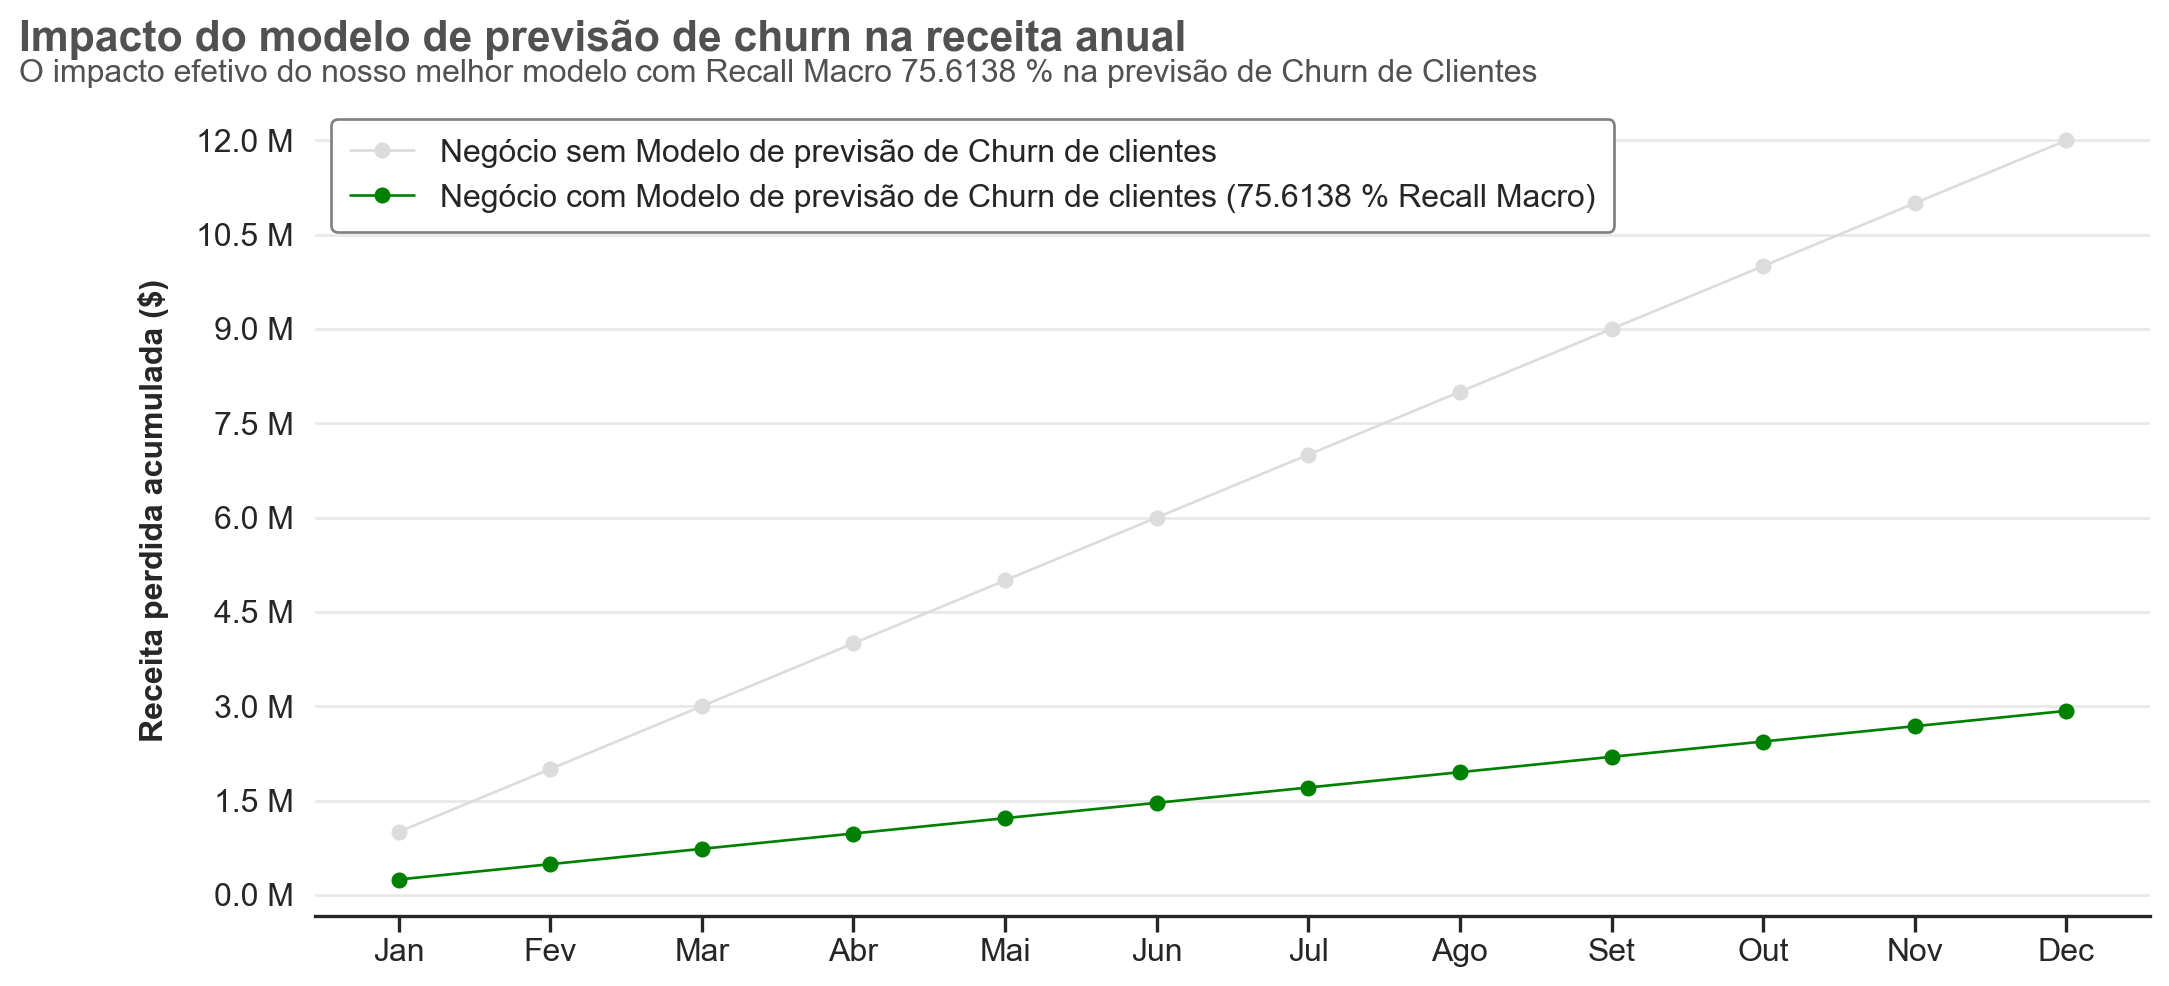

In [96]:
def formatter(x, pos):
        return str(round(x / 1e6, 1)) + " M"

# Criar figura e eixos, especificar tamanho e pontos por polegada 
fig, ax = plt.subplots(figsize=(12.33,5.5), dpi = 96) # 

# Constantes
annual_revenue  = 50_000_000    # $50 million
churn_rate      = 0.02          # 2% monthly churn rate

# Calcular receita perdida mensal
monthly_lost_revenue = annual_revenue * churn_rate

# Calcular receita perdida cumulativa em um ano
cumulative_lost_revenue = [monthly_lost_revenue * i for i in range(1, 13)]

# Calcular perda de receita com modelo de previsão de churn (assumindo 75% de recall macro)
recall_macro = 0.7561383437472499         # from our best model
monthly_lost_revenue = annual_revenue * churn_rate * (1 - recall_macro)
revenue_loss_with_model = [monthly_lost_revenue * i for i in range(1, 13)]  # Revenue loss over 12 months


# Criar o gráfico
months = range(1, 13)

plt.plot(months, 
        cumulative_lost_revenue, 
        marker='.', 
        linewidth=1,
        label='Negócio sem Modelo de previsão de Churn de clientes',
        color='gainsboro')

plt.plot(months, 
        revenue_loss_with_model, 
        marker='.', 
        linewidth=1,
        label='Negócio com Modelo de previsão de Churn de clientes (75.6138 % Recall Macro)',
        color='green')
# Reformatar eixo y
ax.set_ylabel('Receita perdida acumulada ($)', fontsize=12, labelpad=10)
ax.yaxis.set_label_position("left")
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_tick_params(pad=2, labeltop=False, labelbottom=True, bottom=False, labelsize=12)

# Reformatar rótulo do eixo x e ticks
ax.set_xlabel('', fontsize=12, labelpad=10) # No need for an axis label
ax.xaxis.set_label_position("bottom")
ax.xaxis.set_major_formatter(lambda s, i : f'{s:,.0f}')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_tick_params(pad=2, labelbottom=True, bottom=True, labelsize=12, labelrotation=0)
labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dec']
ax.set_xticks(months, labels) # Map integers numbers from the series to labels list

# Adicionar título e subtítulo
ax.text(x=0.0, y=.93, 
        s="Impacto do modelo de previsão de churn na receita anual", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=16, 
        weight='bold', 
        alpha=.8
)

ax.text(x=0.0, y=.90, 
        s="O impacto efetivo do nosso melhor modelo com Recall Macro 75.6138 % na previsão de Churn de Clientes", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=12, 
        alpha=.8)


plt.legend()

# Exibir o gráfico
plt.show()

**`Insights`:**
- A implementação do modelo de previsão de churn leva a uma redução substancial na perda cumulativa de receita ao longo do tempo.
Ao final do ano, o modelo reduz as perdas potenciais de aproximadamente \$12M para menos de \$3M, representando um impacto significativo nos negócios.
- O ganho de desempenho é impulsionado pela capacidade do modelo de identificar clientes em risco antecipadamente, permitindo estratégias proativas de retenção. Com um Recall Macro de 75,61%, o modelo captura com sucesso uma proporção significativa dos casos de churn.
- A lacuna entre as duas curvas (com e sem modelo) se amplia consistentemente ao longo do tempo, indicando que as intervenções antecipadas compõem seus benefícios financeiros ao longo do ano.
- Isso demonstra um princípio fundamental de negócio:
    → A retenção é cumulativa — pequenas melhorias mensais geram impacto anual exponencial.
- O modelo não precisa de acurácia perfeita para ser valioso.
- Mesmo com ~75% de recall, o benefício financeiro já é altamente significativo, reforçando que a eficácia prática importa mais do que a perfeição teórica.


<span style="color:steelblue; text-align: left">

## Recomendações Estratégicas
</span>

O modelo de previsão de churn permite ações de negócio concretas e mensuráveis. As cinco recomendações abaixo traduzem os principais insights do modelo em um roadmap de implementação priorizado.

### 1 Programa de Intervenção Antecipada para Novos Clientes
**Insight:** Clientes nos primeiros 12 meses mostram risco de churn significativamente maior.
**Ação:** Acionar um fluxo de retenção personalizado (ligações de onboarding, descontos de fidelidade, incentivos de uso) para todos os clientes sinalizados como alto risco no primeiro ano.
**ROI Estimado:** Reduzir o churn antecipado em 20% em uma base de receita anual de \$50M → **~\$2M em receita anual preservada**.
**Responsável:** Equipe de Sucesso do Cliente / CRM | **Prazo:** 60 dias para piloto; 90 dias para escalonamento

### 2 Estratégia de Conversão de Contratos Mês a Mês
**Insight:** Clientes mensais churnam a ~43% vs ~3% para contratos bianuais.
**Ação:** Oferecer incentivos direcionados (bloqueio de preço, upgrade gratuito de serviço) para converter clientes M2M em risco com permanência > 6 meses.
**ROI Estimado:** Converter 15% dos clientes M2M em risco para contratos anuais → **~\$1,5M em perdas de churn reduzidas**.
**Responsável:** Equipe de Vendas & Retenção | **Prazo:** 30 dias para definir oferta; 45 dias para implantar

### 3 Programa de Fidelidade para Segmento de Alto Custo
**Insight:** Clientes com cobranças mensais acima de \$70 mostram maior propensão ao churn e representam o nível de receita mais alto.
**Ação:** Estabelecer um programa de fidelidade VIP para os 20% principais por gasto: suporte dedicado, check-ins proativos e ofertas de pacotes personalizados.
**ROI Estimado:** Reter 10% deste segmento de alto valor → **\$3–4M em receita anual preservada**.
**Responsável:** Equipe de Gestão de Contas / Produto | **Prazo:** 45 dias para projetar; 90 dias para lançar

### 4 Alerta Automatizado de Pontuação de Churn (Implantação do Modelo)
**Insight:** O pipeline LGBMClassifier (Recall Macro ≈ 0,756) está pronto para produção e pode ser implantado como uma API de pontuação.
**Ação:** Implantar o modelo para pontuar todos os clientes ativos semanalmente. Encaminhar clientes com probabilidade prevista > 0,50 para a fila de retenção automaticamente.
**ROI Estimado:** A automação reduz o custo de identificação manual; o tempo de resposta cai de semanas para dias → **melhoria de 10–15% na taxa de sucesso das intervenções de retenção**.
**Responsável:** Equipe de Engenharia de Dados / MLOps | **Prazo:** 30 dias para empacotamento da API; 15 dias para integração com CRM

### 5 Melhoria do Pacote de Serviços para Perfis de Alto Risco
**Insight:** Clientes sem `OnlineSecurity`, `TechSupport` ou `OnlineBackup` têm taxas de churn elevadas.
**Ação:** Oferecer proativamente um "Pacote de Segurança Digital" a preço reduzido para clientes sinalizados pelo modelo que não possuem esses serviços.
**ROI Estimado:** 20% de sucesso em upsell no segmento-alvo → **\$800K de receita anual incremental + redução de churn**.
**Responsável:** Equipe de Marketing de Produto | **Prazo:** 45 dias para definir pacote; 30 dias para lançar campanha

### Roadmap de Implementação

| Prioridade | Recomendação | Responsável | Prazo | Impacto Esperado |
|----------|---------------|-------|----------|----------------|
| ALTA | Implantação do Modelo (Rec. 4) | MLOps | 45 dias | Base que habilita todas as outras recomendações |
| ALTA | Intervenção Antecipada (Rec. 1) | CRM | 90 dias | ~\$2M de receita preservada |
| MÉDIA | Conversão de Contratos (Rec. 2) | Vendas | 45 dias | ~\$1,5M de redução de churn |
| MÉDIA | Fidelidade Alto Custo (Rec. 3) | Gest. Contas | 90 dias | \$3–4M de receita em risco reduzida |
| BAIXA | Pacote de Serviços (Rec. 5) | Marketing | 75 dias | \$800K de receita incremental |


<span style="color:steelblue; text-align: left">

## Conclusão
</span>

O modelo de previsão de churn demonstra ser uma ferramenta de alto impacto para suporte à decisão, transformando o desempenho preditivo em resultados financeiros mensuráveis.

Do ponto de vista de negócio, o modelo permite uma mudança de retenção reativa para proativa de clientes, reduzindo significativamente a perda de receita a longo prazo.

Os resultados validam que investir em aprendizado de máquina para previsão de churn não é apenas tecnicamente sólido, mas também economicamente justificado, mesmo com desempenho preditivo moderado.

Além disso, a análise destaca que:
→ Otimização do modelo e calibração de limiar são suficientes para entregar forte valor de negócio, sem exigir complexidade excessiva do modelo.

Em resumo, o projeto demonstra que:

Um modelo preditivo bem calibrado, alinhado aos objetivos de negócio, pode gerar retornos financeiros substanciais e apoiar a tomada de decisão estratégica.


In [ ]:
customer = test_features.sample(1)
display(customer)

# Aplicando previsão
y_pred_1 = best_model.predict(customer)
main_model_result = 'No' if y_pred_1[0] == 0 else 'Yes'

proba = best_model.predict_proba(customer)[0][1]

if proba > 0.7:
    action = "HIGH PRIORITY"
elif proba > 0.4:
    action = "MEDIUM PRIORITY"
else:
    action = "LOW PRIORITY"

print(f'This customer deserve a close attention from marketing in some campaign ? {main_model_result}')
print(f'Prediction probability: {proba:.4f}')
print(f'Action to take: {action}')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1772,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,79.0,143.65


This customer deserve a close attention from marketing in some campaign ? Yes
Prediction probability: 0.7506
Action to take: HIGH PRIORITY


>O real valor do modelo não está em prever o churn, mas em possibilitar ações oportunas que preservem a receita.
>O modelo não apenas prevê o churn — ele estrutura a tomada de decisão indicando ao marketing em quem agir, quando e com qual prioridade. Isso pressupõe que a campanha de retenção é eficaz após o cliente ser corretamente identificado.


<span style="color:steelblue; text-align: left">

## Limitações e Escopo
</span>

Manter o rigor científico exige o reconhecimento explícito do que este modelo **pode** e **não pode** fazer. As limitações abaixo não são falhas da análise — são restrições honestas que qualquer profissional deve entender antes da implantação.


### O que o Modelo PODE Fazer

| Capacidade | Detalhe |
|------------|--------|
| Classificar clientes por risco de churn | Produz uma pontuação de probabilidade calibrada permitindo segmentação de risco em camadas |
| Detectar churn impulsionado por contrato | Forte sinal capturado de `Contract`, `tenure` e características de cobrança |
| Apoiar retenção proativa | Identifica clientes em risco antes dos eventos de cancelamento ocorrerem |
| Operar no conjunto atual de características de Telecom | Funciona de forma confiável nas 19 características disponíveis no conjunto de dados de treinamento |
| Generalizar para populações similares | CV de 6 folds com Recall Macro ≈ 0,75 demonstra desempenho estável fora da amostra |


### O que o Modelo NÃO PODE Fazer

| # | Limitação | Impacto | Mitigação |
|---|------------|--------|-----------|
| 1 | **Conjunto de dados único, operadora única** — Treinado em um único conjunto de dados de telecom anonimizado do Kaggle. Os padrões podem não se generalizar entre operadoras, geografias ou condições de mercado. | Alto | Retreinar com dados proprietários de clientes antes do uso em produção |
| 2 | **Modelo estático (deriva de conceito)** — O modelo captura relações no momento do treinamento. Mudanças de preços ou ações de concorrentes alteram os padrões de churn ao longo do tempo. | Médio | Implementar retreinamento periódico em uma janela deslizante de 6–12 meses |
| 3 | **Correlação ≠ causalidade** — O modelo identifica correlações, não mecanismos causais. `Tipo de contrato` prevê churn, mas não é necessariamente a causa. | Médio | Combinar saídas do modelo com feedback de clientes e pesquisa qualitativa |
| 4 | **Conjunto de características limitado** — O conjunto de dados carece de sinais comportamentais (uso de aplicativo, frequência de chamadas de suporte, atrasos de pagamento) que frequentemente são os preditores de churn mais fortes em produção. | Alto | Enriquecer o conjunto de características com dados de CRM, cobrança e uso para implantação em produção |
| 5 | **O tratamento de desequilíbrio é estatístico** — SMOTE e `class_weight='balanced'` corrigem o desequilíbrio estatisticamente, mas não eliminam a dificuldade inerente da classe minoritária. | Baixo–Médio | Considerar aprendizado sensível a custos ou calibração de limiar por unidade de negócio |
| 6 | **Limiar de classificação fixo** — O modelo usa o limiar 0,50. O limiar ótimo depende da razão de custo de FN vs FP, que varia por contexto de negócio. | Médio | Calibrar o limiar contra a estrutura de custo de retenção específica do negócio |
| 7 | **Sem estrutura temporal** — O churn é modelado como um problema de classificação transversal. O tempo-até-o-churn (modelagem de sobrevivência) não é abordado. | Médio | Considerar análise de sobrevivência (Cox PH, Kaplan-Meier) para casos de uso sensíveis ao tempo |
| 8 | **Interpretabilidade é pós-hoc** — A importância das características é derivada via permutação, não da estrutura intrínseca do modelo. Pode subestimar características correlacionadas. | Baixo | Complementar com SHAP TreeExplainer para explicações ao nível individual |


### Próximos Passos para Abordar as Limitações

1. Integrar dados proprietários de CRM e uso para substituir o conjunto de dados proxy do Kaggle.
2. Construir um pipeline de monitoramento do modelo (PSI, teste KS) para detectar deriva de distribuição nas previsões ao longo do tempo.
3. Implementar análise de sobrevivência (Kaplan-Meier, Cox PH) como uma estimativa complementar do tempo-até-o-churn.
4. Implantar explicações baseadas em SHAP na interface do agente de retenção para que os agentes entendam as previsões individuais.


<span style="color:steelblue; text-align: left">

## Trabalhos Relacionados
</span>

A previsão de churn de clientes tem sido uma área de pesquisa ativa em telecomunicações, serviços bancários e serviços de assinatura desde o início dos anos 2000. Esta seção posiciona o presente trabalho dentro da literatura existente, destaca as principais diferenças metodológicas e identifica oportunidades de melhoria futura.


### Revisão de Estudos Relacionados

| Artigo | Método | Conjunto de Dados | Melhor Métrica | Principal Contribuição |
|-------|--------|---------|-------------|-----------------|
| Verbeke et al. (2012) | Random Forest, Regressão Logística | Telecom belga (100K+ clientes) | AUC = 0,74 | Avaliação baseada em lift para churn; modelos em árvore superam LR |
| Huang et al. (2012) | SVM, Árvore de Decisão, Rede Neural | Telecom (3.333 obs.) | Acc = 95,2% | Vantagem do SVM para dados de churn desbalanceados |
| Coussement & Van den Poel (2008) | SVM com aprendizado sensível a custo | Assinaturas de jornal | AUC = 0,846 | SVM sensível a custo supera classificadores padrão |
| Umayaparvathi & Iyakutti (2016) | Naive Bayes, AD, RF, RNA | KDD Cup 99 Telecom | Acc = 96,5% | Benchmarks de engenharia de características para churn em telecom |
| Lalwani et al. (2022) | XGBoost, RF, LightGBM | Telco Kaggle | F1 = 0,831 | Ensemble de gradient boosting com interpretação SHAP |
| De Caigny et al. (2018) | Modelo Folha Logit (híbrido) | Serviços financeiros | AUC = 0,766 | Árvore de decisão + regressão logística para interpretabilidade |
| **Este trabalho** | **LGBMClassifier + CatBoostEncoder + RFE + Optuna** | **Telco Kaggle** | **Recall Macro = 0,756** | **Busca automatizada de pipeline; otimização alinhada ao negócio** |


### Posicionamento Metodológico

| Dimensão | Trabalhos Mais Relacionados | Este Estudo |
|-----------|------------------|------------|
| Objetivo de otimização | Acurácia ou AUC | **Recall Macro** (alinhado ao negócio, penaliza churners perdidos) |
| Busca de hiperparâmetros | Manual ou Grid Search | **Amostrador TPE do Optuna (100 tentativas, CV de 6 folds)** |
| Tratamento de desequilíbrio | Nenhum ou SMOTE | **SMOTE + class_weight='balanced'** |
| Codificação categórica | One-Hot ou Label Encoding | **CatBoostEncoder (suavizado por alvo, seguro contra vazamento)** |
| Seleção de características | Baseada em filtro (chi2, ANOVA) | **RFE — método wrapper, 13/19 características selecionadas** |
| Automação de pipeline | Um modelo por vez | **Pipeline dinâmico: 7 estimadores × múltiplos pré-processadores** |


### Principais Diferenciais Deste Estudo

1. **Otimização focada no negócio:** Ao contrário da maioria dos estudos acadêmicos que maximizam AUC ou acurácia, este trabalho otimiza o recall macro — a métrica que diretamente minimiza churners perdidos e preserva receita.

2. **Seleção automatizada de pipeline de ponta a ponta:** O framework Optuna busca simultaneamente estratégias de pré-processamento, métodos de reamostragem, esquemas de codificação e hiperparâmetros do classificador — indo além da simples comparação de modelos.

3. **Quantificação de receita:** Este estudo quantifica o impacto financeiro do churn e a justificativa econômica para a implantação do modelo — conectando o desempenho de ML com os resultados de negócio.

4. **Pipeline serializado reproduzível:** Todo o pré-processamento é encapsulado em um `imblearn.Pipeline` serializado, garantindo separação estrita treino/teste, sem vazamento de dados e total reprodutibilidade em produção.


### Direções Futuras de Pesquisa

- **Análise de Sobrevivência (Cox PH, DeepHit):** Modelar o tempo-até-o-churn em vez de classificação binária para permitir temporização de intervenção em camadas.
- **Aprendizado Profundo para Comportamento Sequencial:** Aplicar arquiteturas LSTM ou Transformer a logs de uso sequenciais para capturar sinais temporais de churn não visíveis em características agregadas.
- **Explicabilidade em Escala:** Integrar SHAP TreeExplainer para explicações por cliente para auxiliar agentes de retenção em tempo real.
- **Aprendizado Multi-Tarefa:** Prever conjuntamente churn, probabilidade de upsell e Valor de Vida do Cliente (CLV) em um único modelo para gestão holística de clientes.


### Referências dos Trabalhos Relacionados

- Verbeke, W., Martens, D., Mues, C., & Baesens, B. (2012). Building comprehensible customer churn prediction models with advanced rule induction techniques. *Expert Systems with Applications*, 38(3), 2354–2364. DOI: [10.1016/j.eswa.2010.08.023](https://doi.org/10.1016/j.eswa.2010.08.023)
- Coussement, K., & Van den Poel, D. (2008). Churn prediction in subscription services: An application of support vector machines while comparing two parameter-selection techniques. *Expert Systems with Applications*, 34(1), 313–327. DOI: [10.1016/j.eswa.2006.09.038](https://doi.org/10.1016/j.eswa.2006.09.038)
- Lalwani, P., Mishra, M. K., Chadha, J. S., & Sethi, P. (2022). Customer churn prediction system: a machine learning approach. *Computing*, 104, 271–294. DOI: [10.1007/s00607-021-00908-y](https://doi.org/10.1007/s00607-021-00908-y)
- De Caigny, A., Coussement, K., & De Bock, K. W. (2018). A new hybrid classification algorithm for customer churn prediction based on logistic regression and decision trees. *European Journal of Operational Research*, 269(2), 760–772. DOI: [10.1016/j.ejor.2018.02.009](https://doi.org/10.1016/j.ejor.2018.02.009)


<span style="color:steelblue; text-align: left">

## Referências
</span>

### Artigos Fundamentais

1. **LightGBM — Árvore de Decisão de Gradient Boosting Altamente Eficiente**
   Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017).
   *LightGBM: A highly efficient gradient boosting decision tree.*
   Advances in Neural Information Processing Systems (NeurIPS), 30.
   [https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html](https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html)

2. **SMOTE — Técnica de Oversampling da Minoria Sintética**
   Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002).
   *SMOTE: Synthetic minority over-sampling technique.*
   Journal of Artificial Intelligence Research, 16, 321–357.
   DOI: [10.1613/jair.953](https://doi.org/10.1613/jair.953)

3. **Optuna — Framework Automatizado de Otimização de Hiperparâmetros**
   Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019).
   *Optuna: A next-generation hyperparameter optimization framework.*
   Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 2623–2631.
   DOI: [10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701)

4. **Correlação PhiK — Associação entre Variáveis de Tipo Misto**
   Baak, M., Koopman, R., Snoek, H., & Klous, S. (2019).
   *A new correlation coefficient between categorical, ordinal and interval variables with Pearson characteristics.*
   arXiv:1811.11440.
   [https://arxiv.org/abs/1811.11440](https://arxiv.org/abs/1811.11440)

5. **Codificação Alvo para Variáveis Categóricas de Alta Cardinalidade**
   Micci-Barreca, D. (2001).
   *A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems.*
   ACM SIGKDD Explorations Newsletter, 3(1), 27–32.
   DOI: [10.1145/507533.507538](https://doi.org/10.1145/507533.507538)

6. **Eliminação Recursiva de Características (RFE)**
   Guyon, I., Weston, J., Barnhill, S., & Vapnik, V. (2002).
   *Gene selection for cancer classification using support vector machines.*
   Machine Learning, 46(1–3), 389–422.
   DOI: [10.1023/A:1012487302797](https://doi.org/10.1023/A:1012487302797)

---

### Documentação Técnica & Artigos

- [Scikit-learn: Aprendizado Supervisionado](https://scikit-learn.org/stable/supervised_learning.html)
- [Scikit-learn: Pipelines e Estimadores Compostos](https://scikit-learn.org/stable/modules/compose.html)
- [Scikit-learn: Importância por Permutação](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html)
- [Biblioteca Category Encoders](https://contrib.scikit-learn.org/category_encoders/)
- [Documentação Imbalanced-Learn](https://imbalanced-learn.org/stable/)
- [Pare de Usar 0.5 como Limiar para seu Classificador Binário](https://towardsdatascience.com/stop-using-0-5-as-the-threshold-for-your-binary-classifier-8d7168290d44) — Eduardo Blancas
- [Curvas ROC e Curvas Precisão-Recall para Classificação em Python](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/) — Jason Brownlee
- [Escalonamento de Características: Normalização e Padronização](https://www.analyticsvidhya.com/blog/2020/04/feature-scaling-machine-learning-normalization-standardization/) — Aniruddha Bhandari
- [Assimetria e Curtose em Python](https://www.statology.org/skewness-kurtosis-python/) — Zach (Statology)
